In [2]:
import sys
import os
import platform

print("Python version:", sys.version)
print("Python executable:", sys.executable)
print("Operating system:", platform.system())
print("Current working directory:", os.getcwd())

Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Python executable: D:\Career\Projects\cse 445\emergency behaviour classification from cctv\nturgbd_skeletons_s001_to_s017\nturgb+d_skeletons\Notebook\model_training\venv\python.exe
Operating system: Windows
Current working directory: D:\Career\Projects\cse 445\emergency behaviour classification from cctv\nturgbd_skeletons_s001_to_s017\nturgb+d_skeletons\Notebook\model_training


In [3]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import joblib

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("joblib:", joblib.__version__)

pandas: 3.0.5
numpy: 2.4.6
scikit-learn: 1.9.0
matplotlib: 3.11.1
joblib: 1.5.3


In [4]:
# importing split files
import pandas as pd

train_df = pd.read_csv("train_features.csv")
val_df = pd.read_csv("validation_features.csv")
test_df = pd.read_csv("test_features.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15140, 25)
Validation shape: (4321, 25)
Test shape: (2153, 25)


In [5]:
# verify columns
print("TRAIN COLUMNS:")
for i, column in enumerate(train_df.columns, start=1):
    print(f"{i:2d}. {column}")

TRAIN COLUMNS:
 1. window_id
 2. filename
 3. subject_id
 4. action_code
 5. label
 6. head_drop
 7. shoulder_drop
 8. head_velocity_mean
 9. head_velocity_max
10. torso_tilt_std
11. torso_tilt_range
12. lateral_sway_range
13. sway_direction_changes
14. min_hand_to_chest
15. hand_to_chest_drop
16. accel_slope
17. vertical_ratio
18. max_downward_vel
19. ending_tilt
20. tilt_net_change
21. knee_bend_min
22. elbow_angle_min
23. hand_dwell_frames
24. foot_sep_std
25. time_to_min_drop


In [6]:
# Check for missing or invalid values
feature_columns = train_df.columns[5:]

print("Number of feature columns:", len(feature_columns))

print("\nMissing values:")
print("Train:", train_df[feature_columns].isna().sum().sum())
print("Validation:", val_df[feature_columns].isna().sum().sum())
print("Test:", test_df[feature_columns].isna().sum().sum())

print("\nInfinite values:")
print(
    "Train:",
    np.isinf(train_df[feature_columns].to_numpy()).sum()
)
print(
    "Validation:",
    np.isinf(val_df[feature_columns].to_numpy()).sum()
)
print(
    "Test:",
    np.isinf(test_df[feature_columns].to_numpy()).sum()
)

Number of feature columns: 20

Missing values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0


In [7]:
# Checking class distribution
def show_class_distribution(name, df):
    counts = df["label"].value_counts()
    percentages = df["label"].value_counts(normalize=True) * 100

    print(f"\n{name}")
    print("-" * 50)

    for label in counts.index:
        print(
            f"{label:35s} "
            f"{counts[label]:5d} "
            f"({percentages[label]:6.2f}%)"
        )

show_class_distribution("TRAIN", train_df)
show_class_distribution("VALIDATION", val_df)
show_class_distribution("TEST", test_df)


TRAIN
--------------------------------------------------
Normal Activity                      7185 ( 47.46%)
Staggering/Unbalanced Movement       3684 ( 24.33%)
Touch Chest                          2425 ( 16.02%)
Falling Down                         1846 ( 12.19%)

VALIDATION
--------------------------------------------------
Normal Activity                      2060 ( 47.67%)
Staggering/Unbalanced Movement       1052 ( 24.35%)
Touch Chest                           684 ( 15.83%)
Falling Down                          525 ( 12.15%)

TEST
--------------------------------------------------
Normal Activity                      1030 ( 47.84%)
Staggering/Unbalanced Movement        510 ( 23.69%)
Touch Chest                           346 ( 16.07%)
Falling Down                          267 ( 12.40%)


In [8]:
# Creating stage 1 and stage 2 dataset. Stage 1 detects normal vs abnormal activities by combining all 3 abnormal activities into 1. 
# And if an abnormal activities is detected, stage 2 will take place where it will classify which abnormal activity

# Stage 1: Normal vs Abnormal

def make_stage1_labels(df):
    return np.where(
        df["label"] == "Normal Activity",
        "Normal",
        "Abnormal"
    )

y_train_stage1 = make_stage1_labels(train_df)
y_val_stage1 = make_stage1_labels(val_df)
y_test_stage1 = make_stage1_labels(test_df)

X_train_stage1 = train_df[feature_columns].copy()
X_val_stage1 = val_df[feature_columns].copy()
X_test_stage1 = test_df[feature_columns].copy()


# Stage 2: classify abnormal behaviours

train_abnormal = train_df[
    train_df["label"] != "Normal Activity"
].copy()

val_abnormal = val_df[
    val_df["label"] != "Normal Activity"
].copy()

test_abnormal = test_df[
    test_df["label"] != "Normal Activity"
].copy()

X_train_stage2 = train_abnormal[feature_columns].copy()
y_train_stage2 = train_abnormal["label"].copy()

X_val_stage2 = val_abnormal[feature_columns].copy()
y_val_stage2 = val_abnormal["label"].copy()

X_test_stage2 = test_abnormal[feature_columns].copy()
y_test_stage2 = test_abnormal["label"].copy()


print("STAGE 1 - TRAIN")
print(pd.Series(y_train_stage1).value_counts())

print("\nSTAGE 2 - TRAIN")
print(y_train_stage2.value_counts())

print("\nShapes:")
print("Stage 1 X_train:", X_train_stage1.shape)
print("Stage 2 X_train:", X_train_stage2.shape)

STAGE 1 - TRAIN
Abnormal    7955
Normal      7185
Name: count, dtype: int64

STAGE 2 - TRAIN
label
Staggering/Unbalanced Movement    3684
Touch Chest                       2425
Falling Down                      1846
Name: count, dtype: int64

Shapes:
Stage 1 X_train: (15140, 20)
Stage 2 X_train: (7955, 20)


In [9]:
# Calculating stage 2 balancing weights
from sklearn.utils.class_weight import compute_sample_weight

stage2_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_stage2
)

print("Number of Stage 2 sample weights:", len(stage2_sample_weights))
print("Minimum weight:", stage2_sample_weights.min())
print("Maximum weight:", stage2_sample_weights.max())

print("\nAverage weight per class:")

for label in sorted(y_train_stage2.unique()):
    mask = y_train_stage2 == label

    print(
        f"{label:35s}",
        round(stage2_sample_weights[mask].mean(), 4)
    )

Number of Stage 2 sample weights: 7955
Minimum weight: 0.7197792254795512
Maximum weight: 1.4364391477067533

Average weight per class:
Falling Down                        1.4364
Staggering/Unbalanced Movement      0.7198
Touch Chest                         1.0935


STAGE 1 — GRADIENT BOOSTING VALIDATION RESULTS
                          Metric  Score
                        Accuracy 0.7838
               Balanced Accuracy 0.7837
                       Precision 0.7979
            Recall (Sensitivity) 0.7859
                     Specificity 0.7816
                        F1 Score 0.7919
                         ROC-AUC 0.8693
      PR-AUC / Average Precision 0.8665
Matthews Correlation Coefficient 0.5671

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Abnormal     0.7979    0.7859    0.7919      2261
      Normal     0.7689    0.7816    0.7752      2060

    accuracy                         0.7838      4321
   macro avg     0.7834    0.7837    0.7835      4321
weighted avg     0.7841    0.7838    0.7839      4321



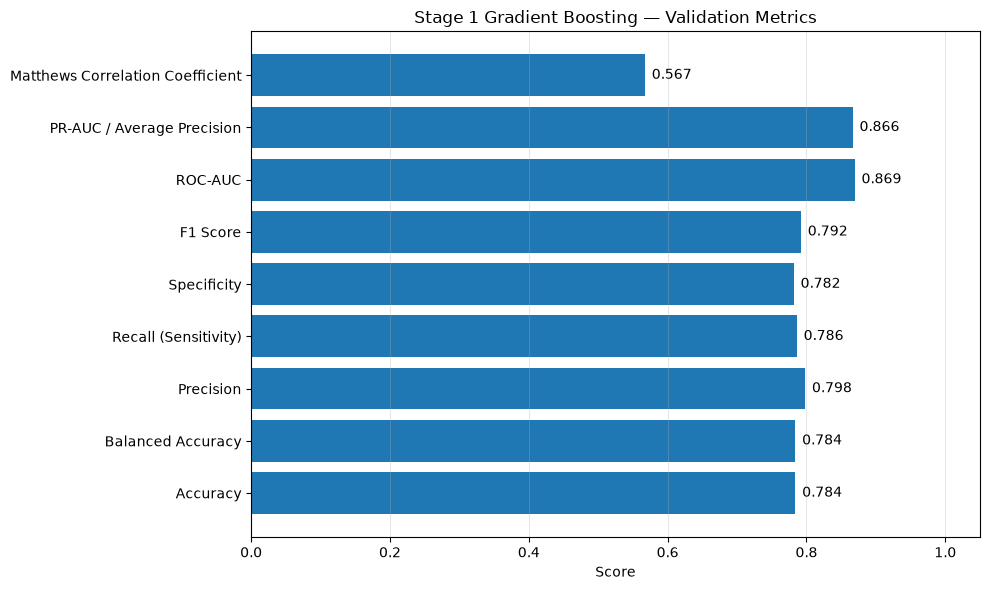

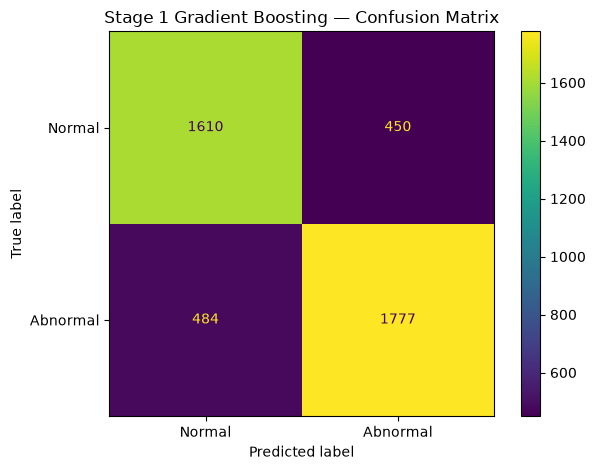

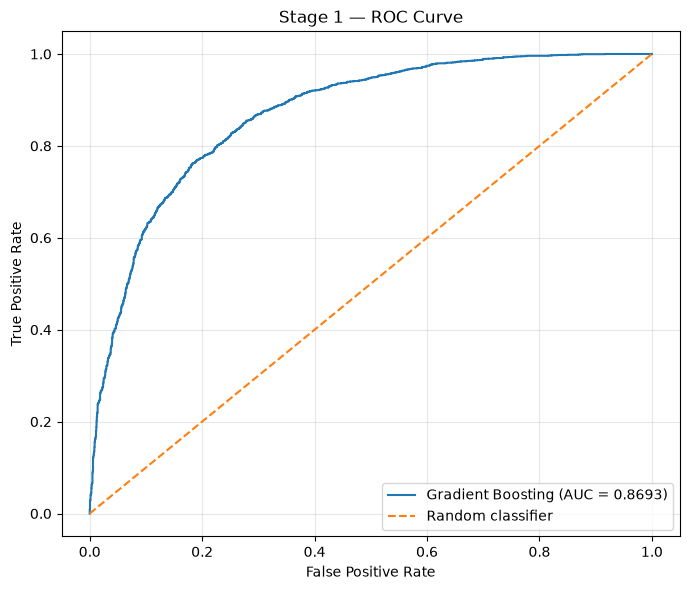

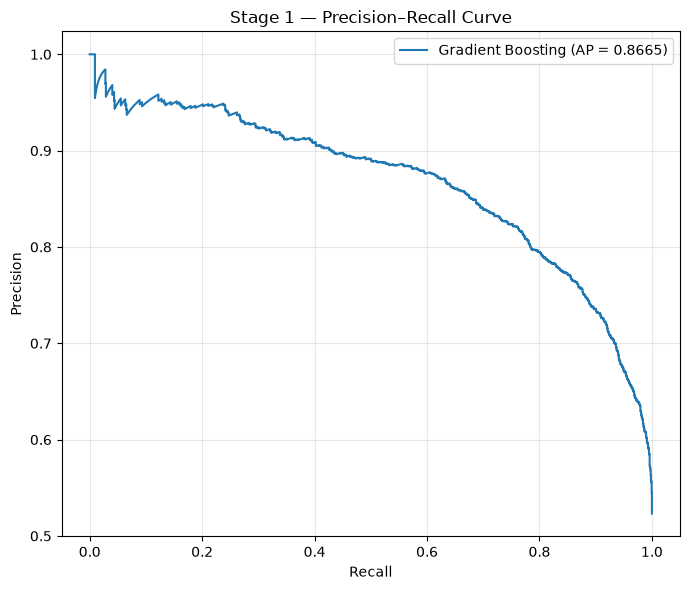


CONFUSION MATRIX DETAILS
True Normal correctly predicted:       1610
Normal incorrectly predicted Abnormal: 450
Abnormal missed as Normal:             484
Abnormal correctly detected:           1777


In [10]:
# STEP 9 — STAGE 1 BASELINE GRADIENT BOOSTING + FULL EVALUATION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef
)

# 1. Train baseline Gradient Boosting model

stage1_gb_baseline = GradientBoostingClassifier(
    random_state=42
)

stage1_gb_baseline.fit(
    X_train_stage1,
    y_train_stage1
)


# 2. Predictions

y_val_pred_stage1 = stage1_gb_baseline.predict(
    X_val_stage1
)

# Probability that a sample is Abnormal
abnormal_index = list(stage1_gb_baseline.classes_).index("Abnormal")

y_val_prob_stage1 = stage1_gb_baseline.predict_proba(
    X_val_stage1
)[:, abnormal_index]


# 3. Convert labels to binary values
#    Abnormal = 1
#    Normal   = 0

y_val_binary = (
    pd.Series(y_val_stage1)
    .map({
        "Normal": 0,
        "Abnormal": 1
    })
    .to_numpy()
)

y_pred_binary = (
    pd.Series(y_val_pred_stage1)
    .map({
        "Normal": 0,
        "Abnormal": 1
    })
    .to_numpy()
)

# 4. Confusion-matrix values

tn, fp, fn, tp = confusion_matrix(
    y_val_binary,
    y_pred_binary
).ravel()

specificity = tn / (tn + fp)

# 5. Calculate evaluation metrics

accuracy = accuracy_score(
    y_val_binary,
    y_pred_binary
)

balanced_accuracy = balanced_accuracy_score(
    y_val_binary,
    y_pred_binary
)

precision = precision_score(
    y_val_binary,
    y_pred_binary
)

recall = recall_score(
    y_val_binary,
    y_pred_binary
)

f1 = f1_score(
    y_val_binary,
    y_pred_binary
)

roc_auc = roc_auc_score(
    y_val_binary,
    y_val_prob_stage1
)

average_precision = average_precision_score(
    y_val_binary,
    y_val_prob_stage1
)

mcc = matthews_corrcoef(
    y_val_binary,
    y_pred_binary
)


# 6. Display numerical metrics

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall (Sensitivity)",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC / Average Precision",
        "Matthews Correlation Coefficient"
    ],

    "Score": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        average_precision,
        mcc
    ]
})

print("=" * 60)
print("STAGE 1 — GRADIENT BOOSTING VALIDATION RESULTS")
print("=" * 60)

print(metrics_df.to_string(
    index=False,
    formatters={"Score": "{:.4f}".format}
))


# 7. Full classification report

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_val_stage1,
        y_val_pred_stage1,
        digits=4
    )
)


# 8. Metric comparison graph

plt.figure(figsize=(10, 6))

bars = plt.barh(
    metrics_df["Metric"],
    metrics_df["Score"]
)

plt.xlim(0, 1.05)

plt.xlabel("Score")
plt.title("Stage 1 Gradient Boosting — Validation Metrics")

plt.grid(
    axis="x",
    alpha=0.3
)

for bar, score in zip(
    bars,
    metrics_df["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# 9. Confusion Matrix

cm = confusion_matrix(
    y_val_stage1,
    y_val_pred_stage1,
    labels=["Normal", "Abnormal"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Stage 1 Gradient Boosting — Confusion Matrix"
)

plt.tight_layout()
plt.show()

# 10. ROC Curve

fpr, tpr, roc_thresholds = roc_curve(
    y_val_binary,
    y_val_prob_stage1
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Stage 1 — ROC Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 11. Precision–Recall Curve

pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_val_binary,
    y_val_prob_stage1
)

plt.figure(figsize=(7, 6))

plt.plot(
    pr_recall,
    pr_precision,
    label=f"Gradient Boosting (AP = {average_precision:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Stage 1 — Precision–Recall Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 12. Confusion-matrix interpretation

print("\n" + "=" * 60)
print("CONFUSION MATRIX DETAILS")
print("=" * 60)

print(f"True Normal correctly predicted:       {tn}")
print(f"Normal incorrectly predicted Abnormal: {fp}")
print(f"Abnormal missed as Normal:             {fn}")
print(f"Abnormal correctly detected:           {tp}")

STAGE 1 — ABNORMAL CLASS ERROR ANALYSIS
                                Total Validation Samples  Detected as Abnormal  Missed as Normal Stage 1 Recall
label                                                                                                          
Falling Down                                         525                   422               103         0.8038
Staggering/Unbalanced Movement                      1052                   949               103         0.9021
Touch Chest                                          684                   406               278         0.5936


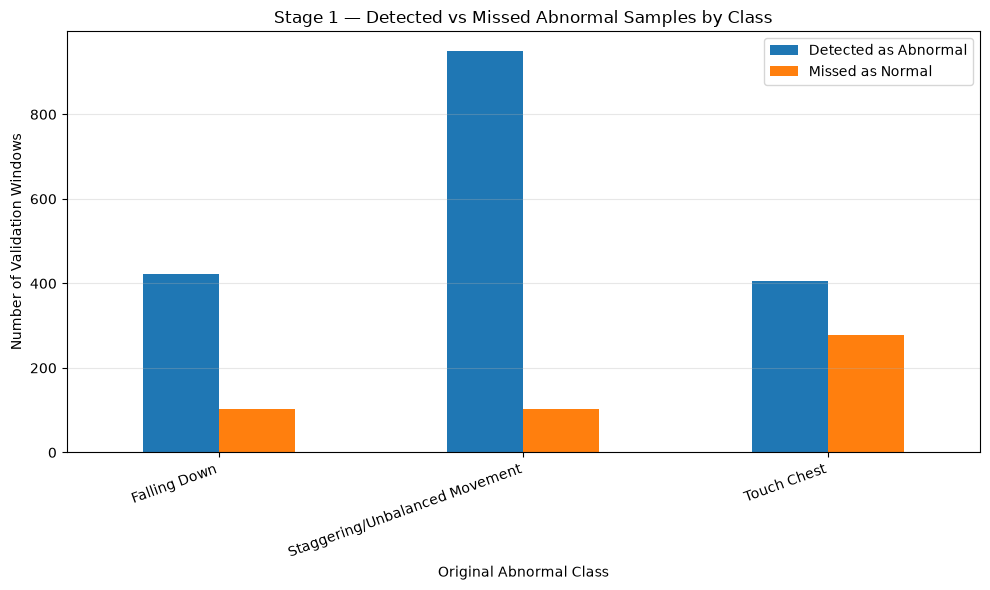

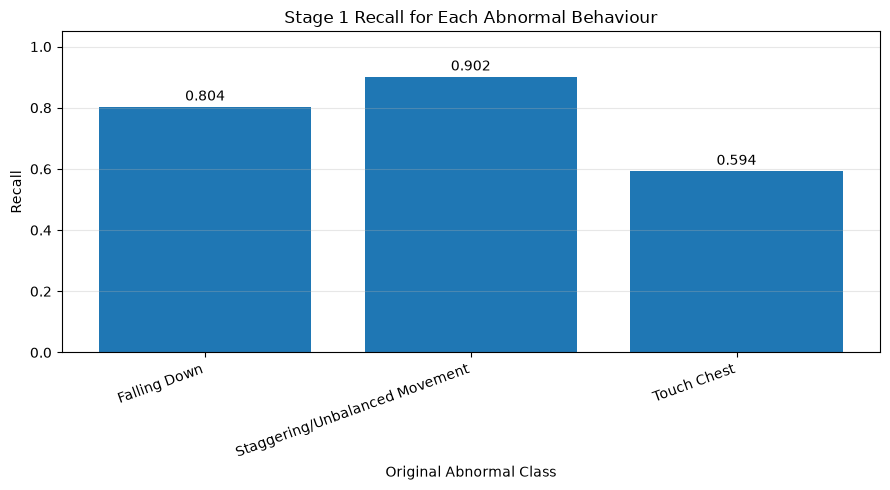

In [11]:
# STEP 10 — ANALYZE WHICH ABNORMAL CLASSES STAGE 1 MISSES

# Keep only abnormal validation samples
val_abnormal_analysis = val_df[
    val_df["label"] != "Normal Activity"
].copy()

# Get Stage 1 predictions for those exact abnormal samples
X_val_abnormal_analysis = val_abnormal_analysis[feature_columns]

stage1_pred_for_abnormal = stage1_gb_baseline.predict(
    X_val_abnormal_analysis
)

# Add predictions into a copy for analysis
val_abnormal_analysis["stage1_prediction"] = stage1_pred_for_abnormal

# Count total samples per original abnormal class
total_per_class = (
    val_abnormal_analysis["label"]
    .value_counts()
    .sort_index()
)

# Count how many from each abnormal class were missed as Normal
missed_per_class = (
    val_abnormal_analysis[
        val_abnormal_analysis["stage1_prediction"] == "Normal"
    ]["label"]
    .value_counts()
    .reindex(total_per_class.index, fill_value=0)
)

# Count how many were correctly passed as Abnormal
detected_per_class = total_per_class - missed_per_class

# Recall for each original abnormal class
recall_per_class = detected_per_class / total_per_class

analysis_df = pd.DataFrame({
    "Total Validation Samples": total_per_class,
    "Detected as Abnormal": detected_per_class,
    "Missed as Normal": missed_per_class,
    "Stage 1 Recall": recall_per_class
})

print("=" * 80)
print("STAGE 1 — ABNORMAL CLASS ERROR ANALYSIS")
print("=" * 80)

print(
    analysis_df.to_string(
        formatters={
            "Stage 1 Recall": "{:.4f}".format
        }
    )
)


# Graph 1 — Detected vs missed counts

analysis_df[
    ["Detected as Abnormal", "Missed as Normal"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Stage 1 — Detected vs Missed Abnormal Samples by Class"
)

plt.xlabel("Original Abnormal Class")
plt.ylabel("Number of Validation Windows")

plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# Graph 2 — Stage 1 recall for each abnormal class

plt.figure(figsize=(9, 5))

bars = plt.bar(
    analysis_df.index,
    analysis_df["Stage 1 Recall"]
)

plt.ylim(0, 1.05)

plt.title(
    "Stage 1 Recall for Each Abnormal Behaviour"
)

plt.xlabel("Original Abnormal Class")
plt.ylabel("Recall")

plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar, score in zip(
    bars,
    analysis_df["Stage 1 Recall"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

STAGE 1 — THRESHOLD COMPARISON
 Threshold  Accuracy  Precision  Abnormal Recall  Specificity     F1  Falling Recall  Staggering Recall  Touch Chest Recall  False Negatives  False Positives
      0.20    0.7177     0.6576           0.9606       0.4510 0.7807          0.9924             0.9895              0.8918               89             1131
      0.25    0.7447     0.6869           0.9412       0.5291 0.7942          0.9810             0.9791              0.8523              133              970
      0.30    0.7667     0.7152           0.9208       0.5976 0.8051          0.9581             0.9715              0.8143              179              829
      0.35    0.7778     0.7380           0.8921       0.6524 0.8078          0.9219             0.9601              0.7646              244              716
      0.40    0.7894     0.7627           0.8673       0.7039 0.8117          0.8933             0.9496              0.7208              300              610
      0.45    0.7889 

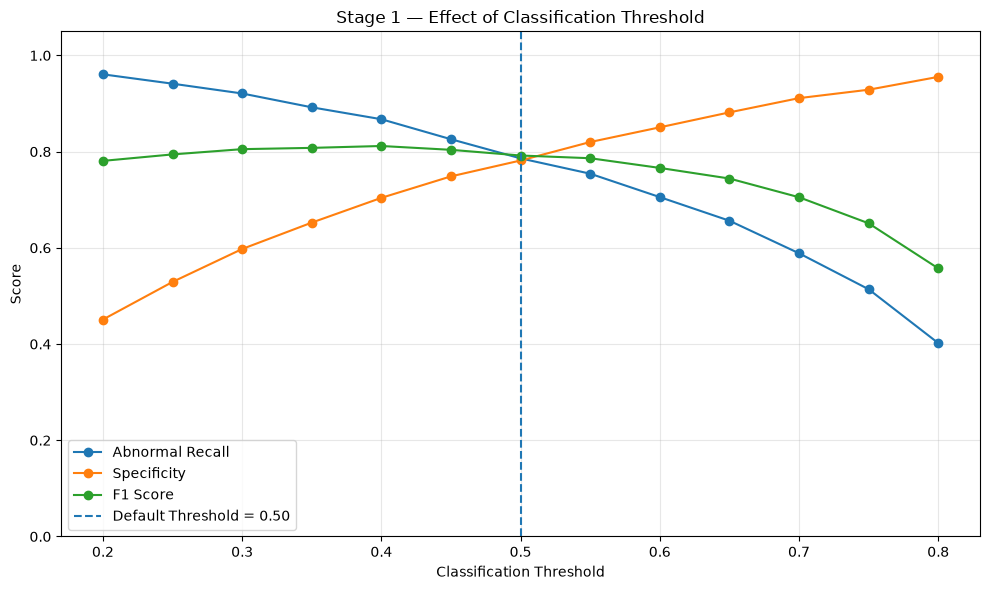

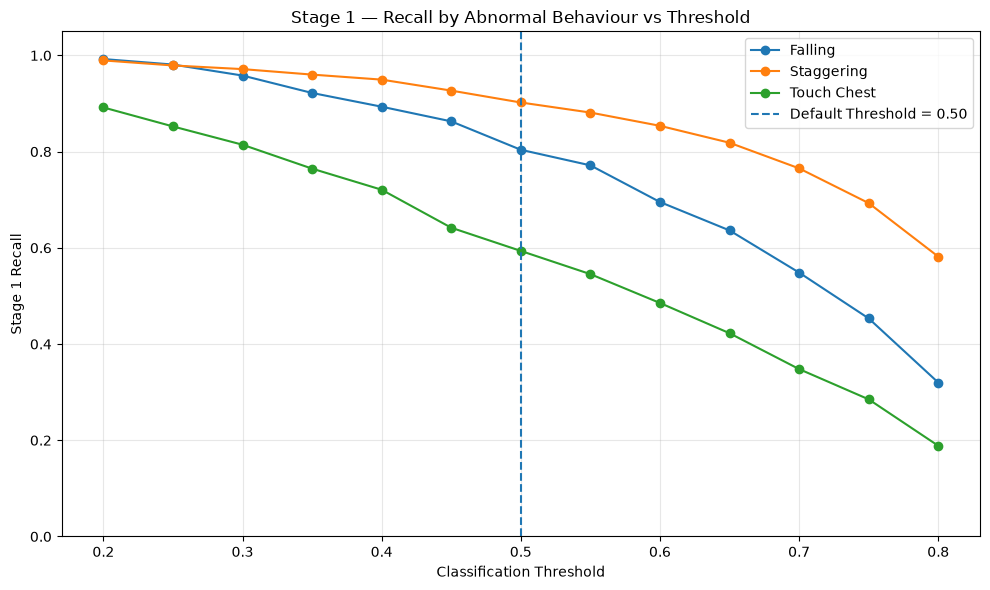

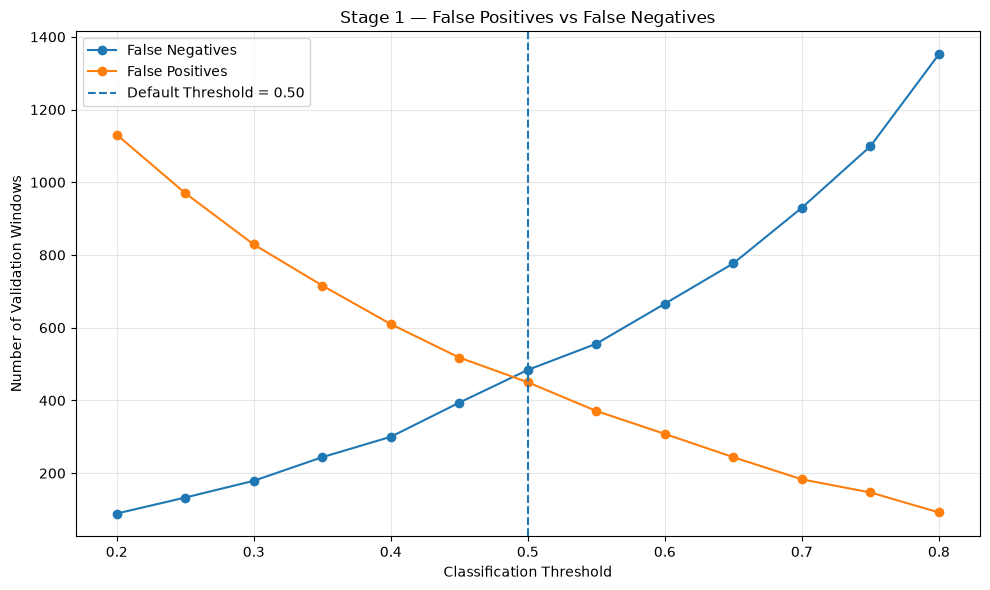

In [12]:
# STEP 11 — STAGE 1 THRESHOLD ANALYSIS

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

threshold_results = []

thresholds = np.arange(0.20, 0.81, 0.05)

for threshold in thresholds:

    # Convert probabilities into predictions

    pred_binary = (
        y_val_prob_stage1 >= threshold
    ).astype(int)

    # Overall metrics

    accuracy = accuracy_score(
        y_val_binary,
        pred_binary
    )

    precision = precision_score(
        y_val_binary,
        pred_binary
    )

    recall = recall_score(
        y_val_binary,
        pred_binary
    )

    f1 = f1_score(
        y_val_binary,
        pred_binary
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val_binary,
        pred_binary
    ).ravel()

    specificity = tn / (tn + fp)

    # Per-original-class Stage 1 recall

    abnormal_probabilities = (
        stage1_gb_baseline.predict_proba(
            X_val_abnormal_analysis
        )[:, abnormal_index]
    )

    abnormal_predictions = (
        abnormal_probabilities >= threshold
    )

    temp = val_abnormal_analysis.copy()

    temp["detected"] = abnormal_predictions

    class_recalls = (
        temp.groupby("label")["detected"]
        .mean()
    )

    falling_recall = class_recalls.get(
        "Falling Down",
        np.nan
    )

    staggering_recall = class_recalls.get(
        "Staggering/Unbalanced Movement",
        np.nan
    )

    touch_chest_recall = class_recalls.get(
        "Touch Chest",
        np.nan
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Abnormal Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "Falling Recall": falling_recall,
        "Staggering Recall": staggering_recall,
        "Touch Chest Recall": touch_chest_recall,
        "False Negatives": fn,
        "False Positives": fp
    })


threshold_df = pd.DataFrame(
    threshold_results
)

# Print results

print("=" * 110)
print("STAGE 1 — THRESHOLD COMPARISON")
print("=" * 110)

print(
    threshold_df.round(4).to_string(
        index=False
    )
)


# Graph 1 — Overall recall vs specificity

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Abnormal Recall"],
    marker="o",
    label="Abnormal Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Specificity"],
    marker="o",
    label="Specificity"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Stage 1 — Effect of Classification Threshold"
)

plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Graph 2 — Recall of individual abnormal behaviours

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Falling Recall"],
    marker="o",
    label="Falling"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Staggering Recall"],
    marker="o",
    label="Staggering"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Touch Chest Recall"],
    marker="o",
    label="Touch Chest"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Stage 1 Recall")

plt.title(
    "Stage 1 — Recall by Abnormal Behaviour vs Threshold"
)

plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Graph 3 — False positives vs false negatives

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["False Negatives"],
    marker="o",
    label="False Negatives"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["False Positives"],
    marker="o",
    label="False Positives"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of Validation Windows")

plt.title(
    "Stage 1 — False Positives vs False Negatives"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Step 12A — Prepare subject-wise cross-validation

In [14]:
from sklearn.model_selection import GroupKFold

# Each training window keeps its original subject ID
stage1_train_groups = train_df["subject_id"].copy()

# Create 5 subject-wise folds
group_cv = GroupKFold(n_splits=5)

print("Number of training windows:", len(X_train_stage1))
print("Number of unique training subjects:", stage1_train_groups.nunique())
print("Number of CV folds:", group_cv.get_n_splits())

print("\nSUBJECT-WISE CROSS-VALIDATION CHECK")
print("=" * 60)

for fold_number, (train_idx, cv_idx) in enumerate(
    group_cv.split(
        X_train_stage1,
        y_train_stage1,
        groups=stage1_train_groups
    ),
    start=1
):

    train_subjects = set(
        stage1_train_groups.iloc[train_idx]
    )

    cv_subjects = set(
        stage1_train_groups.iloc[cv_idx]
    )

    overlap = train_subjects.intersection(
        cv_subjects
    )

    print(f"\nFold {fold_number}")
    print("Training windows:", len(train_idx))
    print("Validation windows:", len(cv_idx))
    print("Training subjects:", len(train_subjects))
    print("Validation subjects:", len(cv_subjects))
    print("Subject overlap:", len(overlap))

Number of training windows: 15140
Number of unique training subjects: 28
Number of CV folds: 5

SUBJECT-WISE CROSS-VALIDATION CHECK

Fold 1
Training windows: 12154
Validation windows: 2986
Training subjects: 23
Validation subjects: 5
Subject overlap: 0

Fold 2
Training windows: 12074
Validation windows: 3066
Training subjects: 22
Validation subjects: 6
Subject overlap: 0

Fold 3
Training windows: 12103
Validation windows: 3037
Training subjects: 21
Validation subjects: 7
Subject overlap: 0

Fold 4
Training windows: 12108
Validation windows: 3032
Training subjects: 21
Validation subjects: 7
Subject overlap: 0

Fold 5
Training windows: 12121
Validation windows: 3019
Training subjects: 25
Validation subjects: 3
Subject overlap: 0


In [16]:
# STEP 12B-FIX — VERIFY CORRECT ABNORMAL F1 SCORER

import numpy as np

from sklearn.metrics import (
    f1_score,
    make_scorer
)

from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier


# Tell sklearn explicitly:
# "Abnormal" is our positive class

abnormal_f1_scorer = make_scorer(
    f1_score,
    pos_label="Abnormal"
)


# Baseline model for scorer verification

scorer_test_model = GradientBoostingClassifier(
    random_state=42
)


# 5-fold SUBJECT-WISE cross-validation

cv_f1_scores = cross_val_score(
    scorer_test_model,
    X_train_stage1,
    y_train_stage1,
    groups=stage1_train_groups,
    cv=group_cv,
    scoring=abnormal_f1_scorer,
    n_jobs=-1,
    error_score="raise"
)


# Show results

print("=" * 60)
print("CORRECTED SUBJECT-WISE F1 SCORER CHECK")
print("=" * 60)

for i, score in enumerate(cv_f1_scores, start=1):
    print(f"Fold {i} F1: {score:.4f}")

print("\nMean CV F1:", round(cv_f1_scores.mean(), 4))
print("Standard deviation:", round(cv_f1_scores.std(), 4))

print("\nAny NaN scores?:", np.isnan(cv_f1_scores).any())

CORRECTED SUBJECT-WISE F1 SCORER CHECK
Fold 1 F1: 0.7972
Fold 2 F1: 0.8004
Fold 3 F1: 0.8071
Fold 4 F1: 0.8260
Fold 5 F1: 0.8411

Mean CV F1: 0.8144
Standard deviation: 0.0167

Any NaN scores?: False


In [17]:
# STEP 12B — CORRECTED GRADIENT BOOSTING HYPERPARAMETER SEARCH

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier


# 1. Create base Gradient Boosting model

gb_search_model = GradientBoostingClassifier(
    random_state=42
)

# 2. Define hyperparameter search space

param_distributions = {

    "n_estimators": [
        100,
        150,
        200,
        250,
        300
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
        0.15
    ],

    "max_depth": [
        2,
        3,
        4
    ],

    "min_samples_leaf": [
        1,
        3,
        5,
        10
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}


# 3. Create RandomizedSearchCV

stage1_search = RandomizedSearchCV(

    estimator=gb_search_model,

    param_distributions=param_distributions,

    # Test 30 random combinations
    n_iter=30,

    # IMPORTANT:
    # F1 specifically treating Abnormal as positive
    scoring=abnormal_f1_scorer,

    # Subject-wise CV created earlier
    cv=group_cv,

    random_state=42,

    # Use all CPU cores
    n_jobs=-1,

    # Show progress
    verbose=2,

    # Keep training scores for later analysis
    return_train_score=True,

    # Stop immediately if another scoring error occurs
    error_score="raise"
)


# 4. Run the search

stage1_search.fit(

    X_train_stage1,
    y_train_stage1,

    groups=stage1_train_groups
)


# 5. Print best result

print("\n" + "=" * 70)
print("BEST STAGE 1 GRADIENT BOOSTING PARAMETERS")
print("=" * 70)

print(stage1_search.best_params_)


print("\nBest Subject-Wise CV F1:")
print(
    round(
        stage1_search.best_score_,
        4
    )
)


print("\nBaseline Subject-Wise CV F1:")
print("0.8144")


print("\nImprovement over baseline:")

improvement = (
    stage1_search.best_score_
    - 0.8144
)

print(
    round(
        improvement,
        4
    )
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST STAGE 1 GRADIENT BOOSTING PARAMETERS
{'subsample': 0.7, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_depth': 4, 'learning_rate': 0.08}

Best Subject-Wise CV F1:
0.8297

Baseline Subject-Wise CV F1:
0.8144

Improvement over baseline:
0.0153


Best tuned parameters:
{'ccp_alpha': 0.0, 'criterion': 'deprecated', 'init': None, 'learning_rate': 0.08, 'loss': 'log_loss', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 300, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 0.7, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
BASELINE VS TUNED — VALIDATION METRICS
           Metric Baseline  Tuned  Change
         Accuracy   0.7838 0.8095 +0.0257
Balanced Accuracy   0.7837 0.8098 +0.0260
        Precision   0.7979 0.8268 +0.0289
           Recall   0.7859 0.8045 +0.0186
      Specificity   0.7816 0.8150 +0.0335
         F1 Score   0.7919 0.8155 +0.0236
          ROC-AUC   0.8693 0.8865 +0.0172
           PR-AUC   0.8665 0.8850 +0.0185
              MCC   0.5671 0.6190 +0.0518

TUNED MODEL CLASSIFICATION REPORT
              precision    recall  f1-score  

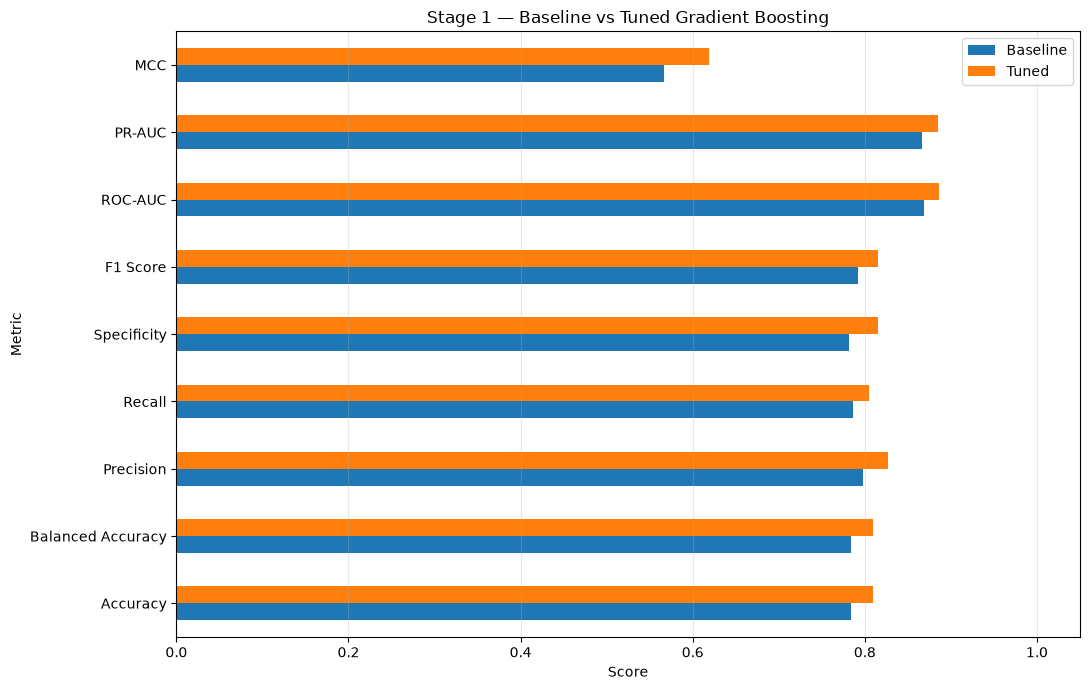

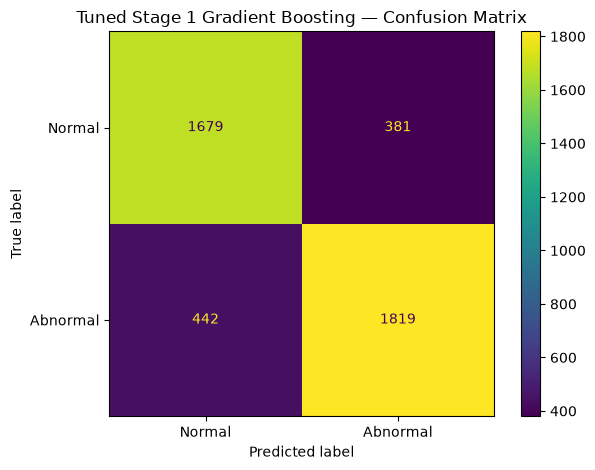


ABNORMAL CLASS RECALL — BASELINE VS TUNED
                                Baseline Detected  Tuned Detected
label                                                            
Falling Down                               0.8038          0.7905
Staggering/Unbalanced Movement             0.9021          0.9002
Touch Chest                                0.5936          0.6681


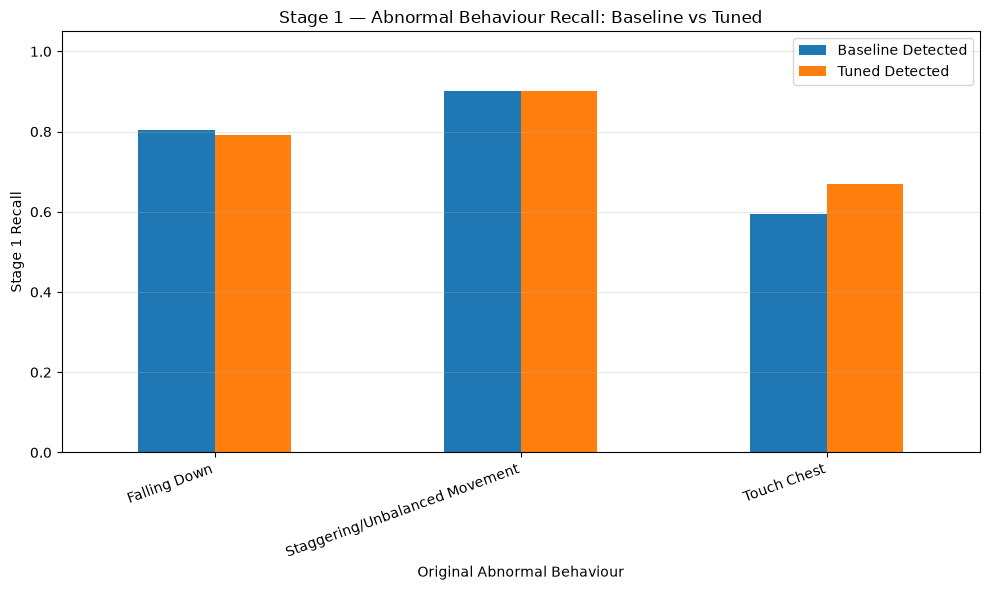


ERROR COUNT COMPARISON
     Error Type  Baseline  Tuned
False Negatives       484    442
False Positives       450    381


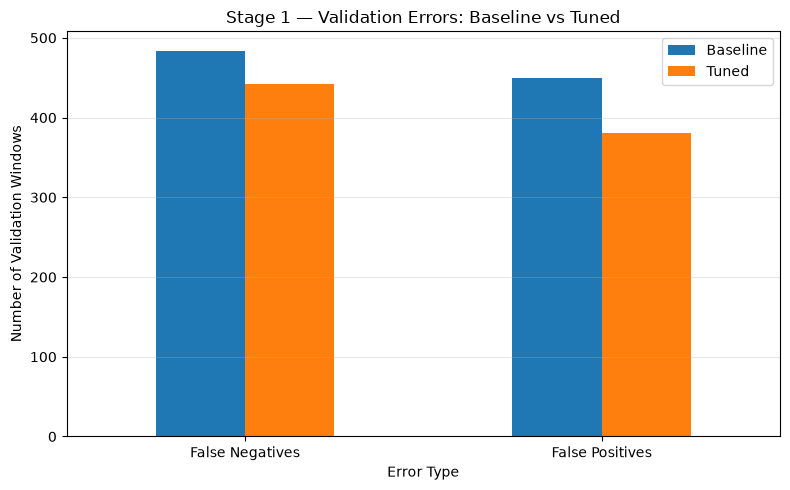

In [18]:
# STEP 12C — BASELINE VS TUNED GRADIENT BOOSTING
#              VALIDATION COMPARISON

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)


# 1. Get the tuned model

stage1_gb_tuned = stage1_search.best_estimator_

print("Best tuned parameters:")
print(stage1_gb_tuned.get_params())


# 2. Tuned-model predictions

y_val_pred_tuned = stage1_gb_tuned.predict(
    X_val_stage1
)

abnormal_index_tuned = list(
    stage1_gb_tuned.classes_
).index("Abnormal")

y_val_prob_tuned = stage1_gb_tuned.predict_proba(
    X_val_stage1
)[:, abnormal_index_tuned]


# 3. Convert predictions to binary

y_val_pred_tuned_binary = (
    pd.Series(y_val_pred_tuned)
    .map({
        "Normal": 0,
        "Abnormal": 1
    })
    .to_numpy()
)


# 4. Function to calculate all important metrics

def calculate_binary_metrics(
    y_true,
    y_pred,
    y_probability
):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred
        ),

        "Recall": recall_score(
            y_true,
            y_pred
        ),

        "Specificity": specificity,

        "F1 Score": f1_score(
            y_true,
            y_pred
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability
        ),

        "PR-AUC": average_precision_score(
            y_true,
            y_probability
        ),

        "MCC": matthews_corrcoef(
            y_true,
            y_pred
        ),

        "False Negatives": fn,

        "False Positives": fp,

        "True Positives": tp,

        "True Negatives": tn
    }


# 5. Baseline metrics

baseline_metrics = calculate_binary_metrics(
    y_val_binary,
    y_pred_binary,
    y_val_prob_stage1
)


# 6. Tuned-model metrics

tuned_metrics = calculate_binary_metrics(
    y_val_binary,
    y_val_pred_tuned_binary,
    y_val_prob_tuned
)


# 7. Build comparison table

comparison_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
    "MCC"
]

comparison_df = pd.DataFrame({

    "Metric": comparison_metrics,

    "Baseline": [
        baseline_metrics[m]
        for m in comparison_metrics
    ],

    "Tuned": [
        tuned_metrics[m]
        for m in comparison_metrics
    ]
})


comparison_df["Change"] = (
    comparison_df["Tuned"]
    -
    comparison_df["Baseline"]
)


print("=" * 75)
print("BASELINE VS TUNED — VALIDATION METRICS")
print("=" * 75)

print(
    comparison_df.to_string(
        index=False,
        formatters={
            "Baseline": "{:.4f}".format,
            "Tuned": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)


# 8. Classification report for tuned model

print("\n" + "=" * 75)
print("TUNED MODEL CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        y_val_stage1,
        y_val_pred_tuned,
        digits=4
    )
)


# 9. Graph — Baseline vs tuned metrics

graph_df = comparison_df.set_index(
    "Metric"
)[
    ["Baseline", "Tuned"]
]

graph_df.plot(
    kind="barh",
    figsize=(11, 7)
)

plt.xlim(0, 1.05)

plt.xlabel("Score")

plt.title(
    "Stage 1 — Baseline vs Tuned Gradient Boosting"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# 10. Tuned confusion matrix

cm_tuned = confusion_matrix(
    y_val_stage1,
    y_val_pred_tuned,
    labels=[
        "Normal",
        "Abnormal"
    ]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=[
        "Normal",
        "Abnormal"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Tuned Stage 1 Gradient Boosting — Confusion Matrix"
)

plt.tight_layout()
plt.show()


# 11. Compare original abnormal-class recall

X_val_abnormal = val_abnormal_analysis[
    feature_columns
]

baseline_abnormal_pred = (
    stage1_gb_baseline.predict_proba(
        X_val_abnormal
    )[:, abnormal_index]
    >= 0.50
)

tuned_abnormal_prob = (
    stage1_gb_tuned.predict_proba(
        X_val_abnormal
    )[:, abnormal_index_tuned]
)

tuned_abnormal_pred = (
    tuned_abnormal_prob
    >= 0.50
)


class_compare = (
    val_abnormal_analysis[
        ["label"]
    ]
    .copy()
)

class_compare[
    "Baseline Detected"
] = baseline_abnormal_pred

class_compare[
    "Tuned Detected"
] = tuned_abnormal_pred


class_recall_comparison = (
    class_compare
    .groupby("label")[
        [
            "Baseline Detected",
            "Tuned Detected"
        ]
    ]
    .mean()
)


print("\n" + "=" * 75)
print("ABNORMAL CLASS RECALL — BASELINE VS TUNED")
print("=" * 75)

print(
    class_recall_comparison.round(4)
)


# 12. Graph — Per-class abnormal recall

class_recall_comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)

plt.xlabel(
    "Original Abnormal Behaviour"
)

plt.ylabel(
    "Stage 1 Recall"
)

plt.title(
    "Stage 1 — Abnormal Behaviour Recall: Baseline vs Tuned"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# 13. Error-count comparison

error_df = pd.DataFrame({

    "Error Type": [
        "False Negatives",
        "False Positives"
    ],

    "Baseline": [
        baseline_metrics[
            "False Negatives"
        ],

        baseline_metrics[
            "False Positives"
        ]
    ],

    "Tuned": [
        tuned_metrics[
            "False Negatives"
        ],

        tuned_metrics[
            "False Positives"
        ]
    ]
})


print("\n" + "=" * 75)
print("ERROR COUNT COMPARISON")
print("=" * 75)

print(error_df.to_string(index=False))


# 14. Graph — FP and FN comparison

error_df.set_index(
    "Error Type"
)[
    ["Baseline", "Tuned"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel(
    "Number of Validation Windows"
)

plt.title(
    "Stage 1 — Validation Errors: Baseline vs Tuned"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

TUNED STAGE 1 — THRESHOLD COMPARISON
 Threshold  Accuracy  Precision  Abnormal Recall  Specificity     F1  Falling Recall  Staggering Recall  Touch Chest Recall  False Negatives  False Positives
      0.20    0.7709     0.7145           0.9363       0.5893 0.8105          0.9676             0.9715              0.8582              144              846
      0.25    0.7878     0.7385           0.9204       0.6422 0.8195          0.9505             0.9591              0.8377              180              737
      0.30    0.7989     0.7595           0.9009       0.6869 0.8242          0.9162             0.9544              0.8070              224              645
      0.35    0.8051     0.7786           0.8770       0.7262 0.8249          0.8838             0.9468              0.7646              278              564
      0.40    0.8068     0.7939           0.8518       0.7573 0.8218          0.8419             0.9363              0.7295              335              500
      0.45    0

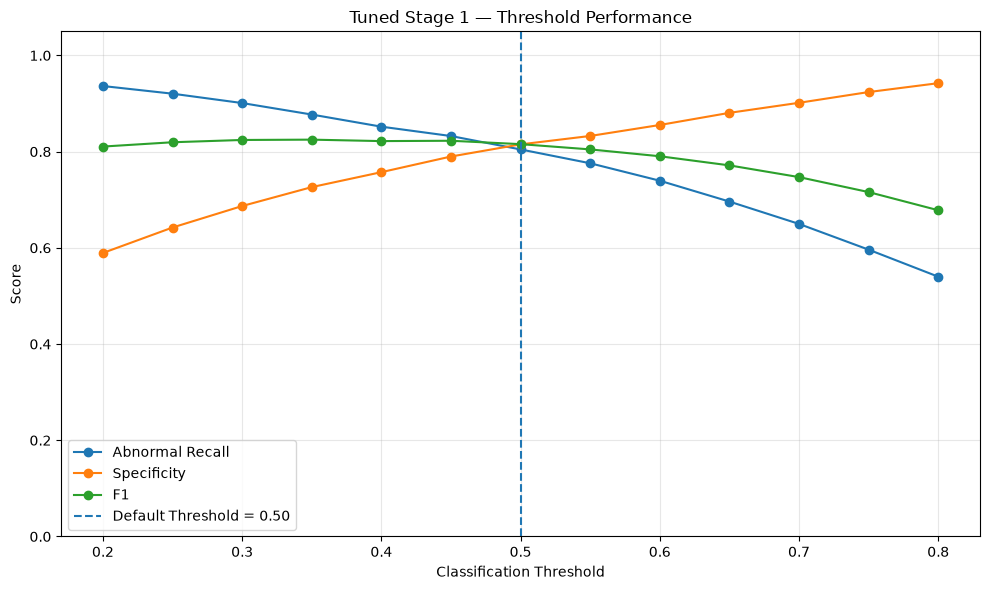

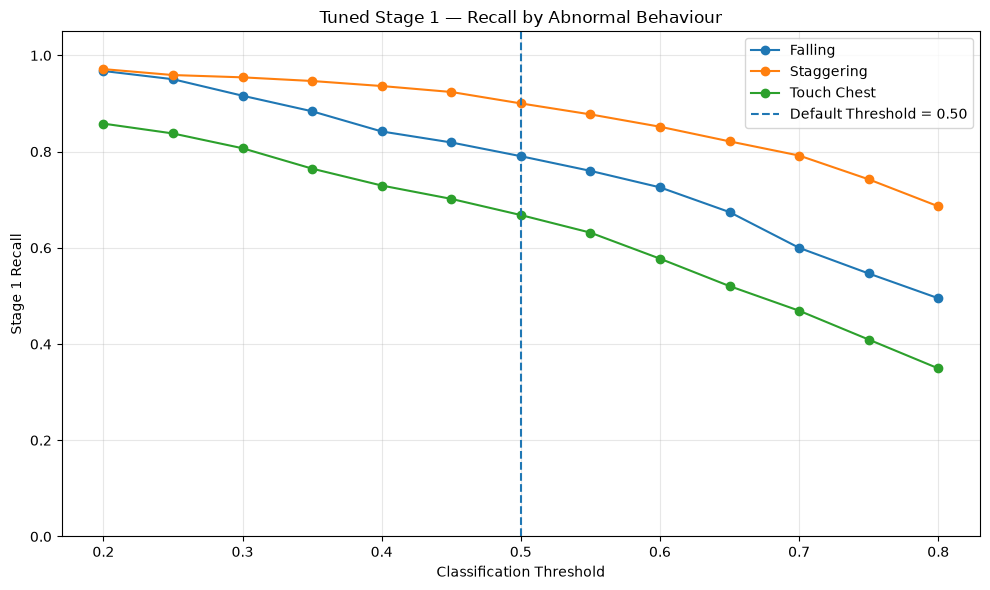

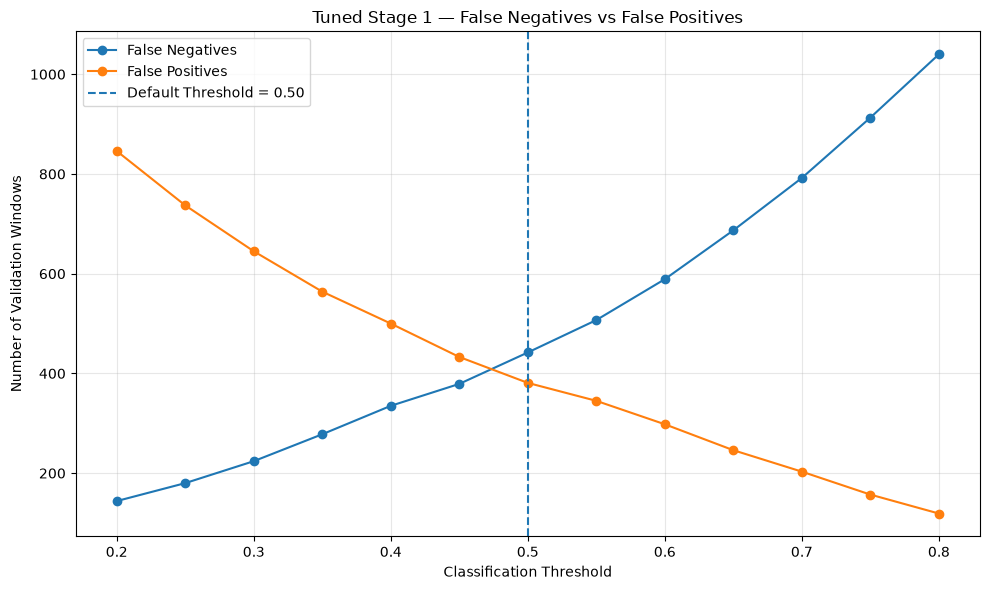

In [19]:
# STEP 12D — TUNED MODEL THRESHOLD ANALYSIS

tuned_threshold_results = []

thresholds = np.arange(
    0.20,
    0.81,
    0.05
)


# Probabilities for original abnormal classes

tuned_abnormal_prob_by_class = (
    stage1_gb_tuned.predict_proba(
        X_val_abnormal
    )[:, abnormal_index_tuned]
)


# Test each threshold

for threshold in thresholds:

    # Overall validation predictions
    pred_binary = (
        y_val_prob_tuned >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_val_binary,
        pred_binary
    )

    precision = precision_score(
        y_val_binary,
        pred_binary
    )

    recall = recall_score(
        y_val_binary,
        pred_binary
    )

    f1 = f1_score(
        y_val_binary,
        pred_binary
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val_binary,
        pred_binary
    ).ravel()

    specificity = (
        tn / (tn + fp)
    )


    # Per-abnormal-class recall

    detected = (
        tuned_abnormal_prob_by_class
        >= threshold
    )

    temp = val_abnormal_analysis.copy()

    temp["detected"] = detected

    class_recalls = (
        temp
        .groupby("label")["detected"]
        .mean()
    )

    tuned_threshold_results.append({

        "Threshold":
            threshold,

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Abnormal Recall":
            recall,

        "Specificity":
            specificity,

        "F1":
            f1,

        "Falling Recall":
            class_recalls.get(
                "Falling Down",
                np.nan
            ),

        "Staggering Recall":
            class_recalls.get(
                "Staggering/Unbalanced Movement",
                np.nan
            ),

        "Touch Chest Recall":
            class_recalls.get(
                "Touch Chest",
                np.nan
            ),

        "False Negatives":
            fn,

        "False Positives":
            fp
    })


tuned_threshold_df = pd.DataFrame(
    tuned_threshold_results
)


# Print table

print("=" * 110)
print("TUNED STAGE 1 — THRESHOLD COMPARISON")
print("=" * 110)

print(
    tuned_threshold_df
    .round(4)
    .to_string(index=False)
)


# Graph 1 — Main performance metrics

plt.figure(figsize=(10, 6))

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["Abnormal Recall"],
    marker="o",
    label="Abnormal Recall"
)

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["Specificity"],
    marker="o",
    label="Specificity"
)

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "Tuned Stage 1 — Threshold Performance"
)

plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Graph 2 — Recall by abnormal behaviour

plt.figure(figsize=(10, 6))

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["Falling Recall"],
    marker="o",
    label="Falling"
)

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["Staggering Recall"],
    marker="o",
    label="Staggering"
)

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["Touch Chest Recall"],
    marker="o",
    label="Touch Chest"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Stage 1 Recall")

plt.title(
    "Tuned Stage 1 — Recall by Abnormal Behaviour"
)

plt.ylim(0, 1.05)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Graph 3 — False positives vs false negatives

plt.figure(figsize=(10, 6))

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["False Negatives"],
    marker="o",
    label="False Negatives"
)

plt.plot(
    tuned_threshold_df["Threshold"],
    tuned_threshold_df["False Positives"],
    marker="o",
    label="False Positives"
)

plt.axvline(
    0.50,
    linestyle="--",
    label="Default Threshold = 0.50"
)

plt.xlabel("Classification Threshold")

plt.ylabel(
    "Number of Validation Windows"
)

plt.title(
    "Tuned Stage 1 — False Negatives vs False Positives"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# STEP 12E — FREEZE FINAL STAGE 1 CONFIGURATION

# Final selected Stage 1 model
final_stage1_model = stage1_gb_tuned

# Final threshold selected using validation data
STAGE1_THRESHOLD = 0.35

print("=" * 65)
print("FINAL STAGE 1 CONFIGURATION")
print("=" * 65)

print("\nModel:")
print("GradientBoostingClassifier")

print("\nSelected hyperparameters:")
print("n_estimators      =", final_stage1_model.n_estimators)
print("learning_rate     =", final_stage1_model.learning_rate)
print("max_depth         =", final_stage1_model.max_depth)
print("min_samples_leaf  =", final_stage1_model.min_samples_leaf)
print("subsample         =", final_stage1_model.subsample)
print("random_state      =", final_stage1_model.random_state)

print("\nFinal Stage 1 threshold:")
print(STAGE1_THRESHOLD)

print("\nNumber of input features:")
print(len(feature_columns))

print("\nClasses learned by model:")
print(final_stage1_model.classes_)

FINAL STAGE 1 CONFIGURATION

Model:
GradientBoostingClassifier

Selected hyperparameters:
n_estimators      = 300
learning_rate     = 0.08
max_depth         = 4
min_samples_leaf  = 3
subsample         = 0.7
random_state      = 42

Final Stage 1 threshold:
0.35

Number of input features:
20

Classes learned by model:
['Abnormal' 'Normal']


FINAL STAGE 1 — VALIDATION RESULTS
              Metric  Score
            Accuracy 0.8051
   Balanced Accuracy 0.8016
           Precision 0.7786
Recall (Sensitivity) 0.8770
         Specificity 0.7262
            F1 Score 0.8249
             ROC-AUC 0.8865
              PR-AUC 0.8850
                 MCC 0.6125

Final threshold:
0.35

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Abnormal     0.7786    0.8770    0.8249      2261
      Normal     0.8433    0.7262    0.7804      2060

    accuracy                         0.8051      4321
   macro avg     0.8109    0.8016    0.8026      4321
weighted avg     0.8094    0.8051    0.8037      4321


FINAL CONFUSION MATRIX DETAILS
True Normal: 1496
False Positive: 564
False Negative: 278
True Abnormal: 1983


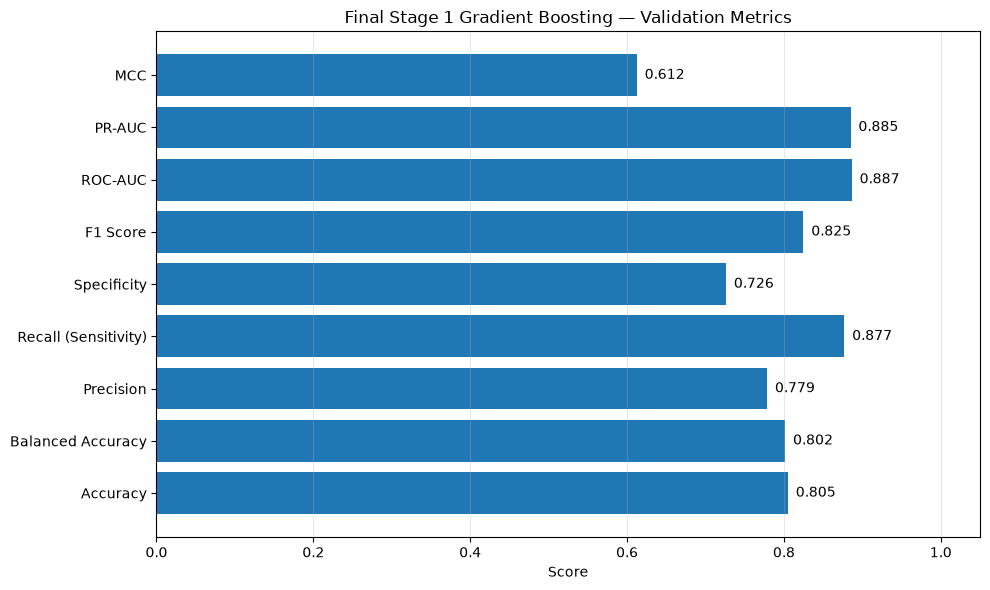

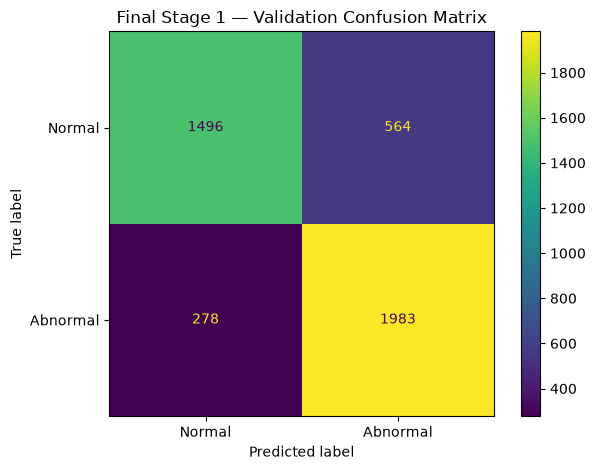


FINAL STAGE 1 RECALL BY ABNORMAL BEHAVIOUR
label
Falling Down                      0.8838
Staggering/Unbalanced Movement    0.9468
Touch Chest                       0.7646
Name: Detected as Abnormal, dtype: float64


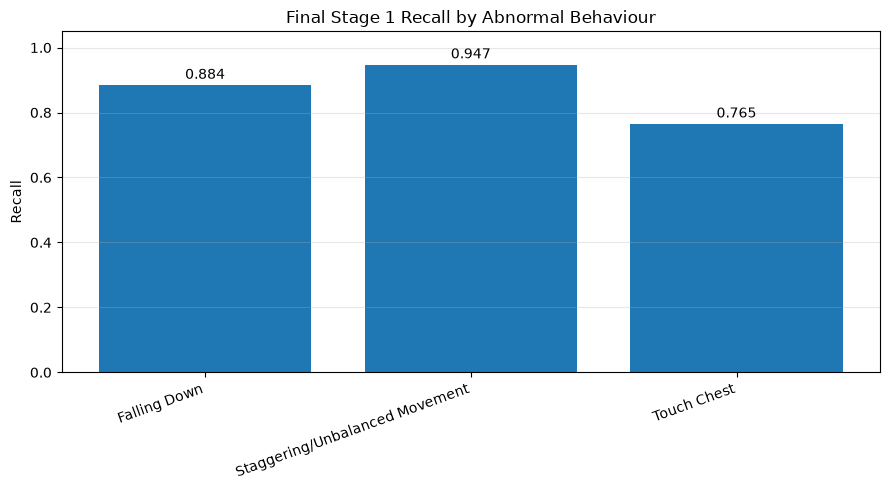

In [21]:
# STEP 12F — FINAL STAGE 1 VALIDATION REPORT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)


# 1. Find probability column for "Abnormal"

final_abnormal_index = list(
    final_stage1_model.classes_
).index("Abnormal")


# 2. Get abnormal probabilities

final_val_abnormal_prob = (
    final_stage1_model.predict_proba(
        X_val_stage1
    )[:, final_abnormal_index]
)


# 3. Apply FINAL threshold = 0.35

final_val_pred_binary = (
    final_val_abnormal_prob >= STAGE1_THRESHOLD
).astype(int)


# Convert binary predictions back to readable labels
final_val_pred_labels = np.where(
    final_val_pred_binary == 1,
    "Abnormal",
    "Normal"
)


# 4. Confusion matrix values

tn, fp, fn, tp = confusion_matrix(
    y_val_binary,
    final_val_pred_binary
).ravel()

specificity = tn / (tn + fp)


# 5. Final metrics

final_metrics = {

    "Accuracy":
        accuracy_score(
            y_val_binary,
            final_val_pred_binary
        ),

    "Balanced Accuracy":
        balanced_accuracy_score(
            y_val_binary,
            final_val_pred_binary
        ),

    "Precision":
        precision_score(
            y_val_binary,
            final_val_pred_binary
        ),

    "Recall (Sensitivity)":
        recall_score(
            y_val_binary,
            final_val_pred_binary
        ),

    "Specificity":
        specificity,

    "F1 Score":
        f1_score(
            y_val_binary,
            final_val_pred_binary
        ),

    "ROC-AUC":
        roc_auc_score(
            y_val_binary,
            final_val_abnormal_prob
        ),

    "PR-AUC":
        average_precision_score(
            y_val_binary,
            final_val_abnormal_prob
        ),

    "MCC":
        matthews_corrcoef(
            y_val_binary,
            final_val_pred_binary
        )
}


final_metrics_df = pd.DataFrame({
    "Metric": final_metrics.keys(),
    "Score": final_metrics.values()
})


# 6. Print final metrics

print("=" * 70)
print("FINAL STAGE 1 — VALIDATION RESULTS")
print("=" * 70)

print(
    final_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)


print("\nFinal threshold:")
print(STAGE1_THRESHOLD)


# 7. Classification report

print("\n" + "=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_val_stage1,
        final_val_pred_labels,
        digits=4
    )
)


# 8. Confusion matrix details

print("\n" + "=" * 70)
print("FINAL CONFUSION MATRIX DETAILS")
print("=" * 70)

print("True Normal:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Abnormal:", tp)


# 9. Metrics graph

plt.figure(figsize=(10, 6))

bars = plt.barh(
    final_metrics_df["Metric"],
    final_metrics_df["Score"]
)

plt.xlim(0, 1.05)

plt.xlabel("Score")

plt.title(
    "Final Stage 1 Gradient Boosting — Validation Metrics"
)

plt.grid(
    axis="x",
    alpha=0.3
)

for bar, score in zip(
    bars,
    final_metrics_df["Score"]
):

    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()


# 10. Final confusion matrix graph

cm = confusion_matrix(
    y_val_stage1,
    final_val_pred_labels,
    labels=[
        "Normal",
        "Abnormal"
    ]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Abnormal"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Final Stage 1 — Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()


# 11. Final recall by original abnormal behaviour

final_abnormal_prob_by_class = (
    final_stage1_model.predict_proba(
        X_val_abnormal
    )[:, final_abnormal_index]
)

final_detected_by_class = (
    final_abnormal_prob_by_class
    >= STAGE1_THRESHOLD
)

final_class_analysis = (
    val_abnormal_analysis[
        ["label"]
    ]
    .copy()
)

final_class_analysis[
    "Detected as Abnormal"
] = final_detected_by_class


final_class_recall = (
    final_class_analysis
    .groupby("label")[
        "Detected as Abnormal"
    ]
    .mean()
)


print("\n" + "=" * 70)
print("FINAL STAGE 1 RECALL BY ABNORMAL BEHAVIOUR")
print("=" * 70)

print(
    final_class_recall.round(4)
)



# 12. Recall graph by behaviour


plt.figure(figsize=(9, 5))

bars = plt.bar(
    final_class_recall.index,
    final_class_recall.values
)

plt.ylim(0, 1.05)

plt.ylabel("Recall")

plt.title(
    "Final Stage 1 Recall by Abnormal Behaviour"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    final_class_recall.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [22]:
# Step 12G - Save final Stage 1 model

from pathlib import Path
import joblib
import json
import sklearn
import numpy as np

# Create a folder for saved models
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Create a bundle containing everything needed for Stage 1
stage1_bundle = {
    # Trained Gradient Boosting model
    "model": final_stage1_model,

    # Final decision threshold selected from validation data
    "threshold": float(STAGE1_THRESHOLD),

    # Exact feature order required by the model
    "feature_columns": list(feature_columns),

    # Class information
    "positive_class": "Abnormal",
    "negative_class": "Normal",

    # Model type
    "model_type": "GradientBoostingClassifier",

    # Final tuned hyperparameters
    "hyperparameters": {
        "n_estimators": int(final_stage1_model.n_estimators),
        "learning_rate": float(final_stage1_model.learning_rate),
        "max_depth": int(final_stage1_model.max_depth),
        "min_samples_leaf": int(final_stage1_model.min_samples_leaf),
        "subsample": float(final_stage1_model.subsample),
        "random_state": int(final_stage1_model.random_state)
    },

    # Final validation metrics
    "validation_metrics": {
        key: float(value)
        for key, value in final_metrics.items()
    },

    # Final recall for each abnormal behaviour
    "abnormal_class_recall": {
        key: float(value)
        for key, value in final_class_recall.to_dict().items()
    },

    # Save scikit-learn version for reproducibility
    "sklearn_version": sklearn.__version__
}

# Define the model file path
model_path = models_dir / "stage1_gradient_boosting.joblib"

# Save the complete Stage 1 bundle
joblib.dump(stage1_bundle, model_path)

# Create readable metadata without the trained model object
metadata = {
    key: value
    for key, value in stage1_bundle.items()
    if key != "model"
}

# Define metadata file path
metadata_path = models_dir / "stage1_gradient_boosting_metadata.json"

# Save metadata as JSON
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

# Reload the saved model bundle to verify that saving worked
loaded_stage1 = joblib.load(model_path)

# Extract saved components
loaded_model = loaded_stage1["model"]
loaded_threshold = loaded_stage1["threshold"]
loaded_features = loaded_stage1["feature_columns"]

# Find the probability column for the Abnormal class
abnormal_idx = list(loaded_model.classes_).index("Abnormal")

# Generate probabilities for the first 10 validation samples
test_probabilities = loaded_model.predict_proba(
    X_val_stage1.iloc[:10]
)

# Apply the saved threshold instead of using model.predict()
test_predictions = np.where(
    test_probabilities[:, abnormal_idx] >= loaded_threshold,
    "Abnormal",
    "Normal"
)

# Show save verification results
print("STAGE 1 MODEL SAVE VERIFICATION")

print("\nModel file:")
print(model_path)

print("\nMetadata file:")
print(metadata_path)

print("\nLoaded threshold:")
print(loaded_threshold)

print("\nLoaded feature count:")
print(len(loaded_features))

print("\nLoaded classes:")
print(loaded_model.classes_)

print("\nFirst 10 predictions from reloaded model:")
print(test_predictions)

print("\nFiles successfully saved and reloaded.")

STAGE 1 MODEL SAVE VERIFICATION

Model file:
models\stage1_gradient_boosting.joblib

Metadata file:
models\stage1_gradient_boosting_metadata.json

Loaded threshold:
0.35

Loaded feature count:
20

Loaded classes:
['Abnormal' 'Normal']

First 10 predictions from reloaded model:
['Abnormal' 'Normal' 'Normal' 'Normal' 'Normal' 'Normal' 'Abnormal'
 'Normal' 'Normal' 'Normal']

Files successfully saved and reloaded.


In [23]:
# Step 13A - Verify Stage 2 datasets

print("STAGE 2 DATASET CHECK")

# Show training class distribution
print("\nTraining distribution:")
print(y_train_stage2.value_counts())

# Show validation class distribution
print("\nValidation distribution:")
print(y_val_stage2.value_counts())

# Show test class distribution
print("\nTest distribution:")
print(y_test_stage2.value_counts())

# Show input shapes
print("\nDataset shapes:")
print("Train:", X_train_stage2.shape)
print("Validation:", X_val_stage2.shape)
print("Test:", X_test_stage2.shape)

# Confirm that Stage 2 still uses the same 20 features
print("\nNumber of features:")
print(X_train_stage2.shape[1])

# Check for missing values
print("\nMissing feature values:")
print("Train:", X_train_stage2.isna().sum().sum())
print("Validation:", X_val_stage2.isna().sum().sum())
print("Test:", X_test_stage2.isna().sum().sum())

# Check which labels are present
print("\nStage 2 classes:")
print(sorted(y_train_stage2.unique()))

STAGE 2 DATASET CHECK

Training distribution:
label
Staggering/Unbalanced Movement    3684
Touch Chest                       2425
Falling Down                      1846
Name: count, dtype: int64

Validation distribution:
label
Staggering/Unbalanced Movement    1052
Touch Chest                        684
Falling Down                       525
Name: count, dtype: int64

Test distribution:
label
Staggering/Unbalanced Movement    510
Touch Chest                       346
Falling Down                      267
Name: count, dtype: int64

Dataset shapes:
Train: (7955, 20)
Validation: (2261, 20)
Test: (1123, 20)

Number of features:
20

Missing feature values:
Train: 0
Validation: 0
Test: 0

Stage 2 classes:
['Falling Down', 'Staggering/Unbalanced Movement', 'Touch Chest']


STAGE 2 BASELINE COMPARISON
           Metric Unweighted Weighted  Change
         Accuracy     0.8218   0.8134 -0.0084
Balanced Accuracy     0.8083   0.8170 +0.0087
  Macro Precision     0.8151   0.8030 -0.0120
     Macro Recall     0.8083   0.8170 +0.0087
         Macro F1     0.8112   0.8057 -0.0055
      Weighted F1     0.8219   0.8166 -0.0052
              MCC     0.7199   0.7162 -0.0037

UNWEIGHTED CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.7387    0.7486    0.7436       525
Staggering/Unbalanced Movement     0.8311    0.8650    0.8477      1052
                   Touch Chest     0.8754    0.8114    0.8422       684

                      accuracy                         0.8218      2261
                     macro avg     0.8151    0.8083    0.8112      2261
                  weighted avg     0.8230    0.8218    0.8219      2261


WEIGHTED CLASSIFICATION REPORT
                               

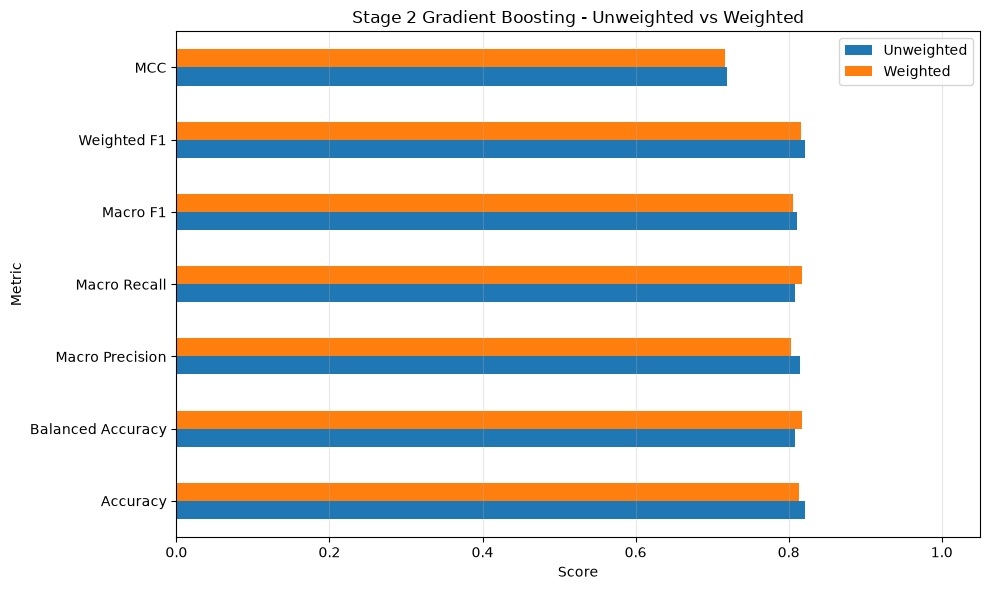

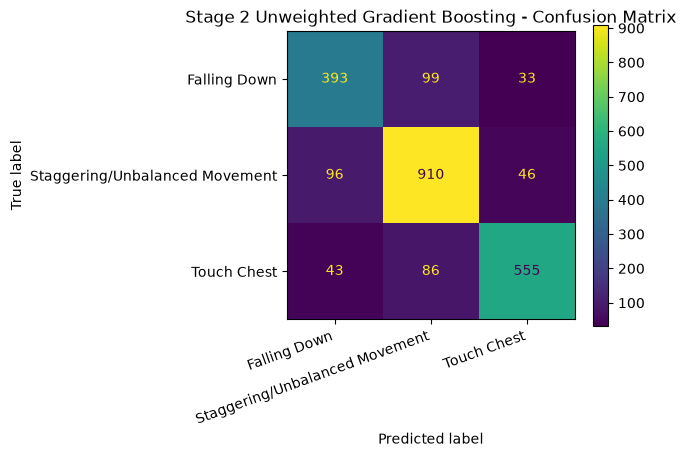

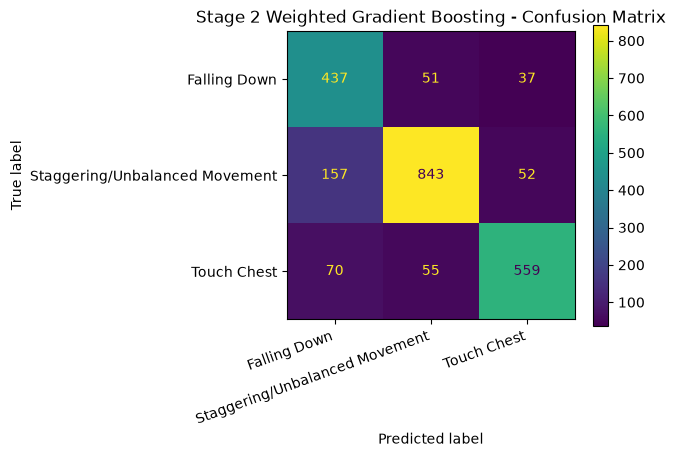


PER-CLASS RECALL COMPARISON
                         Class Unweighted Recall Weighted Recall
                  Falling Down            0.7486          0.8324
Staggering/Unbalanced Movement            0.8650          0.8013
                   Touch Chest            0.8114          0.8173


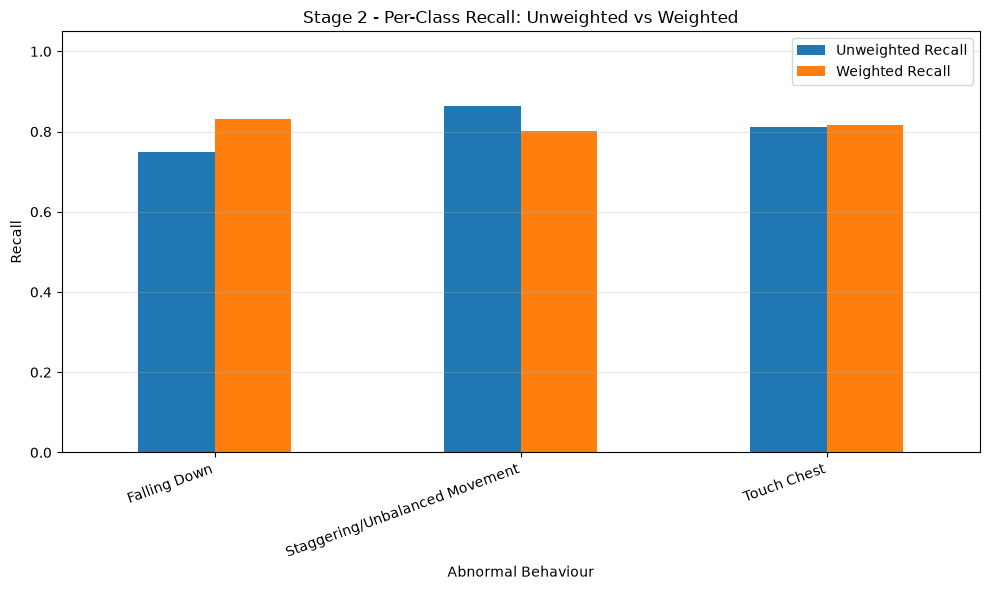

In [24]:
# Step 13B - Compare unweighted and weighted Stage 2 Gradient Boosting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef
)

# Create the unweighted baseline model
stage2_gb_unweighted = GradientBoostingClassifier(
    random_state=42
)

# Train normally without class balancing
stage2_gb_unweighted.fit(
    X_train_stage2,
    y_train_stage2
)

# Create the weighted baseline model
stage2_gb_weighted = GradientBoostingClassifier(
    random_state=42
)

# Train using the balanced sample weights calculated earlier
stage2_gb_weighted.fit(
    X_train_stage2,
    y_train_stage2,
    sample_weight=stage2_sample_weights
)

# Make validation predictions
y_val_pred_stage2_unweighted = stage2_gb_unweighted.predict(
    X_val_stage2
)

y_val_pred_stage2_weighted = stage2_gb_weighted.predict(
    X_val_stage2
)

# Define a function for multiclass evaluation
def calculate_multiclass_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "MCC": matthews_corrcoef(
            y_true,
            y_pred
        )
    }

# Calculate metrics for both models
unweighted_metrics = calculate_multiclass_metrics(
    y_val_stage2,
    y_val_pred_stage2_unweighted
)

weighted_metrics = calculate_multiclass_metrics(
    y_val_stage2,
    y_val_pred_stage2_weighted
)

# Create comparison table
stage2_comparison_df = pd.DataFrame({
    "Metric": list(unweighted_metrics.keys()),
    "Unweighted": list(unweighted_metrics.values()),
    "Weighted": list(weighted_metrics.values())
})

# Calculate improvement or decrease
stage2_comparison_df["Change"] = (
    stage2_comparison_df["Weighted"]
    - stage2_comparison_df["Unweighted"]
)

print("STAGE 2 BASELINE COMPARISON")

print(
    stage2_comparison_df.to_string(
        index=False,
        formatters={
            "Unweighted": "{:.4f}".format,
            "Weighted": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Print detailed classification report for unweighted model
print("\nUNWEIGHTED CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_stage2,
        y_val_pred_stage2_unweighted,
        digits=4
    )
)

# Print detailed classification report for weighted model
print("\nWEIGHTED CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_stage2,
        y_val_pred_stage2_weighted,
        digits=4
    )
)

# Plot overall metric comparison
stage2_comparison_df.set_index(
    "Metric"
)[
    ["Unweighted", "Weighted"]
].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Stage 2 Gradient Boosting - Unweighted vs Weighted")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Set fixed class order for confusion matrices
stage2_classes = [
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Display unweighted confusion matrix
cm_unweighted = confusion_matrix(
    y_val_stage2,
    y_val_pred_stage2_unweighted,
    labels=stage2_classes
)

disp_unweighted = ConfusionMatrixDisplay(
    confusion_matrix=cm_unweighted,
    display_labels=stage2_classes
)

disp_unweighted.plot(
    values_format="d"
)

plt.title("Stage 2 Unweighted Gradient Boosting - Confusion Matrix")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Display weighted confusion matrix
cm_weighted = confusion_matrix(
    y_val_stage2,
    y_val_pred_stage2_weighted,
    labels=stage2_classes
)

disp_weighted = ConfusionMatrixDisplay(
    confusion_matrix=cm_weighted,
    display_labels=stage2_classes
)

disp_weighted.plot(
    values_format="d"
)

plt.title("Stage 2 Weighted Gradient Boosting - Confusion Matrix")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Calculate per-class recall for both models
unweighted_class_recall = recall_score(
    y_val_stage2,
    y_val_pred_stage2_unweighted,
    labels=stage2_classes,
    average=None
)

weighted_class_recall = recall_score(
    y_val_stage2,
    y_val_pred_stage2_weighted,
    labels=stage2_classes,
    average=None
)

stage2_recall_df = pd.DataFrame({
    "Class": stage2_classes,
    "Unweighted Recall": unweighted_class_recall,
    "Weighted Recall": weighted_class_recall
})

print("\nPER-CLASS RECALL COMPARISON")

print(
    stage2_recall_df.to_string(
        index=False,
        formatters={
            "Unweighted Recall": "{:.4f}".format,
            "Weighted Recall": "{:.4f}".format
        }
    )
)

# Plot per-class recall comparison
stage2_recall_df.set_index(
    "Class"
)[
    ["Unweighted Recall", "Weighted Recall"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Recall")
plt.xlabel("Abnormal Behaviour")
plt.title("Stage 2 - Per-Class Recall: Unweighted vs Weighted")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# Step 13C - Prepare subject-wise cross-validation for Stage 2

from sklearn.model_selection import GroupKFold

# Use subject IDs only from the abnormal training dataset
stage2_train_groups = train_abnormal["subject_id"].copy()

# Create 5 subject-wise folds
stage2_group_cv = GroupKFold(
    n_splits=5
)

print("STAGE 2 SUBJECT-WISE CROSS-VALIDATION CHECK")

print("\nNumber of Stage 2 training windows:")
print(len(X_train_stage2))

print("\nNumber of unique Stage 2 training subjects:")
print(stage2_train_groups.nunique())

print("\nNumber of CV folds:")
print(stage2_group_cv.get_n_splits())

# Check every fold for subject leakage
for fold_number, (train_idx, cv_idx) in enumerate(
    stage2_group_cv.split(
        X_train_stage2,
        y_train_stage2,
        groups=stage2_train_groups
    ),
    start=1
):

    # Find subjects used for training in this fold
    train_subjects = set(
        stage2_train_groups.iloc[train_idx]
    )

    # Find subjects used for validation in this fold
    cv_subjects = set(
        stage2_train_groups.iloc[cv_idx]
    )

    # Check whether any subject appears on both sides
    overlap = train_subjects.intersection(
        cv_subjects
    )

    print(f"\nFold {fold_number}")
    print("Training windows:", len(train_idx))
    print("Validation windows:", len(cv_idx))
    print("Training subjects:", len(train_subjects))
    print("Validation subjects:", len(cv_subjects))
    print("Subject overlap:", len(overlap))

STAGE 2 SUBJECT-WISE CROSS-VALIDATION CHECK

Number of Stage 2 training windows:
7955

Number of unique Stage 2 training subjects:
28

Number of CV folds:
5

Fold 1
Training windows: 6356
Validation windows: 1599
Training subjects: 23
Validation subjects: 5
Subject overlap: 0

Fold 2
Training windows: 6369
Validation windows: 1586
Training subjects: 23
Validation subjects: 5
Subject overlap: 0

Fold 3
Training windows: 6370
Validation windows: 1585
Training subjects: 21
Validation subjects: 7
Subject overlap: 0

Fold 4
Training windows: 6362
Validation windows: 1593
Training subjects: 21
Validation subjects: 7
Subject overlap: 0

Fold 5
Training windows: 6363
Validation windows: 1592
Training subjects: 24
Validation subjects: 4
Subject overlap: 0


In [27]:
# Step 13D - Tune the unweighted Stage 2 Gradient Boosting model

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Create the base Stage 2 Gradient Boosting model
stage2_search_model_unweighted = GradientBoostingClassifier(
    random_state=42
)

# Define the hyperparameter combinations we want to explore
stage2_param_distributions = {
    "n_estimators": [
        100,
        150,
        200,
        250,
        300
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
        0.15
    ],

    "max_depth": [
        2,
        3,
        4
    ],

    "min_samples_leaf": [
        1,
        3,
        5,
        10
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

# Create the subject-wise randomized hyperparameter search
stage2_search_unweighted = RandomizedSearchCV(
    estimator=stage2_search_model_unweighted,

    param_distributions=stage2_param_distributions,

    # Try 30 random hyperparameter combinations
    n_iter=30,

    # Macro F1 gives equal importance to all three classes
    scoring="f1_macro",

    # Use the subject-wise folds created in Step 13C
    cv=stage2_group_cv,

    random_state=42,

    # Use available CPU cores for parallel model fitting
    n_jobs=-1,

    # Show search progress
    verbose=2,

    # Save training scores for later analysis
    return_train_score=True,

    # Stop if a real model/scoring error occurs
    error_score="raise"
)

# Run the hyperparameter search
stage2_search_unweighted.fit(
    X_train_stage2,
    y_train_stage2,
    groups=stage2_train_groups
)

# Show the best result
print("BEST UNWEIGHTED STAGE 2 GRADIENT BOOSTING PARAMETERS")

print("\nBest parameters:")
print(stage2_search_unweighted.best_params_)

print("\nBest subject-wise CV Macro F1:")
print(
    round(
        stage2_search_unweighted.best_score_,
        4
    )
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
BEST UNWEIGHTED STAGE 2 GRADIENT BOOSTING PARAMETERS

Best parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_depth': 4, 'learning_rate': 0.08}

Best subject-wise CV Macro F1:
0.8523


In [28]:
# Step 13E - Tune weighted Stage 2 Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight

# Create a Gradient Boosting classifier that automatically
# calculates balanced sample weights inside every CV training fold
class BalancedGradientBoostingClassifier(GradientBoostingClassifier):

    def fit(self, X, y, sample_weight=None, monitor=None):

        # Calculate balanced weights using only the labels
        # available in the current training fold
        balanced_weights = compute_sample_weight(
            class_weight="balanced",
            y=y
        )

        # Train Gradient Boosting using those balanced weights
        return super().fit(
            X,
            y,
            sample_weight=balanced_weights,
            monitor=monitor
        )


# Create the weighted Stage 2 model
stage2_search_model_weighted = BalancedGradientBoostingClassifier(
    random_state=42
)

# Use exactly the same parameter search space
# as the unweighted model for a fair comparison
stage2_param_distributions_weighted = {
    "n_estimators": [
        100,
        150,
        200,
        250,
        300
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
        0.15
    ],

    "max_depth": [
        2,
        3,
        4
    ],

    "min_samples_leaf": [
        1,
        3,
        5,
        10
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

# Create the weighted randomized search
stage2_search_weighted = RandomizedSearchCV(
    estimator=stage2_search_model_weighted,

    param_distributions=stage2_param_distributions_weighted,

    # Test the same number of parameter combinations
    n_iter=30,

    # Give all three abnormal classes equal importance
    scoring="f1_macro",

    # Keep subjects separated during CV
    cv=stage2_group_cv,

    random_state=42,

    # Use available CPU cores
    n_jobs=-1,

    # Display training progress
    verbose=2,

    # Store training scores for later comparison
    return_train_score=True,

    # Stop if a genuine error occurs
    error_score="raise"
)

# Run the weighted hyperparameter search
stage2_search_weighted.fit(
    X_train_stage2,
    y_train_stage2,
    groups=stage2_train_groups
)

# Display the best weighted configuration
print("BEST WEIGHTED STAGE 2 GRADIENT BOOSTING PARAMETERS")

print("\nBest parameters:")
print(stage2_search_weighted.best_params_)

print("\nBest weighted subject-wise CV Macro F1:")
print(
    round(
        stage2_search_weighted.best_score_,
        4
    )
)

print("\nBest unweighted subject-wise CV Macro F1:")
print(
    round(
        stage2_search_unweighted.best_score_,
        4
    )
)

print("\nWeighted minus unweighted CV Macro F1:")
print(
    round(
        stage2_search_weighted.best_score_
        - stage2_search_unweighted.best_score_,
        4
    )
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
BEST WEIGHTED STAGE 2 GRADIENT BOOSTING PARAMETERS

Best parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_depth': 4, 'learning_rate': 0.08}

Best weighted subject-wise CV Macro F1:
0.8509

Best unweighted subject-wise CV Macro F1:
0.8523

Weighted minus unweighted CV Macro F1:
-0.0014


TUNED STAGE 2 MODEL COMPARISON
           Metric Tuned Unweighted Tuned Weighted  Change
         Accuracy           0.8222         0.8209 -0.0013
Balanced Accuracy           0.8106         0.8188 +0.0081
  Macro Precision           0.8123         0.8102 -0.0021
     Macro Recall           0.8106         0.8188 +0.0081
         Macro F1           0.8109         0.8124 +0.0015
      Weighted F1           0.8230         0.8231 +0.0001
              MCC           0.7217         0.7236 +0.0019

TUNED UNWEIGHTED CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.7110    0.7543    0.7320       525
Staggering/Unbalanced Movement     0.8454    0.8574    0.8513      1052
                   Touch Chest     0.8807    0.8202    0.8494       684

                      accuracy                         0.8222      2261
                     macro avg     0.8123    0.8106    0.8109      2261
                  weighted avg 

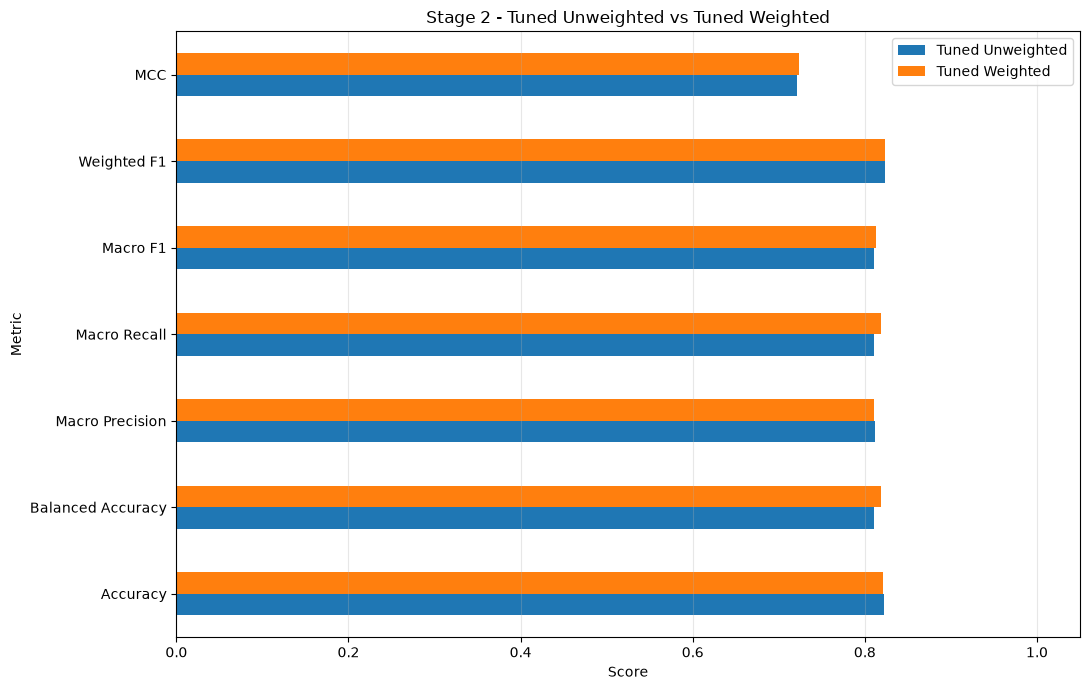

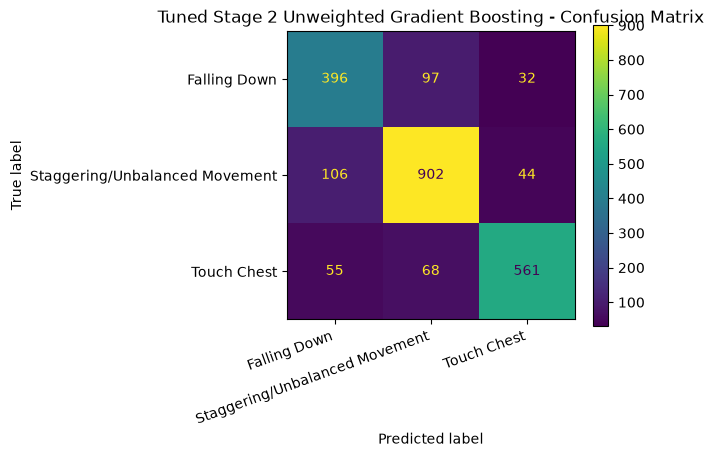

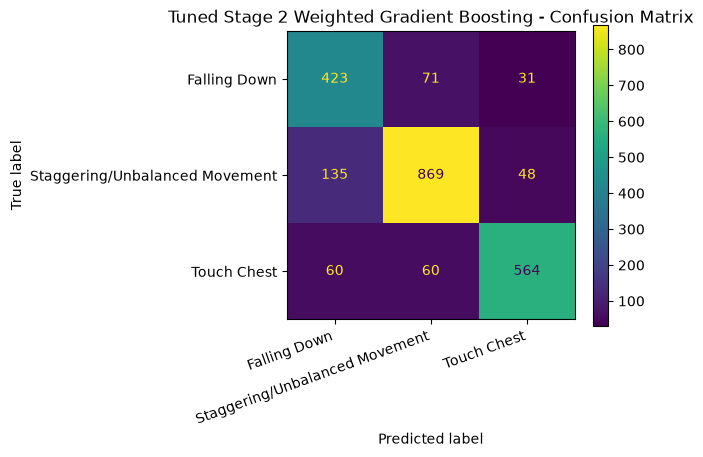


TUNED PER-CLASS RECALL COMPARISON
                         Class Tuned Unweighted Recall Tuned Weighted Recall  Change
                  Falling Down                  0.7543                0.8057 +0.0514
Staggering/Unbalanced Movement                  0.8574                0.8260 -0.0314
                   Touch Chest                  0.8202                0.8246 +0.0044


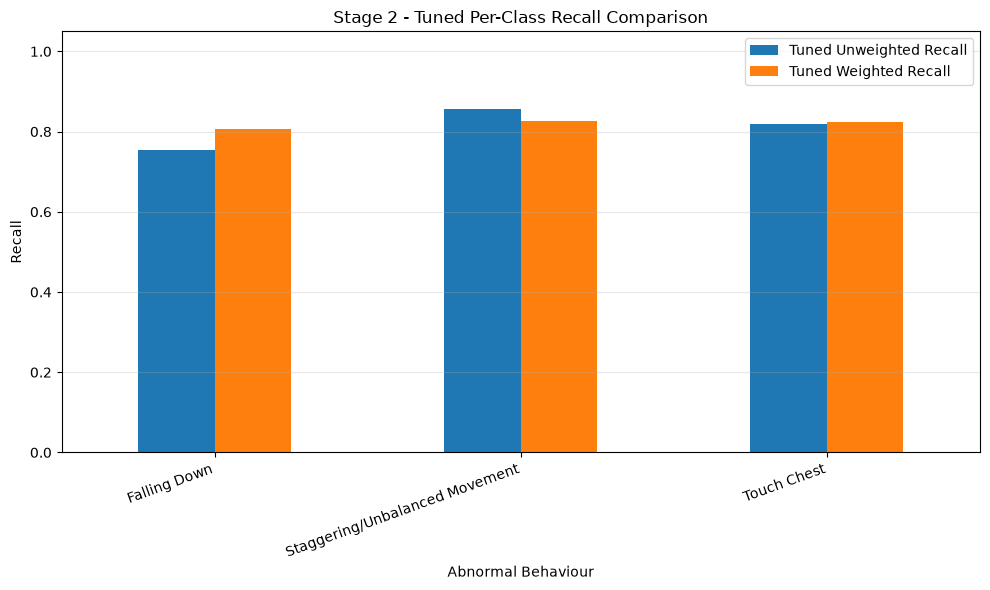

In [29]:
# Step 13F - Compare tuned unweighted and tuned weighted Stage 2 models

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef
)

# Get the best tuned unweighted model
stage2_tuned_unweighted = stage2_search_unweighted.best_estimator_

# Get the best tuned weighted model
stage2_tuned_weighted = stage2_search_weighted.best_estimator_

# Make validation predictions with the tuned unweighted model
y_val_pred_tuned_unweighted = stage2_tuned_unweighted.predict(
    X_val_stage2
)

# Make validation predictions with the tuned weighted model
y_val_pred_tuned_weighted = stage2_tuned_weighted.predict(
    X_val_stage2
)

# Define the class order
stage2_classes = [
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Create a function for calculating multiclass metrics
def calculate_stage2_metrics(y_true, y_pred):

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        "MCC": matthews_corrcoef(
            y_true,
            y_pred
        )
    }

# Calculate metrics for the tuned unweighted model
tuned_unweighted_metrics = calculate_stage2_metrics(
    y_val_stage2,
    y_val_pred_tuned_unweighted
)

# Calculate metrics for the tuned weighted model
tuned_weighted_metrics = calculate_stage2_metrics(
    y_val_stage2,
    y_val_pred_tuned_weighted
)

# Build a comparison table
tuned_stage2_comparison = pd.DataFrame({
    "Metric": list(tuned_unweighted_metrics.keys()),
    "Tuned Unweighted": list(tuned_unweighted_metrics.values()),
    "Tuned Weighted": list(tuned_weighted_metrics.values())
})

# Calculate the difference
tuned_stage2_comparison["Change"] = (
    tuned_stage2_comparison["Tuned Weighted"]
    - tuned_stage2_comparison["Tuned Unweighted"]
)

# Print the overall comparison
print("TUNED STAGE 2 MODEL COMPARISON")

print(
    tuned_stage2_comparison.to_string(
        index=False,
        formatters={
            "Tuned Unweighted": "{:.4f}".format,
            "Tuned Weighted": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Print detailed report for the tuned unweighted model
print("\nTUNED UNWEIGHTED CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_stage2,
        y_val_pred_tuned_unweighted,
        labels=stage2_classes,
        digits=4,
        zero_division=0
    )
)

# Print detailed report for the tuned weighted model
print("\nTUNED WEIGHTED CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_stage2,
        y_val_pred_tuned_weighted,
        labels=stage2_classes,
        digits=4,
        zero_division=0
    )
)

# Plot the overall metric comparison
tuned_stage2_comparison.set_index(
    "Metric"
)[
    ["Tuned Unweighted", "Tuned Weighted"]
].plot(
    kind="barh",
    figsize=(11, 7)
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Stage 2 - Tuned Unweighted vs Tuned Weighted")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate the unweighted confusion matrix
cm_tuned_unweighted = confusion_matrix(
    y_val_stage2,
    y_val_pred_tuned_unweighted,
    labels=stage2_classes
)

# Display the tuned unweighted confusion matrix
disp_unweighted = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_unweighted,
    display_labels=stage2_classes
)

disp_unweighted.plot(
    values_format="d"
)

plt.title(
    "Tuned Stage 2 Unweighted Gradient Boosting - Confusion Matrix"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Calculate the weighted confusion matrix
cm_tuned_weighted = confusion_matrix(
    y_val_stage2,
    y_val_pred_tuned_weighted,
    labels=stage2_classes
)

# Display the tuned weighted confusion matrix
disp_weighted = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned_weighted,
    display_labels=stage2_classes
)

disp_weighted.plot(
    values_format="d"
)

plt.title(
    "Tuned Stage 2 Weighted Gradient Boosting - Confusion Matrix"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Calculate per-class recall for the tuned unweighted model
tuned_unweighted_recall = recall_score(
    y_val_stage2,
    y_val_pred_tuned_unweighted,
    labels=stage2_classes,
    average=None
)

# Calculate per-class recall for the tuned weighted model
tuned_weighted_recall = recall_score(
    y_val_stage2,
    y_val_pred_tuned_weighted,
    labels=stage2_classes,
    average=None
)

# Build the per-class recall table
tuned_recall_comparison = pd.DataFrame({
    "Class": stage2_classes,
    "Tuned Unweighted Recall": tuned_unweighted_recall,
    "Tuned Weighted Recall": tuned_weighted_recall
})

# Calculate the recall change caused by weighting
tuned_recall_comparison["Change"] = (
    tuned_recall_comparison["Tuned Weighted Recall"]
    - tuned_recall_comparison["Tuned Unweighted Recall"]
)

# Print per-class recall
print("\nTUNED PER-CLASS RECALL COMPARISON")

print(
    tuned_recall_comparison.to_string(
        index=False,
        formatters={
            "Tuned Unweighted Recall": "{:.4f}".format,
            "Tuned Weighted Recall": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot per-class recall
tuned_recall_comparison.set_index(
    "Class"
)[
    [
        "Tuned Unweighted Recall",
        "Tuned Weighted Recall"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Recall")
plt.xlabel("Abnormal Behaviour")
plt.title("Stage 2 - Tuned Per-Class Recall Comparison")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [30]:
# Step 13G - Train and freeze the final Stage 2 model

from sklearn.ensemble import GradientBoostingClassifier

# Create a standard Gradient Boosting model
# using the best weighted hyperparameters
final_stage2_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=4,
    min_samples_leaf=3,
    subsample=0.7,
    random_state=42
)

# Train on the complete Stage 2 training set
# using the balanced sample weights
final_stage2_model.fit(
    X_train_stage2,
    y_train_stage2,
    sample_weight=stage2_sample_weights
)

# Show the frozen Stage 2 configuration
print("FINAL STAGE 2 CONFIGURATION")

print("\nModel:")
print("GradientBoostingClassifier")

print("\nTraining strategy:")
print("Balanced sample weighting")

print("\nSelected hyperparameters:")
print("n_estimators      =", final_stage2_model.n_estimators)
print("learning_rate     =", final_stage2_model.learning_rate)
print("max_depth         =", final_stage2_model.max_depth)
print("min_samples_leaf  =", final_stage2_model.min_samples_leaf)
print("subsample         =", final_stage2_model.subsample)
print("random_state      =", final_stage2_model.random_state)

print("\nNumber of input features:")
print(len(feature_columns))

print("\nClasses learned by model:")
print(final_stage2_model.classes_)

FINAL STAGE 2 CONFIGURATION

Model:
GradientBoostingClassifier

Training strategy:
Balanced sample weighting

Selected hyperparameters:
n_estimators      = 300
learning_rate     = 0.08
max_depth         = 4
min_samples_leaf  = 3
subsample         = 0.7
random_state      = 42

Number of input features:
20

Classes learned by model:
['Falling Down' 'Staggering/Unbalanced Movement' 'Touch Chest']


FINAL STAGE 2 - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.8209
Balanced Accuracy 0.8188
  Macro Precision 0.8102
     Macro Recall 0.8188
         Macro F1 0.8124
      Weighted F1 0.8231
              MCC 0.7236
         Log Loss 0.4605
    Macro ROC-AUC 0.9473

FINAL STAGE 2 CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.6845    0.8057    0.7402       525
Staggering/Unbalanced Movement     0.8690    0.8260    0.8470      1052
                   Touch Chest     0.8771    0.8246    0.8500       684

                      accuracy                         0.8209      2261
                     macro avg     0.8102    0.8188    0.8124      2261
                  weighted avg     0.8286    0.8209    0.8231      2261


FINAL STAGE 2 PER-CLASS RESULTS
                         Class Precision Recall F1 Score
                  Falling Down    0.6845 0.8057   0.7402
Staggering/Unbalanced Mo

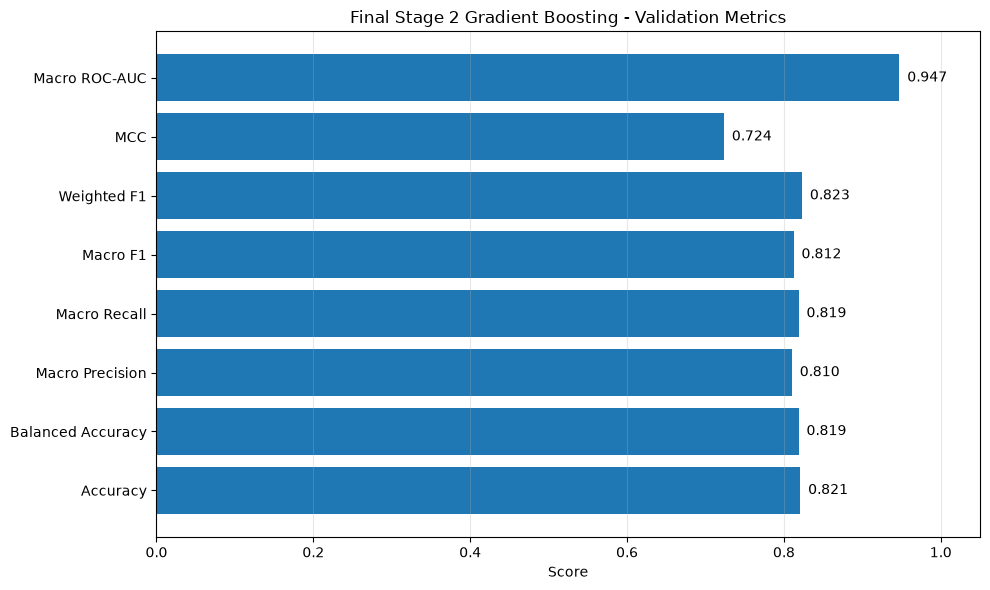

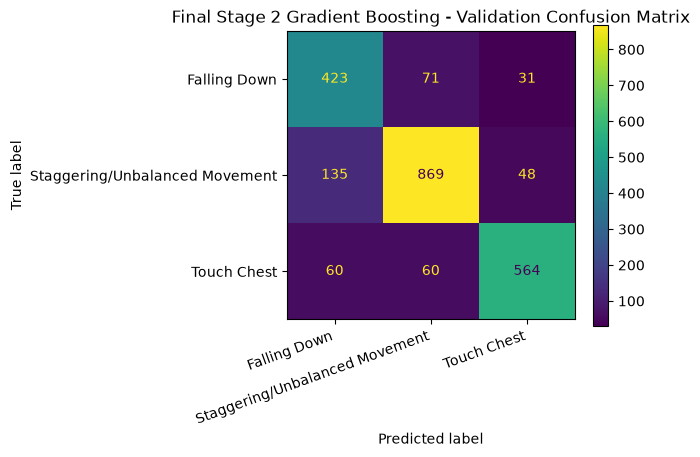

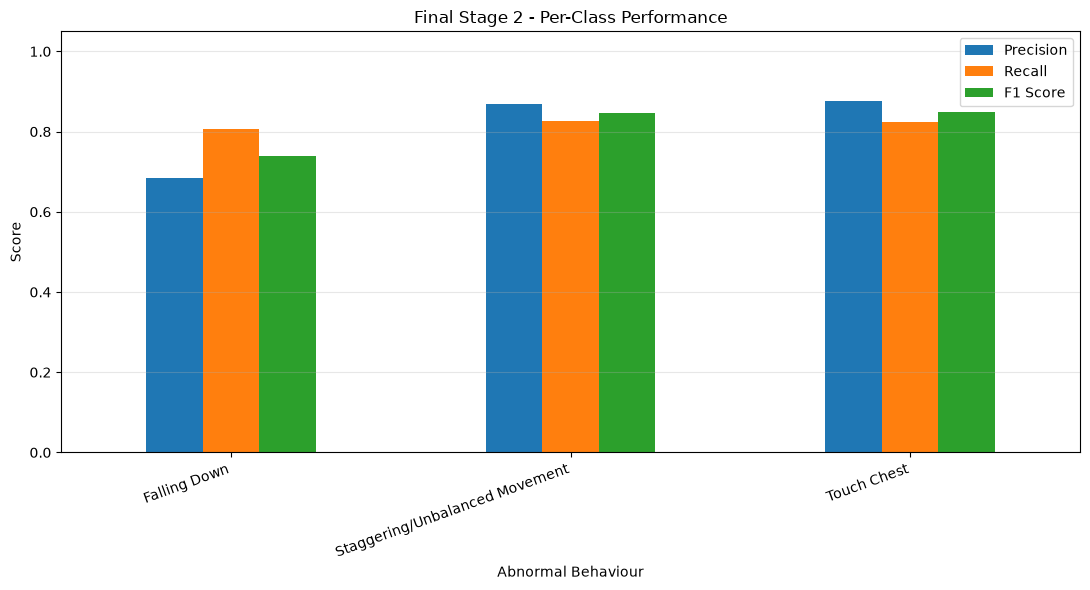

In [31]:
# Step 13H - Final Stage 2 validation evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Make predictions on the Stage 2 validation set
final_stage2_val_pred = final_stage2_model.predict(
    X_val_stage2
)

# Get class probabilities
final_stage2_val_prob = final_stage2_model.predict_proba(
    X_val_stage2
)

# Keep the final class order fixed
stage2_classes = [
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Calculate overall Stage 2 metrics
stage2_final_metrics = {
    "Accuracy": accuracy_score(
        y_val_stage2,
        final_stage2_val_pred
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_stage2,
        final_stage2_val_pred
    ),

    "Macro Precision": precision_score(
        y_val_stage2,
        final_stage2_val_pred,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_stage2,
        final_stage2_val_pred,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_stage2,
        final_stage2_val_pred,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_stage2,
        final_stage2_val_pred,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_stage2,
        final_stage2_val_pred
    ),

    "Log Loss": log_loss(
        y_val_stage2,
        final_stage2_val_prob,
        labels=final_stage2_model.classes_
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_val_stage2,
        final_stage2_val_prob,
        labels=final_stage2_model.classes_,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics to a table
stage2_final_metrics_df = pd.DataFrame({
    "Metric": stage2_final_metrics.keys(),
    "Score": stage2_final_metrics.values()
})

# Print final overall metrics
print("FINAL STAGE 2 - VALIDATION RESULTS")

print(
    stage2_final_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print detailed classification report
print("\nFINAL STAGE 2 CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_stage2,
        final_stage2_val_pred,
        labels=stage2_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
stage2_class_precision = precision_score(
    y_val_stage2,
    final_stage2_val_pred,
    labels=stage2_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
stage2_class_recall = recall_score(
    y_val_stage2,
    final_stage2_val_pred,
    labels=stage2_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1 score
stage2_class_f1 = f1_score(
    y_val_stage2,
    final_stage2_val_pred,
    labels=stage2_classes,
    average=None,
    zero_division=0
)

# Create per-class results table
stage2_class_results = pd.DataFrame({
    "Class": stage2_classes,
    "Precision": stage2_class_precision,
    "Recall": stage2_class_recall,
    "F1 Score": stage2_class_f1
})

print("\nFINAL STAGE 2 PER-CLASS RESULTS")

print(
    stage2_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Plot overall metrics
graph_metrics = stage2_final_metrics_df[
    stage2_final_metrics_df["Metric"] != "Log Loss"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    graph_metrics["Metric"],
    graph_metrics["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Final Stage 2 Gradient Boosting - Validation Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    graph_metrics["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Calculate final Stage 2 confusion matrix
final_stage2_cm = confusion_matrix(
    y_val_stage2,
    final_stage2_val_pred,
    labels=stage2_classes
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_stage2_cm,
    display_labels=stage2_classes
)

disp.plot(
    values_format="d"
)

plt.title(
    "Final Stage 2 Gradient Boosting - Validation Confusion Matrix"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot precision, recall and F1 for each abnormal behaviour
stage2_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Abnormal Behaviour")
plt.title("Final Stage 2 - Per-Class Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [32]:
# Step 13I - Save final Stage 2 model

from pathlib import Path
import joblib
import json
import sklearn

# Use the existing models folder
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Create the Stage 2 model bundle
stage2_bundle = {
    # Final trained Stage 2 model
    "model": final_stage2_model,

    # Exact feature order required by the model
    "feature_columns": list(feature_columns),

    # Model type
    "model_type": "GradientBoostingClassifier",

    # Training strategy
    "training_strategy": "Balanced sample weighting",

    # Final class order
    "classes": list(final_stage2_model.classes_),

    # Selected hyperparameters
    "hyperparameters": {
        "n_estimators": int(final_stage2_model.n_estimators),
        "learning_rate": float(final_stage2_model.learning_rate),
        "max_depth": int(final_stage2_model.max_depth),
        "min_samples_leaf": int(final_stage2_model.min_samples_leaf),
        "subsample": float(final_stage2_model.subsample),
        "random_state": int(final_stage2_model.random_state)
    },

    # Final validation metrics
    "validation_metrics": {
        key: float(value)
        for key, value in stage2_final_metrics.items()
    },

    # Per-class validation results
    "per_class_results": {
        row["Class"]: {
            "precision": float(row["Precision"]),
            "recall": float(row["Recall"]),
            "f1_score": float(row["F1 Score"])
        }
        for _, row in stage2_class_results.iterrows()
    },

    # Store scikit-learn version
    "sklearn_version": sklearn.__version__
}

# Define model file path
stage2_model_path = (
    models_dir
    / "stage2_gradient_boosting.joblib"
)

# Save the complete model bundle
joblib.dump(
    stage2_bundle,
    stage2_model_path
)

# Create readable metadata without the model object
stage2_metadata = {
    key: value
    for key, value in stage2_bundle.items()
    if key != "model"
}

# Define metadata file path
stage2_metadata_path = (
    models_dir
    / "stage2_gradient_boosting_metadata.json"
)

# Save metadata as JSON
with open(
    stage2_metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        stage2_metadata,
        f,
        indent=4
    )

# Reload the saved Stage 2 model to verify it
loaded_stage2 = joblib.load(
    stage2_model_path
)

loaded_stage2_model = loaded_stage2["model"]
loaded_stage2_features = loaded_stage2["feature_columns"]

# Make predictions on the first 10 validation samples
test_stage2_predictions = loaded_stage2_model.predict(
    X_val_stage2.iloc[:10]
)

# Print verification information
print("STAGE 2 MODEL SAVE VERIFICATION")

print("\nModel file:")
print(stage2_model_path)

print("\nMetadata file:")
print(stage2_metadata_path)

print("\nLoaded feature count:")
print(len(loaded_stage2_features))

print("\nLoaded classes:")
print(loaded_stage2_model.classes_)

print("\nFirst 10 predictions from reloaded model:")
print(test_stage2_predictions)

print("\nFiles successfully saved and reloaded.")

STAGE 2 MODEL SAVE VERIFICATION

Model file:
models\stage2_gradient_boosting.joblib

Metadata file:
models\stage2_gradient_boosting_metadata.json

Loaded feature count:
20

Loaded classes:
['Falling Down' 'Staggering/Unbalanced Movement' 'Touch Chest']

First 10 predictions from reloaded model:
['Falling Down' 'Staggering/Unbalanced Movement'
 'Staggering/Unbalanced Movement' 'Staggering/Unbalanced Movement'
 'Staggering/Unbalanced Movement' 'Staggering/Unbalanced Movement'
 'Staggering/Unbalanced Movement' 'Staggering/Unbalanced Movement'
 'Staggering/Unbalanced Movement' 'Staggering/Unbalanced Movement']

Files successfully saved and reloaded.


END-TO-END HIERARCHICAL VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7262
Balanced Accuracy 0.7160
  Macro Precision 0.6802
     Macro Recall 0.7160
         Macro F1 0.6929
      Weighted F1 0.7305
              MCC 0.6092

END-TO-END CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.8433    0.7262    0.7804      2060
                  Falling Down     0.5214    0.7181    0.6042       525
Staggering/Unbalanced Movement     0.7427    0.7985    0.7696      1052
                   Touch Chest     0.6133    0.6213    0.6173       684

                      accuracy                         0.7262      4321
                     macro avg     0.6802    0.7160    0.6929      4321
                  weighted avg     0.7433    0.7262    0.7305      4321


END-TO-END PER-CLASS RESULTS
                         Class Precision Recall F1 Score
               Normal Activity    0.8433 0.7262   0.7804


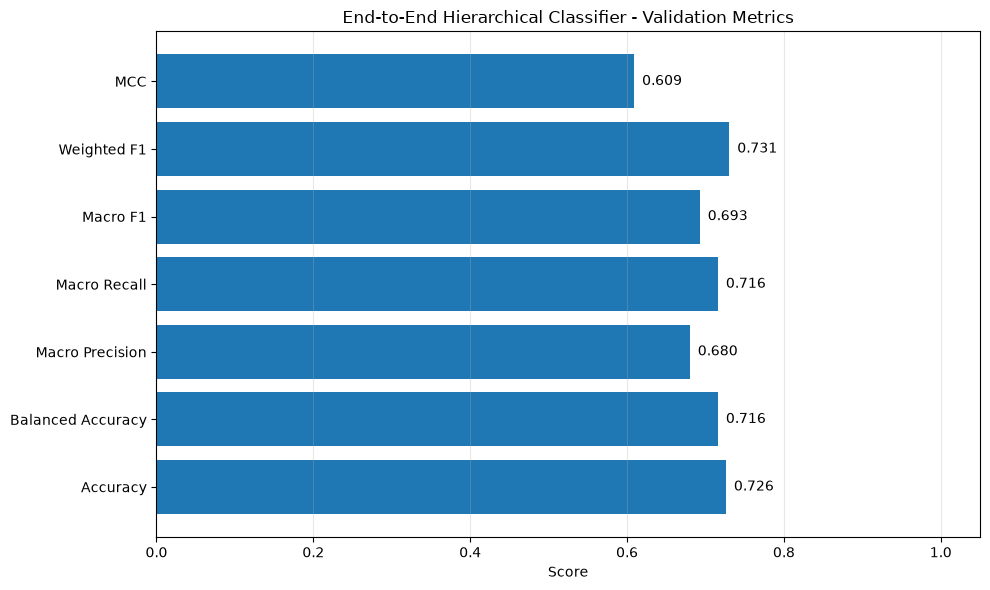

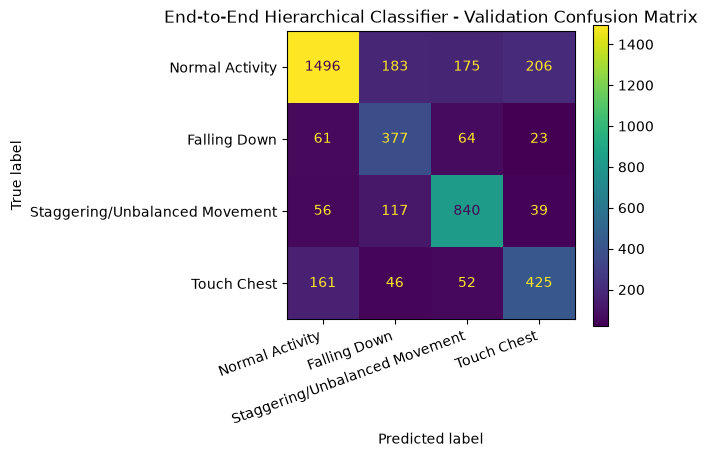

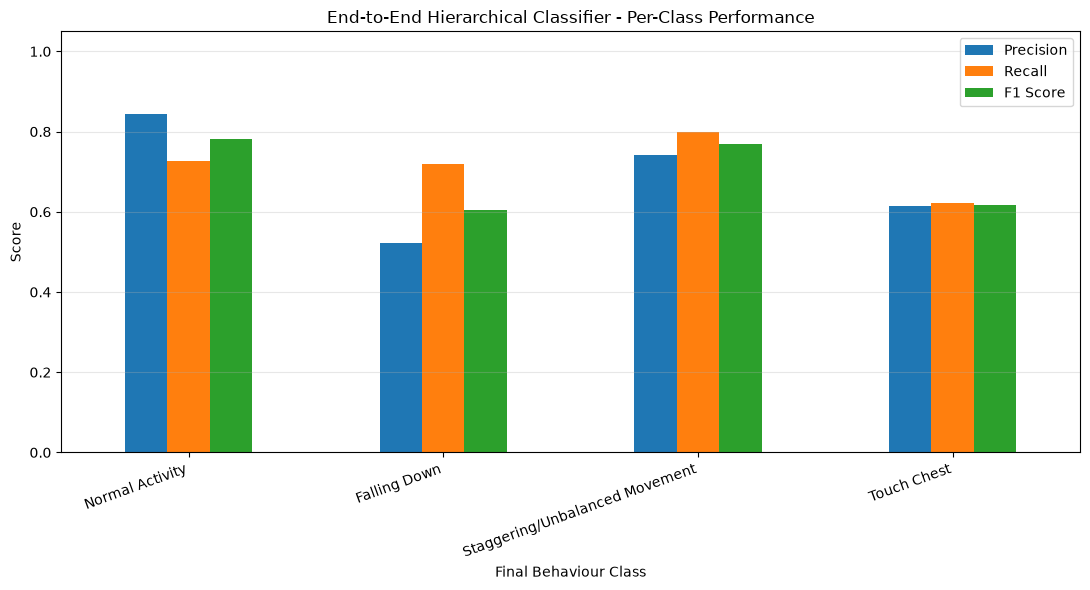

In [33]:
# Step 14A - Evaluate the complete Stage 1 + Stage 2 hierarchical system

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef
)

# Get Stage 1 abnormal probability for every validation window
stage1_abnormal_index = list(
    final_stage1_model.classes_
).index("Abnormal")

stage1_val_abnormal_probability = (
    final_stage1_model.predict_proba(
        X_val_stage1
    )[:, stage1_abnormal_index]
)

# Apply the final Stage 1 threshold
stage1_val_is_abnormal = (
    stage1_val_abnormal_probability
    >= STAGE1_THRESHOLD
)

# Start by predicting every validation window as Normal Activity
final_hierarchical_predictions = np.full(
    len(X_val_stage1),
    "Normal Activity",
    dtype=object
)

# Find the validation windows that Stage 1 considers abnormal
abnormal_positions = np.where(
    stage1_val_is_abnormal
)[0]

# Send only Stage 1 abnormal windows into Stage 2
X_stage2_from_stage1 = X_val_stage1.iloc[
    abnormal_positions
]

# Predict the abnormal behaviour using Stage 2
stage2_predictions_from_stage1 = (
    final_stage2_model.predict(
        X_stage2_from_stage1
    )
)

# Replace Normal Activity with the Stage 2 prediction
# only for windows Stage 1 marked abnormal
final_hierarchical_predictions[
    abnormal_positions
] = stage2_predictions_from_stage1

# Keep the final four-class order fixed
final_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Calculate overall end-to-end metrics
hierarchical_metrics = {
    "Accuracy": accuracy_score(
        val_df["label"],
        final_hierarchical_predictions
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        val_df["label"],
        final_hierarchical_predictions
    ),

    "Macro Precision": precision_score(
        val_df["label"],
        final_hierarchical_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        val_df["label"],
        final_hierarchical_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        val_df["label"],
        final_hierarchical_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        val_df["label"],
        final_hierarchical_predictions,
        labels=final_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        val_df["label"],
        final_hierarchical_predictions
    )
}

# Convert metrics into a table
hierarchical_metrics_df = pd.DataFrame({
    "Metric": hierarchical_metrics.keys(),
    "Score": hierarchical_metrics.values()
})

# Print the final hierarchical metrics
print("END-TO-END HIERARCHICAL VALIDATION RESULTS")

print(
    hierarchical_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print the full four-class classification report
print("\nEND-TO-END CLASSIFICATION REPORT")

print(
    classification_report(
        val_df["label"],
        final_hierarchical_predictions,
        labels=final_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
hierarchical_class_precision = precision_score(
    val_df["label"],
    final_hierarchical_predictions,
    labels=final_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
hierarchical_class_recall = recall_score(
    val_df["label"],
    final_hierarchical_predictions,
    labels=final_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1
hierarchical_class_f1 = f1_score(
    val_df["label"],
    final_hierarchical_predictions,
    labels=final_classes,
    average=None,
    zero_division=0
)

# Build the per-class performance table
hierarchical_class_results = pd.DataFrame({
    "Class": final_classes,
    "Precision": hierarchical_class_precision,
    "Recall": hierarchical_class_recall,
    "F1 Score": hierarchical_class_f1
})

print("\nEND-TO-END PER-CLASS RESULTS")

print(
    hierarchical_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Show how many windows Stage 1 passed into Stage 2
print("\nPIPELINE FLOW")

print(
    "Total validation windows:",
    len(X_val_stage1)
)

print(
    "Predicted Normal by Stage 1:",
    (~stage1_val_is_abnormal).sum()
)

print(
    "Passed into Stage 2:",
    stage1_val_is_abnormal.sum()
)

# Plot the overall end-to-end metrics
plt.figure(figsize=(10, 6))

bars = plt.barh(
    hierarchical_metrics_df["Metric"],
    hierarchical_metrics_df["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("End-to-End Hierarchical Classifier - Validation Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    hierarchical_metrics_df["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Calculate the four-class confusion matrix
hierarchical_cm = confusion_matrix(
    val_df["label"],
    final_hierarchical_predictions,
    labels=final_classes
)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=hierarchical_cm,
    display_labels=final_classes
)

disp.plot(
    values_format="d"
)

plt.title(
    "End-to-End Hierarchical Classifier - Validation Confusion Matrix"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot precision, recall and F1 for each final class
hierarchical_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Final Behaviour Class")
plt.title("End-to-End Hierarchical Classifier - Per-Class Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

END-TO-END THRESHOLD COMPARISON
 Threshold  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1  Normal Recall  Falling Recall  Staggering Recall  Touch Chest Recall  Passed to Stage 2
      0.20    0.6822             0.7177           0.6509        0.7177    0.6641       0.6884         0.5893          0.7790             0.8080              0.6944               2963
      0.25    0.7028             0.7236           0.6641        0.7236    0.6803       0.7090         0.6422          0.7695             0.8042              0.6784               2818
      0.30    0.7153             0.7194           0.6713        0.7194    0.6867       0.7211         0.6869          0.7371             0.8013              0.6520               2682
      0.35    0.7262             0.7160           0.6802        0.7160    0.6929       0.7305         0.7262          0.7181             0.7985              0.6213               2547
      0.40    0.7306             0.7069           0.6

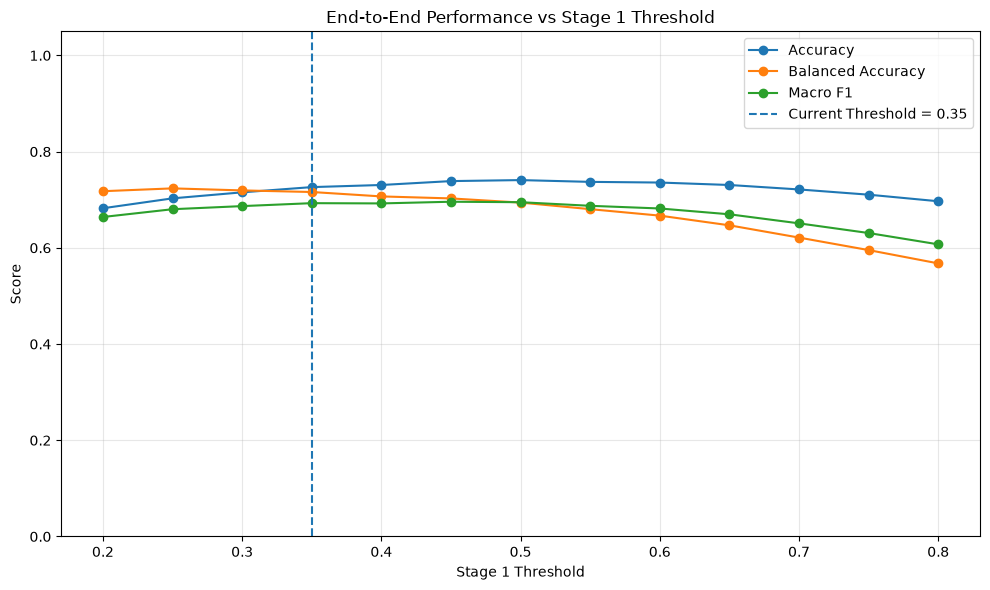

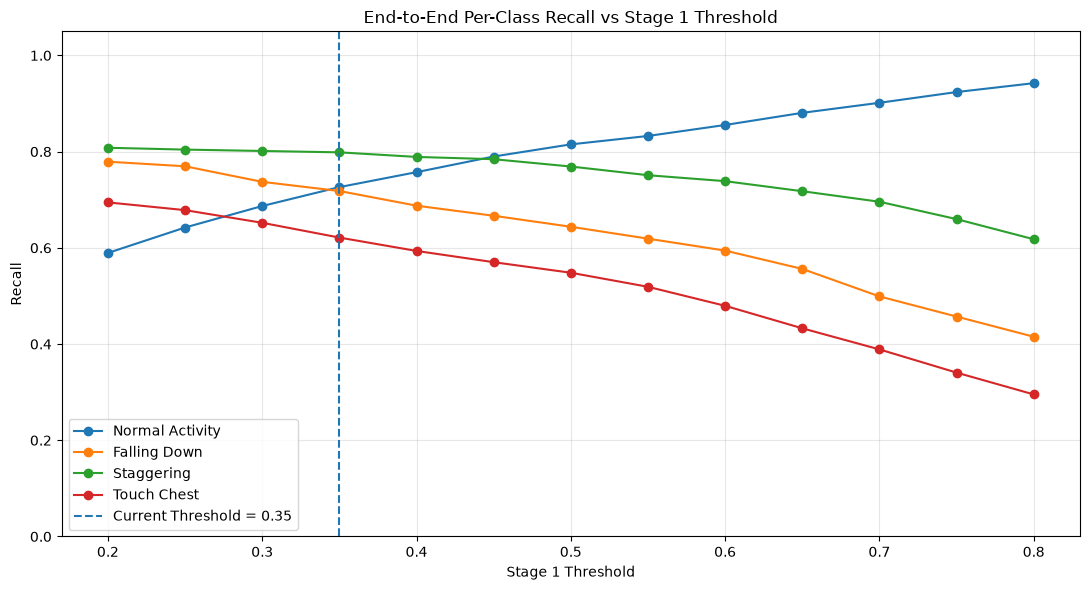

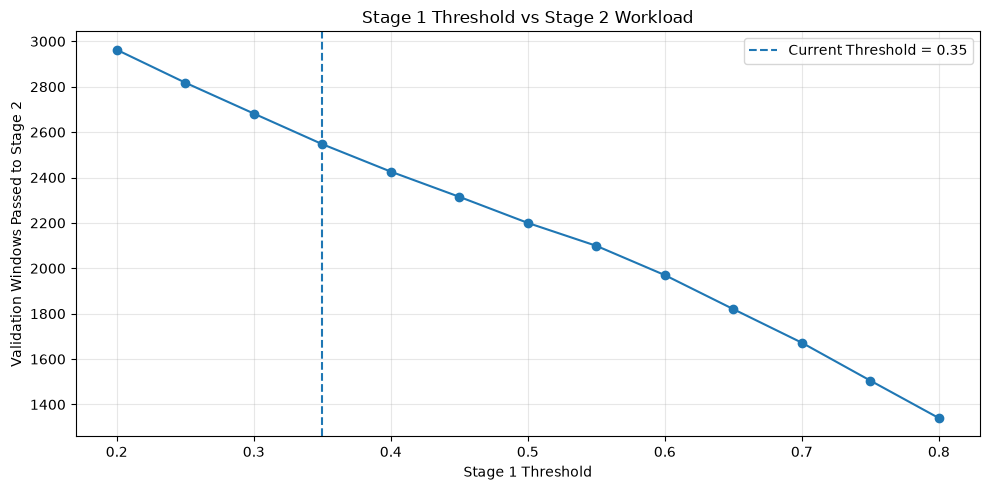

In [34]:
# Step 14B - Optimize Stage 1 threshold using end-to-end performance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Get Stage 1 abnormal probabilities for all validation windows
stage1_abnormal_index = list(
    final_stage1_model.classes_
).index("Abnormal")

stage1_val_probabilities = (
    final_stage1_model.predict_proba(
        X_val_stage1
    )[:, stage1_abnormal_index]
)

# Test a range of Stage 1 thresholds
thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

# Keep the final class order fixed
final_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Store results from every threshold
end_to_end_threshold_results = []

for threshold in thresholds:

    # Decide which validation windows Stage 1 sends to Stage 2
    stage1_is_abnormal = (
        stage1_val_probabilities >= threshold
    )

    # Start by predicting every window as Normal Activity
    final_predictions = np.full(
        len(X_val_stage1),
        "Normal Activity",
        dtype=object
    )

    # Find positions marked abnormal by Stage 1
    abnormal_positions = np.where(
        stage1_is_abnormal
    )[0]

    # Send only those windows into Stage 2
    if len(abnormal_positions) > 0:

        X_for_stage2 = X_val_stage1.iloc[
            abnormal_positions
        ]

        stage2_predictions = final_stage2_model.predict(
            X_for_stage2
        )

        final_predictions[
            abnormal_positions
        ] = stage2_predictions

    # Calculate overall end-to-end metrics
    accuracy = accuracy_score(
        val_df["label"],
        final_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        val_df["label"],
        final_predictions
    )

    macro_precision = precision_score(
        val_df["label"],
        final_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        val_df["label"],
        final_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        val_df["label"],
        final_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        val_df["label"],
        final_predictions,
        labels=final_classes,
        average="weighted",
        zero_division=0
    )

    # Calculate recall for each final class
    per_class_recall = recall_score(
        val_df["label"],
        final_predictions,
        labels=final_classes,
        average=None,
        zero_division=0
    )

    # Store the results
    end_to_end_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Normal Recall": per_class_recall[0],
        "Falling Recall": per_class_recall[1],
        "Staggering Recall": per_class_recall[2],
        "Touch Chest Recall": per_class_recall[3],
        "Passed to Stage 2": int(
            stage1_is_abnormal.sum()
        )
    })

# Convert all threshold results into a DataFrame
end_to_end_threshold_df = pd.DataFrame(
    end_to_end_threshold_results
)

# Print the complete threshold comparison
print("END-TO-END THRESHOLD COMPARISON")

print(
    end_to_end_threshold_df.round(4).to_string(
        index=False
    )
)

# Find the threshold with the highest Macro F1
best_macro_f1_row = end_to_end_threshold_df.loc[
    end_to_end_threshold_df["Macro F1"].idxmax()
]

print("\nBEST THRESHOLD BY END-TO-END MACRO F1")

print(
    best_macro_f1_row.round(4)
)

# Plot overall end-to-end metrics across thresholds
plt.figure(figsize=(10, 6))

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Balanced Accuracy"],
    marker="o",
    label="Balanced Accuracy"
)

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="Current Threshold = 0.35"
)

plt.xlabel("Stage 1 Threshold")
plt.ylabel("Score")
plt.title("End-to-End Performance vs Stage 1 Threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot per-class recall across thresholds
plt.figure(figsize=(11, 6))

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Normal Recall"],
    marker="o",
    label="Normal Activity"
)

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Falling Recall"],
    marker="o",
    label="Falling Down"
)

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Staggering Recall"],
    marker="o",
    label="Staggering"
)

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Touch Chest Recall"],
    marker="o",
    label="Touch Chest"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="Current Threshold = 0.35"
)

plt.xlabel("Stage 1 Threshold")
plt.ylabel("Recall")
plt.title("End-to-End Per-Class Recall vs Stage 1 Threshold")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot how many windows are passed into Stage 2
plt.figure(figsize=(10, 5))

plt.plot(
    end_to_end_threshold_df["Threshold"],
    end_to_end_threshold_df["Passed to Stage 2"],
    marker="o"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="Current Threshold = 0.35"
)

plt.xlabel("Stage 1 Threshold")
plt.ylabel("Validation Windows Passed to Stage 2")
plt.title("Stage 1 Threshold vs Stage 2 Workload")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

DIRECT 4-CLASS GRADIENT BOOSTING - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7366
Balanced Accuracy 0.6637
  Macro Precision 0.7227
     Macro Recall 0.6637
         Macro F1 0.6852
      Weighted F1 0.7289
              MCC 0.5989

DIRECT 4-CLASS CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.7320    0.8524    0.7876      2060
                  Falling Down     0.6682    0.5676    0.6138       525
Staggering/Unbalanced Movement     0.7963    0.7728    0.7844      1052
                   Touch Chest     0.6945    0.4620    0.5549       684

                      accuracy                         0.7366      4321
                     macro avg     0.7227    0.6637    0.6852      4321
                  weighted avg     0.7339    0.7366    0.7289      4321


DIRECT 4-CLASS PER-CLASS RESULTS
                         Class Precision Recall F1 Score
               Normal Activity    0.73

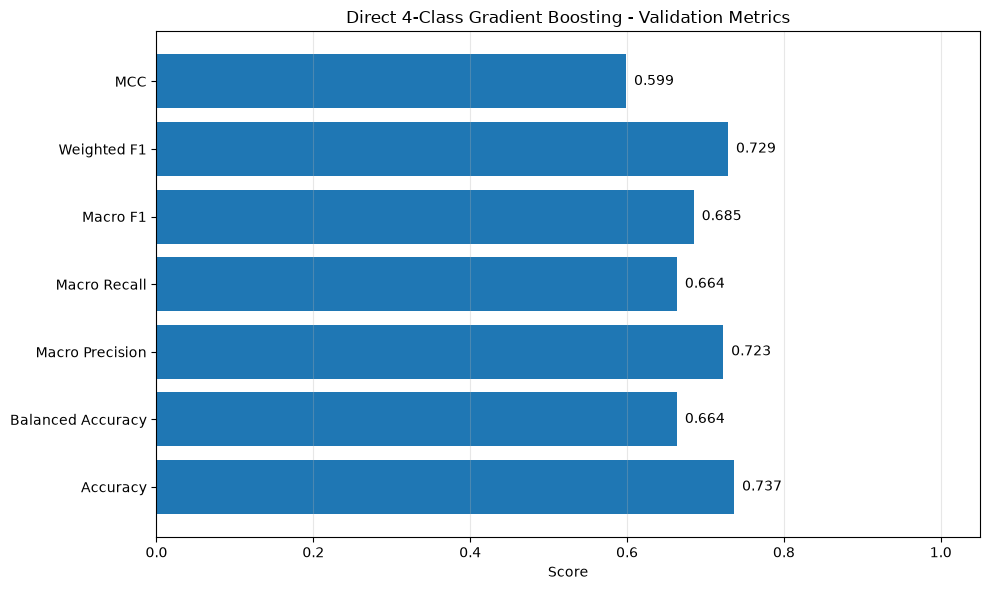

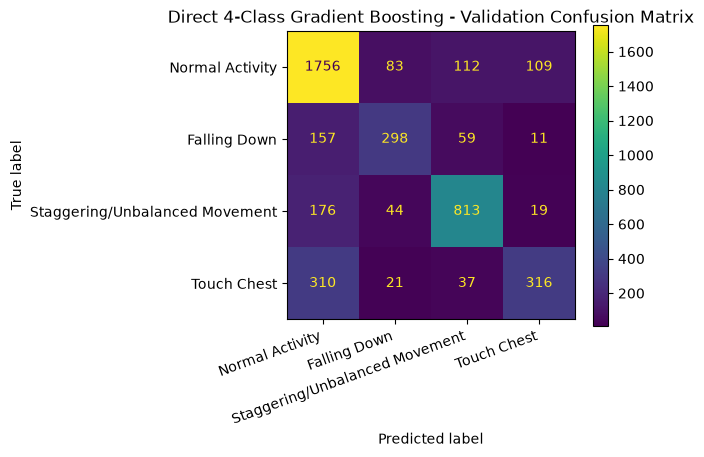

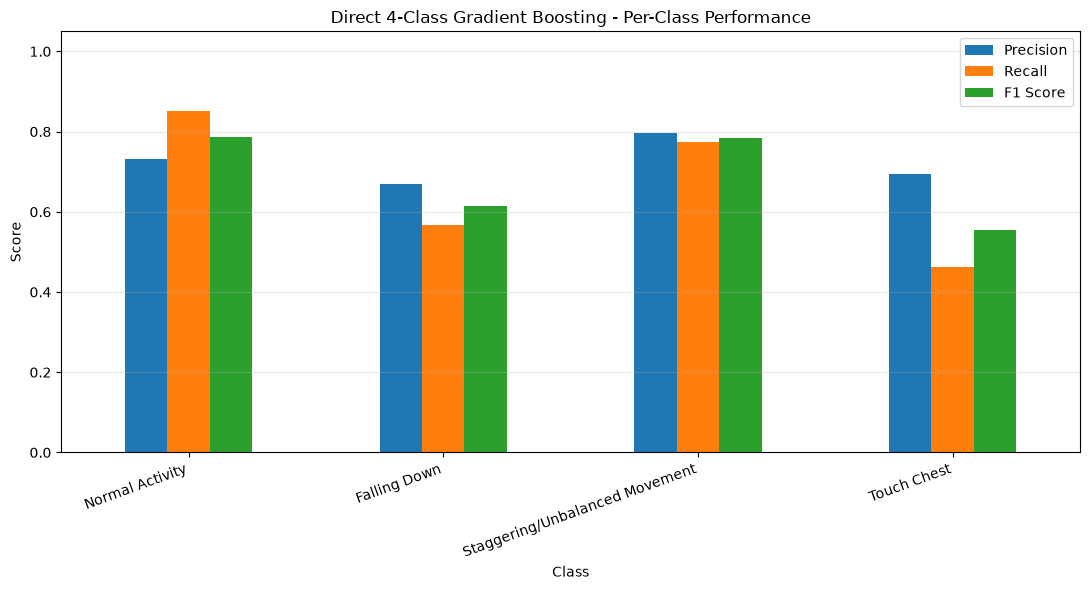

In [35]:
# Step 15A - Train a direct 4-class Gradient Boosting baseline

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef
)

# Use all 20 features directly
X_train_direct = train_df[feature_columns].copy()
X_val_direct = val_df[feature_columns].copy()

# Use the original 4-class labels
y_train_direct = train_df["label"].copy()
y_val_direct = val_df["label"].copy()

# Create the direct 4-class Gradient Boosting baseline
direct_gb_baseline = GradientBoostingClassifier(
    random_state=42
)

# Train the model
direct_gb_baseline.fit(
    X_train_direct,
    y_train_direct
)

# Make validation predictions
y_val_pred_direct = direct_gb_baseline.predict(
    X_val_direct
)

# Keep class order fixed
direct_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Calculate overall metrics
direct_metrics = {
    "Accuracy": accuracy_score(
        y_val_direct,
        y_val_pred_direct
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_direct,
        y_val_pred_direct
    ),

    "Macro Precision": precision_score(
        y_val_direct,
        y_val_pred_direct,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_direct,
        y_val_pred_direct,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_direct,
        y_val_pred_direct,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_direct,
        y_val_pred_direct,
        labels=direct_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_direct,
        y_val_pred_direct
    )
}

# Convert metrics to a table
direct_metrics_df = pd.DataFrame({
    "Metric": direct_metrics.keys(),
    "Score": direct_metrics.values()
})

# Print overall validation metrics
print("DIRECT 4-CLASS GRADIENT BOOSTING - VALIDATION RESULTS")

print(
    direct_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print detailed classification report
print("\nDIRECT 4-CLASS CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_direct,
        y_val_pred_direct,
        labels=direct_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
direct_class_precision = precision_score(
    y_val_direct,
    y_val_pred_direct,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
direct_class_recall = recall_score(
    y_val_direct,
    y_val_pred_direct,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1
direct_class_f1 = f1_score(
    y_val_direct,
    y_val_pred_direct,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Build per-class results table
direct_class_results = pd.DataFrame({
    "Class": direct_classes,
    "Precision": direct_class_precision,
    "Recall": direct_class_recall,
    "F1 Score": direct_class_f1
})

print("\nDIRECT 4-CLASS PER-CLASS RESULTS")

print(
    direct_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Plot overall metrics
plt.figure(figsize=(10, 6))

bars = plt.barh(
    direct_metrics_df["Metric"],
    direct_metrics_df["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Direct 4-Class Gradient Boosting - Validation Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    direct_metrics_df["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Calculate confusion matrix
direct_cm = confusion_matrix(
    y_val_direct,
    y_val_pred_direct,
    labels=direct_classes
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=direct_cm,
    display_labels=direct_classes
)

disp.plot(
    values_format="d"
)

plt.title(
    "Direct 4-Class Gradient Boosting - Validation Confusion Matrix"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot per-class performance
direct_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Class")
plt.title("Direct 4-Class Gradient Boosting - Per-Class Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [36]:
# Step 15B - Tune weighted direct 4-class Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.utils.class_weight import compute_sample_weight

# Use subject IDs from the full 4-class training set
direct_train_groups = train_df["subject_id"].copy()

# Create subject-wise cross-validation
direct_group_cv = GroupKFold(
    n_splits=5
)

# Create a Gradient Boosting classifier that calculates
# balanced sample weights inside each training fold
class BalancedDirectGradientBoostingClassifier(GradientBoostingClassifier):

    def fit(self, X, y, sample_weight=None, monitor=None):

        # Calculate balanced weights using only the labels
        # available in the current training fold
        balanced_weights = compute_sample_weight(
            class_weight="balanced",
            y=y
        )

        # Train using the balanced weights
        return super().fit(
            X,
            y,
            sample_weight=balanced_weights,
            monitor=monitor
        )

# Create the weighted direct 4-class model
direct_weighted_search_model = BalancedDirectGradientBoostingClassifier(
    random_state=42
)

# Define the hyperparameter search space
direct_param_distributions = {
    "n_estimators": [
        100,
        150,
        200,
        250,
        300
    ],

    "learning_rate": [
        0.03,
        0.05,
        0.08,
        0.10,
        0.15
    ],

    "max_depth": [
        2,
        3,
        4
    ],

    "min_samples_leaf": [
        1,
        3,
        5,
        10
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ]
}

# Create the randomized subject-wise search
direct_weighted_search = RandomizedSearchCV(
    estimator=direct_weighted_search_model,

    param_distributions=direct_param_distributions,

    # Test 30 random parameter combinations
    n_iter=30,

    # Give all four classes equal importance
    scoring="f1_macro",

    # Keep subjects separated
    cv=direct_group_cv,

    random_state=42,

    # Use all available CPU cores
    n_jobs=-1,

    # Show fitting progress
    verbose=2,

    # Save train scores for later inspection
    return_train_score=True,

    # Stop if a real error occurs
    error_score="raise"
)

# Run the search
direct_weighted_search.fit(
    X_train_direct,
    y_train_direct,
    groups=direct_train_groups
)

# Print the best result
print("BEST WEIGHTED DIRECT 4-CLASS GRADIENT BOOSTING PARAMETERS")

print("\nBest parameters:")
print(
    direct_weighted_search.best_params_
)

print("\nBest subject-wise CV Macro F1:")
print(
    round(
        direct_weighted_search.best_score_,
        4
    )
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
BEST WEIGHTED DIRECT 4-CLASS GRADIENT BOOSTING PARAMETERS

Best parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_samples_leaf': 3, 'max_depth': 4, 'learning_rate': 0.08}

Best subject-wise CV Macro F1:
0.7402


TUNED WEIGHTED DIRECT 4-CLASS - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7297
Balanced Accuracy 0.7112
  Macro Precision 0.6866
     Macro Recall 0.7112
         Macro F1 0.6960
      Weighted F1 0.7329
              MCC 0.6075

TUNED WEIGHTED DIRECT 4-CLASS CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.8114    0.7500    0.7795      2060
                  Falling Down     0.5376    0.6952    0.6063       525
Staggering/Unbalanced Movement     0.7781    0.7766    0.7774      1052
                   Touch Chest     0.6192    0.6228    0.6210       684

                      accuracy                         0.7297      4321
                     macro avg     0.6866    0.7112    0.6960      4321
                  weighted avg     0.7396    0.7297    0.7329      4321


TUNED WEIGHTED DIRECT PER-CLASS RESULTS
                         Class Precision Recall F1 Score
               Norm

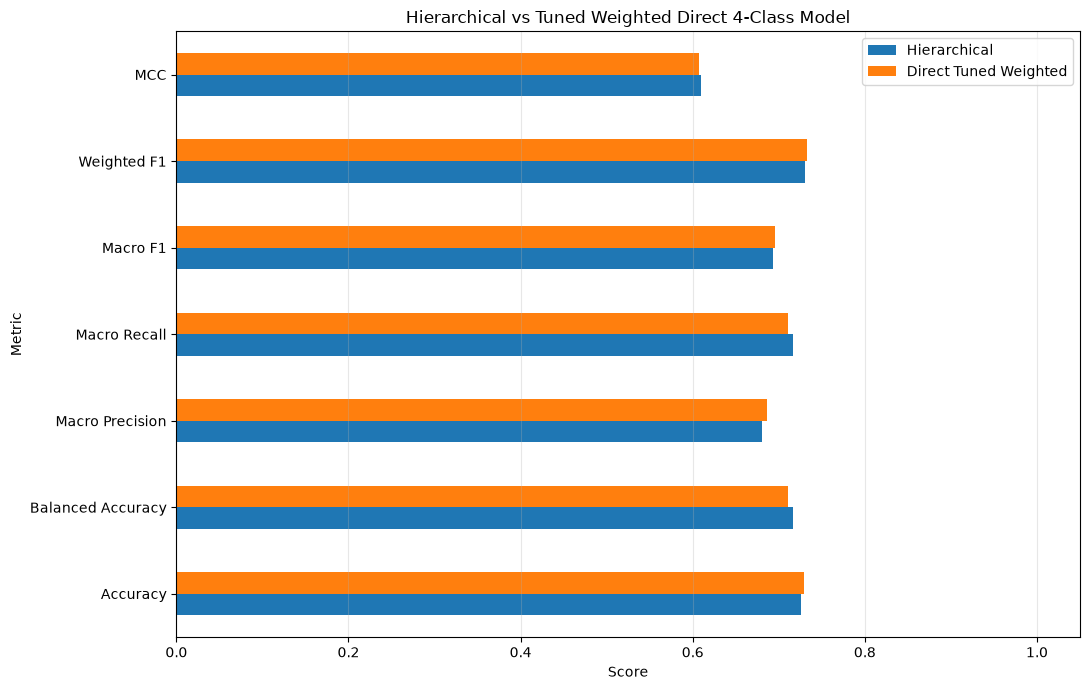

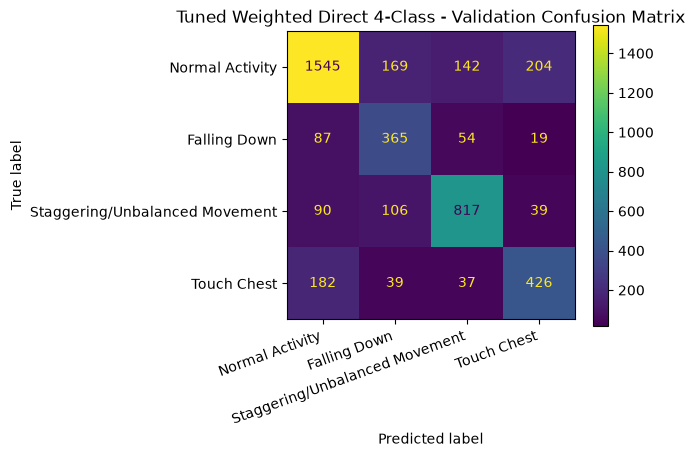


PER-CLASS RECALL - ARCHITECTURE COMPARISON
                         Class Hierarchical Recall Direct Tuned Recall  Change
               Normal Activity              0.7262              0.7500 +0.0238
                  Falling Down              0.7181              0.6952 -0.0229
Staggering/Unbalanced Movement              0.7985              0.7766 -0.0219
                   Touch Chest              0.6213              0.6228 +0.0015


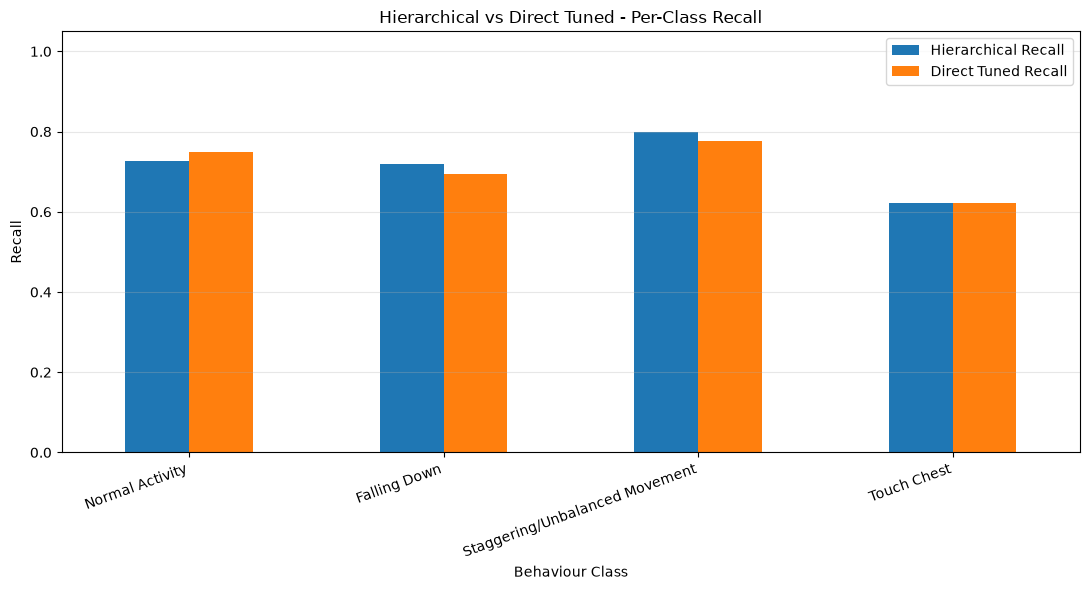

In [37]:
# Step 15C - Evaluate the tuned weighted direct 4-class model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef
)

# Calculate balanced sample weights for the full direct training dataset
direct_training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_direct
)

# Create a standard Gradient Boosting model using the winning parameters
direct_gb_tuned_weighted = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=4,
    min_samples_leaf=3,
    subsample=0.7,
    random_state=42
)

# Train the final direct candidate using balanced sample weighting
direct_gb_tuned_weighted.fit(
    X_train_direct,
    y_train_direct,
    sample_weight=direct_training_weights
)

# Predict the separate validation set
y_val_pred_direct_tuned = direct_gb_tuned_weighted.predict(
    X_val_direct
)

# Keep the same four-class order
direct_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Calculate overall validation metrics
direct_tuned_metrics = {
    "Accuracy": accuracy_score(
        y_val_direct,
        y_val_pred_direct_tuned
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_direct,
        y_val_pred_direct_tuned
    ),

    "Macro Precision": precision_score(
        y_val_direct,
        y_val_pred_direct_tuned,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_direct,
        y_val_pred_direct_tuned,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_direct,
        y_val_pred_direct_tuned,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_direct,
        y_val_pred_direct_tuned,
        labels=direct_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_direct,
        y_val_pred_direct_tuned
    )
}

# Convert metrics to a table
direct_tuned_metrics_df = pd.DataFrame({
    "Metric": direct_tuned_metrics.keys(),
    "Score": direct_tuned_metrics.values()
})

print("TUNED WEIGHTED DIRECT 4-CLASS - VALIDATION RESULTS")

print(
    direct_tuned_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print the full four-class classification report
print("\nTUNED WEIGHTED DIRECT 4-CLASS CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_direct,
        y_val_pred_direct_tuned,
        labels=direct_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
direct_tuned_precision = precision_score(
    y_val_direct,
    y_val_pred_direct_tuned,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
direct_tuned_recall = recall_score(
    y_val_direct,
    y_val_pred_direct_tuned,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1
direct_tuned_f1 = f1_score(
    y_val_direct,
    y_val_pred_direct_tuned,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Build per-class results
direct_tuned_class_results = pd.DataFrame({
    "Class": direct_classes,
    "Precision": direct_tuned_precision,
    "Recall": direct_tuned_recall,
    "F1 Score": direct_tuned_f1
})

print("\nTUNED WEIGHTED DIRECT PER-CLASS RESULTS")

print(
    direct_tuned_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Compare the tuned direct model against the current hierarchical system
architecture_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "MCC"
    ],

    "Hierarchical": [
        hierarchical_metrics["Accuracy"],
        hierarchical_metrics["Balanced Accuracy"],
        hierarchical_metrics["Macro Precision"],
        hierarchical_metrics["Macro Recall"],
        hierarchical_metrics["Macro F1"],
        hierarchical_metrics["Weighted F1"],
        hierarchical_metrics["MCC"]
    ],

    "Direct Tuned Weighted": [
        direct_tuned_metrics["Accuracy"],
        direct_tuned_metrics["Balanced Accuracy"],
        direct_tuned_metrics["Macro Precision"],
        direct_tuned_metrics["Macro Recall"],
        direct_tuned_metrics["Macro F1"],
        direct_tuned_metrics["Weighted F1"],
        direct_tuned_metrics["MCC"]
    ]
})

architecture_comparison["Change"] = (
    architecture_comparison["Direct Tuned Weighted"]
    - architecture_comparison["Hierarchical"]
)

print("\nARCHITECTURE COMPARISON")

print(
    architecture_comparison.to_string(
        index=False,
        formatters={
            "Hierarchical": "{:.4f}".format,
            "Direct Tuned Weighted": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot overall architecture comparison
architecture_comparison.set_index(
    "Metric"
)[
    ["Hierarchical", "Direct Tuned Weighted"]
].plot(
    kind="barh",
    figsize=(11, 7)
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Hierarchical vs Tuned Weighted Direct 4-Class Model")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate confusion matrix for the tuned direct model
direct_tuned_cm = confusion_matrix(
    y_val_direct,
    y_val_pred_direct_tuned,
    labels=direct_classes
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=direct_tuned_cm,
    display_labels=direct_classes
)

disp.plot(
    values_format="d"
)

plt.title(
    "Tuned Weighted Direct 4-Class - Validation Confusion Matrix"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Compare per-class recall between the two architectures
architecture_recall_comparison = pd.DataFrame({
    "Class": direct_classes,
    "Hierarchical Recall": hierarchical_class_recall,
    "Direct Tuned Recall": direct_tuned_recall
})

architecture_recall_comparison["Change"] = (
    architecture_recall_comparison["Direct Tuned Recall"]
    - architecture_recall_comparison["Hierarchical Recall"]
)

print("\nPER-CLASS RECALL - ARCHITECTURE COMPARISON")

print(
    architecture_recall_comparison.to_string(
        index=False,
        formatters={
            "Hierarchical Recall": "{:.4f}".format,
            "Direct Tuned Recall": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot per-class recall comparison
architecture_recall_comparison.set_index(
    "Class"
)[
    ["Hierarchical Recall", "Direct Tuned Recall"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Recall")
plt.xlabel("Behaviour Class")
plt.title("Hierarchical vs Direct Tuned - Per-Class Recall")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [38]:
# Step 15D - Freeze and save the final direct 4-class model

from pathlib import Path
import joblib
import json
import sklearn

# Use the existing models folder
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Freeze the selected final direct model
final_direct_model = direct_gb_tuned_weighted

# Create a bundle containing everything needed later
direct_model_bundle = {
    # Final trained direct 4-class model
    "model": final_direct_model,

    # Exact feature order expected by the model
    "feature_columns": list(feature_columns),

    # Final output classes
    "classes": list(final_direct_model.classes_),

    # Model information
    "model_type": "GradientBoostingClassifier",

    # Training method
    "training_strategy": "Balanced sample weighting",

    # Final tuned hyperparameters
    "hyperparameters": {
        "n_estimators": int(final_direct_model.n_estimators),
        "learning_rate": float(final_direct_model.learning_rate),
        "max_depth": int(final_direct_model.max_depth),
        "min_samples_leaf": int(final_direct_model.min_samples_leaf),
        "subsample": float(final_direct_model.subsample),
        "random_state": int(final_direct_model.random_state)
    },

    # Validation metrics from Step 15C
    "validation_metrics": {
        key: float(value)
        for key, value in direct_tuned_metrics.items()
    },

    # Per-class validation results
    "per_class_results": {
        row["Class"]: {
            "precision": float(row["Precision"]),
            "recall": float(row["Recall"]),
            "f1_score": float(row["F1 Score"])
        }
        for _, row in direct_tuned_class_results.iterrows()
    },

    # Save sklearn version for reproducibility
    "sklearn_version": sklearn.__version__
}

# Define the final model path
direct_model_path = (
    models_dir
    / "final_direct_gradient_boosting.joblib"
)

# Save the full model bundle
joblib.dump(
    direct_model_bundle,
    direct_model_path
)

# Create readable metadata without the model object
direct_metadata = {
    key: value
    for key, value in direct_model_bundle.items()
    if key != "model"
}

# Define metadata JSON path
direct_metadata_path = (
    models_dir
    / "final_direct_gradient_boosting_metadata.json"
)

# Save readable metadata
with open(
    direct_metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        direct_metadata,
        f,
        indent=4
    )

# Reload the saved model to verify that saving worked
loaded_direct_bundle = joblib.load(
    direct_model_path
)

loaded_direct_model = loaded_direct_bundle["model"]
loaded_direct_features = loaded_direct_bundle["feature_columns"]

# Make predictions on the first 10 validation samples
verification_predictions = loaded_direct_model.predict(
    X_val_direct.iloc[:10]
)

# Print verification results
print("FINAL DIRECT MODEL SAVE VERIFICATION")

print("\nModel file:")
print(direct_model_path)

print("\nMetadata file:")
print(direct_metadata_path)

print("\nLoaded feature count:")
print(len(loaded_direct_features))

print("\nLoaded classes:")
print(loaded_direct_model.classes_)

print("\nLoaded hyperparameters:")
print(loaded_direct_bundle["hyperparameters"])

print("\nFirst 10 predictions from reloaded model:")
print(verification_predictions)

print("\nFinal direct model successfully saved and reloaded.")

FINAL DIRECT MODEL SAVE VERIFICATION

Model file:
models\final_direct_gradient_boosting.joblib

Metadata file:
models\final_direct_gradient_boosting_metadata.json

Loaded feature count:
20

Loaded classes:
['Falling Down' 'Normal Activity' 'Staggering/Unbalanced Movement'
 'Touch Chest']

Loaded hyperparameters:
{'n_estimators': 300, 'learning_rate': 0.08, 'max_depth': 4, 'min_samples_leaf': 3, 'subsample': 0.7, 'random_state': 42}

First 10 predictions from reloaded model:
['Touch Chest' 'Normal Activity' 'Touch Chest' 'Normal Activity'
 'Touch Chest' 'Normal Activity' 'Touch Chest' 'Normal Activity'
 'Normal Activity' 'Normal Activity']

Final direct model successfully saved and reloaded.


FINAL DIRECT MODEL - UNTOUCHED TEST RESULTS
           Metric  Score
         Accuracy 0.7459
Balanced Accuracy 0.7332
  Macro Precision 0.7121
     Macro Recall 0.7332
         Macro F1 0.7210
      Weighted F1 0.7474
              MCC 0.6304
         Log Loss 0.6259
    Macro ROC-AUC 0.9274

FINAL TEST CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.8116    0.7485    0.7788      1030
                  Falling Down     0.6227    0.6367    0.6296       267
Staggering/Unbalanced Movement     0.7750    0.7902    0.7825       510
                   Touch Chest     0.6390    0.7572    0.6931       346

                      accuracy                         0.7459      2153
                     macro avg     0.7121    0.7332    0.7210      2153
                  weighted avg     0.7518    0.7459    0.7474      2153


FINAL TEST PER-CLASS RESULTS
                         Class Precision Recall F1 Score
      

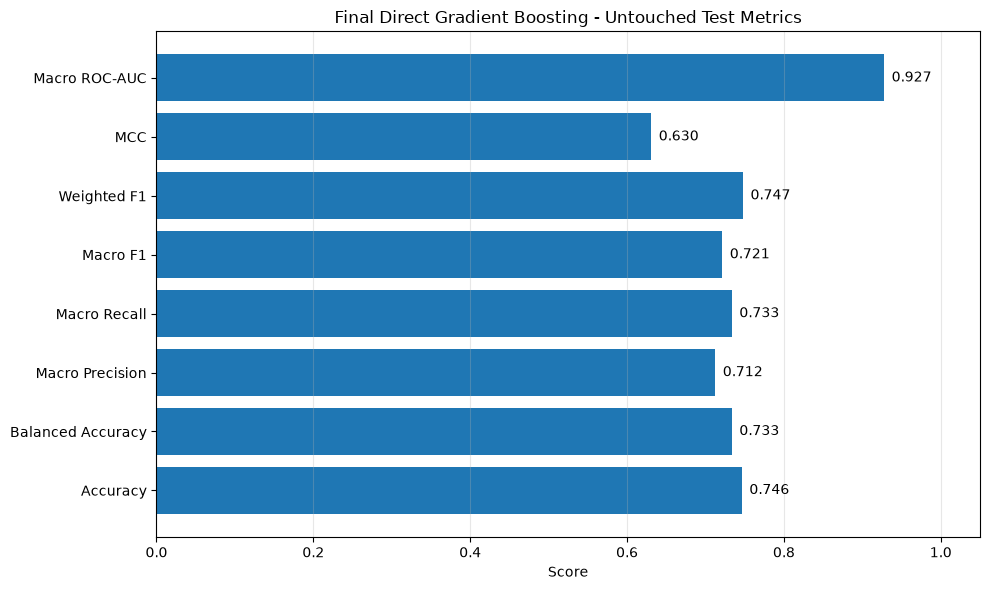

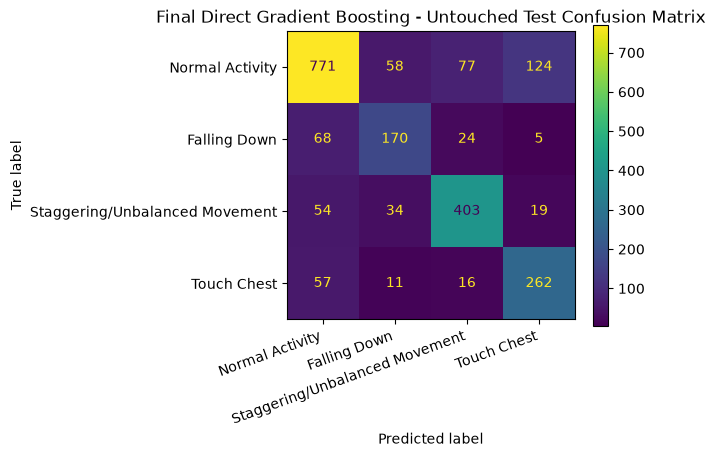

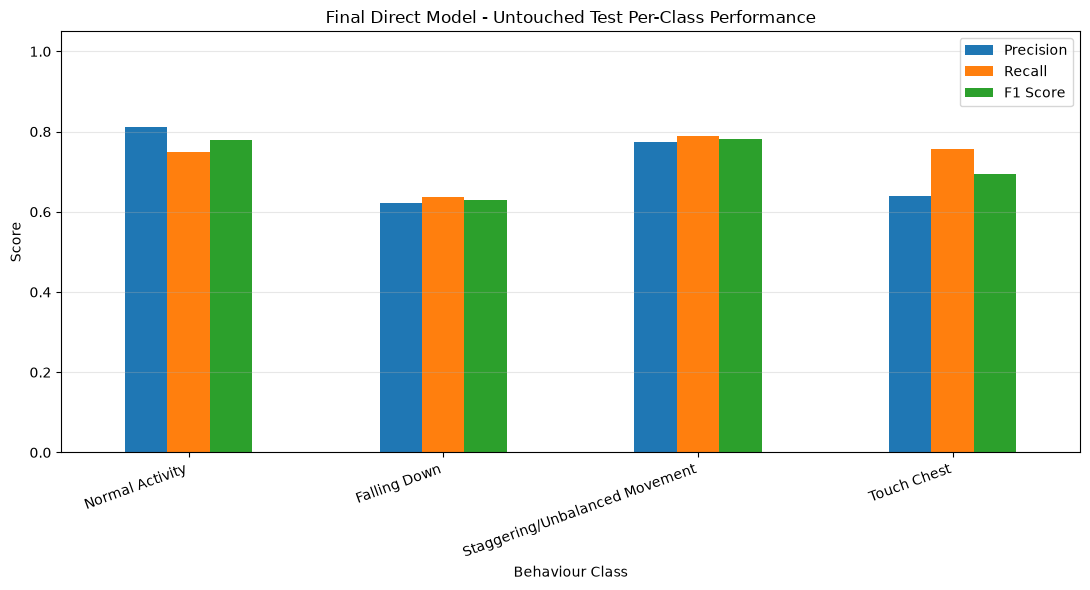

In [39]:
# Step 16 - Final untouched test evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Prepare the untouched test features
X_test_direct = test_df[feature_columns].copy()

# Keep the original four-class labels
y_test_direct = test_df["label"].copy()

# Make final predictions using the frozen direct model
final_test_predictions = final_direct_model.predict(
    X_test_direct
)

# Get class probabilities for ROC-AUC and log loss
final_test_probabilities = final_direct_model.predict_proba(
    X_test_direct
)

# Keep the final class order fixed
final_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Calculate final overall test metrics
final_test_metrics = {
    "Accuracy": accuracy_score(
        y_test_direct,
        final_test_predictions
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_test_direct,
        final_test_predictions
    ),

    "Macro Precision": precision_score(
        y_test_direct,
        final_test_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_test_direct,
        final_test_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_test_direct,
        final_test_predictions,
        labels=final_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_test_direct,
        final_test_predictions,
        labels=final_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_test_direct,
        final_test_predictions
    ),

    "Log Loss": log_loss(
        y_test_direct,
        final_test_probabilities,
        labels=final_direct_model.classes_
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_test_direct,
        final_test_probabilities,
        labels=final_direct_model.classes_,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics into a readable table
final_test_metrics_df = pd.DataFrame({
    "Metric": final_test_metrics.keys(),
    "Score": final_test_metrics.values()
})

# Print final test results
print("FINAL DIRECT MODEL - UNTOUCHED TEST RESULTS")

print(
    final_test_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print full four-class classification report
print("\nFINAL TEST CLASSIFICATION REPORT")

print(
    classification_report(
        y_test_direct,
        final_test_predictions,
        labels=final_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
final_test_precision = precision_score(
    y_test_direct,
    final_test_predictions,
    labels=final_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
final_test_recall = recall_score(
    y_test_direct,
    final_test_predictions,
    labels=final_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1 score
final_test_f1 = f1_score(
    y_test_direct,
    final_test_predictions,
    labels=final_classes,
    average=None,
    zero_division=0
)

# Build the per-class results table
final_test_class_results = pd.DataFrame({
    "Class": final_classes,
    "Precision": final_test_precision,
    "Recall": final_test_recall,
    "F1 Score": final_test_f1
})

print("\nFINAL TEST PER-CLASS RESULTS")

print(
    final_test_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Plot overall final test metrics
graph_metrics = final_test_metrics_df[
    final_test_metrics_df["Metric"] != "Log Loss"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    graph_metrics["Metric"],
    graph_metrics["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Final Direct Gradient Boosting - Untouched Test Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    graph_metrics["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Calculate final test confusion matrix
final_test_cm = confusion_matrix(
    y_test_direct,
    final_test_predictions,
    labels=final_classes
)

# Display final test confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_test_cm,
    display_labels=final_classes
)

disp.plot(
    values_format="d"
)

plt.title(
    "Final Direct Gradient Boosting - Untouched Test Confusion Matrix"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot per-class precision, recall and F1
final_test_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Behaviour Class")
plt.title("Final Direct Model - Untouched Test Per-Class Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# XG BOOST starts from here

In [40]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 11.2 MB/s eta 0:00:09
   - -------------------------------------- 4.2/101.7 MB 10.9 MB/s eta 0:00:09
   -- ------------------------------------- 6.6/101.7 MB 11.2 MB/s eta 0:00:09
   --- ------------------------------------ 8.9/101.7 MB 11.3 MB/s eta 0:00:09
   ---- ----------------------------------- 11.3/101.7 MB 11.0 MB/s eta 0:00:09
   ----- ---------------------------------- 13.9/101.7 MB 11.2 MB/s eta 0:00:08
   ------ --------------------------------- 16.3/101.7 MB 11.2 MB/s eta 0:00:08
   ------- -------------------------------- 18.6/101.7 MB 11.2 MB/s eta 0:00:08
   -------- ------------------------------- 21.0/101.7 MB 11.3 MB/s eta 0:00:08
   --------- ------------------------------ 23.6/101.7 MB 11.3 MB/s eta 0:00:07
   ---------- ----------------------------- 26.0/101.7 MB 11.3 MB/s eta 0:00:07
   ----------- ---------------------------- 28.3/101.

In [41]:
# Step 17A - Verify XGBoost installation

import xgboost as xgb

print("XGBoost version:")
print(xgb.__version__)

XGBoost version:
3.2.0


In [42]:
# Step 17B - Prepare XGBoost 4-class training data

from sklearn.preprocessing import LabelEncoder

# Create a label encoder
xgb_label_encoder = LabelEncoder()

# Fit the encoder on the training labels
y_train_xgb = xgb_label_encoder.fit_transform(
    train_df["label"]
)

# Transform validation labels using the same encoder
y_val_xgb = xgb_label_encoder.transform(
    val_df["label"]
)

# Transform test labels using the same encoder
y_test_xgb = xgb_label_encoder.transform(
    test_df["label"]
)

# Use the same 20 numerical features
X_train_xgb = train_df[feature_columns].copy()
X_val_xgb = val_df[feature_columns].copy()
X_test_xgb = test_df[feature_columns].copy()

# Keep subject IDs for subject-wise cross-validation
xgb_train_groups = train_df["subject_id"].copy()

# Show how the original class names were encoded
print("XGBOOST CLASS ENCODING")

for class_name, class_number in zip(
    xgb_label_encoder.classes_,
    xgb_label_encoder.transform(
        xgb_label_encoder.classes_
    )
):
    print(
        class_number,
        "->",
        class_name
    )

print("\nTraining shape:")
print(X_train_xgb.shape)

print("\nValidation shape:")
print(X_val_xgb.shape)

print("\nTest shape:")
print(X_test_xgb.shape)

print("\nNumber of training subjects:")
print(xgb_train_groups.nunique())

print("\nNumber of classes:")
print(len(xgb_label_encoder.classes_))

XGBOOST CLASS ENCODING
0 -> Falling Down
1 -> Normal Activity
2 -> Staggering/Unbalanced Movement
3 -> Touch Chest

Training shape:
(15140, 20)

Validation shape:
(4321, 20)

Test shape:
(2153, 20)

Number of training subjects:
28

Number of classes:
4


XGBOOST BASELINE - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7427
Balanced Accuracy 0.7140
  Macro Precision 0.7006
     Macro Recall 0.7140
         Macro F1 0.7057
      Weighted F1 0.7442
              MCC 0.6219
         Log Loss 0.6536
    Macro ROC-AUC 0.9191

XGBOOST BASELINE CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.5629    0.6819    0.6167       525
               Normal Activity     0.8101    0.7825    0.7960      2060
Staggering/Unbalanced Movement     0.7834    0.7804    0.7819      1052
                   Touch Chest     0.6461    0.6111    0.6281       684

                      accuracy                         0.7427      4321
                     macro avg     0.7006    0.7140    0.7057      4321
                  weighted avg     0.7476    0.7427    0.7442      4321


XGBOOST BASELINE PER-CLASS RESULTS
                         Class Precision Recall F1 Score


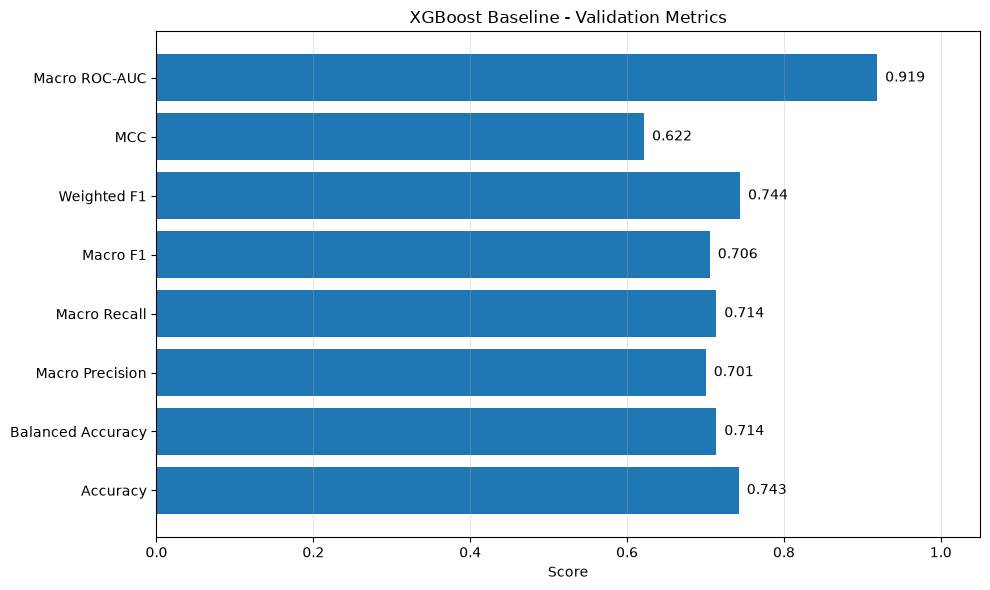

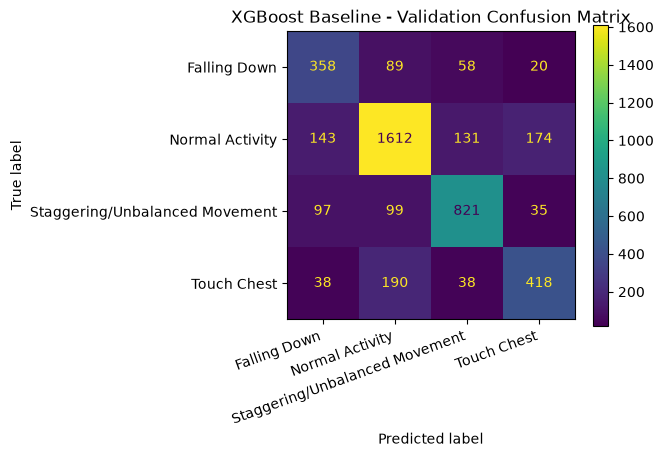

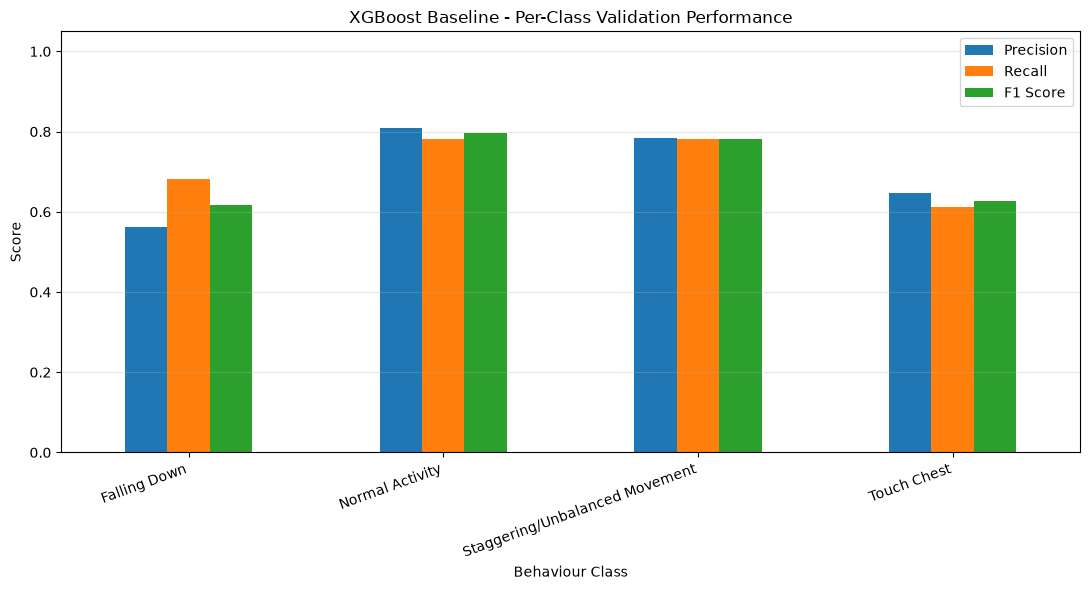

In [43]:
# Step 17C - Train a weighted XGBoost baseline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Calculate balanced sample weights for the 4-class training set
xgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_xgb
)

# Create the baseline XGBoost classifier
xgb_baseline = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    n_estimators=200,
    learning_rate=0.10,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

# Train the weighted XGBoost model
xgb_baseline.fit(
    X_train_xgb,
    y_train_xgb,
    sample_weight=xgb_sample_weights
)

# Predict validation labels
y_val_pred_xgb = xgb_baseline.predict(
    X_val_xgb
)

# Predict validation probabilities
y_val_prob_xgb = xgb_baseline.predict_proba(
    X_val_xgb
)

# Calculate overall metrics
xgb_baseline_metrics = {
    "Accuracy": accuracy_score(
        y_val_xgb,
        y_val_pred_xgb
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_xgb,
        y_val_pred_xgb
    ),

    "Macro Precision": precision_score(
        y_val_xgb,
        y_val_pred_xgb,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_xgb,
        y_val_pred_xgb,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_xgb,
        y_val_pred_xgb,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_xgb,
        y_val_pred_xgb,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_xgb,
        y_val_pred_xgb
    ),

    "Log Loss": log_loss(
        y_val_xgb,
        y_val_prob_xgb
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_val_xgb,
        y_val_prob_xgb,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics into a table
xgb_baseline_metrics_df = pd.DataFrame({
    "Metric": xgb_baseline_metrics.keys(),
    "Score": xgb_baseline_metrics.values()
})

# Print overall validation results
print("XGBOOST BASELINE - VALIDATION RESULTS")

print(
    xgb_baseline_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print classification report
print("\nXGBOOST BASELINE CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_xgb,
        y_val_pred_xgb,
        target_names=xgb_label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
xgb_class_precision = precision_score(
    y_val_xgb,
    y_val_pred_xgb,
    average=None,
    zero_division=0
)

# Calculate per-class recall
xgb_class_recall = recall_score(
    y_val_xgb,
    y_val_pred_xgb,
    average=None,
    zero_division=0
)

# Calculate per-class F1
xgb_class_f1 = f1_score(
    y_val_xgb,
    y_val_pred_xgb,
    average=None,
    zero_division=0
)

# Build per-class results table
xgb_class_results = pd.DataFrame({
    "Class": xgb_label_encoder.classes_,
    "Precision": xgb_class_precision,
    "Recall": xgb_class_recall,
    "F1 Score": xgb_class_f1
})

print("\nXGBOOST BASELINE PER-CLASS RESULTS")

print(
    xgb_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Plot overall metrics
graph_metrics = xgb_baseline_metrics_df[
    xgb_baseline_metrics_df["Metric"] != "Log Loss"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    graph_metrics["Metric"],
    graph_metrics["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("XGBoost Baseline - Validation Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    graph_metrics["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Create confusion matrix
xgb_cm = confusion_matrix(
    y_val_xgb,
    y_val_pred_xgb
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=xgb_label_encoder.classes_
)

disp.plot(
    values_format="d"
)

plt.title("XGBoost Baseline - Validation Confusion Matrix")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot per-class performance
xgb_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Behaviour Class")
plt.title("XGBoost Baseline - Per-Class Validation Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [44]:
# Step 17D - Subject-wise XGBoost hyperparameter tuning

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.utils.class_weight import compute_sample_weight

# Create 5-fold subject-wise cross-validation
xgb_group_cv = GroupKFold(
    n_splits=5
)

# Create balanced sample weights for the complete training set
xgb_training_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_xgb
)

# Create the base XGBoost classifier
xgb_search_model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    random_state=42,
    eval_metric="mlogloss"
)

# Define the XGBoost hyperparameter search space
xgb_param_distributions = {
    "n_estimators": [
        200,
        300,
        400,
        500,
        600
    ],

    "learning_rate": [
        0.02,
        0.03,
        0.05,
        0.08,
        0.10
    ],

    "max_depth": [
        3,
        4,
        5,
        6,
        7
    ],

    "min_child_weight": [
        1,
        3,
        5,
        7
    ],

    "subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "gamma": [
        0,
        0.1,
        0.3,
        0.5
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        0.5
    ],

    "reg_lambda": [
        0.5,
        1.0,
        2.0,
        5.0
    ]
}

# Create the randomized search
xgb_search = RandomizedSearchCV(
    estimator=xgb_search_model,

    param_distributions=xgb_param_distributions,

    # Test 40 random combinations
    n_iter=40,

    # Give all four classes equal importance
    scoring="f1_macro",

    # Keep subjects separated during CV
    cv=xgb_group_cv,

    random_state=42,

    # Use available CPU cores
    n_jobs=-1,

    # Show search progress
    verbose=2,

    # Save train scores for analysis
    return_train_score=True,

    # Stop if a real error occurs
    error_score="raise"
)

# Run subject-wise hyperparameter tuning
xgb_search.fit(
    X_train_xgb,
    y_train_xgb,
    groups=xgb_train_groups,
    sample_weight=xgb_training_weights
)

# Print the best result
print("BEST XGBOOST PARAMETERS")

print("\nBest parameters:")
print(
    xgb_search.best_params_
)

print("\nBest subject-wise CV Macro F1:")
print(
    round(
        xgb_search.best_score_,
        4
    )
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
BEST XGBOOST PARAMETERS

Best parameters:
{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.01, 'n_estimators': 400, 'min_child_weight': 7, 'max_depth': 7, 'learning_rate': 0.02, 'gamma': 0.5, 'colsample_bytree': 1.0}

Best subject-wise CV Macro F1:
0.7659


TUNED XGBOOST - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7350
Balanced Accuracy 0.7183
  Macro Precision 0.6898
     Macro Recall 0.7183
         Macro F1 0.7003
      Weighted F1 0.7388
              MCC 0.6171
         Log Loss 0.6526
    Macro ROC-AUC 0.9188

TUNED XGBOOST CLASSIFICATION REPORT
                                precision    recall  f1-score   support

                  Falling Down     0.5327    0.7143    0.6103       525
               Normal Activity     0.8269    0.7515    0.7874      2060
Staggering/Unbalanced Movement     0.7875    0.7890    0.7882      1052
                   Touch Chest     0.6122    0.6184    0.6153       684

                      accuracy                         0.7350      4321
                     macro avg     0.6898    0.7183    0.7003      4321
                  weighted avg     0.7476    0.7350    0.7388      4321


TUNED XGBOOST PER-CLASS RESULTS
                         Class Precision Recall F1 Score
         

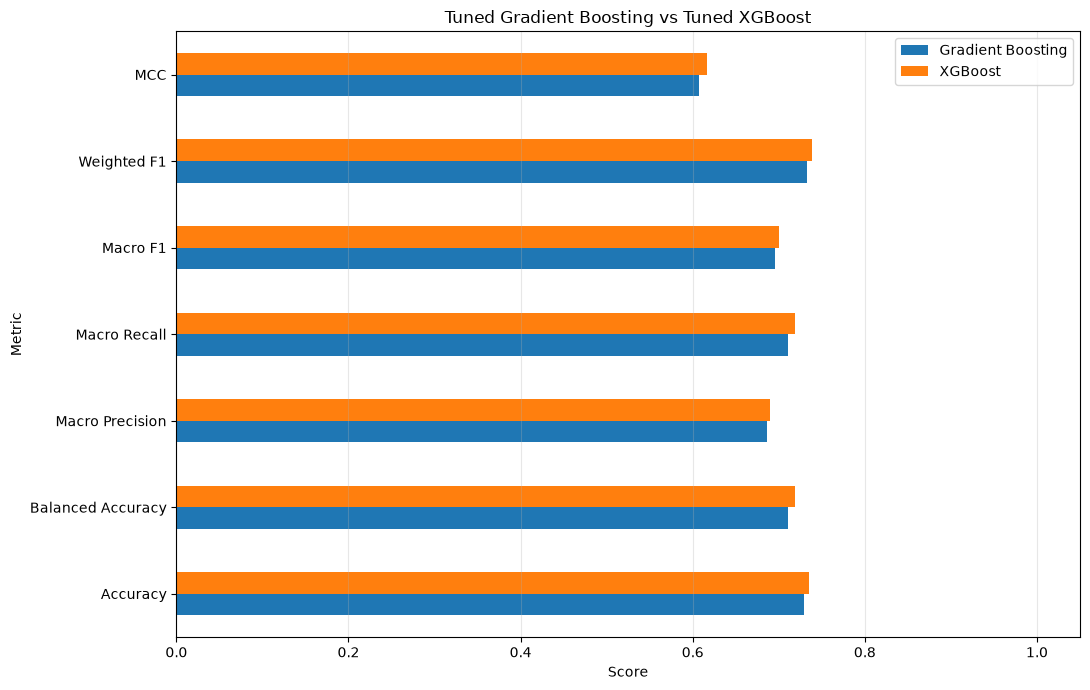

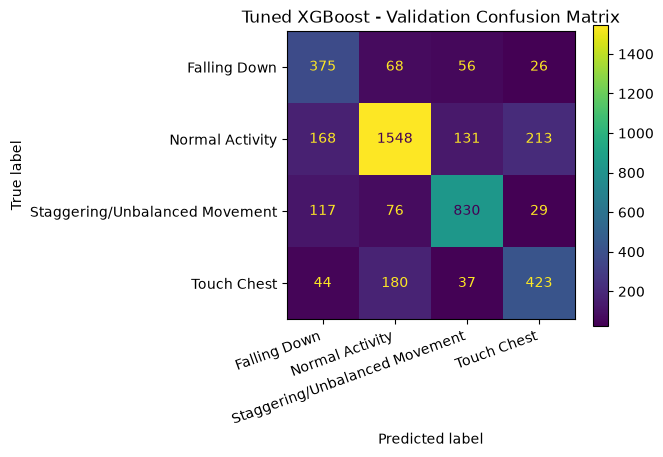


PER-CLASS RECALL COMPARISON
                         Class Gradient Boosting Recall XGBoost Recall  Change
                  Falling Down                   0.6952         0.7143 +0.0190
               Normal Activity                   0.7500         0.7515 +0.0015
Staggering/Unbalanced Movement                   0.7766         0.7890 +0.0124
                   Touch Chest                   0.6228         0.6184 -0.0044


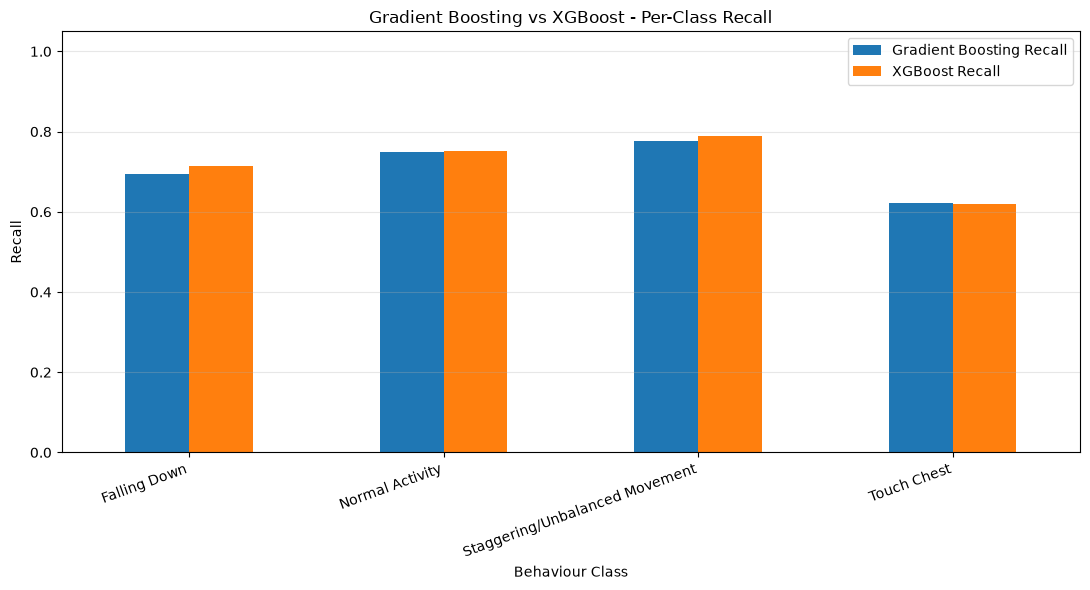

In [45]:
# Step 17E - Evaluate the tuned XGBoost model on validation data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Get the best XGBoost model found during tuning
xgb_tuned = xgb_search.best_estimator_

# Make validation predictions
y_val_pred_xgb_tuned = xgb_tuned.predict(
    X_val_xgb
)

# Get validation class probabilities
y_val_prob_xgb_tuned = xgb_tuned.predict_proba(
    X_val_xgb
)

# Calculate overall validation metrics
xgb_tuned_metrics = {
    "Accuracy": accuracy_score(
        y_val_xgb,
        y_val_pred_xgb_tuned
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_xgb,
        y_val_pred_xgb_tuned
    ),

    "Macro Precision": precision_score(
        y_val_xgb,
        y_val_pred_xgb_tuned,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_xgb,
        y_val_pred_xgb_tuned,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_xgb,
        y_val_pred_xgb_tuned,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_xgb,
        y_val_pred_xgb_tuned,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_xgb,
        y_val_pred_xgb_tuned
    ),

    "Log Loss": log_loss(
        y_val_xgb,
        y_val_prob_xgb_tuned
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_val_xgb,
        y_val_prob_xgb_tuned,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics into a table
xgb_tuned_metrics_df = pd.DataFrame({
    "Metric": xgb_tuned_metrics.keys(),
    "Score": xgb_tuned_metrics.values()
})

# Print tuned XGBoost validation metrics
print("TUNED XGBOOST - VALIDATION RESULTS")

print(
    xgb_tuned_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print detailed classification report
print("\nTUNED XGBOOST CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_xgb,
        y_val_pred_xgb_tuned,
        target_names=xgb_label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
xgb_tuned_precision = precision_score(
    y_val_xgb,
    y_val_pred_xgb_tuned,
    average=None,
    zero_division=0
)

# Calculate per-class recall
xgb_tuned_recall = recall_score(
    y_val_xgb,
    y_val_pred_xgb_tuned,
    average=None,
    zero_division=0
)

# Calculate per-class F1
xgb_tuned_f1 = f1_score(
    y_val_xgb,
    y_val_pred_xgb_tuned,
    average=None,
    zero_division=0
)

# Create the per-class result table
xgb_tuned_class_results = pd.DataFrame({
    "Class": xgb_label_encoder.classes_,
    "Precision": xgb_tuned_precision,
    "Recall": xgb_tuned_recall,
    "F1 Score": xgb_tuned_f1
})

print("\nTUNED XGBOOST PER-CLASS RESULTS")

print(
    xgb_tuned_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Compare tuned XGBoost against tuned weighted Gradient Boosting
xgb_vs_gb = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "MCC"
    ],

    "Gradient Boosting": [
        direct_tuned_metrics["Accuracy"],
        direct_tuned_metrics["Balanced Accuracy"],
        direct_tuned_metrics["Macro Precision"],
        direct_tuned_metrics["Macro Recall"],
        direct_tuned_metrics["Macro F1"],
        direct_tuned_metrics["Weighted F1"],
        direct_tuned_metrics["MCC"]
    ],

    "XGBoost": [
        xgb_tuned_metrics["Accuracy"],
        xgb_tuned_metrics["Balanced Accuracy"],
        xgb_tuned_metrics["Macro Precision"],
        xgb_tuned_metrics["Macro Recall"],
        xgb_tuned_metrics["Macro F1"],
        xgb_tuned_metrics["Weighted F1"],
        xgb_tuned_metrics["MCC"]
    ]
})

# Calculate XGBoost improvement over Gradient Boosting
xgb_vs_gb["Change"] = (
    xgb_vs_gb["XGBoost"]
    - xgb_vs_gb["Gradient Boosting"]
)

print("\nXGBOOST VS GRADIENT BOOSTING")

print(
    xgb_vs_gb.to_string(
        index=False,
        formatters={
            "Gradient Boosting": "{:.4f}".format,
            "XGBoost": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot overall model comparison
xgb_vs_gb.set_index(
    "Metric"
)[
    ["Gradient Boosting", "XGBoost"]
].plot(
    kind="barh",
    figsize=(11, 7)
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Tuned Gradient Boosting vs Tuned XGBoost")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate tuned XGBoost confusion matrix
xgb_tuned_cm = confusion_matrix(
    y_val_xgb,
    y_val_pred_xgb_tuned
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_tuned_cm,
    display_labels=xgb_label_encoder.classes_
)

disp.plot(
    values_format="d"
)

plt.title("Tuned XGBoost - Validation Confusion Matrix")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Compare per-class recall between Gradient Boosting and XGBoost
gb_recall_by_class = {
    row["Class"]: row["Recall"]
    for _, row in direct_tuned_class_results.iterrows()
}

xgb_recall_comparison = pd.DataFrame({
    "Class": xgb_label_encoder.classes_,

    "Gradient Boosting Recall": [
        gb_recall_by_class[class_name]
        for class_name in xgb_label_encoder.classes_
    ],

    "XGBoost Recall": xgb_tuned_recall
})

# Calculate recall improvement for each class
xgb_recall_comparison["Change"] = (
    xgb_recall_comparison["XGBoost Recall"]
    - xgb_recall_comparison["Gradient Boosting Recall"]
)

print("\nPER-CLASS RECALL COMPARISON")

print(
    xgb_recall_comparison.to_string(
        index=False,
        formatters={
            "Gradient Boosting Recall": "{:.4f}".format,
            "XGBoost Recall": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot per-class recall comparison
xgb_recall_comparison.set_index(
    "Class"
)[
    ["Gradient Boosting Recall", "XGBoost Recall"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Recall")
plt.xlabel("Behaviour Class")
plt.title("Gradient Boosting vs XGBoost - Per-Class Recall")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

EXTRA TREES BASELINE - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7336
Balanced Accuracy 0.6377
  Macro Precision 0.7513
     Macro Recall 0.6377
         Macro F1 0.6738
      Weighted F1 0.7214
              MCC 0.5918
         Log Loss 0.6958
    Macro ROC-AUC 0.9119

EXTRA TREES BASELINE CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.7082    0.8966    0.7913      2060
                  Falling Down     0.7560    0.4781    0.5858       525
Staggering/Unbalanced Movement     0.7846    0.7272    0.7548      1052
                   Touch Chest     0.7562    0.4488    0.5633       684

                      accuracy                         0.7336      4321
                     macro avg     0.7513    0.6377    0.6738      4321
                  weighted avg     0.7402    0.7336    0.7214      4321


EXTRA TREES BASELINE PER-CLASS RESULTS
                         Class Precision Reca

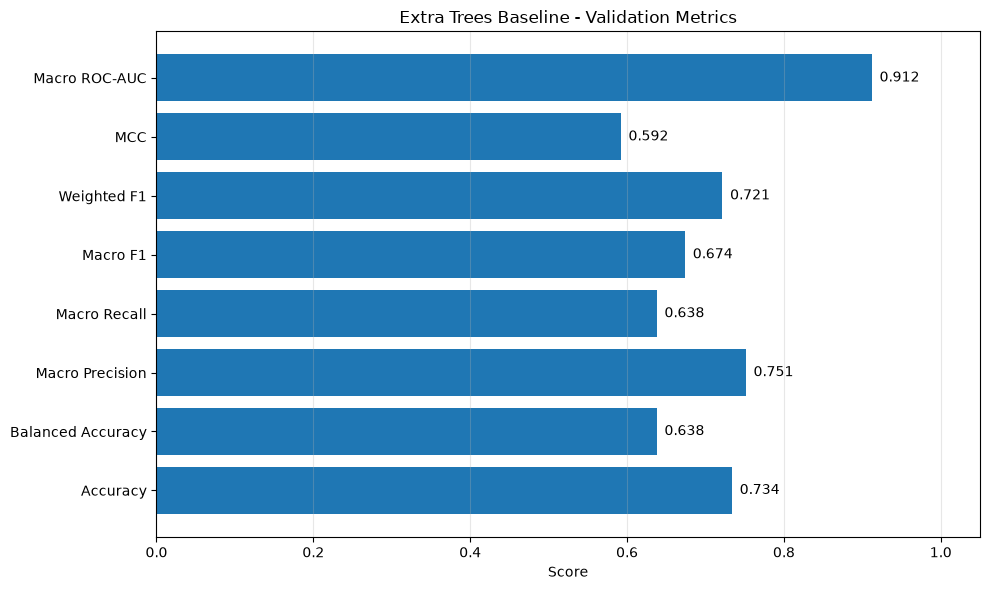

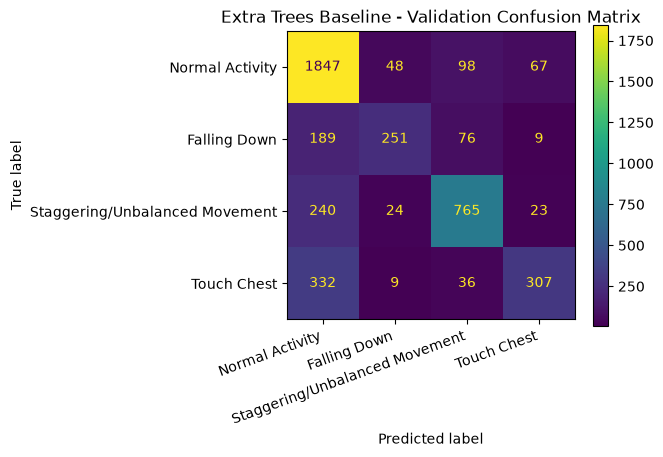

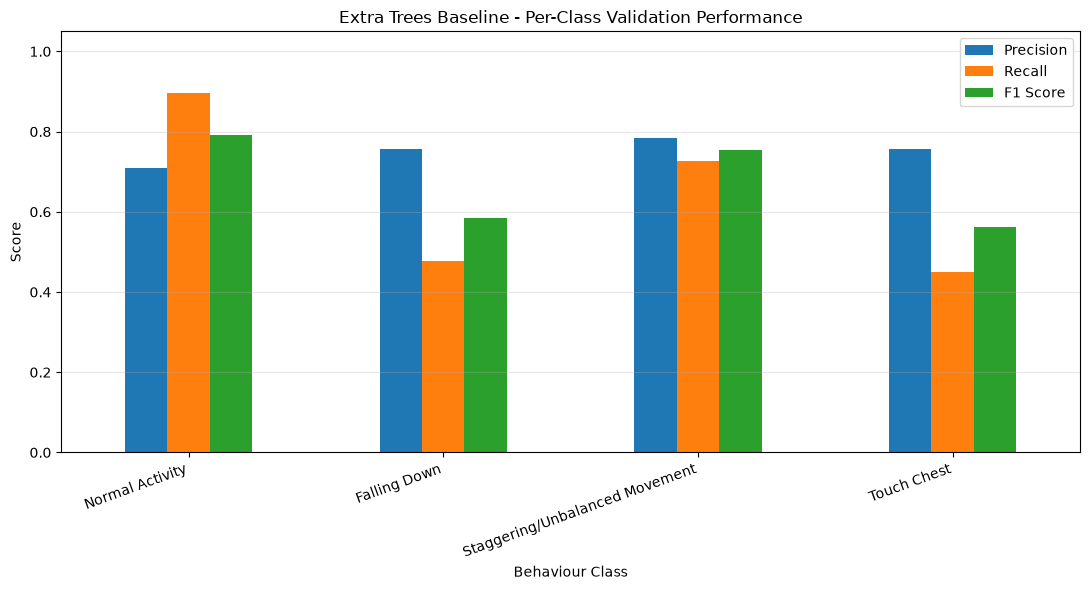

In [46]:
# Step 18A - Train and evaluate a weighted Extra Trees baseline

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Create the Extra Trees model
# class_weight="balanced" automatically gives more importance
# to underrepresented classes
extra_trees_baseline = ExtraTreesClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train using the same direct 4-class training data
extra_trees_baseline.fit(
    X_train_direct,
    y_train_direct
)

# Predict the validation classes
y_val_pred_extra = extra_trees_baseline.predict(
    X_val_direct
)

# Get class probabilities
y_val_prob_extra = extra_trees_baseline.predict_proba(
    X_val_direct
)

# Calculate overall validation metrics
extra_baseline_metrics = {
    "Accuracy": accuracy_score(
        y_val_direct,
        y_val_pred_extra
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_direct,
        y_val_pred_extra
    ),

    "Macro Precision": precision_score(
        y_val_direct,
        y_val_pred_extra,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_direct,
        y_val_pred_extra,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_direct,
        y_val_pred_extra,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_direct,
        y_val_pred_extra,
        labels=direct_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_direct,
        y_val_pred_extra
    ),

    "Log Loss": log_loss(
        y_val_direct,
        y_val_prob_extra,
        labels=extra_trees_baseline.classes_
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_val_direct,
        y_val_prob_extra,
        labels=extra_trees_baseline.classes_,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics into a table
extra_baseline_metrics_df = pd.DataFrame({
    "Metric": extra_baseline_metrics.keys(),
    "Score": extra_baseline_metrics.values()
})

# Print overall validation metrics
print("EXTRA TREES BASELINE - VALIDATION RESULTS")

print(
    extra_baseline_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print detailed classification report
print("\nEXTRA TREES BASELINE CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_direct,
        y_val_pred_extra,
        labels=direct_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
extra_class_precision = precision_score(
    y_val_direct,
    y_val_pred_extra,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
extra_class_recall = recall_score(
    y_val_direct,
    y_val_pred_extra,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1
extra_class_f1 = f1_score(
    y_val_direct,
    y_val_pred_extra,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Build the per-class results table
extra_class_results = pd.DataFrame({
    "Class": direct_classes,
    "Precision": extra_class_precision,
    "Recall": extra_class_recall,
    "F1 Score": extra_class_f1
})

print("\nEXTRA TREES BASELINE PER-CLASS RESULTS")

print(
    extra_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Plot overall metrics
graph_metrics = extra_baseline_metrics_df[
    extra_baseline_metrics_df["Metric"] != "Log Loss"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    graph_metrics["Metric"],
    graph_metrics["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Extra Trees Baseline - Validation Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    graph_metrics["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Calculate the confusion matrix
extra_cm = confusion_matrix(
    y_val_direct,
    y_val_pred_extra,
    labels=direct_classes
)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=extra_cm,
    display_labels=direct_classes
)

disp.plot(
    values_format="d"
)

plt.title("Extra Trees Baseline - Validation Confusion Matrix")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot per-class performance
extra_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Behaviour Class")
plt.title("Extra Trees Baseline - Per-Class Validation Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

RANDOM FOREST BASELINE - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7343
Balanced Accuracy 0.7000
  Macro Precision 0.6914
     Macro Recall 0.7000
         Macro F1 0.6943
      Weighted F1 0.7344
              MCC 0.6083
         Log Loss 0.6775
    Macro ROC-AUC 0.9119

RANDOM FOREST BASELINE CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.7979    0.7762    0.7869      2060
                  Falling Down     0.5700    0.6590    0.6113       525
Staggering/Unbalanced Movement     0.7668    0.8004    0.7833      1052
                   Touch Chest     0.6307    0.5643    0.5957       684

                      accuracy                         0.7343      4321
                     macro avg     0.6914    0.7000    0.6943      4321
                  weighted avg     0.7362    0.7343    0.7344      4321


RANDOM FOREST BASELINE PER-CLASS RESULTS
                         Class Precisio

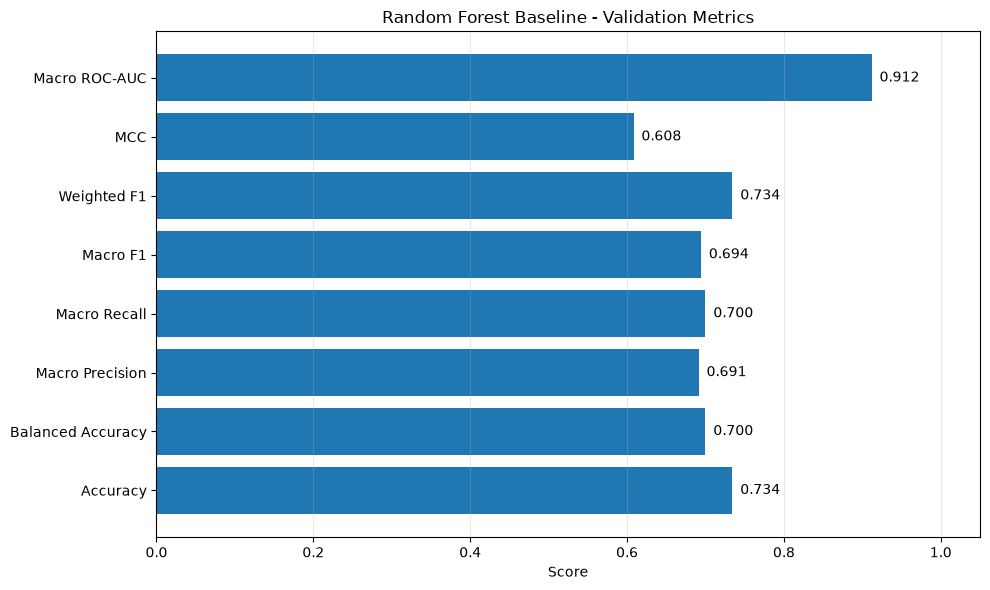

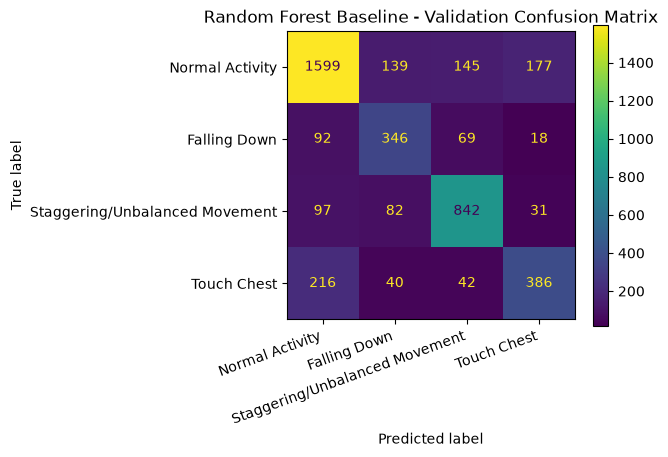

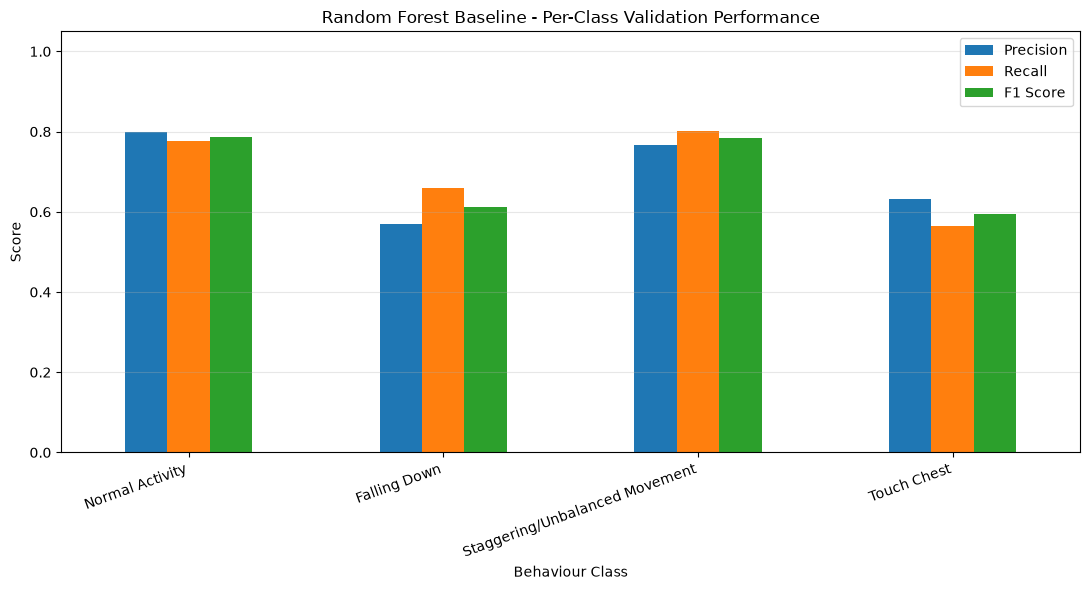

In [47]:
# Step 19A - Train and evaluate a weighted Random Forest baseline

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Create the Random Forest classifier
random_forest_baseline = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train using the same direct 4-class training data
random_forest_baseline.fit(
    X_train_direct,
    y_train_direct
)

# Predict validation classes
y_val_pred_rf = random_forest_baseline.predict(
    X_val_direct
)

# Get validation probabilities
y_val_prob_rf = random_forest_baseline.predict_proba(
    X_val_direct
)

# Calculate overall metrics
rf_baseline_metrics = {
    "Accuracy": accuracy_score(
        y_val_direct,
        y_val_pred_rf
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_direct,
        y_val_pred_rf
    ),

    "Macro Precision": precision_score(
        y_val_direct,
        y_val_pred_rf,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_direct,
        y_val_pred_rf,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_direct,
        y_val_pred_rf,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_direct,
        y_val_pred_rf,
        labels=direct_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_direct,
        y_val_pred_rf
    ),

    "Log Loss": log_loss(
        y_val_direct,
        y_val_prob_rf,
        labels=random_forest_baseline.classes_
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_val_direct,
        y_val_prob_rf,
        labels=random_forest_baseline.classes_,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics to a table
rf_baseline_metrics_df = pd.DataFrame({
    "Metric": rf_baseline_metrics.keys(),
    "Score": rf_baseline_metrics.values()
})

print("RANDOM FOREST BASELINE - VALIDATION RESULTS")

print(
    rf_baseline_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print detailed classification report
print("\nRANDOM FOREST BASELINE CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_direct,
        y_val_pred_rf,
        labels=direct_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class results
rf_class_precision = precision_score(
    y_val_direct,
    y_val_pred_rf,
    labels=direct_classes,
    average=None,
    zero_division=0
)

rf_class_recall = recall_score(
    y_val_direct,
    y_val_pred_rf,
    labels=direct_classes,
    average=None,
    zero_division=0
)

rf_class_f1 = f1_score(
    y_val_direct,
    y_val_pred_rf,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Build per-class table
rf_class_results = pd.DataFrame({
    "Class": direct_classes,
    "Precision": rf_class_precision,
    "Recall": rf_class_recall,
    "F1 Score": rf_class_f1
})

print("\nRANDOM FOREST BASELINE PER-CLASS RESULTS")

print(
    rf_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Plot overall metrics
graph_metrics = rf_baseline_metrics_df[
    rf_baseline_metrics_df["Metric"] != "Log Loss"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    graph_metrics["Metric"],
    graph_metrics["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Random Forest Baseline - Validation Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    graph_metrics["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Calculate confusion matrix
rf_cm = confusion_matrix(
    y_val_direct,
    y_val_pred_rf,
    labels=direct_classes
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=direct_classes
)

disp.plot(
    values_format="d"
)

plt.title("Random Forest Baseline - Validation Confusion Matrix")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot per-class performance
rf_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Behaviour Class")
plt.title("Random Forest Baseline - Per-Class Validation Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

D:\Career\Projects\cse 445\emergency behaviour classification from cctv\nturgbd_skeletons_s001_to_s017\nturgb+d_skeletons\Notebook\model_training\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


RBF-SVM BASELINE - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7285
Balanced Accuracy 0.7340
  Macro Precision 0.6887
     Macro Recall 0.7340
         Macro F1 0.7036
      Weighted F1 0.7338
              MCC 0.6155
         Log Loss 0.6610
    Macro ROC-AUC 0.9139

RBF-SVM BASELINE CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.8383    0.7146    0.7715      2060
                  Falling Down     0.5385    0.7867    0.6393       525
Staggering/Unbalanced Movement     0.7884    0.7652    0.7767      1052
                   Touch Chest     0.5894    0.6696    0.6270       684

                      accuracy                         0.7285      4321
                     macro avg     0.6887    0.7340    0.7036      4321
                  weighted avg     0.7503    0.7285    0.7338      4321


RBF-SVM BASELINE PER-CLASS RESULTS
                         Class Precision Recall F1 Score


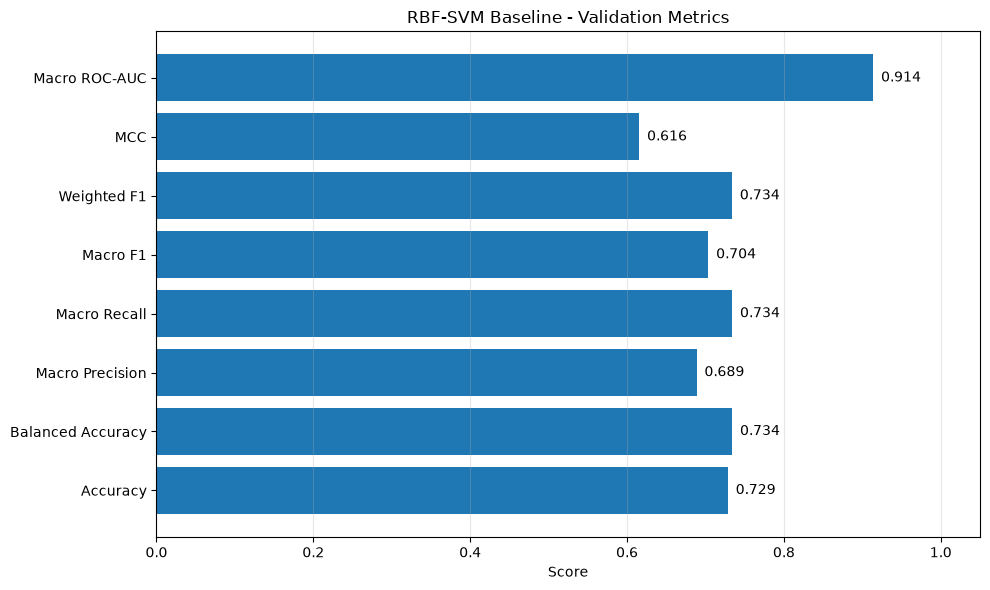

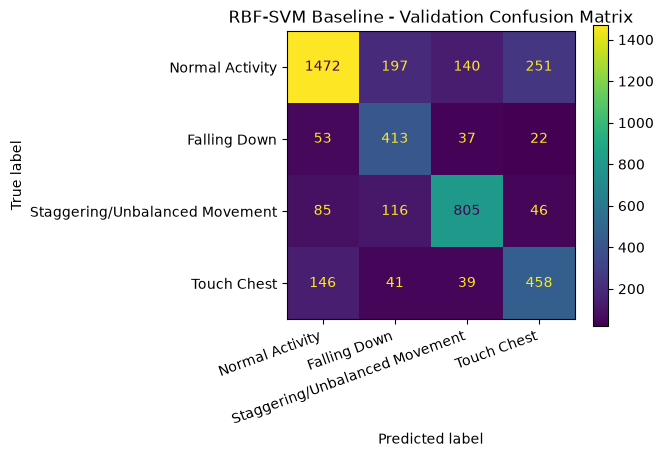

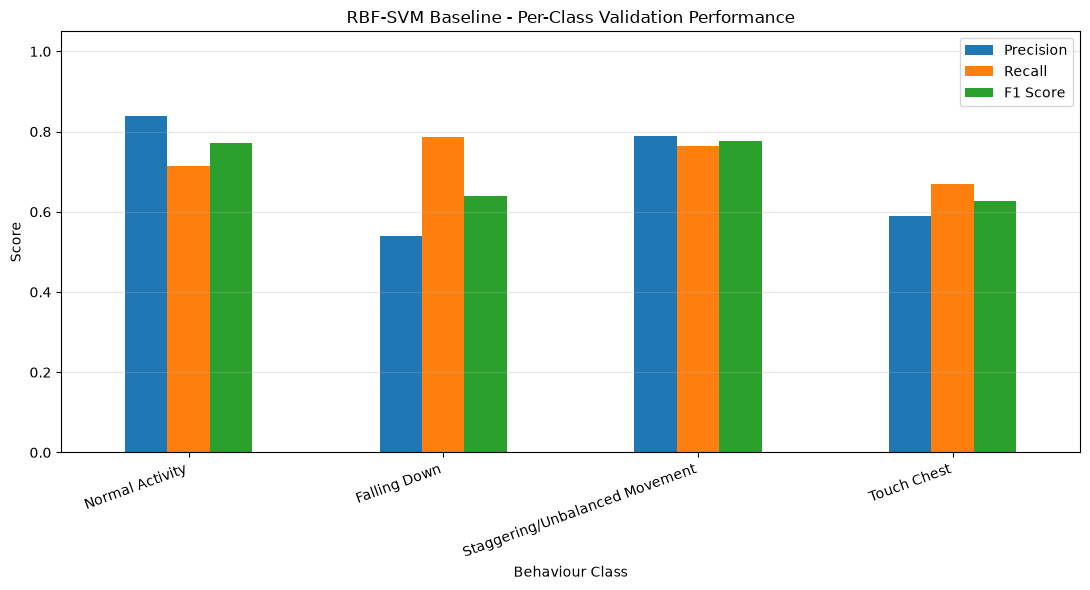

In [48]:
# Step 20A - Train and evaluate a weighted RBF-SVM baseline

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Create a pipeline so scaling happens before the SVM
svm_baseline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",

            # Default-style starting value
            C=1.0,

            # Let sklearn calculate gamma from the feature variance
            gamma="scale",

            # Give underrepresented classes more importance
            class_weight="balanced",

            # Needed because we want predict_proba() later
            probability=True,

            random_state=42
        )
    )
])

# Train the SVM using the same 4-class training dataset
svm_baseline.fit(
    X_train_direct,
    y_train_direct
)

# Predict validation classes
y_val_pred_svm = svm_baseline.predict(
    X_val_direct
)

# Get validation probabilities
y_val_prob_svm = svm_baseline.predict_proba(
    X_val_direct
)

# Calculate overall validation metrics
svm_baseline_metrics = {
    "Accuracy": accuracy_score(
        y_val_direct,
        y_val_pred_svm
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_direct,
        y_val_pred_svm
    ),

    "Macro Precision": precision_score(
        y_val_direct,
        y_val_pred_svm,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_direct,
        y_val_pred_svm,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_direct,
        y_val_pred_svm,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_direct,
        y_val_pred_svm,
        labels=direct_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_direct,
        y_val_pred_svm
    ),

    "Log Loss": log_loss(
        y_val_direct,
        y_val_prob_svm,
        labels=svm_baseline.classes_
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_val_direct,
        y_val_prob_svm,
        labels=svm_baseline.classes_,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics into a table
svm_baseline_metrics_df = pd.DataFrame({
    "Metric": svm_baseline_metrics.keys(),
    "Score": svm_baseline_metrics.values()
})

print("RBF-SVM BASELINE - VALIDATION RESULTS")

print(
    svm_baseline_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print detailed classification report
print("\nRBF-SVM BASELINE CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_direct,
        y_val_pred_svm,
        labels=direct_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
svm_class_precision = precision_score(
    y_val_direct,
    y_val_pred_svm,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
svm_class_recall = recall_score(
    y_val_direct,
    y_val_pred_svm,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1
svm_class_f1 = f1_score(
    y_val_direct,
    y_val_pred_svm,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Build per-class result table
svm_class_results = pd.DataFrame({
    "Class": direct_classes,
    "Precision": svm_class_precision,
    "Recall": svm_class_recall,
    "F1 Score": svm_class_f1
})

print("\nRBF-SVM BASELINE PER-CLASS RESULTS")

print(
    svm_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Plot overall metrics
graph_metrics = svm_baseline_metrics_df[
    svm_baseline_metrics_df["Metric"] != "Log Loss"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    graph_metrics["Metric"],
    graph_metrics["Score"]
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("RBF-SVM Baseline - Validation Metrics")
plt.grid(axis="x", alpha=0.3)

for bar, score in zip(
    bars,
    graph_metrics["Score"]
):
    plt.text(
        min(score + 0.01, 1.01),
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

# Calculate confusion matrix
svm_cm = confusion_matrix(
    y_val_direct,
    y_val_pred_svm,
    labels=direct_classes
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=direct_classes
)

disp.plot(
    values_format="d"
)

plt.title("RBF-SVM Baseline - Validation Confusion Matrix")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Plot per-class performance
svm_class_results.set_index(
    "Class"
)[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.xlabel("Behaviour Class")
plt.title("RBF-SVM Baseline - Per-Class Validation Performance")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [50]:
# Step 20B - Subject-wise RBF-SVM hyperparameter tuning

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

# Create subject-wise cross-validation
svm_group_cv = GroupKFold(
    n_splits=5
)

# Create the scaling + RBF-SVM pipeline
svm_search_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            class_weight="balanced",
            probability=False,
            random_state=42
        )
    )
])

# Define the SVM search space
svm_param_distributions = {
    "svm__C": [
        0.1,
        0.3,
        0.5,
        1,
        2,
        3,
        5,
        10,
        20,
        50
    ],

    "svm__gamma": [
        0.001,
        0.003,
        0.005,
        0.01,
        0.02,
        0.03,
        0.05,
        0.1,
        0.2,
        "scale"
    ]
}

# Create randomized search
svm_search = RandomizedSearchCV(
    estimator=svm_search_pipeline,

    param_distributions=svm_param_distributions,

    # Test 30 parameter combinations
    n_iter=30,

    # Give every class equal importance
    scoring="f1_macro",

    # Keep subjects separated
    cv=svm_group_cv,

    random_state=42,

    # Use available CPU cores
    n_jobs=-1,

    # Display progress
    verbose=2,

    # Keep training scores for later analysis
    return_train_score=True,

    # Stop if a real error occurs
    error_score="raise"
)

# Run subject-wise tuning
svm_search.fit(
    X_train_direct,
    y_train_direct,
    groups=direct_train_groups
)

# Print the best result
print("BEST RBF-SVM PARAMETERS")

print("\nBest parameters:")
print(
    svm_search.best_params_
)

print("\nBest subject-wise CV Macro F1:")
print(
    round(
        svm_search.best_score_,
        4
    )
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


D:\Career\Projects\cse 445\emergency behaviour classification from cctv\nturgbd_skeletons_s001_to_s017\nturgb+d_skeletons\Notebook\model_training\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


BEST RBF-SVM PARAMETERS

Best parameters:
{'svm__gamma': 'scale', 'svm__C': 5}

Best subject-wise CV Macro F1:
0.7243


D:\Career\Projects\cse 445\emergency behaviour classification from cctv\nturgbd_skeletons_s001_to_s017\nturgb+d_skeletons\Notebook\model_training\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


TUNED RBF-SVM - VALIDATION RESULTS
           Metric  Score
         Accuracy 0.7260
Balanced Accuracy 0.7161
  Macro Precision 0.6838
     Macro Recall 0.7161
         Macro F1 0.6955
      Weighted F1 0.7305
              MCC 0.6057
         Log Loss 0.6644
    Macro ROC-AUC 0.9135

TUNED RBF-SVM CLASSIFICATION REPORT
                                precision    recall  f1-score   support

               Normal Activity     0.8196    0.7364    0.7758      2060
                  Falling Down     0.5266    0.7162    0.6069       525
Staggering/Unbalanced Movement     0.7812    0.7567    0.7687      1052
                   Touch Chest     0.6079    0.6550    0.6305       684

                      accuracy                         0.7260      4321
                     macro avg     0.6838    0.7161    0.6955      4321
                  weighted avg     0.7411    0.7260    0.7305      4321


TUNED RBF-SVM PER-CLASS RESULTS
                         Class Precision Recall F1 Score
         

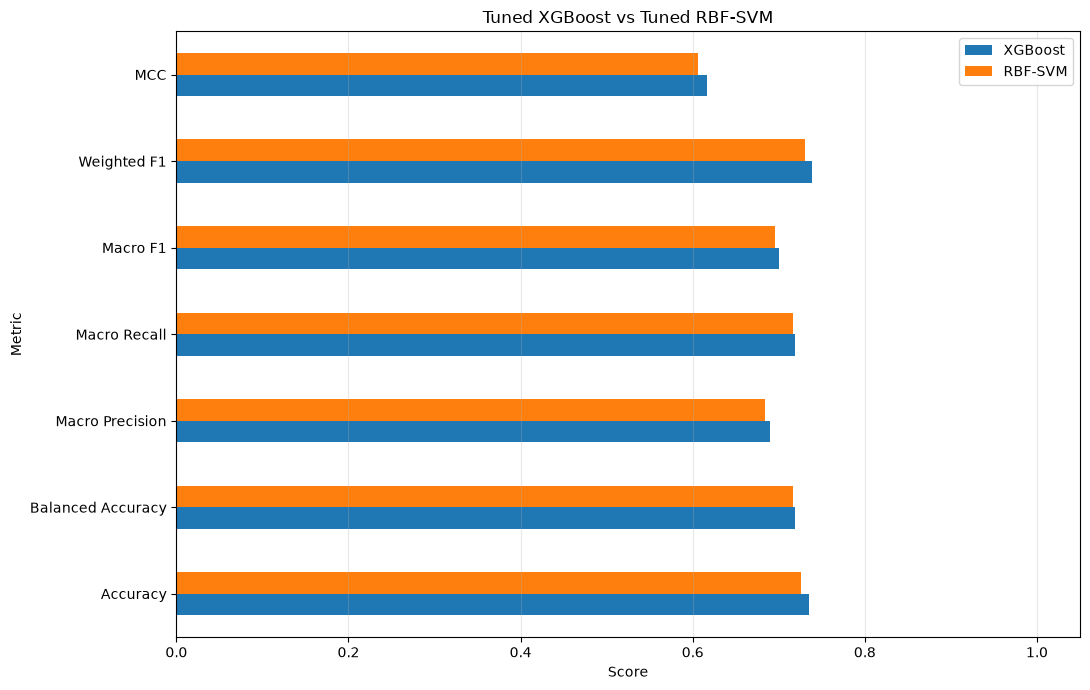

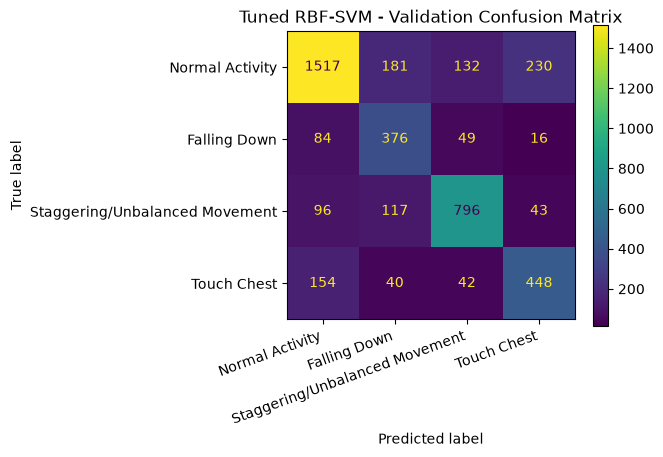


PER-CLASS RECALL COMPARISON
                         Class XGBoost Recall RBF-SVM Recall  Change
               Normal Activity         0.7515         0.7364 -0.0150
                  Falling Down         0.7143         0.7162 +0.0019
Staggering/Unbalanced Movement         0.7890         0.7567 -0.0323
                   Touch Chest         0.6184         0.6550 +0.0365


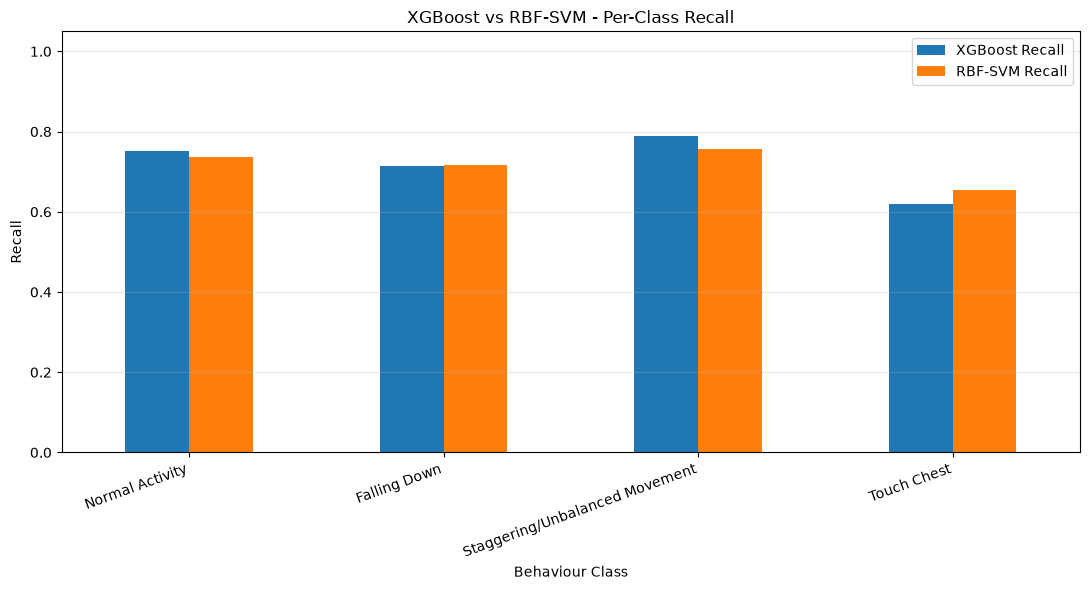

In [51]:
# Step 20C - Train and evaluate the tuned RBF-SVM

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    matthews_corrcoef,
    log_loss,
    roc_auc_score
)

# Create the tuned scaling + RBF-SVM pipeline
svm_tuned = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=5,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        )
    )
])

# Train the tuned SVM
svm_tuned.fit(
    X_train_direct,
    y_train_direct
)

# Predict validation classes
y_val_pred_svm_tuned = svm_tuned.predict(
    X_val_direct
)

# Get validation probabilities
y_val_prob_svm_tuned = svm_tuned.predict_proba(
    X_val_direct
)

# Calculate overall validation metrics
svm_tuned_metrics = {
    "Accuracy": accuracy_score(
        y_val_direct,
        y_val_pred_svm_tuned
    ),

    "Balanced Accuracy": balanced_accuracy_score(
        y_val_direct,
        y_val_pred_svm_tuned
    ),

    "Macro Precision": precision_score(
        y_val_direct,
        y_val_pred_svm_tuned,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro Recall": recall_score(
        y_val_direct,
        y_val_pred_svm_tuned,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Macro F1": f1_score(
        y_val_direct,
        y_val_pred_svm_tuned,
        labels=direct_classes,
        average="macro",
        zero_division=0
    ),

    "Weighted F1": f1_score(
        y_val_direct,
        y_val_pred_svm_tuned,
        labels=direct_classes,
        average="weighted",
        zero_division=0
    ),

    "MCC": matthews_corrcoef(
        y_val_direct,
        y_val_pred_svm_tuned
    ),

    "Log Loss": log_loss(
        y_val_direct,
        y_val_prob_svm_tuned,
        labels=svm_tuned.classes_
    ),

    "Macro ROC-AUC": roc_auc_score(
        y_val_direct,
        y_val_prob_svm_tuned,
        labels=svm_tuned.classes_,
        multi_class="ovr",
        average="macro"
    )
}

# Convert metrics to a table
svm_tuned_metrics_df = pd.DataFrame({
    "Metric": svm_tuned_metrics.keys(),
    "Score": svm_tuned_metrics.values()
})

# Print tuned SVM results
print("TUNED RBF-SVM - VALIDATION RESULTS")

print(
    svm_tuned_metrics_df.to_string(
        index=False,
        formatters={
            "Score": "{:.4f}".format
        }
    )
)

# Print detailed classification report
print("\nTUNED RBF-SVM CLASSIFICATION REPORT")

print(
    classification_report(
        y_val_direct,
        y_val_pred_svm_tuned,
        labels=direct_classes,
        digits=4,
        zero_division=0
    )
)

# Calculate per-class precision
svm_tuned_precision = precision_score(
    y_val_direct,
    y_val_pred_svm_tuned,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class recall
svm_tuned_recall = recall_score(
    y_val_direct,
    y_val_pred_svm_tuned,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Calculate per-class F1
svm_tuned_f1 = f1_score(
    y_val_direct,
    y_val_pred_svm_tuned,
    labels=direct_classes,
    average=None,
    zero_division=0
)

# Create per-class results
svm_tuned_class_results = pd.DataFrame({
    "Class": direct_classes,
    "Precision": svm_tuned_precision,
    "Recall": svm_tuned_recall,
    "F1 Score": svm_tuned_f1
})

print("\nTUNED RBF-SVM PER-CLASS RESULTS")

print(
    svm_tuned_class_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1 Score": "{:.4f}".format
        }
    )
)

# Compare tuned SVM directly against tuned XGBoost
svm_vs_xgb = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "MCC"
    ],

    "XGBoost": [
        xgb_tuned_metrics["Accuracy"],
        xgb_tuned_metrics["Balanced Accuracy"],
        xgb_tuned_metrics["Macro Precision"],
        xgb_tuned_metrics["Macro Recall"],
        xgb_tuned_metrics["Macro F1"],
        xgb_tuned_metrics["Weighted F1"],
        xgb_tuned_metrics["MCC"]
    ],

    "RBF-SVM": [
        svm_tuned_metrics["Accuracy"],
        svm_tuned_metrics["Balanced Accuracy"],
        svm_tuned_metrics["Macro Precision"],
        svm_tuned_metrics["Macro Recall"],
        svm_tuned_metrics["Macro F1"],
        svm_tuned_metrics["Weighted F1"],
        svm_tuned_metrics["MCC"]
    ]
})

# Calculate SVM minus XGBoost
svm_vs_xgb["Change"] = (
    svm_vs_xgb["RBF-SVM"]
    - svm_vs_xgb["XGBoost"]
)

print("\nTUNED XGBOOST VS TUNED RBF-SVM")

print(
    svm_vs_xgb.to_string(
        index=False,
        formatters={
            "XGBoost": "{:.4f}".format,
            "RBF-SVM": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot overall comparison
svm_vs_xgb.set_index(
    "Metric"
)[
    ["XGBoost", "RBF-SVM"]
].plot(
    kind="barh",
    figsize=(11, 7)
)

plt.xlim(0, 1.05)
plt.xlabel("Score")
plt.title("Tuned XGBoost vs Tuned RBF-SVM")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate tuned SVM confusion matrix
svm_tuned_cm = confusion_matrix(
    y_val_direct,
    y_val_pred_svm_tuned,
    labels=direct_classes
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_tuned_cm,
    display_labels=direct_classes
)

disp.plot(
    values_format="d"
)

plt.title("Tuned RBF-SVM - Validation Confusion Matrix")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

# Create XGBoost recall dictionary
xgb_recall_by_class = {
    class_name: recall
    for class_name, recall in zip(
        xgb_label_encoder.classes_,
        xgb_tuned_recall
    )
}

# Compare per-class recall
svm_xgb_recall_comparison = pd.DataFrame({
    "Class": direct_classes,

    "XGBoost Recall": [
        xgb_recall_by_class[class_name]
        for class_name in direct_classes
    ],

    "RBF-SVM Recall": svm_tuned_recall
})

# Calculate the per-class change
svm_xgb_recall_comparison["Change"] = (
    svm_xgb_recall_comparison["RBF-SVM Recall"]
    - svm_xgb_recall_comparison["XGBoost Recall"]
)

print("\nPER-CLASS RECALL COMPARISON")

print(
    svm_xgb_recall_comparison.to_string(
        index=False,
        formatters={
            "XGBoost Recall": "{:.4f}".format,
            "RBF-SVM Recall": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot per-class recall comparison
svm_xgb_recall_comparison.set_index(
    "Class"
)[
    ["XGBoost Recall", "RBF-SVM Recall"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Recall")
plt.xlabel("Behaviour Class")
plt.title("XGBoost vs RBF-SVM - Per-Class Recall")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

XGBOOST + RBF-SVM SOFT-VOTING RESULTS
 XGBoost Weight  SVM Weight  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1    MCC  Normal Recall  Falling Recall  Staggering Recall  Touch Chest Recall
            0.5         0.5    0.7501             0.7094           0.7155        0.7094    0.7115       0.7495 0.6272         0.8136          0.6552             0.7738              0.5950
            0.6         0.4    0.7512             0.7162           0.7141        0.7162    0.7140       0.7515 0.6310         0.8044          0.6762             0.7804              0.6038
            0.7         0.3    0.7473             0.7164           0.7066        0.7164    0.7099       0.7485 0.6275         0.7898          0.6819             0.7899              0.6038
            0.8         0.2    0.7454             0.7210           0.7021        0.7210    0.7093       0.7478 0.6279         0.7767          0.7029             0.7918              0.6126
            0.9       

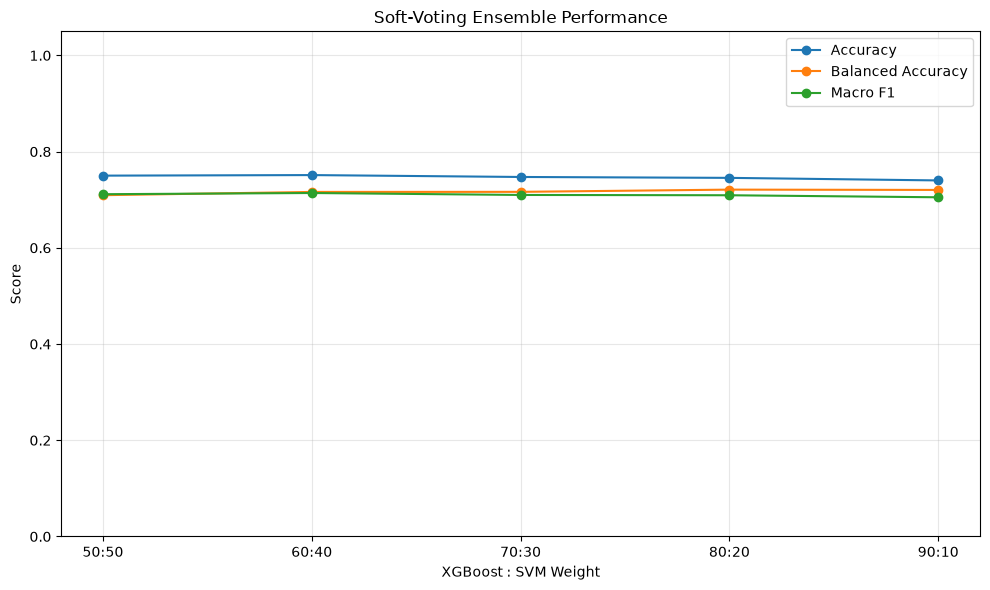

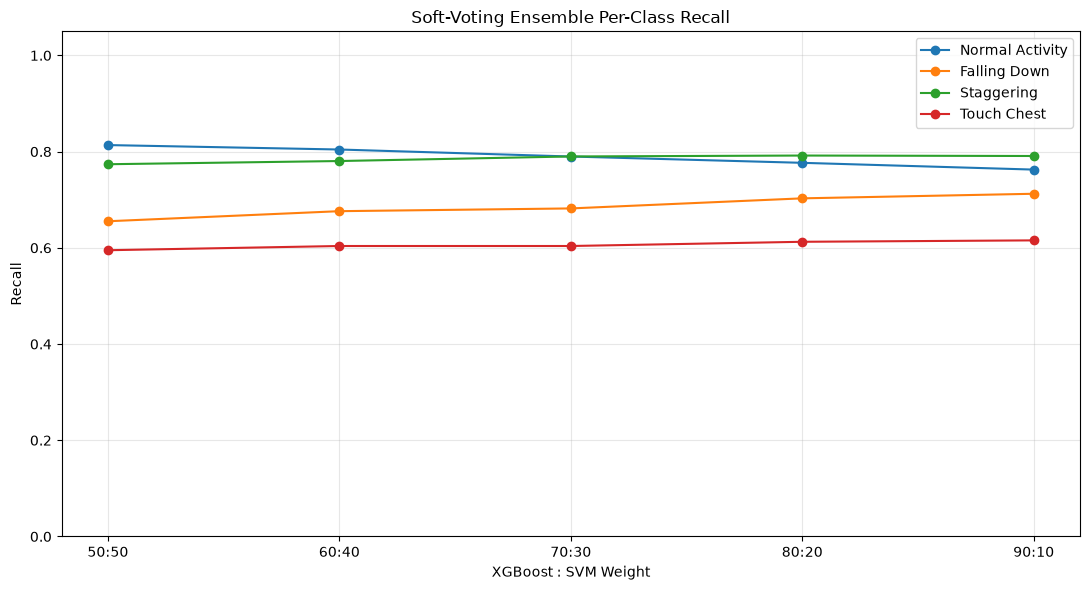

In [52]:
# Step 21A - Test soft-voting ensemble weights for XGBoost and RBF-SVM

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# Get XGBoost validation probabilities
xgb_val_prob = xgb_tuned.predict_proba(
    X_val_xgb
)

# Get SVM validation probabilities
svm_val_prob = svm_tuned.predict_proba(
    X_val_direct
)

# XGBoost uses numeric encoded classes
# Convert the probability columns into the common class order
common_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Find XGBoost probability column positions for each class
xgb_class_positions = {
    class_name: list(xgb_label_encoder.classes_).index(class_name)
    for class_name in common_classes
}

# Reorder XGBoost probabilities into the common class order
xgb_val_prob_ordered = np.column_stack([
    xgb_val_prob[:, xgb_class_positions[class_name]]
    for class_name in common_classes
])

# Find SVM probability column positions
svm_class_positions = {
    class_name: list(svm_tuned.classes_).index(class_name)
    for class_name in common_classes
}

# Reorder SVM probabilities into the common class order
svm_val_prob_ordered = np.column_stack([
    svm_val_prob[:, svm_class_positions[class_name]]
    for class_name in common_classes
])

# Test several XGBoost:SVM voting weights
weight_pairs = [
    (0.50, 0.50),
    (0.60, 0.40),
    (0.70, 0.30),
    (0.80, 0.20),
    (0.90, 0.10)
]

# Store ensemble results
ensemble_results = []

for xgb_weight, svm_weight in weight_pairs:

    # Combine model probabilities
    combined_prob = (
        xgb_weight * xgb_val_prob_ordered
        +
        svm_weight * svm_val_prob_ordered
    )

    # Select the class with the highest combined probability
    combined_pred_indices = np.argmax(
        combined_prob,
        axis=1
    )

    # Convert prediction indices back into class names
    combined_predictions = np.array([
        common_classes[index]
        for index in combined_pred_indices
    ])

    # Calculate overall metrics
    accuracy = accuracy_score(
        y_val_direct,
        combined_predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_val_direct,
        combined_predictions
    )

    macro_precision = precision_score(
        y_val_direct,
        combined_predictions,
        labels=common_classes,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_val_direct,
        combined_predictions,
        labels=common_classes,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_val_direct,
        combined_predictions,
        labels=common_classes,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_val_direct,
        combined_predictions,
        labels=common_classes,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_val_direct,
        combined_predictions
    )

    # Calculate per-class recall
    class_recalls = recall_score(
        y_val_direct,
        combined_predictions,
        labels=common_classes,
        average=None,
        zero_division=0
    )

    # Save this weight combination
    ensemble_results.append({
        "XGBoost Weight": xgb_weight,
        "SVM Weight": svm_weight,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "MCC": mcc,
        "Normal Recall": class_recalls[0],
        "Falling Recall": class_recalls[1],
        "Staggering Recall": class_recalls[2],
        "Touch Chest Recall": class_recalls[3]
    })

# Convert all results to a DataFrame
ensemble_results_df = pd.DataFrame(
    ensemble_results
)

# Print all ensemble results
print("XGBOOST + RBF-SVM SOFT-VOTING RESULTS")

print(
    ensemble_results_df.round(4).to_string(
        index=False
    )
)

# Find the best ensemble by Macro F1
best_ensemble_row = ensemble_results_df.loc[
    ensemble_results_df["Macro F1"].idxmax()
]

print("\nBEST ENSEMBLE BY MACRO F1")

print(
    best_ensemble_row.round(4)
)

# Plot overall performance across weight combinations
weight_labels = [
    f"{int(row['XGBoost Weight'] * 100)}:{int(row['SVM Weight'] * 100)}"
    for _, row in ensemble_results_df.iterrows()
]

plt.figure(figsize=(10, 6))

plt.plot(
    weight_labels,
    ensemble_results_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    weight_labels,
    ensemble_results_df["Balanced Accuracy"],
    marker="o",
    label="Balanced Accuracy"
)

plt.plot(
    weight_labels,
    ensemble_results_df["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.xlabel("XGBoost : SVM Weight")
plt.ylabel("Score")
plt.title("Soft-Voting Ensemble Performance")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot per-class recall across weight combinations
plt.figure(figsize=(11, 6))

plt.plot(
    weight_labels,
    ensemble_results_df["Normal Recall"],
    marker="o",
    label="Normal Activity"
)

plt.plot(
    weight_labels,
    ensemble_results_df["Falling Recall"],
    marker="o",
    label="Falling Down"
)

plt.plot(
    weight_labels,
    ensemble_results_df["Staggering Recall"],
    marker="o",
    label="Staggering"
)

plt.plot(
    weight_labels,
    ensemble_results_df["Touch Chest Recall"],
    marker="o",
    label="Touch Chest"
)

plt.xlabel("XGBoost : SVM Weight")
plt.ylabel("Recall")
plt.title("Soft-Voting Ensemble Per-Class Recall")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

CLASS-SPECIFIC ENSEMBLE RESULTS
              Scheme  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1    MCC  Normal Recall  Falling Recall  Staggering Recall  Touch Chest Recall  Priority Score
      Balanced 60-40    0.7512             0.7162           0.7141        0.7162    0.7140       0.7515 0.6310         0.8044          0.6762             0.7804              0.6038          0.6622
 Abnormal Priority B    0.7524             0.7148           0.7150        0.7148    0.7139       0.7521 0.6322         0.8053          0.6629             0.7947              0.5965          0.6549
 Abnormal Priority A    0.7519             0.7139           0.7146        0.7139    0.7132       0.7517 0.6314         0.8063          0.6610             0.7918              0.5965          0.6541
 Fall + Chest Strong    0.7547             0.7145           0.7197        0.7145    0.7161       0.7539 0.6345         0.8121          0.6552             0.7956              0.5950

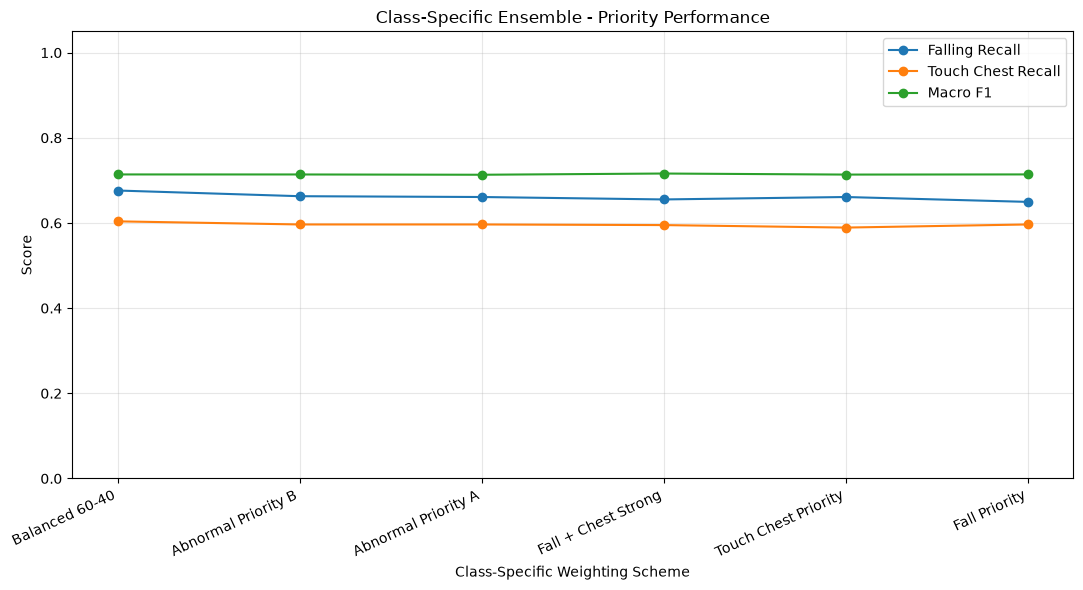

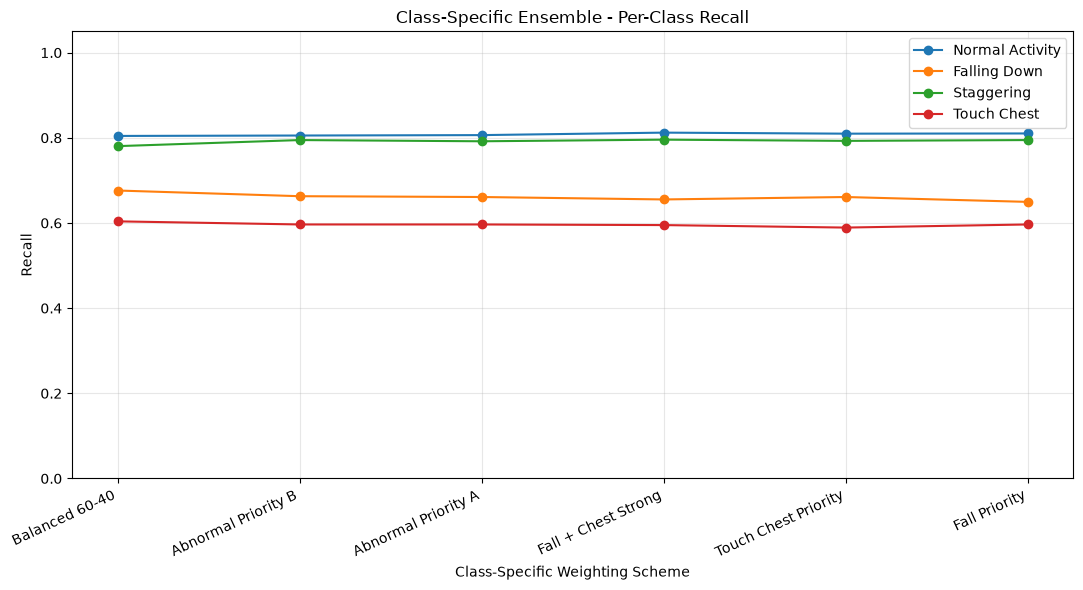

In [54]:
# Step 21B - Class-specific XGBoost + SVM ensemble weighting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# Reuse the already ordered probability matrices
# xgb_val_prob_ordered
# svm_val_prob_ordered

common_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Define class-specific XGBoost weights
# SVM weight is automatically 1 - XGBoost weight
weight_schemes = [
    {
        "Name": "Balanced 60-40",
        "Normal Activity": 0.60,
        "Falling Down": 0.60,
        "Staggering/Unbalanced Movement": 0.60,
        "Touch Chest": 0.60
    },

    {
        "Name": "Abnormal Priority A",
        "Normal Activity": 0.70,
        "Falling Down": 0.40,
        "Staggering/Unbalanced Movement": 0.70,
        "Touch Chest": 0.35
    },

    {
        "Name": "Abnormal Priority B",
        "Normal Activity": 0.75,
        "Falling Down": 0.35,
        "Staggering/Unbalanced Movement": 0.70,
        "Touch Chest": 0.30
    },

    {
        "Name": "Fall + Chest Strong",
        "Normal Activity": 0.70,
        "Falling Down": 0.30,
        "Staggering/Unbalanced Movement": 0.70,
        "Touch Chest": 0.25
    },

    {
        "Name": "Fall Priority",
        "Normal Activity": 0.70,
        "Falling Down": 0.25,
        "Staggering/Unbalanced Movement": 0.70,
        "Touch Chest": 0.35
    },

    {
        "Name": "Touch Chest Priority",
        "Normal Activity": 0.70,
        "Falling Down": 0.40,
        "Staggering/Unbalanced Movement": 0.70,
        "Touch Chest": 0.20
    }
]

# Store results
class_specific_results = []

# Store predictions for each scheme
class_specific_predictions = {}

for scheme in weight_schemes:

    # Create an empty combined probability matrix
    combined_prob = np.zeros_like(
        xgb_val_prob_ordered
    )

    # Combine probabilities separately for every class
    for class_index, class_name in enumerate(common_classes):

        xgb_weight = scheme[class_name]
        svm_weight = 1.0 - xgb_weight

        combined_prob[:, class_index] = (
            xgb_weight
            * xgb_val_prob_ordered[:, class_index]
            +
            svm_weight
            * svm_val_prob_ordered[:, class_index]
        )

    # Normalize probabilities so every row sums to 1
    combined_prob = (
        combined_prob
        /
        combined_prob.sum(
            axis=1,
            keepdims=True
        )
    )

    # Select the class with the largest combined probability
    prediction_indices = np.argmax(
        combined_prob,
        axis=1
    )

    predictions = np.array([
        common_classes[index]
        for index in prediction_indices
    ])

    # Save predictions in case we want them later
    class_specific_predictions[
        scheme["Name"]
    ] = predictions

    # Calculate overall metrics
    accuracy = accuracy_score(
        y_val_direct,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        y_val_direct,
        predictions
    )

    macro_precision = precision_score(
        y_val_direct,
        predictions,
        labels=common_classes,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_val_direct,
        predictions,
        labels=common_classes,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_val_direct,
        predictions,
        labels=common_classes,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_val_direct,
        predictions,
        labels=common_classes,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_val_direct,
        predictions
    )

    # Calculate recall separately for every class
    class_recalls = recall_score(
        y_val_direct,
        predictions,
        labels=common_classes,
        average=None,
        zero_division=0
    )

    normal_recall = class_recalls[0]
    falling_recall = class_recalls[1]
    staggering_recall = class_recalls[2]
    touch_chest_recall = class_recalls[3]

    # Create a custom score that strongly values
    # Falling and Touch Chest while still rewarding Macro F1
    priority_score = (
        0.35 * falling_recall
        +
        0.35 * touch_chest_recall
        +
        0.30 * macro_f1
    )

    # Save the result
    class_specific_results.append({
        "Scheme": scheme["Name"],
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "MCC": mcc,
        "Normal Recall": normal_recall,
        "Falling Recall": falling_recall,
        "Staggering Recall": staggering_recall,
        "Touch Chest Recall": touch_chest_recall,
        "Priority Score": priority_score
    })

# Convert results into a DataFrame
class_specific_results_df = pd.DataFrame(
    class_specific_results
)

# Sort by the custom priority score
class_specific_results_df = (
    class_specific_results_df
    .sort_values(
        by="Priority Score",
        ascending=False
    )
    .reset_index(drop=True)
)

# Print all results
print("CLASS-SPECIFIC ENSEMBLE RESULTS")

print(
    class_specific_results_df.round(4).to_string(
        index=False
    )
)

# Show the best scheme
best_priority_scheme = (
    class_specific_results_df.iloc[0]
)

print("\nBEST SCHEME FOR FALLING + TOUCH CHEST PRIORITY")

# Print the best scheme without trying to round the text column
print("Scheme:", best_priority_scheme["Scheme"])

print("\nScores:")

for column in best_priority_scheme.index:

    # Skip the text column
    if column == "Scheme":
        continue

    print(
        f"{column}: {best_priority_scheme[column]:.4f}"
    )

# Plot Falling and Touch Chest recall
plt.figure(figsize=(11, 6))

plt.plot(
    class_specific_results_df["Scheme"],
    class_specific_results_df["Falling Recall"],
    marker="o",
    label="Falling Recall"
)

plt.plot(
    class_specific_results_df["Scheme"],
    class_specific_results_df["Touch Chest Recall"],
    marker="o",
    label="Touch Chest Recall"
)

plt.plot(
    class_specific_results_df["Scheme"],
    class_specific_results_df["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.ylabel("Score")
plt.xlabel("Class-Specific Weighting Scheme")
plt.title("Class-Specific Ensemble - Priority Performance")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot recall for all four classes
plt.figure(figsize=(11, 6))

plt.plot(
    class_specific_results_df["Scheme"],
    class_specific_results_df["Normal Recall"],
    marker="o",
    label="Normal Activity"
)

plt.plot(
    class_specific_results_df["Scheme"],
    class_specific_results_df["Falling Recall"],
    marker="o",
    label="Falling Down"
)

plt.plot(
    class_specific_results_df["Scheme"],
    class_specific_results_df["Staggering Recall"],
    marker="o",
    label="Staggering"
)

plt.plot(
    class_specific_results_df["Scheme"],
    class_specific_results_df["Touch Chest Recall"],
    marker="o",
    label="Touch Chest"
)

plt.ylabel("Recall")
plt.xlabel("Class-Specific Weighting Scheme")
plt.title("Class-Specific Ensemble - Per-Class Recall")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

TOP DECISION-BIAS CONFIGURATIONS
 Falling Multiplier  Touch Multiplier  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1    MCC  Normal Recall  Falling Recall  Staggering Recall  Touch Chest Recall  Falling Precision  Touch Chest Precision  Priority Score
               1.40              1.40    0.7378             0.7240           0.6968        0.7240    0.7056       0.7424 0.6207         0.7612          0.7371             0.7529              0.6447             0.5375                 0.6058          0.6953
               1.40              1.30    0.7385             0.7227           0.6977        0.7227    0.7056       0.7427 0.6208         0.7655          0.7371             0.7538              0.6345             0.5360                 0.6147          0.6918
               1.40              1.25    0.7401             0.7229           0.6995        0.7229    0.7066       0.7441 0.6225         0.7704          0.7371             0.7538              0.6301  

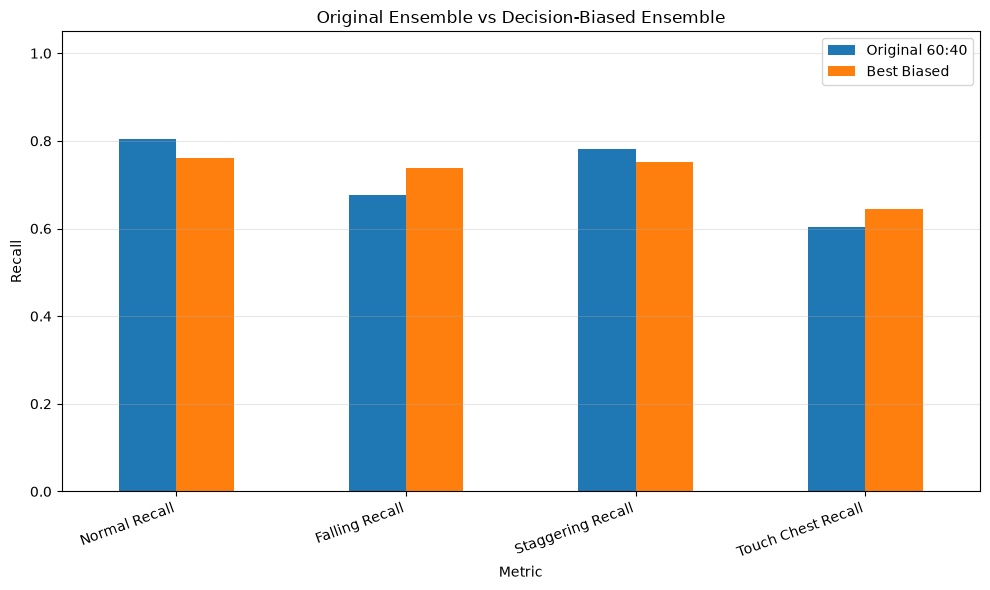

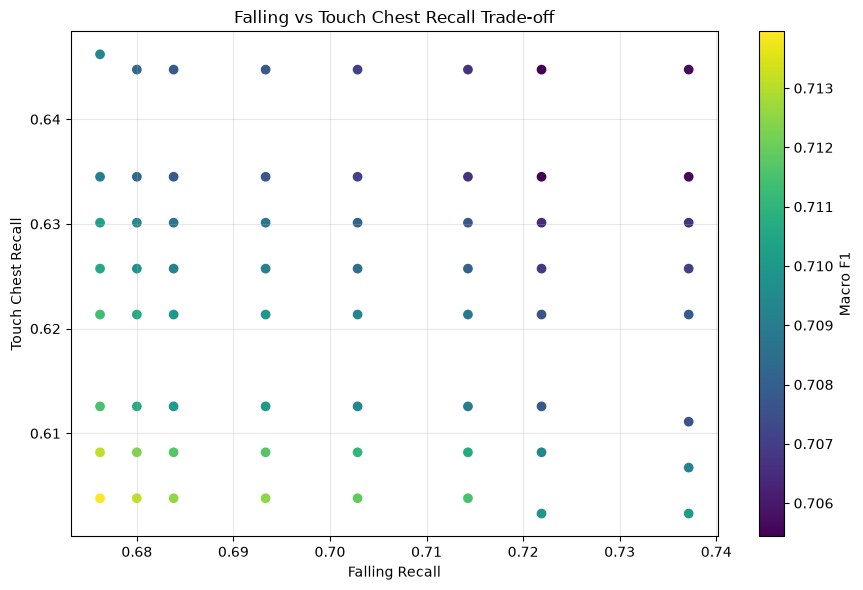

In [55]:
# Step 21C - Search class decision multipliers for Falling and Touch Chest

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# Build the current best 60:40 ensemble probabilities
best_ensemble_prob = (
    0.60 * xgb_val_prob_ordered
    +
    0.40 * svm_val_prob_ordered
)

# Keep the same class order
common_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Find class positions
normal_index = common_classes.index("Normal Activity")
falling_index = common_classes.index("Falling Down")
staggering_index = common_classes.index("Staggering/Unbalanced Movement")
touch_index = common_classes.index("Touch Chest")

# Test several multipliers
falling_multipliers = [
    1.00,
    1.05,
    1.10,
    1.15,
    1.20,
    1.25,
    1.30,
    1.40
]

touch_multipliers = [
    1.00,
    1.05,
    1.10,
    1.15,
    1.20,
    1.25,
    1.30,
    1.40
]

# Store every result
decision_bias_results = []

# Store predictions in case we want the best one later
decision_bias_predictions = {}

for falling_multiplier in falling_multipliers:

    for touch_multiplier in touch_multipliers:

        # Copy the original ensemble probabilities
        adjusted_scores = best_ensemble_prob.copy()

        # Increase the decision score for Falling
        adjusted_scores[:, falling_index] *= falling_multiplier

        # Increase the decision score for Touch Chest
        adjusted_scores[:, touch_index] *= touch_multiplier

        # Pick the class with the highest adjusted score
        prediction_indices = np.argmax(
            adjusted_scores,
            axis=1
        )

        predictions = np.array([
            common_classes[index]
            for index in prediction_indices
        ])

        # Save predictions
        key = (
            falling_multiplier,
            touch_multiplier
        )

        decision_bias_predictions[key] = predictions

        # Calculate overall metrics
        accuracy = accuracy_score(
            y_val_direct,
            predictions
        )

        balanced_accuracy = balanced_accuracy_score(
            y_val_direct,
            predictions
        )

        macro_precision = precision_score(
            y_val_direct,
            predictions,
            labels=common_classes,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_val_direct,
            predictions,
            labels=common_classes,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_val_direct,
            predictions,
            labels=common_classes,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_val_direct,
            predictions,
            labels=common_classes,
            average="weighted",
            zero_division=0
        )

        mcc = matthews_corrcoef(
            y_val_direct,
            predictions
        )

        # Calculate recall for each class
        class_recalls = recall_score(
            y_val_direct,
            predictions,
            labels=common_classes,
            average=None,
            zero_division=0
        )

        # Calculate precision for each class
        class_precisions = precision_score(
            y_val_direct,
            predictions,
            labels=common_classes,
            average=None,
            zero_division=0
        )

        normal_recall = class_recalls[normal_index]
        falling_recall = class_recalls[falling_index]
        staggering_recall = class_recalls[staggering_index]
        touch_recall = class_recalls[touch_index]

        falling_precision = class_precisions[falling_index]
        touch_precision = class_precisions[touch_index]

        # Custom score prioritizes Falling and Touch Chest
        priority_score = (
            0.35 * falling_recall
            +
            0.35 * touch_recall
            +
            0.30 * macro_f1
        )

        # Save results
        decision_bias_results.append({
            "Falling Multiplier": falling_multiplier,
            "Touch Multiplier": touch_multiplier,
            "Accuracy": accuracy,
            "Balanced Accuracy": balanced_accuracy,
            "Macro Precision": macro_precision,
            "Macro Recall": macro_recall,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1,
            "MCC": mcc,
            "Normal Recall": normal_recall,
            "Falling Recall": falling_recall,
            "Staggering Recall": staggering_recall,
            "Touch Chest Recall": touch_recall,
            "Falling Precision": falling_precision,
            "Touch Chest Precision": touch_precision,
            "Priority Score": priority_score
        })

# Convert results to DataFrame
decision_bias_df = pd.DataFrame(
    decision_bias_results
)

# Apply safety constraints so we do not destroy overall performance
acceptable_bias_df = decision_bias_df[
    (decision_bias_df["Macro F1"] >= 0.69)
    &
    (decision_bias_df["Normal Recall"] >= 0.70)
    &
    (decision_bias_df["Staggering Recall"] >= 0.72)
].copy()

# Sort acceptable settings by the Falling + Touch Chest priority score
acceptable_bias_df = acceptable_bias_df.sort_values(
    by="Priority Score",
    ascending=False
).reset_index(drop=True)

print("TOP DECISION-BIAS CONFIGURATIONS")

print(
    acceptable_bias_df.head(15).round(4).to_string(
        index=False
    )
)

# Select the best acceptable configuration
best_bias = acceptable_bias_df.iloc[0]

print("\nBEST DECISION-BIAS CONFIGURATION")

for column in best_bias.index:
    print(
        f"{column}: {best_bias[column]:.4f}"
    )

# Compare the best biased configuration with the original 60:40 ensemble
original_row = decision_bias_df[
    (decision_bias_df["Falling Multiplier"] == 1.00)
    &
    (decision_bias_df["Touch Multiplier"] == 1.00)
].iloc[0]

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "MCC",
        "Normal Recall",
        "Falling Recall",
        "Staggering Recall",
        "Touch Chest Recall",
        "Falling Precision",
        "Touch Chest Precision"
    ],

    "Original 60:40": [
        original_row["Accuracy"],
        original_row["Balanced Accuracy"],
        original_row["Macro F1"],
        original_row["MCC"],
        original_row["Normal Recall"],
        original_row["Falling Recall"],
        original_row["Staggering Recall"],
        original_row["Touch Chest Recall"],
        original_row["Falling Precision"],
        original_row["Touch Chest Precision"]
    ],

    "Best Biased": [
        best_bias["Accuracy"],
        best_bias["Balanced Accuracy"],
        best_bias["Macro F1"],
        best_bias["MCC"],
        best_bias["Normal Recall"],
        best_bias["Falling Recall"],
        best_bias["Staggering Recall"],
        best_bias["Touch Chest Recall"],
        best_bias["Falling Precision"],
        best_bias["Touch Chest Precision"]
    ]
})

comparison_df["Change"] = (
    comparison_df["Best Biased"]
    - comparison_df["Original 60:40"]
)

print("\nORIGINAL 60:40 VS BEST DECISION BIAS")

print(
    comparison_df.to_string(
        index=False,
        formatters={
            "Original 60:40": "{:.4f}".format,
            "Best Biased": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

# Plot the most important recall comparison
important_metrics = comparison_df[
    comparison_df["Metric"].isin([
        "Normal Recall",
        "Falling Recall",
        "Staggering Recall",
        "Touch Chest Recall"
    ])
]

important_metrics.set_index(
    "Metric"
)[
    ["Original 60:40", "Best Biased"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Recall")
plt.title("Original Ensemble vs Decision-Biased Ensemble")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Show the trade-off between Falling and Touch Chest recall
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    acceptable_bias_df["Falling Recall"],
    acceptable_bias_df["Touch Chest Recall"],
    c=acceptable_bias_df["Macro F1"]
)

plt.xlabel("Falling Recall")
plt.ylabel("Touch Chest Recall")
plt.title("Falling vs Touch Chest Recall Trade-off")

plt.colorbar(
    scatter,
    label="Macro F1"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# Step 21D - Export the current best ensemble model

from pathlib import Path
import joblib
import json
import sklearn
import xgboost

# Create the models folder if it does not already exist
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Create one bundle containing both trained models
best_ensemble_bundle = {
    # Tuned XGBoost model
    "xgboost_model": xgb_tuned,

    # Tuned RBF-SVM pipeline
    # This includes both StandardScaler and SVC
    "svm_model": svm_tuned,

    # Exact 20-feature order expected by both models
    "feature_columns": list(feature_columns),

    # Final output class order used by the ensemble
    "class_order": [
        "Normal Activity",
        "Falling Down",
        "Staggering/Unbalanced Movement",
        "Touch Chest"
    ],

    # Label encoder required by XGBoost
    "xgboost_label_encoder": xgb_label_encoder,

    # Best normal soft-voting configuration
    "ensemble_weights": {
        "xgboost": 0.60,
        "svm": 0.40
    },

    # Optional safety-oriented decision multipliers
    "safety_decision_multipliers": {
        "Normal Activity": 1.00,
        "Falling Down": 1.40,
        "Staggering/Unbalanced Movement": 1.00,
        "Touch Chest": 1.40
    },

    # Validation results for the normal 60:40 ensemble
    "general_ensemble_validation": {
        "accuracy": 0.7512,
        "balanced_accuracy": 0.7162,
        "macro_precision": 0.7141,
        "macro_recall": 0.7162,
        "macro_f1": 0.7140,
        "weighted_f1": 0.7515,
        "mcc": 0.6310,
        "normal_recall": 0.8044,
        "falling_recall": 0.6762,
        "staggering_recall": 0.7804,
        "touch_chest_recall": 0.6038
    },

    # Validation results for the safety-oriented decision rule
    "safety_ensemble_validation": {
        "accuracy": 0.7378,
        "balanced_accuracy": 0.7240,
        "macro_precision": 0.6968,
        "macro_recall": 0.7240,
        "macro_f1": 0.7056,
        "weighted_f1": 0.7424,
        "mcc": 0.6207,
        "normal_recall": 0.7612,
        "falling_recall": 0.7371,
        "staggering_recall": 0.7529,
        "touch_chest_recall": 0.6447,
        "falling_precision": 0.5375,
        "touch_chest_precision": 0.6058
    },

    # Important software versions for reproducibility
    "versions": {
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__
    }
}

# Define the ensemble file path
best_ensemble_path = (
    models_dir
    / "best_xgboost_svm_ensemble.joblib"
)

# Save the complete ensemble bundle
joblib.dump(
    best_ensemble_bundle,
    best_ensemble_path
)

# Create readable metadata without the model objects
ensemble_metadata = {
    "feature_columns": best_ensemble_bundle["feature_columns"],
    "class_order": best_ensemble_bundle["class_order"],
    "ensemble_weights": best_ensemble_bundle["ensemble_weights"],
    "safety_decision_multipliers": best_ensemble_bundle[
        "safety_decision_multipliers"
    ],
    "general_ensemble_validation": best_ensemble_bundle[
        "general_ensemble_validation"
    ],
    "safety_ensemble_validation": best_ensemble_bundle[
        "safety_ensemble_validation"
    ],
    "versions": best_ensemble_bundle["versions"]
}

# Define metadata file path
ensemble_metadata_path = (
    models_dir
    / "best_xgboost_svm_ensemble_metadata.json"
)

# Save readable metadata
with open(
    ensemble_metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        ensemble_metadata,
        f,
        indent=4
    )

# Reload the saved ensemble bundle
loaded_ensemble = joblib.load(
    best_ensemble_path
)

# Verify important components
print("BEST ENSEMBLE SAVE VERIFICATION")

print("\nModel file:")
print(best_ensemble_path)

print("\nMetadata file:")
print(ensemble_metadata_path)

print("\nNumber of features:")
print(
    len(
        loaded_ensemble["feature_columns"]
    )
)

print("\nClass order:")
print(
    loaded_ensemble["class_order"]
)

print("\nEnsemble weights:")
print(
    loaded_ensemble["ensemble_weights"]
)

print("\nSafety decision multipliers:")
print(
    loaded_ensemble["safety_decision_multipliers"]
)

print("\nXGBoost model type:")
print(
    type(
        loaded_ensemble["xgboost_model"]
    )
)

print("\nSVM model type:")
print(
    type(
        loaded_ensemble["svm_model"]
    )
)

print("\nEnsemble successfully saved and reloaded.")

BEST ENSEMBLE SAVE VERIFICATION

Model file:
models\best_xgboost_svm_ensemble.joblib

Metadata file:
models\best_xgboost_svm_ensemble_metadata.json

Number of features:
20

Class order:
['Normal Activity', 'Falling Down', 'Staggering/Unbalanced Movement', 'Touch Chest']

Ensemble weights:
{'xgboost': 0.6, 'svm': 0.4}

Safety decision multipliers:
{'Normal Activity': 1.0, 'Falling Down': 1.4, 'Staggering/Unbalanced Movement': 1.0, 'Touch Chest': 1.4}

XGBoost model type:
<class 'xgboost.sklearn.XGBClassifier'>

SVM model type:
<class 'sklearn.pipeline.Pipeline'>

Ensemble successfully saved and reloaded.


# New feature engineering
post_fall_low_head_ratio
**Purpose:** detect whether the head remains low after a downward movement.
**Mainly helps:** Falling Down
head_vertical_accel_peak
**Purpose**: measure the strongest sudden change in vertical head velocity.
**Mainly helps:** Falling Down
pre_post_head_speed_change
**Purpose:** compare head movement speed before and after the main drop.
**Mainly helps:** Falling Down
hand_to_chest_dwell_ratio
**Purpose:** measure what fraction of the 30-frame window the hand stays close to the chest.
**Mainly helps:** Touch Chest
hand_approach_speed_to_chest
**Purpose:** measure how quickly the hand moves toward the chest.
**Mainly helps:** Touch Chest
hand_distance_stability_near_chest
**Purpose:** measure whether the hand remains at a stable small distance from the chest after approaching it.
**Mainly helps:** Touch Chest

In [58]:
# Step 22C - Apply the existing subject split to the new 26-feature dataset

import pandas as pd

# Load the new 26-feature dataset
features_v2 = pd.read_csv("./8_features_v2.csv")

# Load the original subject split
subject_split = pd.read_csv("subject_split.csv")

# Check the split file
print("Subject split columns:")
print(subject_split.columns.tolist())

print("\nSubject split preview:")
print(subject_split.head())

Subject split columns:
['subject_id', 'split']

Subject split preview:
   subject_id  split
0          18   test
1          26   test
2          27   test
3          37   test
4           2  train


In [59]:
# Step 22C - Create train, validation, and test files for 26-feature dataset

import pandas as pd

# Load new feature dataset
features_v2 = pd.read_csv("8_features_v2.csv")

# Load original subject split
subject_split = pd.read_csv("subject_split.csv")

# Merge split information onto the new dataset
features_v2_split = features_v2.merge(
    subject_split,
    on="subject_id",
    how="left"
)

# Check for any subjects that did not receive a split
print("Missing split assignments:")
print(features_v2_split["split"].isna().sum())

# Create the three datasets
train_v2 = features_v2_split[
    features_v2_split["split"] == "train"
].copy()

val_v2 = features_v2_split[
    features_v2_split["split"] == "validation"
].copy()

test_v2 = features_v2_split[
    features_v2_split["split"] == "test"
].copy()

# Remove the temporary split column before saving
train_v2 = train_v2.drop(columns=["split"])
val_v2 = val_v2.drop(columns=["split"])
test_v2 = test_v2.drop(columns=["split"])

# Save files
train_v2.to_csv(
    "train_features_v2.csv",
    index=False
)

val_v2.to_csv(
    "validation_features_v2.csv",
    index=False
)

test_v2.to_csv(
    "test_features_v2.csv",
    index=False
)

print("\nShapes:")
print("Train:", train_v2.shape)
print("Validation:", val_v2.shape)
print("Test:", test_v2.shape)

print("\nTrain class distribution:")
print(train_v2["label"].value_counts())

print("\nValidation class distribution:")
print(val_v2["label"].value_counts())

print("\nTest class distribution:")
print(test_v2["label"].value_counts())

Missing split assignments:
0

Shapes:
Train: (15140, 31)
Validation: (4321, 31)
Test: (2153, 31)

Train class distribution:
label
Normal Activity                   7185
Staggering/Unbalanced Movement    3684
Touch Chest                       2425
Falling Down                      1846
Name: count, dtype: int64

Validation class distribution:
label
Normal Activity                   2060
Staggering/Unbalanced Movement    1052
Touch Chest                        684
Falling Down                       525
Name: count, dtype: int64

Test class distribution:
label
Normal Activity                   1030
Staggering/Unbalanced Movement     510
Touch Chest                        346
Falling Down                       267
Name: count, dtype: int64


In [60]:
# Step 22D - Prepare the 26-feature training and validation matrices

import pandas as pd
import numpy as np

# Load the new split files
train_v2 = pd.read_csv("train_features_v2.csv")
val_v2 = pd.read_csv("validation_features_v2.csv")
test_v2 = pd.read_csv("test_features_v2.csv")

# Metadata columns that are not used for training
metadata_columns = [
    "window_id",
    "filename",
    "subject_id",
    "action_code",
    "label"
]

# All remaining columns are features
feature_columns_v2 = [
    column
    for column in train_v2.columns
    if column not in metadata_columns
]

print("Number of features:")
print(len(feature_columns_v2))

print("\nFeature columns:")
for i, feature in enumerate(feature_columns_v2, start=1):
    print(f"{i:2d}. {feature}")

# Prepare X and y
X_train_v2 = train_v2[feature_columns_v2].copy()
y_train_v2 = train_v2["label"].copy()

X_val_v2 = val_v2[feature_columns_v2].copy()
y_val_v2 = val_v2["label"].copy()

X_test_v2 = test_v2[feature_columns_v2].copy()
y_test_v2 = test_v2["label"].copy()

print("\nShapes:")
print("X_train_v2:", X_train_v2.shape)
print("X_val_v2:", X_val_v2.shape)
print("X_test_v2:", X_test_v2.shape)

print("\nMissing values:")
print("Train:", X_train_v2.isna().sum().sum())
print("Validation:", X_val_v2.isna().sum().sum())
print("Test:", X_test_v2.isna().sum().sum())

print("\nInfinite values:")
print("Train:", np.isinf(X_train_v2.to_numpy()).sum())
print("Validation:", np.isinf(X_val_v2.to_numpy()).sum())
print("Test:", np.isinf(X_test_v2.to_numpy()).sum())

Number of features:
26

Feature columns:
 1. head_drop
 2. shoulder_drop
 3. head_velocity_mean
 4. head_velocity_max
 5. torso_tilt_std
 6. torso_tilt_range
 7. lateral_sway_range
 8. sway_direction_changes
 9. min_hand_to_chest
10. hand_to_chest_drop
11. accel_slope
12. vertical_ratio
13. max_downward_vel
14. ending_tilt
15. tilt_net_change
16. knee_bend_min
17. elbow_angle_min
18. hand_dwell_frames
19. foot_sep_std
20. time_to_min_drop
21. post_fall_low_head_ratio
22. head_vertical_accel_peak
23. pre_post_head_speed_change
24. hand_approach_speed
25. hand_dwell_longest_run
26. hand_near_chest_stability

Shapes:
X_train_v2: (15140, 26)
X_val_v2: (4321, 26)
X_test_v2: (2153, 26)

Missing values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0


In [61]:
# Step 22E - Train XGBoost using the new 26-feature dataset

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


# Encode the class labels
label_encoder_v2 = LabelEncoder()

y_train_v2_encoded = label_encoder_v2.fit_transform(
    y_train_v2
)

y_val_v2_encoded = label_encoder_v2.transform(
    y_val_v2
)


print("Class mapping:")

for index, class_name in enumerate(
    label_encoder_v2.classes_
):
    print(
        index,
        "->",
        class_name
    )


# Create balanced sample weights
xgb_train_weights_v2 = compute_sample_weight(
    class_weight="balanced",
    y=y_train_v2_encoded
)


# Use the same best XGBoost parameters from the 20-feature experiment
xgb_v2 = XGBClassifier(
    n_estimators=400,
    learning_rate=0.02,
    max_depth=7,
    min_child_weight=7,
    gamma=0.5,
    subsample=0.7,
    colsample_bytree=1.0,
    reg_alpha=0.01,
    reg_lambda=2.0,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)


# Train the model
xgb_v2.fit(
    X_train_v2,
    y_train_v2_encoded,
    sample_weight=xgb_train_weights_v2
)


# Predict validation classes
xgb_v2_val_pred_encoded = xgb_v2.predict(
    X_val_v2
)

xgb_v2_val_pred = label_encoder_v2.inverse_transform(
    xgb_v2_val_pred_encoded
)


# Predict validation probabilities
xgb_v2_val_prob = xgb_v2.predict_proba(
    X_val_v2
)


# Overall metrics
accuracy = accuracy_score(
    y_val_v2,
    xgb_v2_val_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_val_v2,
    xgb_v2_val_pred
)

macro_precision = precision_score(
    y_val_v2,
    xgb_v2_val_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_val_v2,
    xgb_v2_val_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_val_v2,
    xgb_v2_val_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_val_v2,
    xgb_v2_val_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_val_v2,
    xgb_v2_val_pred
)

validation_log_loss = log_loss(
    y_val_v2_encoded,
    xgb_v2_val_prob
)

macro_roc_auc = roc_auc_score(
    y_val_v2_encoded,
    xgb_v2_val_prob,
    multi_class="ovr",
    average="macro"
)


print("\nXGBOOST 26-FEATURE VALIDATION RESULTS")

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Macro Precision:   {macro_precision:.4f}")
print(f"Macro Recall:      {macro_recall:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")
print(f"MCC:               {mcc:.4f}")
print(f"Log Loss:          {validation_log_loss:.4f}")
print(f"Macro ROC-AUC:     {macro_roc_auc:.4f}")


print("\nClassification Report:")

print(
    classification_report(
        y_val_v2,
        xgb_v2_val_pred,
        digits=4
    )
)


print("Confusion Matrix:")

print(
    confusion_matrix(
        y_val_v2,
        xgb_v2_val_pred,
        labels=label_encoder_v2.classes_
    )
)

Class mapping:
0 -> Falling Down
1 -> Normal Activity
2 -> Staggering/Unbalanced Movement
3 -> Touch Chest

XGBOOST 26-FEATURE VALIDATION RESULTS
Accuracy:          0.7440
Balanced Accuracy: 0.7246
Macro Precision:   0.6996
Macro Recall:      0.7246
Macro F1:          0.7088
Weighted F1:       0.7474
MCC:               0.6288
Log Loss:          0.6332
Macro ROC-AUC:     0.9227

Classification Report:
                                precision    recall  f1-score   support

                  Falling Down     0.5376    0.7086    0.6113       525
               Normal Activity     0.8328    0.7665    0.7983      2060
Staggering/Unbalanced Movement     0.7823    0.7890    0.7856      1052
                   Touch Chest     0.6458    0.6345    0.6401       684

                      accuracy                         0.7440      4321
                     macro avg     0.6996    0.7246    0.7088      4321
                  weighted avg     0.7550    0.7440    0.7474      4321

Confusion Matrix:

In [62]:
# Step 22F - Train tuned RBF-SVM using the new 26 features

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Use the same tuned SVM configuration from the 20-feature experiment
svm_v2 = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=5,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42
        )
    )
])

# Train on the new 26-feature training set
svm_v2.fit(
    X_train_v2,
    y_train_v2
)

# Predict validation classes
svm_v2_val_pred = svm_v2.predict(
    X_val_v2
)

# Predict validation probabilities
svm_v2_val_prob = svm_v2.predict_proba(
    X_val_v2
)

# Overall metrics
svm_v2_accuracy = accuracy_score(
    y_val_v2,
    svm_v2_val_pred
)

svm_v2_balanced_accuracy = balanced_accuracy_score(
    y_val_v2,
    svm_v2_val_pred
)

svm_v2_macro_precision = precision_score(
    y_val_v2,
    svm_v2_val_pred,
    average="macro",
    zero_division=0
)

svm_v2_macro_recall = recall_score(
    y_val_v2,
    svm_v2_val_pred,
    average="macro",
    zero_division=0
)

svm_v2_macro_f1 = f1_score(
    y_val_v2,
    svm_v2_val_pred,
    average="macro",
    zero_division=0
)

svm_v2_weighted_f1 = f1_score(
    y_val_v2,
    svm_v2_val_pred,
    average="weighted",
    zero_division=0
)

svm_v2_mcc = matthews_corrcoef(
    y_val_v2,
    svm_v2_val_pred
)

# Get SVM class order
svm_v2_classes = svm_v2.named_steps["svm"].classes_

# Convert true labels to positions matching SVM probability columns
class_to_index = {
    class_name: index
    for index, class_name in enumerate(svm_v2_classes)
}

y_val_svm_encoded = y_val_v2.map(
    class_to_index
).to_numpy()

svm_v2_log_loss = log_loss(
    y_val_svm_encoded,
    svm_v2_val_prob
)

svm_v2_roc_auc = roc_auc_score(
    y_val_svm_encoded,
    svm_v2_val_prob,
    multi_class="ovr",
    average="macro"
)

print("RBF-SVM 26-FEATURE VALIDATION RESULTS")

print(f"\nAccuracy:          {svm_v2_accuracy:.4f}")
print(f"Balanced Accuracy: {svm_v2_balanced_accuracy:.4f}")
print(f"Macro Precision:   {svm_v2_macro_precision:.4f}")
print(f"Macro Recall:      {svm_v2_macro_recall:.4f}")
print(f"Macro F1:          {svm_v2_macro_f1:.4f}")
print(f"Weighted F1:       {svm_v2_weighted_f1:.4f}")
print(f"MCC:               {svm_v2_mcc:.4f}")
print(f"Log Loss:          {svm_v2_log_loss:.4f}")
print(f"Macro ROC-AUC:     {svm_v2_roc_auc:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_val_v2,
        svm_v2_val_pred,
        digits=4
    )
)

print("Confusion Matrix:")

print(
    confusion_matrix(
        y_val_v2,
        svm_v2_val_pred,
        labels=svm_v2_classes
    )
)

D:\Career\Projects\cse 445\emergency behaviour classification from cctv\nturgbd_skeletons_s001_to_s017\nturgb+d_skeletons\Notebook\model_training\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


RBF-SVM 26-FEATURE VALIDATION RESULTS

Accuracy:          0.7357
Balanced Accuracy: 0.7234
Macro Precision:   0.6959
Macro Recall:      0.7234
Macro F1:          0.7062
Weighted F1:       0.7393
MCC:               0.6169
Log Loss:          0.6498
Macro ROC-AUC:     0.9170

Classification Report:
                                precision    recall  f1-score   support

                  Falling Down     0.5464    0.7181    0.6206       525
               Normal Activity     0.8157    0.7539    0.7836      2060
Staggering/Unbalanced Movement     0.7855    0.7519    0.7683      1052
                   Touch Chest     0.6361    0.6696    0.6524       684

                      accuracy                         0.7357      4321
                     macro avg     0.6959    0.7234    0.7062      4321
                  weighted avg     0.7472    0.7357    0.7393      4321

Confusion Matrix:
[[ 377   88   46   14]
 [ 165 1553  136  206]
 [ 108  111  791   42]
 [  40  152   34  458]]


In [64]:
# Step 22G - 60% XGBoost + 40% RBF-SVM ensemble with 26 features

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Use a fixed class order for the ensemble
common_classes_v2 = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Get the probability-column order used by XGBoost
xgb_classes_v2 = list(
    label_encoder_v2.classes_
)

# Get the probability-column order used by SVM
svm_classes_v2 = list(
    svm_v2.named_steps["svm"].classes_
)

print("XGBoost probability class order:")
print(xgb_classes_v2)

print("\nSVM probability class order:")
print(svm_classes_v2)

print("\nCommon ensemble class order:")
print(common_classes_v2)

# Reorder XGBoost probabilities into the common order
xgb_indices_v2 = [
    xgb_classes_v2.index(class_name)
    for class_name in common_classes_v2
]

xgb_v2_prob_ordered = (
    xgb_v2_val_prob[:, xgb_indices_v2]
)

# Reorder SVM probabilities into the same common order
svm_indices_v2 = [
    svm_classes_v2.index(class_name)
    for class_name in common_classes_v2
]

svm_v2_prob_ordered = (
    svm_v2_val_prob[:, svm_indices_v2]
)

# Build the same 60:40 ensemble used previously
ensemble_v2_prob = (
    0.60 * xgb_v2_prob_ordered
    +
    0.40 * svm_v2_prob_ordered
)

# Select the class with the highest ensemble probability
ensemble_v2_pred_indices = np.argmax(
    ensemble_v2_prob,
    axis=1
)

ensemble_v2_pred = np.array([
    common_classes_v2[index]
    for index in ensemble_v2_pred_indices
])

# Calculate overall metrics
ensemble_v2_accuracy = accuracy_score(
    y_val_v2,
    ensemble_v2_pred
)

ensemble_v2_balanced = balanced_accuracy_score(
    y_val_v2,
    ensemble_v2_pred
)

ensemble_v2_macro_precision = precision_score(
    y_val_v2,
    ensemble_v2_pred,
    labels=common_classes_v2,
    average="macro",
    zero_division=0
)

ensemble_v2_macro_recall = recall_score(
    y_val_v2,
    ensemble_v2_pred,
    labels=common_classes_v2,
    average="macro",
    zero_division=0
)

ensemble_v2_macro_f1 = f1_score(
    y_val_v2,
    ensemble_v2_pred,
    labels=common_classes_v2,
    average="macro",
    zero_division=0
)

ensemble_v2_weighted_f1 = f1_score(
    y_val_v2,
    ensemble_v2_pred,
    labels=common_classes_v2,
    average="weighted",
    zero_division=0
)

ensemble_v2_mcc = matthews_corrcoef(
    y_val_v2,
    ensemble_v2_pred
)

# Encode true labels according to common ensemble order
common_class_to_index_v2 = {
    class_name: index
    for index, class_name in enumerate(common_classes_v2)
}

y_val_common_encoded_v2 = np.array([
    common_class_to_index_v2[label]
    for label in y_val_v2
])

ensemble_v2_log_loss = log_loss(
    y_val_common_encoded_v2,
    ensemble_v2_prob,
    labels=list(range(len(common_classes_v2)))
)

ensemble_v2_roc_auc = roc_auc_score(
    y_val_common_encoded_v2,
    ensemble_v2_prob,
    multi_class="ovr",
    average="macro"
)

print("\n26-FEATURE 60:40 ENSEMBLE VALIDATION RESULTS")

print(f"Accuracy:          {ensemble_v2_accuracy:.4f}")
print(f"Balanced Accuracy: {ensemble_v2_balanced:.4f}")
print(f"Macro Precision:   {ensemble_v2_macro_precision:.4f}")
print(f"Macro Recall:      {ensemble_v2_macro_recall:.4f}")
print(f"Macro F1:          {ensemble_v2_macro_f1:.4f}")
print(f"Weighted F1:       {ensemble_v2_weighted_f1:.4f}")
print(f"MCC:               {ensemble_v2_mcc:.4f}")
print(f"Log Loss:          {ensemble_v2_log_loss:.4f}")
print(f"Macro ROC-AUC:     {ensemble_v2_roc_auc:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_val_v2,
        ensemble_v2_pred,
        labels=common_classes_v2,
        digits=4,
        zero_division=0
    )
)

print("Confusion Matrix:")

print(
    confusion_matrix(
        y_val_v2,
        ensemble_v2_pred,
        labels=common_classes_v2
    )
)

XGBoost probability class order:
['Falling Down', 'Normal Activity', 'Staggering/Unbalanced Movement', 'Touch Chest']

SVM probability class order:
['Falling Down', 'Normal Activity', 'Staggering/Unbalanced Movement', 'Touch Chest']

Common ensemble class order:
['Normal Activity', 'Falling Down', 'Staggering/Unbalanced Movement', 'Touch Chest']

26-FEATURE 60:40 ENSEMBLE VALIDATION RESULTS
Accuracy:          0.7563
Balanced Accuracy: 0.7196
Macro Precision:   0.7227
Macro Recall:      0.7196
Macro F1:          0.7200
Weighted F1:       0.7562
MCC:               0.6374
Log Loss:          0.6080
Macro ROC-AUC:     0.9260

Classification Report:
                                precision    recall  f1-score   support

               Normal Activity     0.7955    0.8141    0.8047      2060
                  Falling Down     0.5983    0.6724    0.6332       525
Staggering/Unbalanced Movement     0.8057    0.7766    0.7909      1052
                   Touch Chest     0.6913    0.6155    0.65

D:\Career\Projects\cse 445\emergency behaviour classification from cctv\nturgbd_skeletons_s001_to_s017\nturgb+d_skeletons\Notebook\model_training\venv\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [65]:
# Step 22G fix - Normalize ensemble probabilities

# Normalize every row so probabilities sum exactly to 1
ensemble_v2_prob = (
    ensemble_v2_prob
    / ensemble_v2_prob.sum(axis=1, keepdims=True)
)

# Verify
row_sums = ensemble_v2_prob.sum(axis=1)

print("Minimum probability sum:")
print(row_sums.min())

print("\nMaximum probability sum:")
print(row_sums.max())

# Recalculate probability-based metrics
ensemble_v2_log_loss = log_loss(
    y_val_common_encoded_v2,
    ensemble_v2_prob,
    labels=list(range(len(common_classes_v2)))
)

ensemble_v2_roc_auc = roc_auc_score(
    y_val_common_encoded_v2,
    ensemble_v2_prob,
    multi_class="ovr",
    average="macro"
)

print("\nCorrected probability metrics:")
print(f"Log Loss:      {ensemble_v2_log_loss:.4f}")
print(f"Macro ROC-AUC: {ensemble_v2_roc_auc:.4f}")

Minimum probability sum:
0.9999999999999997

Maximum probability sum:
1.0000000000000002

Corrected probability metrics:
Log Loss:      0.6080
Macro ROC-AUC: 0.9260


In [66]:
# Step 22H - Safety decision bias for the 26-feature ensemble

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

# Start from the normalized 26-feature 60:40 ensemble probabilities
base_prob_v2 = ensemble_v2_prob.copy()

# Class positions
normal_idx = common_classes_v2.index(
    "Normal Activity"
)

falling_idx = common_classes_v2.index(
    "Falling Down"
)

staggering_idx = common_classes_v2.index(
    "Staggering/Unbalanced Movement"
)

touch_idx = common_classes_v2.index(
    "Touch Chest"
)

# Search multipliers
falling_multipliers_v2 = [
    1.00,
    1.05,
    1.10,
    1.15,
    1.20,
    1.25,
    1.30,
    1.35,
    1.40,
    1.45,
    1.50
]

touch_multipliers_v2 = [
    1.00,
    1.05,
    1.10,
    1.15,
    1.20,
    1.25,
    1.30,
    1.35,
    1.40,
    1.45,
    1.50
]

bias_results_v2 = []

for falling_multiplier in falling_multipliers_v2:

    for touch_multiplier in touch_multipliers_v2:

        adjusted_scores = base_prob_v2.copy()

        # Apply safety bias
        adjusted_scores[:, falling_idx] *= falling_multiplier
        adjusted_scores[:, touch_idx] *= touch_multiplier

        # Choose highest adjusted class score
        pred_indices = np.argmax(
            adjusted_scores,
            axis=1
        )

        predictions = np.array([
            common_classes_v2[index]
            for index in pred_indices
        ])

        # Overall metrics
        accuracy = accuracy_score(
            y_val_v2,
            predictions
        )

        balanced_accuracy = balanced_accuracy_score(
            y_val_v2,
            predictions
        )

        macro_precision = precision_score(
            y_val_v2,
            predictions,
            labels=common_classes_v2,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_val_v2,
            predictions,
            labels=common_classes_v2,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_val_v2,
            predictions,
            labels=common_classes_v2,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_val_v2,
            predictions,
            labels=common_classes_v2,
            average="weighted",
            zero_division=0
        )

        mcc = matthews_corrcoef(
            y_val_v2,
            predictions
        )

        # Per-class recall
        recalls = recall_score(
            y_val_v2,
            predictions,
            labels=common_classes_v2,
            average=None,
            zero_division=0
        )

        # Per-class precision
        precisions = precision_score(
            y_val_v2,
            predictions,
            labels=common_classes_v2,
            average=None,
            zero_division=0
        )

        normal_recall = recalls[normal_idx]
        falling_recall = recalls[falling_idx]
        staggering_recall = recalls[staggering_idx]
        touch_recall = recalls[touch_idx]

        falling_precision = precisions[falling_idx]
        touch_precision = precisions[touch_idx]

        # Priority score:
        # Falling and Touch Chest matter most
        priority_score = (
            0.35 * falling_recall
            +
            0.35 * touch_recall
            +
            0.30 * macro_f1
        )

        bias_results_v2.append({
            "Falling Multiplier": falling_multiplier,
            "Touch Multiplier": touch_multiplier,
            "Accuracy": accuracy,
            "Balanced Accuracy": balanced_accuracy,
            "Macro Precision": macro_precision,
            "Macro Recall": macro_recall,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1,
            "MCC": mcc,
            "Normal Recall": normal_recall,
            "Falling Recall": falling_recall,
            "Staggering Recall": staggering_recall,
            "Touch Chest Recall": touch_recall,
            "Falling Precision": falling_precision,
            "Touch Chest Precision": touch_precision,
            "Priority Score": priority_score
        })

# Convert results to DataFrame
bias_results_v2_df = pd.DataFrame(
    bias_results_v2
)

# Apply reasonable performance constraints
acceptable_bias_v2 = bias_results_v2_df[
    (bias_results_v2_df["Macro F1"] >= 0.70)
    &
    (bias_results_v2_df["Normal Recall"] >= 0.70)
    &
    (bias_results_v2_df["Staggering Recall"] >= 0.72)
].copy()

# Sort by safety priority
acceptable_bias_v2 = acceptable_bias_v2.sort_values(
    by="Priority Score",
    ascending=False
).reset_index(drop=True)

print("TOP 15 SAFETY CONFIGURATIONS")

print(
    acceptable_bias_v2.head(15).round(4).to_string(
        index=False
    )
)

# Select best
best_bias_v2 = acceptable_bias_v2.iloc[0]

print("\nBEST 26-FEATURE SAFETY CONFIGURATION")

for column in best_bias_v2.index:
    print(
        f"{column}: {best_bias_v2[column]:.4f}"
    )

# Find the unmodified 1.00 / 1.00 result
original_v2 = bias_results_v2_df[
    (bias_results_v2_df["Falling Multiplier"] == 1.00)
    &
    (bias_results_v2_df["Touch Multiplier"] == 1.00)
].iloc[0]

# Compare general and safety versions
comparison_v2 = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "MCC",
        "Normal Recall",
        "Falling Recall",
        "Staggering Recall",
        "Touch Chest Recall",
        "Falling Precision",
        "Touch Chest Precision"
    ],

    "General 26-feature": [
        original_v2["Accuracy"],
        original_v2["Balanced Accuracy"],
        original_v2["Macro F1"],
        original_v2["MCC"],
        original_v2["Normal Recall"],
        original_v2["Falling Recall"],
        original_v2["Staggering Recall"],
        original_v2["Touch Chest Recall"],
        original_v2["Falling Precision"],
        original_v2["Touch Chest Precision"]
    ],

    "Safety 26-feature": [
        best_bias_v2["Accuracy"],
        best_bias_v2["Balanced Accuracy"],
        best_bias_v2["Macro F1"],
        best_bias_v2["MCC"],
        best_bias_v2["Normal Recall"],
        best_bias_v2["Falling Recall"],
        best_bias_v2["Staggering Recall"],
        best_bias_v2["Touch Chest Recall"],
        best_bias_v2["Falling Precision"],
        best_bias_v2["Touch Chest Precision"]
    ]
})

comparison_v2["Change"] = (
    comparison_v2["Safety 26-feature"]
    -
    comparison_v2["General 26-feature"]
)

print("\nGENERAL VS SAFETY 26-FEATURE ENSEMBLE")

print(
    comparison_v2.to_string(
        index=False,
        formatters={
            "General 26-feature": "{:.4f}".format,
            "Safety 26-feature": "{:.4f}".format,
            "Change": "{:+.4f}".format
        }
    )
)

TOP 15 SAFETY CONFIGURATIONS
 Falling Multiplier  Touch Multiplier  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1    MCC  Normal Recall  Falling Recall  Staggering Recall  Touch Chest Recall  Falling Precision  Touch Chest Precision  Priority Score
               1.50              1.50    0.7431             0.7309           0.7042        0.7309    0.7125       0.7475 0.6281         0.7684          0.7486             0.7414              0.6652             0.5398                 0.6319          0.7086
               1.50              1.45    0.7433             0.7305           0.7045        0.7305    0.7125       0.7476 0.6282         0.7694          0.7486             0.7433              0.6608             0.5398                 0.6339          0.7070
               1.45              1.50    0.7436             0.7306           0.7045        0.7306    0.7130       0.7477 0.6283         0.7689          0.7429             0.7452              0.6652      

In [67]:
# Step 22I - Export the selected final 26-feature safety ensemble

from pathlib import Path
import joblib
import json
import sklearn
import xgboost

# Create the models folder if needed
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# Final selected configuration
final_ensemble_weights = {
    "xgboost": 0.60,
    "svm": 0.40
}

final_safety_multipliers = {
    "Normal Activity": 1.00,
    "Falling Down": 1.50,
    "Staggering/Unbalanced Movement": 1.00,
    "Touch Chest": 1.50
}

final_class_order = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Validation metrics for the selected safety configuration
final_validation_metrics = {
    "accuracy": 0.7431,
    "balanced_accuracy": 0.7309,
    "macro_precision": 0.7042,
    "macro_recall": 0.7309,
    "macro_f1": 0.7125,
    "weighted_f1": 0.7475,
    "mcc": 0.6281,
    "normal_recall": 0.7684,
    "falling_recall": 0.7486,
    "staggering_recall": 0.7414,
    "touch_chest_recall": 0.6652,
    "falling_precision": 0.5398,
    "touch_chest_precision": 0.6319
}

# Build one complete deployment bundle
final_safety_bundle = {
    "xgboost_model": xgb_v2,
    "svm_model": svm_v2,

    "feature_columns": list(feature_columns_v2),

    "class_order": final_class_order,

    "xgboost_label_encoder": label_encoder_v2,

    "ensemble_weights": final_ensemble_weights,

    "safety_decision_multipliers": final_safety_multipliers,

    "validation_metrics": final_validation_metrics,

    "model_description": (
        "26-feature safety-oriented ensemble. "
        "60% XGBoost + 40% RBF-SVM. "
        "Falling Down and Touch Chest decision scores "
        "are multiplied by 1.50 during final inference."
    ),

    "versions": {
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "joblib": joblib.__version__
    }
}

# Save the full model bundle
final_model_path = (
    models_dir
    / "final_26feature_safety_ensemble.joblib"
)

joblib.dump(
    final_safety_bundle,
    final_model_path
)

# Save readable metadata separately
final_metadata = {
    "feature_columns": final_safety_bundle["feature_columns"],
    "class_order": final_safety_bundle["class_order"],
    "ensemble_weights": final_safety_bundle["ensemble_weights"],
    "safety_decision_multipliers": final_safety_bundle[
        "safety_decision_multipliers"
    ],
    "validation_metrics": final_safety_bundle["validation_metrics"],
    "model_description": final_safety_bundle["model_description"],
    "versions": final_safety_bundle["versions"]
}

final_metadata_path = (
    models_dir
    / "final_26feature_safety_ensemble_metadata.json"
)

with open(
    final_metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_metadata,
        f,
        indent=4
    )

# Reload the saved model to verify it was written correctly
loaded_final_bundle = joblib.load(
    final_model_path
)

print("FINAL MODEL EXPORT VERIFICATION")

print("\nModel file:")
print(final_model_path)

print("\nMetadata file:")
print(final_metadata_path)

print("\nNumber of features:")
print(
    len(
        loaded_final_bundle["feature_columns"]
    )
)

print("\nFeature order:")
for i, feature in enumerate(
    loaded_final_bundle["feature_columns"],
    start=1
):
    print(f"{i:2d}. {feature}")

print("\nClass order:")
print(
    loaded_final_bundle["class_order"]
)

print("\nEnsemble weights:")
print(
    loaded_final_bundle["ensemble_weights"]
)

print("\nSafety multipliers:")
print(
    loaded_final_bundle["safety_decision_multipliers"]
)

print("\nValidation metrics:")
for key, value in loaded_final_bundle[
    "validation_metrics"
].items():
    print(
        f"{key}: {value:.4f}"
    )

print("\nXGBoost model type:")
print(
    type(
        loaded_final_bundle["xgboost_model"]
    )
)

print("\nSVM model type:")
print(
    type(
        loaded_final_bundle["svm_model"]
    )
)

print("\nSoftware versions:")
print(
    loaded_final_bundle["versions"]
)

print("\nFINAL 26-FEATURE SAFETY ENSEMBLE SAVED SUCCESSFULLY.")

FINAL MODEL EXPORT VERIFICATION

Model file:
models\final_26feature_safety_ensemble.joblib

Metadata file:
models\final_26feature_safety_ensemble_metadata.json

Number of features:
26

Feature order:
 1. head_drop
 2. shoulder_drop
 3. head_velocity_mean
 4. head_velocity_max
 5. torso_tilt_std
 6. torso_tilt_range
 7. lateral_sway_range
 8. sway_direction_changes
 9. min_hand_to_chest
10. hand_to_chest_drop
11. accel_slope
12. vertical_ratio
13. max_downward_vel
14. ending_tilt
15. tilt_net_change
16. knee_bend_min
17. elbow_angle_min
18. hand_dwell_frames
19. foot_sep_std
20. time_to_min_drop
21. post_fall_low_head_ratio
22. head_vertical_accel_peak
23. pre_post_head_speed_change
24. hand_approach_speed
25. hand_dwell_longest_run
26. hand_near_chest_stability

Class order:
['Normal Activity', 'Falling Down', 'Staggering/Unbalanced Movement', 'Touch Chest']

Ensemble weights:
{'xgboost': 0.6, 'svm': 0.4}

Safety multipliers:
{'Normal Activity': 1.0, 'Falling Down': 1.5, 'Staggering/Un

In [68]:
# Step 22J - Final test evaluation of the selected 26-feature safety ensemble

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    log_loss,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Encode test labels for XGBoost
y_test_v2_encoded = label_encoder_v2.transform(
    y_test_v2
)

# Get XGBoost probabilities
xgb_test_prob = xgb_v2.predict_proba(
    X_test_v2
)

# Get SVM probabilities
svm_test_prob = svm_v2.predict_proba(
    X_test_v2
)

# Probability class order for each model
xgb_test_classes = list(
    label_encoder_v2.classes_
)

svm_test_classes = list(
    svm_v2.named_steps["svm"].classes_
)

# Final common class order
final_classes = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
]

# Reorder XGBoost probabilities
xgb_test_indices = [
    xgb_test_classes.index(class_name)
    for class_name in final_classes
]

xgb_test_prob_ordered = (
    xgb_test_prob[:, xgb_test_indices]
)

# Reorder SVM probabilities
svm_test_indices = [
    svm_test_classes.index(class_name)
    for class_name in final_classes
]

svm_test_prob_ordered = (
    svm_test_prob[:, svm_test_indices]
)

# Build 60:40 ensemble
test_ensemble_prob = (
    0.60 * xgb_test_prob_ordered
    +
    0.40 * svm_test_prob_ordered
)

# Normalize probabilities
test_ensemble_prob = (
    test_ensemble_prob
    / test_ensemble_prob.sum(
        axis=1,
        keepdims=True
    )
)

# Save unbiased/general ensemble prediction first
general_test_indices = np.argmax(
    test_ensemble_prob,
    axis=1
)

general_test_pred = np.array([
    final_classes[index]
    for index in general_test_indices
])

# Apply final safety decision multipliers
safety_scores = test_ensemble_prob.copy()

falling_index = final_classes.index(
    "Falling Down"
)

touch_index = final_classes.index(
    "Touch Chest"
)

safety_scores[:, falling_index] *= 1.50
safety_scores[:, touch_index] *= 1.50

# Final safety prediction
safety_test_indices = np.argmax(
    safety_scores,
    axis=1
)

final_test_pred = np.array([
    final_classes[index]
    for index in safety_test_indices
])

# Overall test metrics
test_accuracy = accuracy_score(
    y_test_v2,
    final_test_pred
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test_v2,
    final_test_pred
)

test_macro_precision = precision_score(
    y_test_v2,
    final_test_pred,
    labels=final_classes,
    average="macro",
    zero_division=0
)

test_macro_recall = recall_score(
    y_test_v2,
    final_test_pred,
    labels=final_classes,
    average="macro",
    zero_division=0
)

test_macro_f1 = f1_score(
    y_test_v2,
    final_test_pred,
    labels=final_classes,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    y_test_v2,
    final_test_pred,
    labels=final_classes,
    average="weighted",
    zero_division=0
)

test_mcc = matthews_corrcoef(
    y_test_v2,
    final_test_pred
)

# Encode labels according to final class order
final_class_to_index = {
    class_name: index
    for index, class_name in enumerate(
        final_classes
    )
}

y_test_final_encoded = np.array([
    final_class_to_index[label]
    for label in y_test_v2
])

# Probability metrics use the unbiased normalized ensemble probabilities
test_log_loss = log_loss(
    y_test_final_encoded,
    test_ensemble_prob,
    labels=list(range(len(final_classes)))
)

test_roc_auc = roc_auc_score(
    y_test_final_encoded,
    test_ensemble_prob,
    multi_class="ovr",
    average="macro"
)

print("FINAL 26-FEATURE SAFETY ENSEMBLE TEST RESULTS")

print(f"\nAccuracy:          {test_accuracy:.4f}")
print(f"Balanced Accuracy: {test_balanced_accuracy:.4f}")
print(f"Macro Precision:   {test_macro_precision:.4f}")
print(f"Macro Recall:      {test_macro_recall:.4f}")
print(f"Macro F1:          {test_macro_f1:.4f}")
print(f"Weighted F1:       {test_weighted_f1:.4f}")
print(f"MCC:               {test_mcc:.4f}")
print(f"Log Loss:          {test_log_loss:.4f}")
print(f"Macro ROC-AUC:     {test_roc_auc:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_v2,
        final_test_pred,
        labels=final_classes,
        digits=4,
        zero_division=0
    )
)

print("Confusion Matrix:")

print(
    confusion_matrix(
        y_test_v2,
        final_test_pred,
        labels=final_classes
    )
)

# Compare validation and final test metrics
print("\nVALIDATION VS FINAL TEST")

print(
    f"Validation Accuracy:      0.7431"
)
print(
    f"Test Accuracy:            {test_accuracy:.4f}"
)

print(
    f"\nValidation Macro F1:      0.7125"
)
print(
    f"Test Macro F1:            {test_macro_f1:.4f}"
)

print(
    f"\nValidation Falling Recall: 0.7486"
)

falling_test_recall = recall_score(
    y_test_v2,
    final_test_pred,
    labels=final_classes,
    average=None,
    zero_division=0
)[falling_index]

print(
    f"Test Falling Recall:       {falling_test_recall:.4f}"
)

print(
    f"\nValidation Touch Recall:   0.6652"
)

touch_test_recall = recall_score(
    y_test_v2,
    final_test_pred,
    labels=final_classes,
    average=None,
    zero_division=0
)[touch_index]

print(
    f"Test Touch Recall:         {touch_test_recall:.4f}"
)

FINAL 26-FEATURE SAFETY ENSEMBLE TEST RESULTS

Accuracy:          0.7641
Balanced Accuracy: 0.7622
Macro Precision:   0.7310
Macro Recall:      0.7622
Macro F1:          0.7426
Weighted F1:       0.7668
MCC:               0.6608
Log Loss:          0.5676
Macro ROC-AUC:     0.9360

Classification Report:
                                precision    recall  f1-score   support

               Normal Activity     0.8378    0.7524    0.7928      1030
                  Falling Down     0.6246    0.6854    0.6536       267
Staggering/Unbalanced Movement     0.8275    0.7902    0.8084       510
                   Touch Chest     0.6339    0.8208    0.7154       346

                      accuracy                         0.7641      2153
                     macro avg     0.7310    0.7622    0.7426      2153
                  weighted avg     0.7762    0.7641    0.7668      2153

Confusion Matrix:
[[775  59  63 133]
 [ 61 183  14   9]
 [ 45  40 403  22]
 [ 44  11   7 284]]

VALIDATION VS FINAL 

In [69]:
# Step 22K - Add final test results to the saved model metadata

from pathlib import Path
import joblib
import json

models_dir = Path("models")

final_model_path = (
    models_dir
    / "final_26feature_safety_ensemble.joblib"
)

final_metadata_path = (
    models_dir
    / "final_26feature_safety_ensemble_metadata.json"
)

# Load the saved model bundle
final_bundle = joblib.load(
    final_model_path
)

# Final test results
final_test_metrics = {
    "accuracy": 0.7641,
    "balanced_accuracy": 0.7622,
    "macro_precision": 0.7310,
    "macro_recall": 0.7622,
    "macro_f1": 0.7426,
    "weighted_f1": 0.7668,
    "mcc": 0.6608,
    "log_loss": 0.5676,
    "macro_roc_auc": 0.9360,
    "normal_precision": 0.8378,
    "normal_recall": 0.7524,
    "normal_f1": 0.7928,
    "falling_precision": 0.6246,
    "falling_recall": 0.6854,
    "falling_f1": 0.6536,
    "staggering_precision": 0.8275,
    "staggering_recall": 0.7902,
    "staggering_f1": 0.8084,
    "touch_chest_precision": 0.6339,
    "touch_chest_recall": 0.8208,
    "touch_chest_f1": 0.7154
}

# Final confusion matrix
final_test_confusion_matrix = [
    [775, 59, 63, 133],
    [61, 183, 14, 9],
    [45, 40, 403, 22],
    [44, 11, 7, 284]
]

# Add test information to the saved bundle
final_bundle["test_metrics"] = final_test_metrics

final_bundle["test_confusion_matrix"] = {
    "class_order": [
        "Normal Activity",
        "Falling Down",
        "Staggering/Unbalanced Movement",
        "Touch Chest"
    ],
    "matrix": final_test_confusion_matrix
}

final_bundle["evaluation_note"] = (
    "Final test evaluation performed after model selection. "
    "The test set was not used for further tuning after this evaluation."
)

# Save the updated bundle
joblib.dump(
    final_bundle,
    final_model_path
)

# Load existing JSON metadata
with open(
    final_metadata_path,
    "r",
    encoding="utf-8"
) as f:
    metadata = json.load(f)

# Add final test results
metadata["test_metrics"] = final_test_metrics

metadata["test_confusion_matrix"] = {
    "class_order": [
        "Normal Activity",
        "Falling Down",
        "Staggering/Unbalanced Movement",
        "Touch Chest"
    ],
    "matrix": final_test_confusion_matrix
}

metadata["evaluation_note"] = (
    "Final test evaluation performed after model selection. "
    "The test set was not used for further tuning after this evaluation."
)

# Save updated JSON
with open(
    final_metadata_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

# Reload for verification
verified_bundle = joblib.load(
    final_model_path
)

print("FINAL METADATA UPDATE VERIFICATION")

print("\nModel file:")
print(final_model_path)

print("\nMetadata file:")
print(final_metadata_path)

print("\nFinal test metrics stored:")

for key, value in verified_bundle[
    "test_metrics"
].items():
    print(
        f"{key}: {value:.4f}"
    )

print("\nStored confusion matrix:")

for row in verified_bundle[
    "test_confusion_matrix"
]["matrix"]:
    print(row)

print("\nEvaluation note:")
print(
    verified_bundle[
        "evaluation_note"
    ]
)

print(
    "\nFINAL TEST RESULTS SUCCESSFULLY ADDED TO MODEL METADATA."
)

FINAL METADATA UPDATE VERIFICATION

Model file:
models\final_26feature_safety_ensemble.joblib

Metadata file:
models\final_26feature_safety_ensemble_metadata.json

Final test metrics stored:
accuracy: 0.7641
balanced_accuracy: 0.7622
macro_precision: 0.7310
macro_recall: 0.7622
macro_f1: 0.7426
weighted_f1: 0.7668
mcc: 0.6608
log_loss: 0.5676
macro_roc_auc: 0.9360
normal_precision: 0.8378
normal_recall: 0.7524
normal_f1: 0.7928
falling_precision: 0.6246
falling_recall: 0.6854
falling_f1: 0.6536
staggering_precision: 0.8275
staggering_recall: 0.7902
staggering_f1: 0.8084
touch_chest_precision: 0.6339
touch_chest_recall: 0.8208
touch_chest_f1: 0.7154

Stored confusion matrix:
[775, 59, 63, 133]
[61, 183, 14, 9]
[45, 40, 403, 22]
[44, 11, 7, 284]

Evaluation note:
Final test evaluation performed after model selection. The test set was not used for further tuning after this evaluation.

FINAL TEST RESULTS SUCCESSFULLY ADDED TO MODEL METADATA.


In [22]:
# FInal evaluation

FINAL 26-FEATURE SAFETY ENSEMBLE
COMPLETE HELD-OUT TEST EVALUATION

Model exists: True
Metadata exists: True
Test dataset exists: True

Final safety ensemble loaded successfully.

Feature count: 26

Final class order:
0: Normal Activity
1: Falling Down
2: Staggering/Unbalanced Movement
3: Touch Chest

Saved ensemble weights:
{'xgboost': 0.6, 'svm': 0.4}

Saved safety decision multipliers:
{'Normal Activity': 1.0, 'Falling Down': 1.5, 'Staggering/Unbalanced Movement': 1.0, 'Touch Chest': 1.5}


TEST SET
X_test shape: (2153, 26)
y_test shape: (2153,)

Test class distribution:
label
Normal Activity                   1030
Falling Down                       267
Staggering/Unbalanced Movement     510
Touch Chest                        346
Name: count, dtype: int64

XGBoost probability order:
['Falling Down', 'Normal Activity', 'Staggering/Unbalanced Movement', 'Touch Chest']

SVM probability order:
['Falling Down', 'Normal Activity', 'Staggering/Unbalanced Movement', 'Touch Chest']

Final re

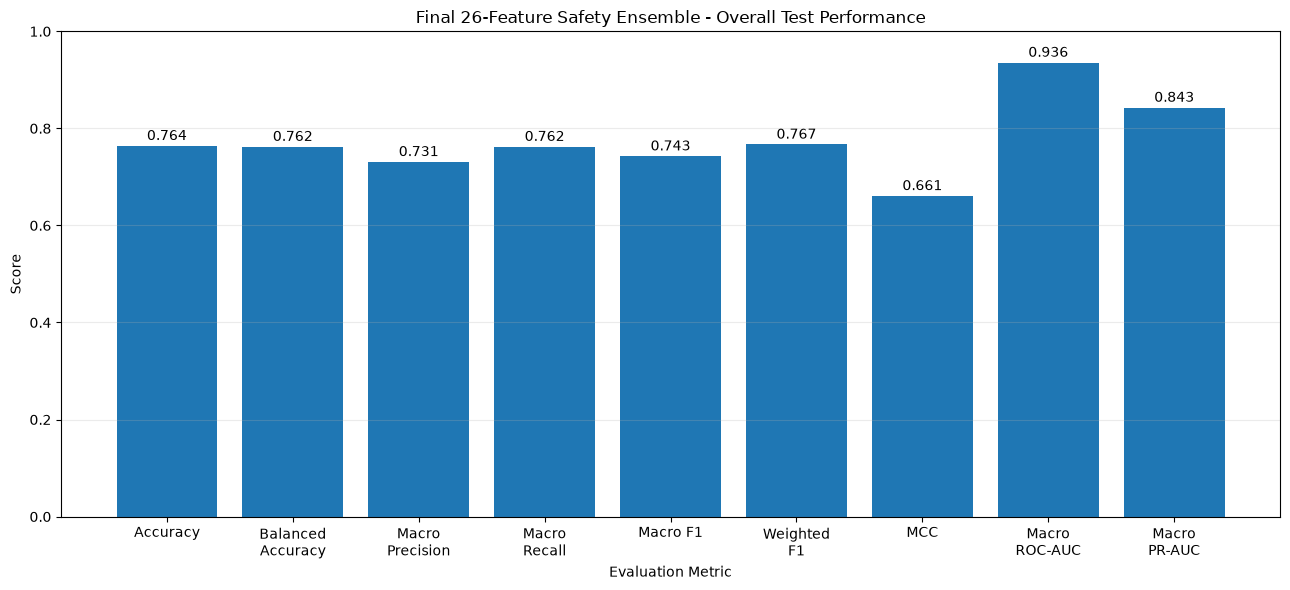

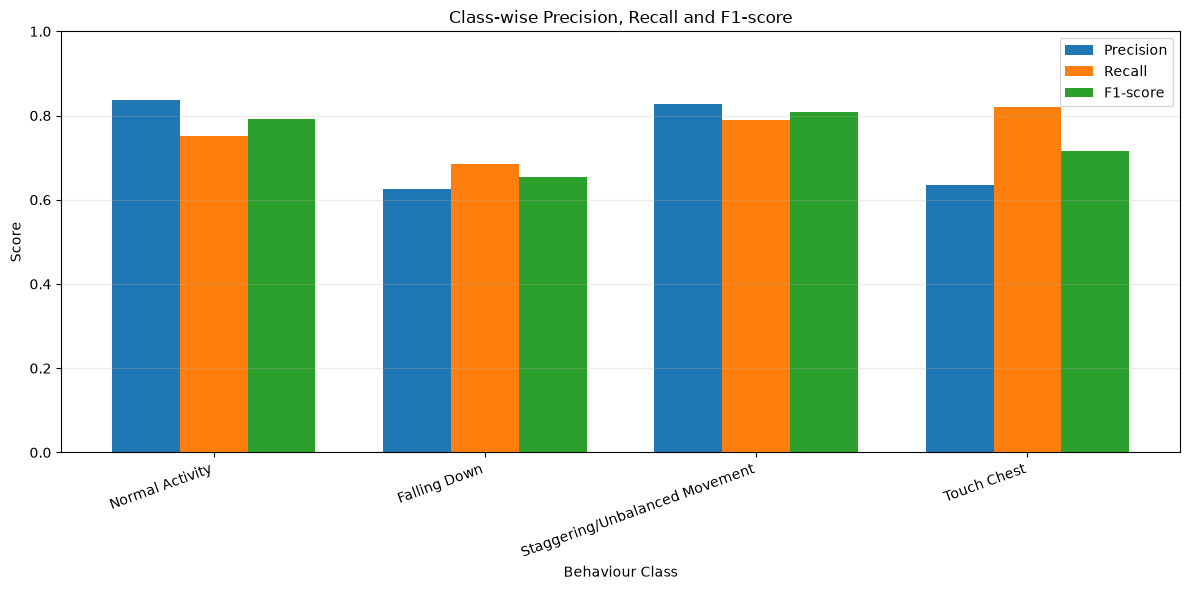

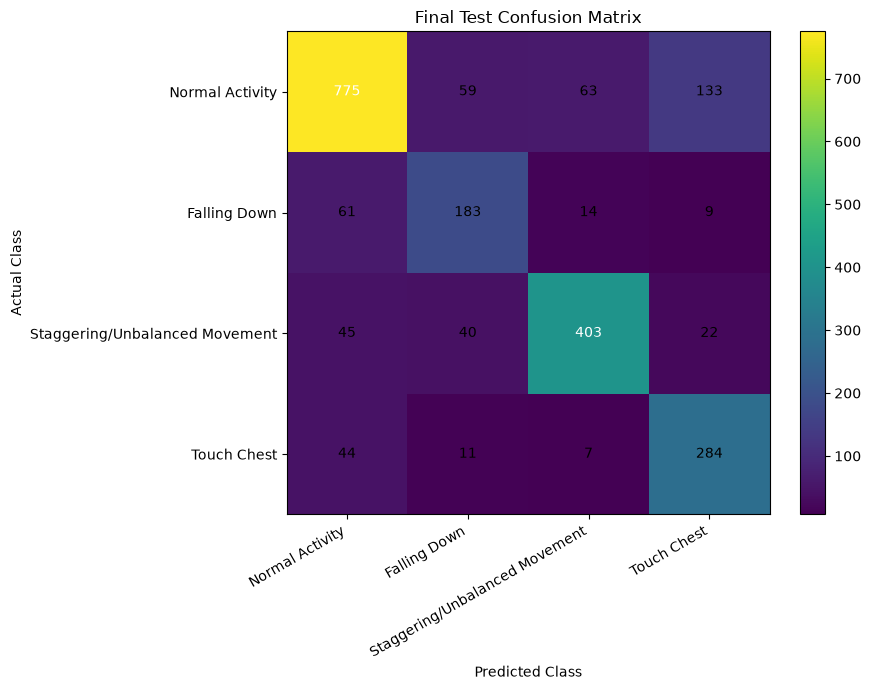

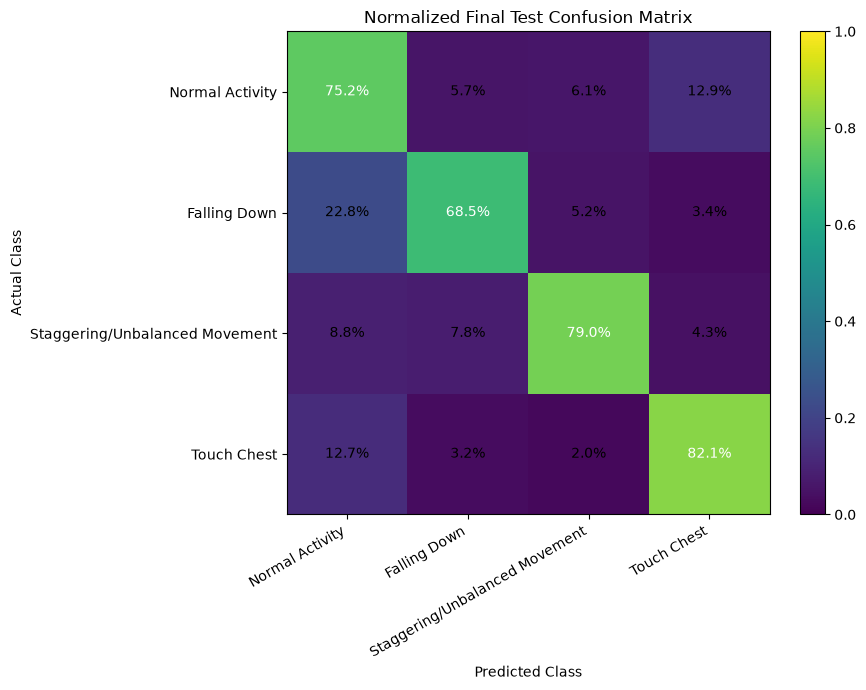

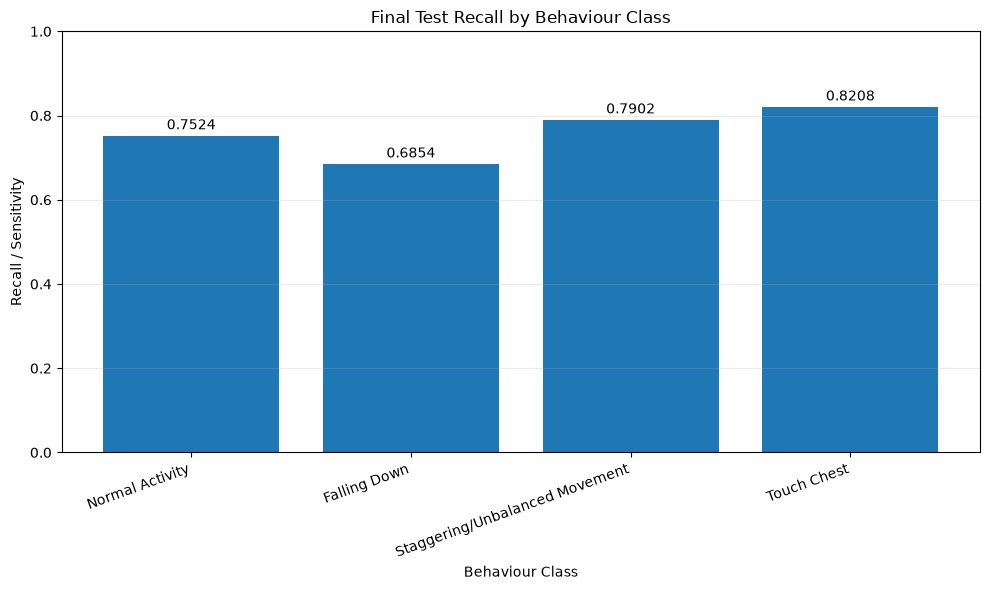

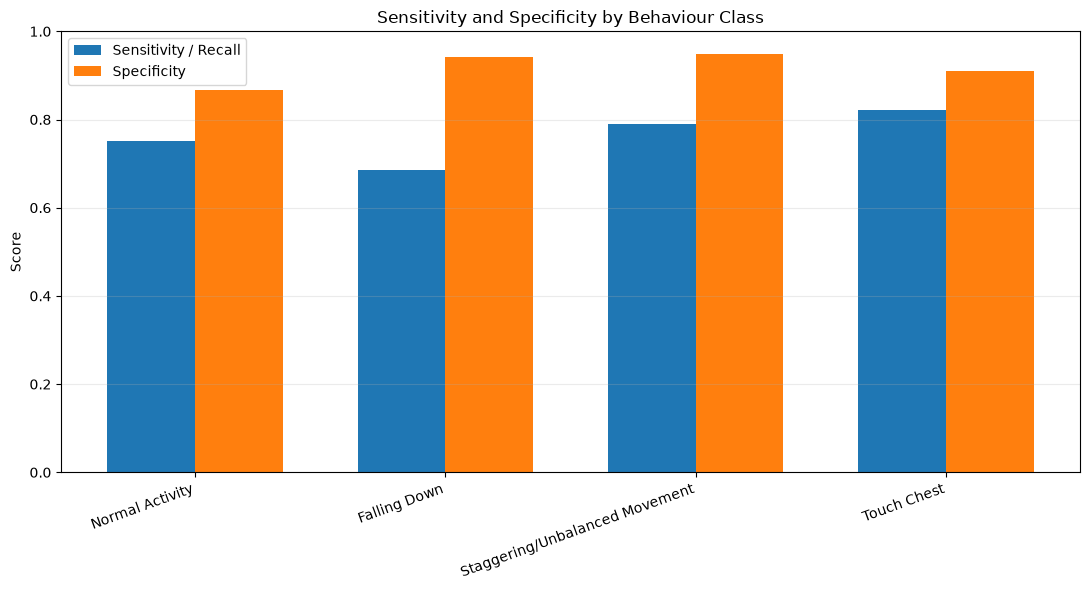

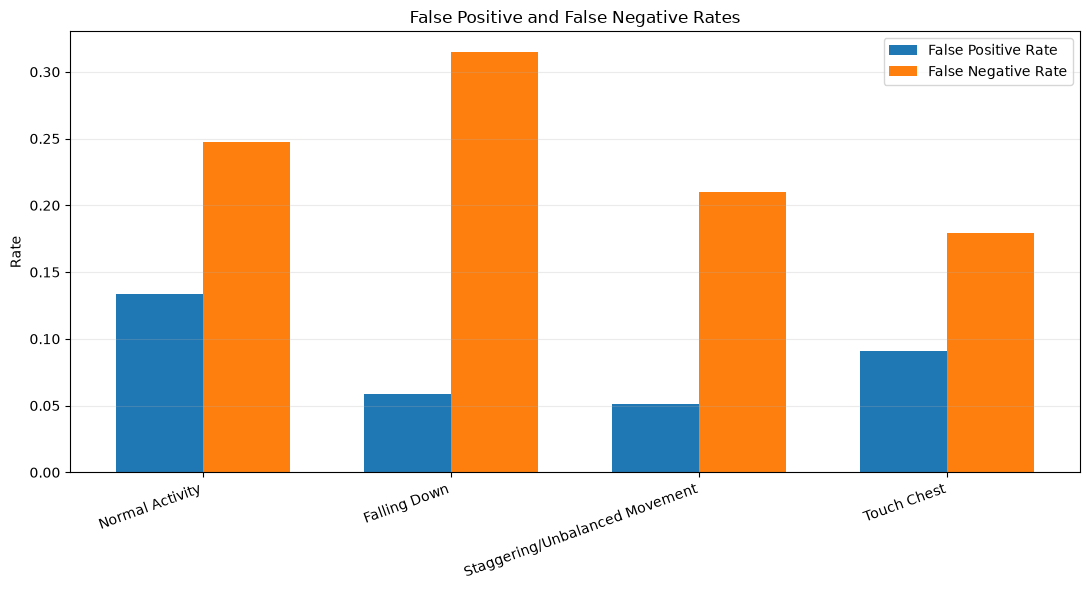

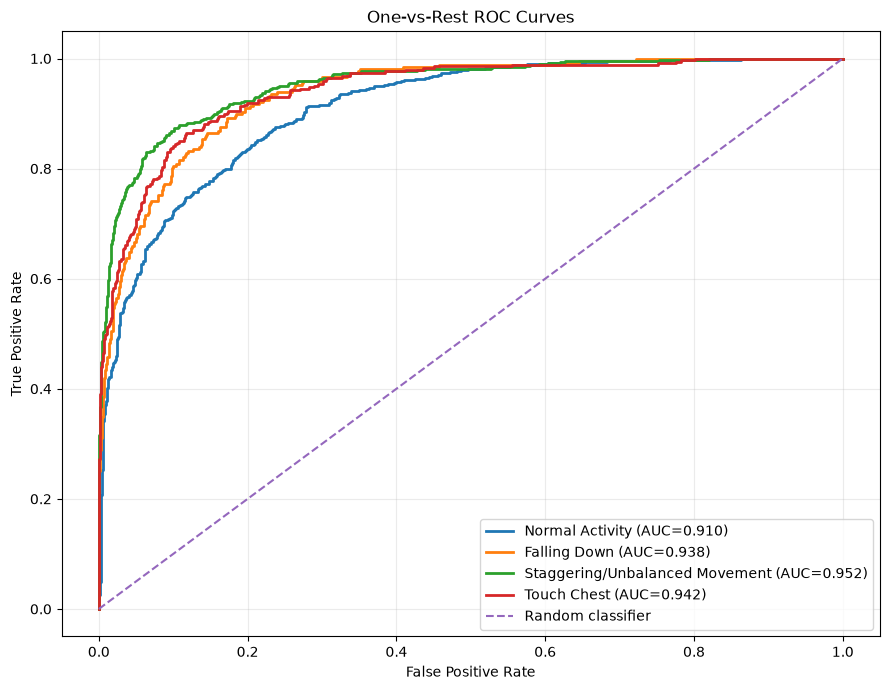

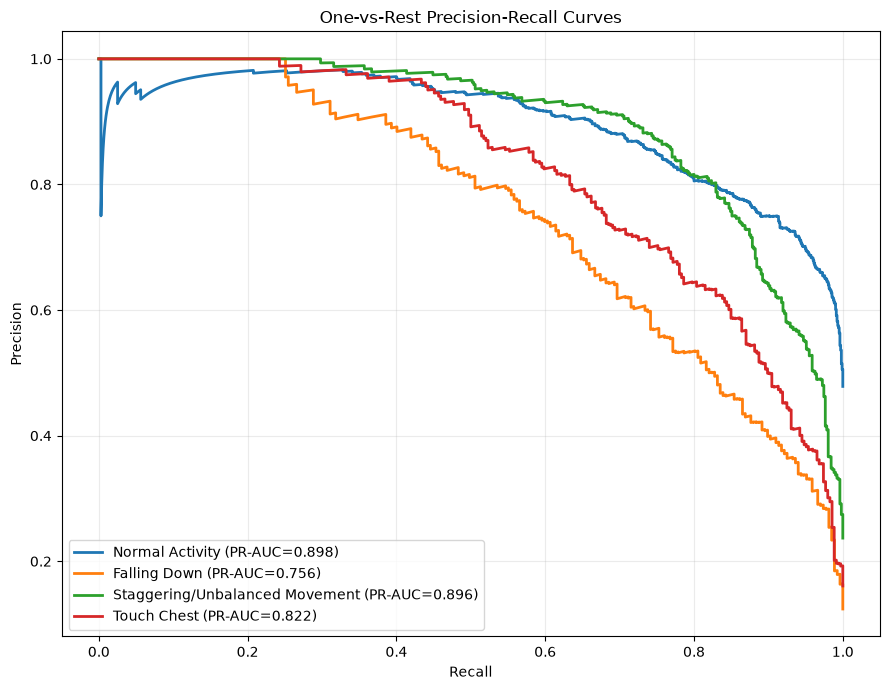

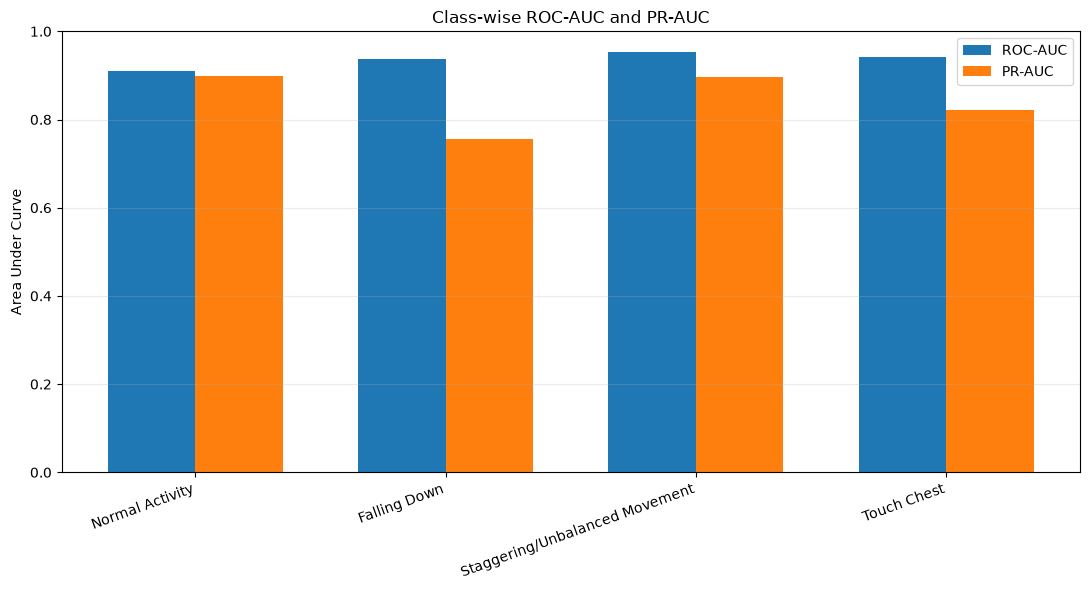

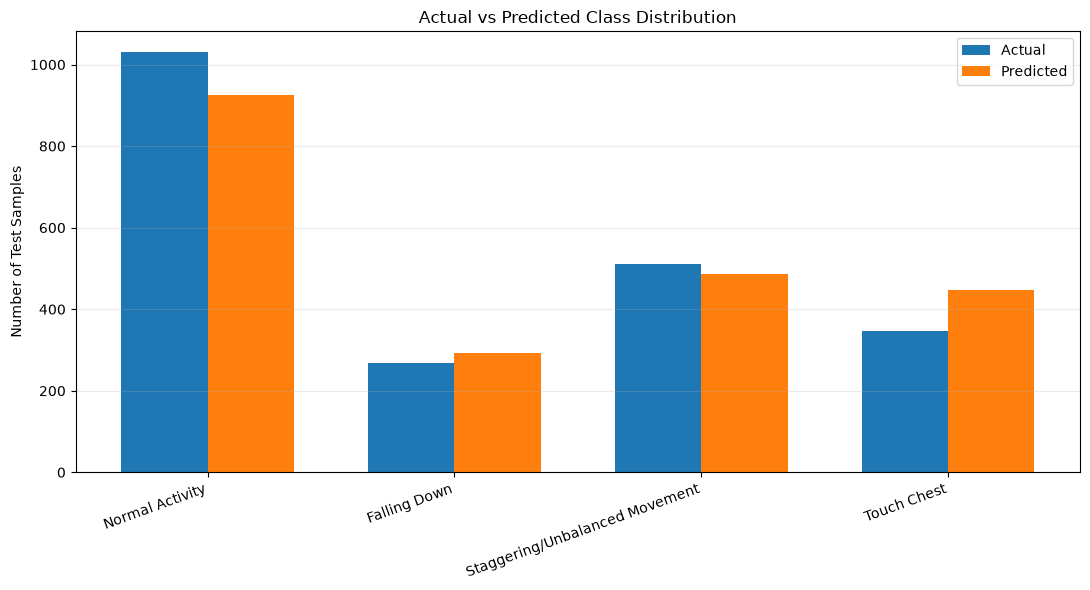

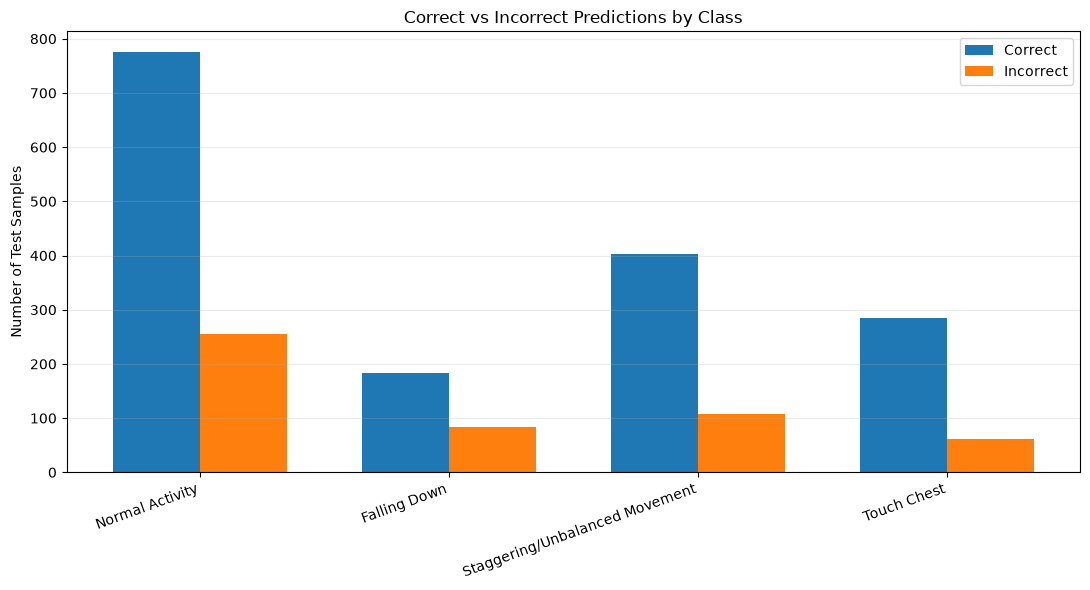

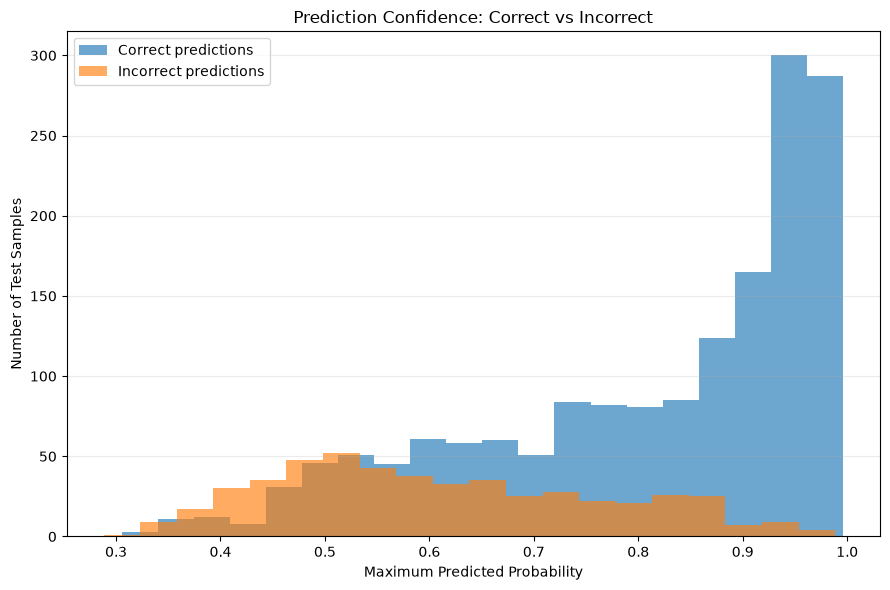

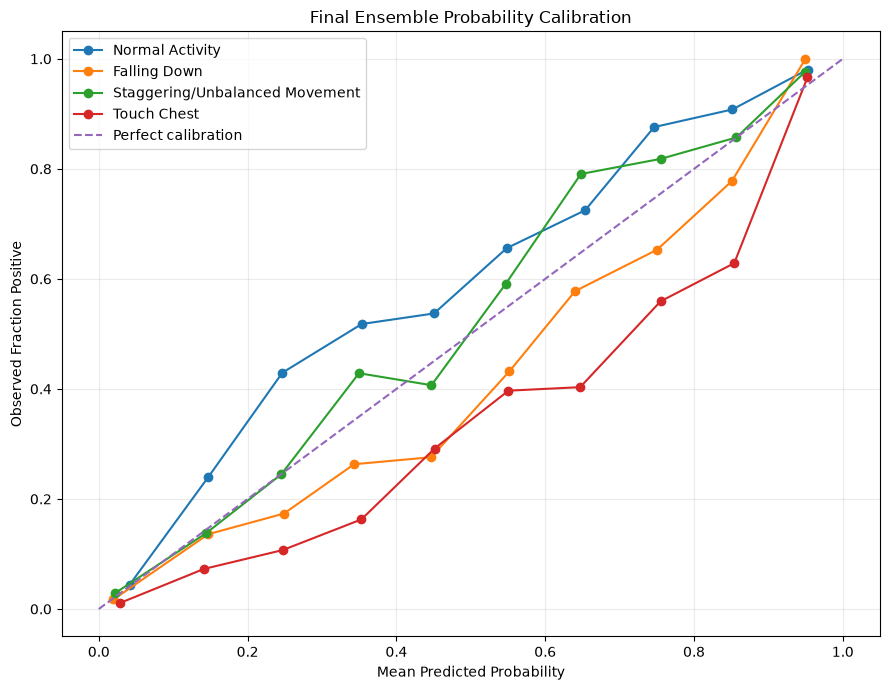

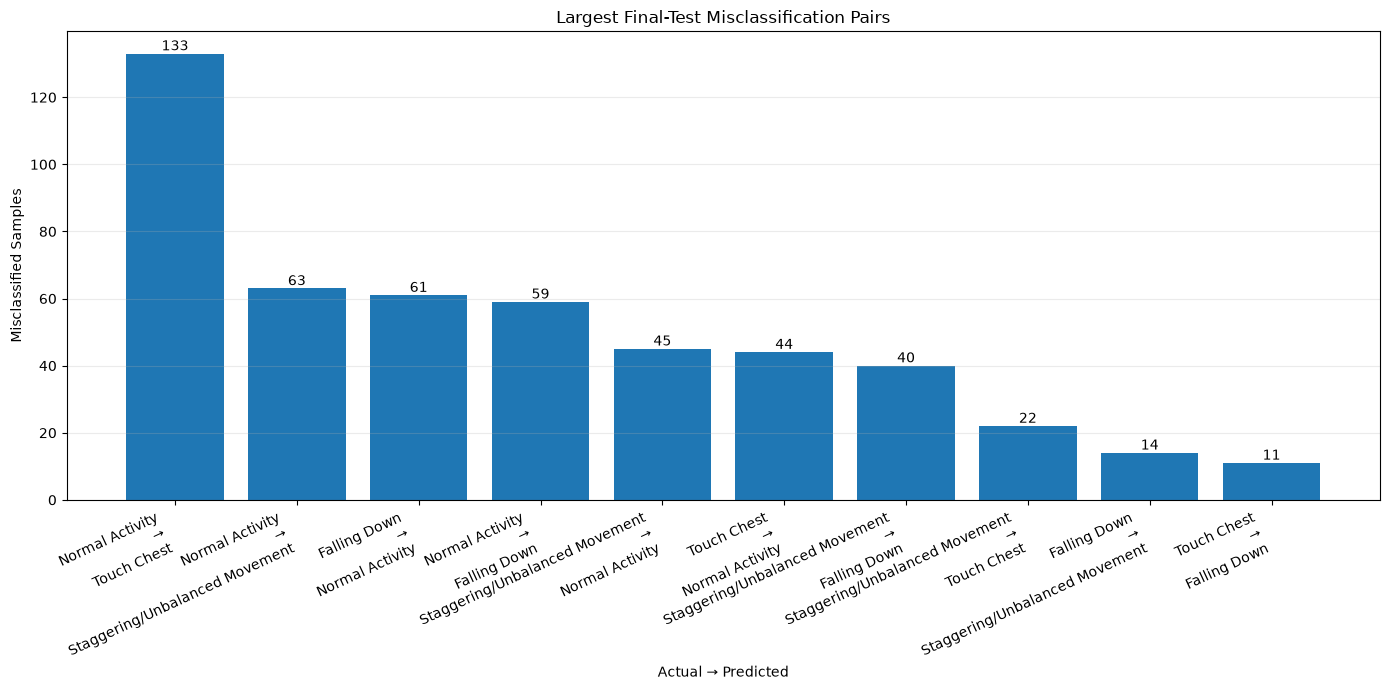



SAVED METADATA VERIFICATION

Previously stored test metrics:
{
  "accuracy": 0.7641,
  "balanced_accuracy": 0.7622,
  "macro_precision": 0.731,
  "macro_recall": 0.7622,
  "macro_f1": 0.7426,
  "weighted_f1": 0.7668,
  "mcc": 0.6608,
  "log_loss": 0.5676,
  "macro_roc_auc": 0.936,
  "normal_precision": 0.8378,
  "normal_recall": 0.7524,
  "normal_f1": 0.7928,
  "falling_precision": 0.6246,
  "falling_recall": 0.6854,
  "falling_f1": 0.6536,
  "staggering_precision": 0.8275,
  "staggering_recall": 0.7902,
  "staggering_f1": 0.8084,
  "touch_chest_precision": 0.6339,
  "touch_chest_recall": 0.8208,
  "touch_chest_f1": 0.7154
}

Previously stored confusion matrix information:
{
  "class_order": [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest"
  ],
  "matrix": [
    [
      775,
      59,
      63,
      133
    ],
    [
      61,
      183,
      14,
      9
    ],
    [
      45,
      40,
      403,
      22
    ],
    [
      44,
  

In [39]:
# ============================================================
# COMPLETE EVALUATION OF ONLY:
# final_26feature_safety_ensemble.joblib
#
# No retraining
# No tuning
# No two-stage XGBoost
# No separate XGBoost/SVM evaluation
# No hardcoded evaluation results
# ============================================================

from pathlib import Path
import joblib
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve


warnings.filterwarnings("ignore")


# ============================================================
# 1. FILE PATHS
# ============================================================

MODEL_PATH = Path(
    "models/final_26feature_safety_ensemble.joblib"
)

METADATA_PATH = Path(
    "models/final_26feature_safety_ensemble_metadata.json"
)

TEST_PATH = Path(
    "test_features_v2.csv"
)


print("=" * 100)
print("FINAL 26-FEATURE SAFETY ENSEMBLE")
print("COMPLETE HELD-OUT TEST EVALUATION")
print("=" * 100)


print("\nModel exists:", MODEL_PATH.exists())
print("Metadata exists:", METADATA_PATH.exists())
print("Test dataset exists:", TEST_PATH.exists())


if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)

if not TEST_PATH.exists():
    raise FileNotFoundError(TEST_PATH)


# ============================================================
# 2. LOAD ONLY THE FINAL SAVED ENSEMBLE
# ============================================================

bundle = joblib.load(
    MODEL_PATH
)


metadata = {}

if METADATA_PATH.exists():

    with open(
        METADATA_PATH,
        "r",
        encoding="utf-8"
    ) as f:

        metadata = json.load(f)


print("\nFinal safety ensemble loaded successfully.")


# ============================================================
# 3. READ CONFIGURATION FROM THE SAVED MODEL
# ============================================================

xgb_model = bundle[
    "xgboost_model"
]

svm_model = bundle[
    "svm_model"
]

feature_columns = list(
    bundle[
        "feature_columns"
    ]
)

class_order = list(
    bundle[
        "class_order"
    ]
)

xgb_label_encoder = bundle[
    "xgboost_label_encoder"
]

ensemble_weights = bundle[
    "ensemble_weights"
]

safety_multipliers = bundle[
    "safety_decision_multipliers"
]


print("\nFeature count:", len(feature_columns))

print("\nFinal class order:")

for i, class_name in enumerate(
    class_order
):

    print(
        f"{i}: {class_name}"
    )


print("\nSaved ensemble weights:")
print(ensemble_weights)

print("\nSaved safety decision multipliers:")
print(safety_multipliers)


# ============================================================
# 4. LOAD HELD-OUT TEST DATA
# ============================================================

test_df = pd.read_csv(
    TEST_PATH
)


if "label" not in test_df.columns:

    raise ValueError(
        "Column 'label' was not found."
    )


missing_features = [

    feature

    for feature
    in feature_columns

    if feature not in test_df.columns
]


if missing_features:

    raise ValueError(
        f"Missing features: {missing_features}"
    )


X_test = test_df[
    feature_columns
].copy()


y_test = (
    test_df[
        "label"
    ]
    .astype(str)
    .to_numpy()
)


print("\n")
print("=" * 100)
print("TEST SET")
print("=" * 100)


print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


print("\nTest class distribution:")

print(
    test_df[
        "label"
    ]
    .value_counts()
    .reindex(
        class_order
    )
)


# ============================================================
# 5. GET PROBABILITIES FROM SAVED COMPONENTS
#    OF THIS FINAL ENSEMBLE
# ============================================================

xgb_prob_raw = (
    xgb_model.predict_proba(
        X_test
    )
)


svm_prob_raw = (
    svm_model.predict_proba(
        X_test
    )
)


# ============================================================
# 6. ALIGN XGBOOST CLASS ORDER
#
# XGBoost uses numeric labels:
# 0, 1, 2, 3
#
# The saved LabelEncoder converts them
# back to real behaviour names.
# ============================================================

xgb_numeric_classes = np.asarray(
    xgb_model.classes_,
    dtype=int
)


xgb_semantic_classes = list(
    xgb_label_encoder.inverse_transform(
        xgb_numeric_classes
    )
)


svm_semantic_classes = [

    str(value)

    for value
    in svm_model.classes_
]


print("\nXGBoost probability order:")
print(xgb_semantic_classes)


print("\nSVM probability order:")
print(svm_semantic_classes)


print("\nFinal required order:")
print(class_order)


xgb_indices = [

    xgb_semantic_classes.index(
        class_name
    )

    for class_name
    in class_order
]


svm_indices = [

    svm_semantic_classes.index(
        class_name
    )

    for class_name
    in class_order
]


xgb_prob = (
    xgb_prob_raw[
        :,
        xgb_indices
    ]
)


svm_prob = (
    svm_prob_raw[
        :,
        svm_indices
    ]
)


print("\nProbability alignment passed.")


# ============================================================
# 7. READ SAVED ENSEMBLE WEIGHTS
# ============================================================

if isinstance(
    ensemble_weights,
    dict
):

    xgb_weight = None
    svm_weight = None


    for key, value in (
        ensemble_weights.items()
    ):

        key_lower = str(
            key
        ).lower()


        if "xgb" in key_lower:

            xgb_weight = float(
                value
            )


        if (
            "svm" in key_lower
            or
            "svc" in key_lower
        ):

            svm_weight = float(
                value
            )


elif isinstance(
    ensemble_weights,
    (
        list,
        tuple,
        np.ndarray
    )
):

    xgb_weight = float(
        ensemble_weights[0]
    )

    svm_weight = float(
        ensemble_weights[1]
    )


else:

    raise TypeError(
        "Unknown ensemble_weights format."
    )


if (
    xgb_weight is None
    or
    svm_weight is None
):

    raise RuntimeError(
        "Could not read ensemble weights."
    )


print("\nXGBoost weight:", xgb_weight)
print("RBF-SVM weight:", svm_weight)


# ============================================================
# 8. CREATE FINAL SAVED ENSEMBLE PROBABILITY
# ============================================================

final_probabilities = (

    xgb_weight
    *
    xgb_prob

    +

    svm_weight
    *
    svm_prob
)


# ============================================================
# 9. APPLY THE SAVED SAFETY DECISION MULTIPLIERS
# ============================================================

if isinstance(
    safety_multipliers,
    dict
):

    multiplier_vector = np.array(
        [
            float(
                safety_multipliers[
                    class_name
                ]
            )

            for class_name
            in class_order
        ]
    )


else:

    multiplier_vector = np.asarray(
        safety_multipliers,
        dtype=float
    )


print("\nSafety multiplier vector:")
print(multiplier_vector)


final_probabilities = (

    final_probabilities

    *

    multiplier_vector
)


# Normalize again so rows sum to 1

final_probabilities = (

    final_probabilities

    /

    final_probabilities.sum(
        axis=1,
        keepdims=True
    )
)


# ============================================================
# 10. FINAL MODEL PREDICTIONS
# ============================================================

prediction_indices = np.argmax(
    final_probabilities,
    axis=1
)


y_pred = np.array(
    [
        class_order[
            index
        ]

        for index
        in prediction_indices
    ]
)


print("\n")
print("=" * 100)
print("FINAL ENSEMBLE PREDICTIONS GENERATED")
print("=" * 100)


print(
    "Number of predictions:",
    len(y_pred)
)

print(
    "Probability matrix:",
    final_probabilities.shape
)


# ============================================================
# 11. BASIC OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)


macro_precision = precision_score(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)


macro_recall = recall_score(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)


macro_f1 = f1_score(
    y_test,
    y_pred,
    labels=class_order,
    average="macro",
    zero_division=0
)


weighted_precision = precision_score(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)


weighted_recall = recall_score(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)


weighted_f1 = f1_score(
    y_test,
    y_pred,
    labels=class_order,
    average="weighted",
    zero_division=0
)


micro_f1 = f1_score(
    y_test,
    y_pred,
    labels=class_order,
    average="micro",
    zero_division=0
)


mcc = matthews_corrcoef(
    y_test,
    y_pred
)


cohen_kappa = cohen_kappa_score(
    y_test,
    y_pred
)


model_log_loss = log_loss(
    y_test,
    final_probabilities,
    labels=class_order
)


# ============================================================
# 12. ONE-HOT LABELS FOR ROC / PR
# ============================================================

y_test_binary = label_binarize(
    y_test,
    classes=class_order
)


# ============================================================
# 13. ROC-AUC
# ============================================================

macro_roc_auc = roc_auc_score(
    y_test_binary,
    final_probabilities,
    average="macro"
)


weighted_roc_auc = roc_auc_score(
    y_test_binary,
    final_probabilities,
    average="weighted"
)


# ============================================================
# 14. PRECISION-RECALL AUC
# ============================================================

macro_pr_auc = average_precision_score(
    y_test_binary,
    final_probabilities,
    average="macro"
)


weighted_pr_auc = average_precision_score(
    y_test_binary,
    final_probabilities,
    average="weighted"
)


# ============================================================
# 15. BRIER SCORE
# ============================================================

brier_score = np.mean(
    np.sum(
        (
            y_test_binary
            -
            final_probabilities
        )
        ** 2,
        axis=1
    )
)


# ============================================================
# 16. OVERALL METRICS TABLE
# ============================================================

overall_metrics = pd.DataFrame(
    {
        "Metric": [

            "Accuracy",

            "Balanced Accuracy",

            "Macro Precision",

            "Macro Recall",

            "Macro F1",

            "Weighted Precision",

            "Weighted Recall",

            "Weighted F1",

            "Micro F1",

            "MCC",

            "Cohen's Kappa",

            "Log Loss",

            "Macro ROC-AUC",

            "Weighted ROC-AUC",

            "Macro PR-AUC",

            "Weighted PR-AUC",

            "Multiclass Brier Score"
        ],

        "Value": [

            accuracy,

            balanced_accuracy,

            macro_precision,

            macro_recall,

            macro_f1,

            weighted_precision,

            weighted_recall,

            weighted_f1,

            micro_f1,

            mcc,

            cohen_kappa,

            model_log_loss,

            macro_roc_auc,

            weighted_roc_auc,

            macro_pr_auc,

            weighted_pr_auc,

            brier_score
        ]
    }
)


print("\n")
print("=" * 100)
print("COMPLETE OVERALL TEST METRICS")
print("=" * 100)


print(
    overall_metrics
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 17. FULL CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 100)
print("FULL CLASSIFICATION REPORT")
print("=" * 100)


print(
    classification_report(
        y_test,
        y_pred,
        labels=class_order,
        target_names=class_order,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=class_order
)


cm_normalized = (

    cm.astype(float)

    /

    cm.sum(
        axis=1,
        keepdims=True
    )
)


print("\n")
print("=" * 100)
print("RAW CONFUSION MATRIX")
print("=" * 100)


print(cm)


print(
    "\nTotal samples:",
    cm.sum()
)


print(
    "Correct predictions:",
    np.trace(cm)
)


print(
    "Incorrect predictions:",
    cm.sum()
    -
    np.trace(cm)
)


# ============================================================
# 19. COMPLETE PER-CLASS STATISTICS
# ============================================================

class_rows = []


for i, class_name in enumerate(
    class_order
):

    TP = int(
        cm[i, i]
    )


    FN = int(
        cm[i, :].sum()
        -
        TP
    )


    FP = int(
        cm[:, i].sum()
        -
        TP
    )


    TN = int(
        cm.sum()
        -
        TP
        -
        FN
        -
        FP
    )


    precision_value = (

        TP
        /
        (
            TP + FP
        )

        if
        (
            TP + FP
        ) > 0

        else
        0
    )


    recall_value = (

        TP
        /
        (
            TP + FN
        )

        if
        (
            TP + FN
        ) > 0

        else
        0
    )


    specificity = (

        TN
        /
        (
            TN + FP
        )

        if
        (
            TN + FP
        ) > 0

        else
        0
    )


    npv = (

        TN
        /
        (
            TN + FN
        )

        if
        (
            TN + FN
        ) > 0

        else
        0
    )


    fpr = (
        1
        -
        specificity
    )


    fnr = (
        1
        -
        recall_value
    )


    f1_value = (

        2
        *
        precision_value
        *
        recall_value

        /

        (
            precision_value
            +
            recall_value
        )

        if
        (
            precision_value
            +
            recall_value
        ) > 0

        else
        0
    )


    class_roc_auc = roc_auc_score(
        y_test_binary[:, i],
        final_probabilities[:, i]
    )


    class_pr_auc = average_precision_score(
        y_test_binary[:, i],
        final_probabilities[:, i]
    )


    class_rows.append(
        {
            "Class":
                class_name,

            "TP":
                TP,

            "TN":
                TN,

            "FP":
                FP,

            "FN":
                FN,

            "Precision":
                precision_value,

            "Recall / Sensitivity":
                recall_value,

            "Specificity":
                specificity,

            "F1-score":
                f1_value,

            "NPV":
                npv,

            "FPR":
                fpr,

            "FNR":
                fnr,

            "ROC-AUC":
                class_roc_auc,

            "PR-AUC":
                class_pr_auc,

            "Support":
                int(
                    cm[i, :].sum()
                ),

            "Predicted Count":
                int(
                    cm[:, i].sum()
                )
        }
    )


class_report = pd.DataFrame(
    class_rows
)


pd.set_option(
    "display.max_columns",
    None
)


print("\n")
print("=" * 135)
print("DETAILED CLASS-WISE PERFORMANCE")
print("=" * 135)


print(
    class_report
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 20. MISCLASSIFICATION ANALYSIS
# ============================================================

confusion_rows = []


for actual_index, actual_class in enumerate(
    class_order
):

    for predicted_index, predicted_class in enumerate(
        class_order
    ):

        if actual_index == predicted_index:

            continue


        count = int(
            cm[
                actual_index,
                predicted_index
            ]
        )


        total_actual = int(
            cm[
                actual_index,
                :
            ].sum()
        )


        percentage = (

            count

            /
            total_actual

            *
            100
        )


        confusion_rows.append(
            {
                "Actual":
                    actual_class,

                "Predicted":
                    predicted_class,

                "Count":
                    count,

                "Percent of Actual":
                    percentage
            }
        )


confusion_report = (
    pd.DataFrame(
        confusion_rows
    )
    .sort_values(
        "Count",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n")
print("=" * 110)
print("RANKED MISCLASSIFICATION PAIRS")
print("=" * 110)


print(
    confusion_report
    .round(2)
    .to_string(
        index=False
    )
)


# ============================================================
# 21. CONFIDENCE ANALYSIS
# ============================================================

prediction_confidence = np.max(
    final_probabilities,
    axis=1
)


correct_mask = (
    y_pred
    ==
    y_test
)


correct_confidence = (
    prediction_confidence[
        correct_mask
    ]
)


incorrect_confidence = (
    prediction_confidence[
        ~correct_mask
    ]
)


prediction_entropy = -np.sum(
    final_probabilities
    *
    np.log(
        final_probabilities
        +
        1e-12
    ),
    axis=1
)


print("\n")
print("=" * 100)
print("CONFIDENCE ANALYSIS")
print("=" * 100)


print(
    "Mean confidence - all:",
    round(
        prediction_confidence.mean(),
        4
    )
)


print(
    "Mean confidence - correct:",
    round(
        correct_confidence.mean(),
        4
    )
)


print(
    "Mean confidence - incorrect:",
    round(
        incorrect_confidence.mean(),
        4
    )
)


print(
    "Mean entropy - all:",
    round(
        prediction_entropy.mean(),
        4
    )
)


print(
    "Mean entropy - correct:",
    round(
        prediction_entropy[
            correct_mask
        ].mean(),
        4
    )
)


print(
    "Mean entropy - incorrect:",
    round(
        prediction_entropy[
            ~correct_mask
        ].mean(),
        4
    )
)


# ============================================================
# GRAPH 1
# OVERALL PERFORMANCE
# ============================================================

metric_names = [

    "Accuracy",

    "Balanced\nAccuracy",

    "Macro\nPrecision",

    "Macro\nRecall",

    "Macro F1",

    "Weighted\nF1",

    "MCC",

    "Macro\nROC-AUC",

    "Macro\nPR-AUC"
]


metric_values = [

    accuracy,

    balanced_accuracy,

    macro_precision,

    macro_recall,

    macro_f1,

    weighted_f1,

    mcc,

    macro_roc_auc,

    macro_pr_auc
]


plt.figure(
    figsize=(13, 6)
)


bars = plt.bar(
    metric_names,
    metric_values
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Score"
)


plt.xlabel(
    "Evaluation Metric"
)


plt.title(
    "Final 26-Feature Safety Ensemble - Overall Test Performance"
)


plt.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    metric_values
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.012,

        f"{value:.3f}",

        ha="center"
    )


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 2
# PRECISION, RECALL, F1
# ============================================================

precision_values = (
    class_report[
        "Precision"
    ].to_numpy()
)


recall_values = (
    class_report[
        "Recall / Sensitivity"
    ].to_numpy()
)


f1_values = (
    class_report[
        "F1-score"
    ].to_numpy()
)


x = np.arange(
    len(class_order)
)


width = 0.25


plt.figure(
    figsize=(12, 6)
)


plt.bar(
    x - width,
    precision_values,
    width,
    label="Precision"
)


plt.bar(
    x,
    recall_values,
    width,
    label="Recall"
)


plt.bar(
    x + width,
    f1_values,
    width,
    label="F1-score"
)


plt.xticks(
    x,
    class_order,
    rotation=20,
    ha="right"
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Score"
)


plt.xlabel(
    "Behaviour Class"
)


plt.title(
    "Class-wise Precision, Recall and F1-score"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 3
# RAW CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(9, 7)
)


plt.imshow(
    cm,
    interpolation="nearest"
)


plt.colorbar()


plt.title(
    "Final Test Confusion Matrix"
)


positions = np.arange(
    len(class_order)
)


plt.xticks(
    positions,
    class_order,
    rotation=30,
    ha="right"
)


plt.yticks(
    positions,
    class_order
)


threshold = (
    cm.max()
    /
    2
)


for row in range(
    cm.shape[0]
):

    for column in range(
        cm.shape[1]
    ):

        value = cm[
            row,
            column
        ]


        plt.text(
            column,
            row,
            str(value),
            ha="center",
            va="center",
            color=(
                "white"
                if value > threshold
                else "black"
            )
        )


plt.xlabel(
    "Predicted Class"
)


plt.ylabel(
    "Actual Class"
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 4
# NORMALIZED CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(9, 7)
)


plt.imshow(
    cm_normalized,
    interpolation="nearest",
    vmin=0,
    vmax=1
)


plt.colorbar()


plt.title(
    "Normalized Final Test Confusion Matrix"
)


plt.xticks(
    positions,
    class_order,
    rotation=30,
    ha="right"
)


plt.yticks(
    positions,
    class_order
)


for row in range(
    cm_normalized.shape[0]
):

    for column in range(
        cm_normalized.shape[1]
    ):

        value = (
            cm_normalized[
                row,
                column
            ]
        )


        plt.text(
            column,
            row,
            f"{value:.1%}",
            ha="center",
            va="center",
            color=(
                "white"
                if value > 0.5
                else "black"
            )
        )


plt.xlabel(
    "Predicted Class"
)


plt.ylabel(
    "Actual Class"
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 5
# RECALL
# ============================================================

plt.figure(
    figsize=(10, 6)
)


bars = plt.bar(
    class_order,
    recall_values
)


plt.ylim(
    0,
    1
)


plt.xticks(
    rotation=20,
    ha="right"
)


plt.ylabel(
    "Recall / Sensitivity"
)


plt.xlabel(
    "Behaviour Class"
)


plt.title(
    "Final Test Recall by Behaviour Class"
)


plt.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    recall_values
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.015,

        f"{value:.4f}",

        ha="center"
    )


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 6
# SENSITIVITY VS SPECIFICITY
# ============================================================

specificity_values = (
    class_report[
        "Specificity"
    ].to_numpy()
)


width = 0.35


plt.figure(
    figsize=(11, 6)
)


plt.bar(
    x - width / 2,
    recall_values,
    width,
    label="Sensitivity / Recall"
)


plt.bar(
    x + width / 2,
    specificity_values,
    width,
    label="Specificity"
)


plt.xticks(
    x,
    class_order,
    rotation=20,
    ha="right"
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Score"
)


plt.title(
    "Sensitivity and Specificity by Behaviour Class"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 7
# FALSE POSITIVE VS FALSE NEGATIVE RATE
# ============================================================

fpr_values = (
    class_report[
        "FPR"
    ].to_numpy()
)


fnr_values = (
    class_report[
        "FNR"
    ].to_numpy()
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(
    x - width / 2,
    fpr_values,
    width,
    label="False Positive Rate"
)


plt.bar(
    x + width / 2,
    fnr_values,
    width,
    label="False Negative Rate"
)


plt.xticks(
    x,
    class_order,
    rotation=20,
    ha="right"
)


plt.ylabel(
    "Rate"
)


plt.title(
    "False Positive and False Negative Rates"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 8
# ROC CURVES
# ============================================================

plt.figure(
    figsize=(9, 7)
)


roc_auc_values = []


for i, class_name in enumerate(
    class_order
):

    fpr_curve, tpr_curve, _ = roc_curve(
        y_test_binary[:, i],
        final_probabilities[:, i]
    )


    auc_value = roc_auc_score(
        y_test_binary[:, i],
        final_probabilities[:, i]
    )


    roc_auc_values.append(
        auc_value
    )


    plt.plot(
        fpr_curve,
        tpr_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)


plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "One-vs-Rest ROC Curves"
)


plt.legend(
    loc="lower right"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 9
# PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(9, 7)
)


pr_auc_values = []


for i, class_name in enumerate(
    class_order
):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test_binary[:, i],
            final_probabilities[:, i]
        )
    )


    ap_value = average_precision_score(
        y_test_binary[:, i],
        final_probabilities[:, i]
    )


    pr_auc_values.append(
        ap_value
    )


    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(PR-AUC={ap_value:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)


plt.ylabel(
    "Precision"
)


plt.title(
    "One-vs-Rest Precision-Recall Curves"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 10
# ROC-AUC VS PR-AUC
# ============================================================

roc_auc_values = np.array(
    roc_auc_values
)


pr_auc_values = np.array(
    pr_auc_values
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(
    x - width / 2,
    roc_auc_values,
    width,
    label="ROC-AUC"
)


plt.bar(
    x + width / 2,
    pr_auc_values,
    width,
    label="PR-AUC"
)


plt.xticks(
    x,
    class_order,
    rotation=20,
    ha="right"
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Area Under Curve"
)


plt.title(
    "Class-wise ROC-AUC and PR-AUC"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 11
# ACTUAL VS PREDICTED CLASS DISTRIBUTION
# ============================================================

actual_counts = cm.sum(
    axis=1
)


predicted_counts = cm.sum(
    axis=0
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(
    x - width / 2,
    actual_counts,
    width,
    label="Actual"
)


plt.bar(
    x + width / 2,
    predicted_counts,
    width,
    label="Predicted"
)


plt.xticks(
    x,
    class_order,
    rotation=20,
    ha="right"
)


plt.ylabel(
    "Number of Test Samples"
)


plt.title(
    "Actual vs Predicted Class Distribution"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 12
# CORRECT VS INCORRECT BY CLASS
# ============================================================

correct_by_class = np.diag(
    cm
)


incorrect_by_class = (
    actual_counts
    -
    correct_by_class
)


plt.figure(
    figsize=(11, 6)
)


plt.bar(
    x - width / 2,
    correct_by_class,
    width,
    label="Correct"
)


plt.bar(
    x + width / 2,
    incorrect_by_class,
    width,
    label="Incorrect"
)


plt.xticks(
    x,
    class_order,
    rotation=20,
    ha="right"
)


plt.ylabel(
    "Number of Test Samples"
)


plt.title(
    "Correct vs Incorrect Predictions by Class"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 13
# CONFIDENCE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.65,
    label="Correct predictions"
)


plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.65,
    label="Incorrect predictions"
)


plt.xlabel(
    "Maximum Predicted Probability"
)


plt.ylabel(
    "Number of Test Samples"
)


plt.title(
    "Prediction Confidence: Correct vs Incorrect"
)


plt.legend()


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 14
# CALIBRATION CURVES
# ============================================================

plt.figure(
    figsize=(9, 7)
)


for i, class_name in enumerate(
    class_order
):

    fraction_positive, mean_predicted = (
        calibration_curve(
            y_test_binary[:, i],
            final_probabilities[:, i],
            n_bins=10,
            strategy="uniform"
        )
    )


    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        label=class_name
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)


plt.xlabel(
    "Mean Predicted Probability"
)


plt.ylabel(
    "Observed Fraction Positive"
)


plt.title(
    "Final Ensemble Probability Calibration"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()
plt.show()


# ============================================================
# GRAPH 15
# TOP MISCLASSIFICATION PAIRS
# ============================================================

top_errors = (
    confusion_report
    .head(10)
    .copy()
)


top_errors[
    "Pair"
] = (

    top_errors[
        "Actual"
    ]

    +

    "\n→\n"

    +

    top_errors[
        "Predicted"
    ]
)


plt.figure(
    figsize=(14, 7)
)


bars = plt.bar(
    top_errors[
        "Pair"
    ],
    top_errors[
        "Count"
    ]
)


plt.ylabel(
    "Misclassified Samples"
)


plt.xlabel(
    "Actual → Predicted"
)


plt.title(
    "Largest Final-Test Misclassification Pairs"
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    top_errors[
        "Count"
    ]
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        value + 1,

        str(
            int(value)
        ),

        ha="center"
    )


plt.tight_layout()
plt.show()


# ============================================================
# 22. OPTIONAL VERIFICATION AGAINST SAVED METADATA
#
# This does NOT generate results from metadata.
# It only compares our freshly calculated result
# to what was previously stored.
# ============================================================

if metadata:

    print("\n")
    print("=" * 100)
    print("SAVED METADATA VERIFICATION")
    print("=" * 100)


    if "test_metrics" in metadata:

        print(
            "\nPreviously stored test metrics:"
        )


        print(
            json.dumps(
                metadata[
                    "test_metrics"
                ],
                indent=2
            )
        )


    if "test_confusion_matrix" in metadata:

        print(
            "\nPreviously stored confusion matrix information:"
        )


        print(
            json.dumps(
                metadata[
                    "test_confusion_matrix"
                ],
                indent=2
            )
        )


# ============================================================
# 23. FINAL REPORT-READY TABLE
# ============================================================

print("\n")
print("=" * 135)
print("FINAL REPORT-READY CLASS PERFORMANCE TABLE")
print("=" * 135)


report_table = class_report[
    [
        "Class",
        "Precision",
        "Recall / Sensitivity",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "PR-AUC",
        "FPR",
        "FNR",
        "Support"
    ]
]


print(
    report_table
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 100)
print("FINAL EVALUATION SUMMARY")
print("=" * 100)


print(
    "Evaluated model:"
)

print(
    MODEL_PATH
)


print(
    "\nTest samples:",
    len(y_test)
)


print(
    "Correct:",
    int(
        np.sum(
            correct_mask
        )
    )
)


print(
    "Incorrect:",
    int(
        np.sum(
            ~correct_mask
        )
    )
)


print(
    f"\nAccuracy:          {accuracy:.4f}"
)

print(
    f"Balanced Accuracy: {balanced_accuracy:.4f}"
)

print(
    f"Macro Precision:   {macro_precision:.4f}"
)

print(
    f"Macro Recall:      {macro_recall:.4f}"
)

print(
    f"Macro F1:          {macro_f1:.4f}"
)

print(
    f"Weighted F1:       {weighted_f1:.4f}"
)

print(
    f"MCC:               {mcc:.4f}"
)

print(
    f"Cohen's Kappa:     {cohen_kappa:.4f}"
)

print(
    f"Log Loss:          {model_log_loss:.4f}"
)

print(
    f"Macro ROC-AUC:     {macro_roc_auc:.4f}"
)

print(
    f"Macro PR-AUC:      {macro_pr_auc:.4f}"
)

print(
    f"Brier Score:       {brier_score:.4f}"
)


print("\n")
print("=" * 100)
print("COMPLETE EVALUATION FINISHED")
print("=" * 100)


print(
    "All metrics and graphs were generated "
    "from the final saved safety ensemble."
)

print(
    "No model retraining or tuning was performed."
)

print(
    "No evaluation result was hardcoded."
)

# Demo

In [7]:
# 26 Features XGBoost weight: 0.6 RBF-SVM weight: 0.4
# Final interactive NTU skeleton prediction viewer

import tkinter as tk
from tkinter import filedialog, messagebox
from pathlib import Path
import re
import sys
import joblib
import numpy as np
import pandas as pd


# Project paths

PROJECT_FOLDER = Path.cwd()

MODELS_FOLDER = (
    PROJECT_FOLDER
    / "models"
)

MODEL_PATH = (
    MODELS_FOLDER
    / "final_26feature_safety_ensemble.joblib"
)

SHARED_FEATURES_PATH = (
    MODELS_FOLDER
    / "shared_features.py"
)


if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Final model not found:\n{MODEL_PATH}"
    )


if not SHARED_FEATURES_PATH.exists():

    raise FileNotFoundError(
        f"shared_features.py not found:\n{SHARED_FEATURES_PATH}"
    )


if str(MODELS_FOLDER) not in sys.path:

    sys.path.insert(
        0,
        str(MODELS_FOLDER)
    )


from shared_features import (
    compute_features,
    EXPECTED_WINDOW_SIZE
)


# Window settings used when creating the dataset

WINDOW_SIZE = int(
    EXPECTED_WINDOW_SIZE
)

STRIDE = 15


# Load the final saved safety ensemble

final_bundle = joblib.load(
    MODEL_PATH
)


xgb_model = final_bundle[
    "xgboost_model"
]

svm_model = final_bundle[
    "svm_model"
]

feature_columns = list(
    final_bundle[
        "feature_columns"
    ]
)

class_order = list(
    final_bundle[
        "class_order"
    ]
)

xgb_label_encoder = final_bundle[
    "xgboost_label_encoder"
]

ensemble_weights = final_bundle[
    "ensemble_weights"
]

safety_multipliers_saved = final_bundle[
    "safety_decision_multipliers"
]


# Read ensemble weights from the saved model

if isinstance(
    ensemble_weights,
    dict
):

    xgb_weight = None
    svm_weight = None

    for key, value in (
        ensemble_weights.items()
    ):

        key_lower = str(
            key
        ).lower()

        if "xgb" in key_lower:

            xgb_weight = float(
                value
            )

        if (
            "svm" in key_lower
            or
            "svc" in key_lower
        ):

            svm_weight = float(
                value
            )


elif isinstance(
    ensemble_weights,
    (
        list,
        tuple,
        np.ndarray
    )
):

    xgb_weight = float(
        ensemble_weights[0]
    )

    svm_weight = float(
        ensemble_weights[1]
    )


else:

    raise TypeError(
        "Unknown ensemble weight format."
    )


if (
    xgb_weight is None
    or
    svm_weight is None
):

    raise RuntimeError(
        "Could not read saved ensemble weights."
    )


# Read safety multipliers from the saved model

if isinstance(
    safety_multipliers_saved,
    dict
):

    safety_multiplier_vector = np.array(
        [
            float(
                safety_multipliers_saved[
                    class_name
                ]
            )

            for class_name
            in class_order
        ],
        dtype=float
    )


else:

    safety_multiplier_vector = np.asarray(
        safety_multipliers_saved,
        dtype=float
    )


if (
    len(
        safety_multiplier_vector
    )
    !=
    len(
        class_order
    )
):

    raise RuntimeError(
        "Safety multiplier count does not match class count."
    )


# Convert XGBoost numeric class IDs to behaviour names

xgb_numeric_classes = np.asarray(
    xgb_model.classes_,
    dtype=int
)


xgb_semantic_classes = list(
    xgb_label_encoder.inverse_transform(
        xgb_numeric_classes
    )
)


svm_semantic_classes = [
    str(
        value
    )

    for value
    in svm_model.classes_
]


# Align both component models to the saved final class order

xgb_reorder_indices = [
    xgb_semantic_classes.index(
        class_name
    )

    for class_name
    in class_order
]


svm_reorder_indices = [
    svm_semantic_classes.index(
        class_name
    )

    for class_name
    in class_order
]


print("Final safety ensemble loaded.")

print(
    "Feature count:",
    len(
        feature_columns
    )
)

print(
    "Window size:",
    WINDOW_SIZE
)

print(
    "Stride:",
    STRIDE
)

print(
    "Class order:",
    class_order
)

print(
    "Ensemble weights:",
    xgb_weight,
    svm_weight
)

print(
    "Safety multipliers:",
    safety_multiplier_vector
)


# NTU RGB+D 60 action names

NTU_ACTION_MAP = {
    "A001": "Drink Water",
    "A002": "Eat Meal / Snack",
    "A003": "Brushing Teeth",
    "A004": "Brushing Hair",
    "A005": "Drop",
    "A006": "Pickup",
    "A007": "Throw",
    "A008": "Sitting Down",
    "A009": "Standing Up",
    "A010": "Clapping",
    "A011": "Reading",
    "A012": "Writing",
    "A013": "Tear Up Paper",
    "A014": "Wear Jacket",
    "A015": "Take Off Jacket",
    "A016": "Wear a Shoe",
    "A017": "Take Off a Shoe",
    "A018": "Wear Glasses",
    "A019": "Take Off Glasses",
    "A020": "Put On Hat / Cap",
    "A021": "Take Off Hat / Cap",
    "A022": "Cheer Up",
    "A023": "Hand Waving",
    "A024": "Kicking Something",
    "A025": "Reach Into Pocket",
    "A026": "Hopping",
    "A027": "Jump Up",
    "A028": "Make / Answer Phone Call",
    "A029": "Playing With Phone / Tablet",
    "A030": "Typing on Keyboard",
    "A031": "Pointing With Finger",
    "A032": "Taking a Selfie",
    "A033": "Check Time From Watch",
    "A034": "Rub Two Hands Together",
    "A035": "Nod Head / Bow",
    "A036": "Shake Head",
    "A037": "Wipe Face",
    "A038": "Salute",
    "A039": "Put Palms Together",
    "A040": "Cross Hands in Front",
    "A041": "Sneeze / Cough",
    "A042": "Staggering / Unbalanced Movement",
    "A043": "Falling Down",
    "A044": "Touch Head",
    "A045": "Touch Chest",
    "A046": "Touch Back",
    "A047": "Touch Neck",
    "A048": "Nausea / Vomiting",
    "A049": "Use a Fan / Feeling Warm",
    "A050": "Punching / Slapping Other Person",
    "A051": "Kicking Other Person",
    "A052": "Pushing Other Person",
    "A053": "Pat on Back of Other Person",
    "A054": "Point Finger at Other Person",
    "A055": "Hugging Other Person",
    "A056": "Giving Something to Other Person",
    "A057": "Touch Other Person's Pocket",
    "A058": "Handshaking",
    "A059": "Walking Towards Each Other",
    "A060": "Walking Apart From Each Other"
}


# Project class mapping

PROJECT_CLASS_MAP = {
    "A001": "Normal Activity",
    "A008": "Normal Activity",
    "A009": "Normal Activity",
    "A042": "Staggering/Unbalanced Movement",
    "A043": "Falling Down",
    "A045": "Touch Chest"
}


# NTU 25-joint names

NTU_JOINT_NAMES = [
    "SpineBase",
    "SpineMid",
    "Neck",
    "Head",
    "ShoulderLeft",
    "ElbowLeft",
    "WristLeft",
    "HandLeft",
    "ShoulderRight",
    "ElbowRight",
    "WristRight",
    "HandRight",
    "HipLeft",
    "KneeLeft",
    "AnkleLeft",
    "FootLeft",
    "HipRight",
    "KneeRight",
    "AnkleRight",
    "FootRight",
    "SpineShoulder",
    "HandTipLeft",
    "ThumbLeft",
    "HandTipRight",
    "ThumbRight"
]


# Connections for the original 25-joint skeleton

RAW_CONNECTIONS = [
    (0, 1),
    (1, 20),
    (20, 2),
    (2, 3),

    (20, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (7, 21),
    (7, 22),

    (20, 8),
    (8, 9),
    (9, 10),
    (10, 11),
    (11, 23),
    (11, 24),

    (0, 12),
    (12, 13),
    (13, 14),
    (14, 15),

    (0, 16),
    (16, 17),
    (17, 18),
    (18, 19)
]


# Fourteen joints used by the trained feature pipeline

MODEL_JOINT_MAP = {
    "SpineMid": 1,
    "Neck": 2,
    "SpineShoulder": 20,
    "Head": 3,
    "WristLeft": 6,
    "WristRight": 10,
    "ShoulderLeft": 4,
    "ShoulderRight": 8,
    "ElbowLeft": 5,
    "ElbowRight": 9,
    "HipLeft": 12,
    "HipRight": 16,
    "AnkleLeft": 14,
    "AnkleRight": 18
}


MODEL_JOINT_ORDER = list(
    MODEL_JOINT_MAP.keys()
)


# Connections for the normalized 14-joint model skeleton

MODEL_CONNECTIONS = [
    ("Head", "Neck"),
    ("Neck", "SpineShoulder"),
    ("SpineShoulder", "SpineMid"),

    ("SpineShoulder", "ShoulderLeft"),
    ("ShoulderLeft", "ElbowLeft"),
    ("ElbowLeft", "WristLeft"),

    ("SpineShoulder", "ShoulderRight"),
    ("ShoulderRight", "ElbowRight"),
    ("ElbowRight", "WristRight"),

    ("SpineMid", "HipLeft"),
    ("SpineMid", "HipRight"),

    ("HipLeft", "AnkleLeft"),
    ("HipRight", "AnkleRight")
]


# Read the action code from an NTU filename

def get_action_information(
    file_path
):

    filename = Path(
        file_path
    ).stem

    match = re.search(
        r"A\d{3}",
        filename
    )

    if match is None:

        return {
            "code": "Unknown",
            "action": "Unknown",
            "project_class": "Unknown"
        }

    action_code = match.group(
        0
    )

    action_name = NTU_ACTION_MAP.get(
        action_code,
        "Unknown NTU Action"
    )

    project_class = PROJECT_CLASS_MAP.get(
        action_code,
        "Outside Selected Model Classes"
    )

    return {
        "code": action_code,
        "action": action_name,
        "project_class": project_class
    }


# Load an NTU .skeleton file

def load_ntu_skeleton(
    file_path
):

    frames = []

    with open(
        file_path,
        "r"
    ) as file:

        first_line = (
            file.readline()
            .strip()
        )

        if not first_line:

            raise ValueError(
                "Skeleton file is empty."
            )

        frame_count = int(
            first_line
        )

        for frame_index in range(
            frame_count
        ):

            body_line = (
                file.readline()
                .strip()
            )

            if not body_line:

                raise ValueError(
                    f"Missing body count at frame {frame_index}"
                )

            body_count = int(
                body_line
            )

            frame_bodies = []

            for body_index in range(
                body_count
            ):

                body_info = (
                    file.readline()
                    .strip()
                    .split()
                )

                joint_count = int(
                    file.readline()
                    .strip()
                )

                joints = []

                for joint_index in range(
                    joint_count
                ):

                    values = (
                        file.readline()
                        .strip()
                        .split()
                    )

                    if len(
                        values
                    ) < 3:

                        raise ValueError(
                            f"Invalid joint data at "
                            f"frame {frame_index}, "
                            f"joint {joint_index}"
                        )

                    tracking_state = None

                    if len(
                        values
                    ) >= 12:

                        tracking_state = int(
                            float(
                                values[11]
                            )
                        )

                    joints.append(
                        {
                            "x": float(
                                values[0]
                            ),

                            "y": float(
                                values[1]
                            ),

                            "z": float(
                                values[2]
                            ),

                            "tracking_state":
                                tracking_state
                        }
                    )

                frame_bodies.append(
                    {
                        "body_info":
                            body_info,

                        "joints":
                            joints
                    }
                )

            frames.append(
                frame_bodies
            )

    return frames


# Select the most reliable body in a frame

def choose_body(
    frame_bodies
):

    if len(
        frame_bodies
    ) == 0:

        return None

    if len(
        frame_bodies
    ) == 1:

        return frame_bodies[
            0
        ]

    best_body = None
    best_score = -1

    for body in frame_bodies:

        score = 0

        for joint in body[
            "joints"
        ]:

            state = joint[
                "tracking_state"
            ]

            if (
                state is None
                or
                state > 0
            ):

                score += 1

        if score > best_score:

            best_score = score
            best_body = body

    return best_body


# Convert one body to a 25x3 XYZ array

def body_to_xyz(
    body
):

    joints = body[
        "joints"
    ]

    if len(
        joints
    ) < 25:

        raise ValueError(
            "Expected 25 NTU joints."
        )

    return np.array(
        [
            [
                joint["x"],
                joint["y"],
                joint["z"]
            ]

            for joint
            in joints
        ],
        dtype=np.float64
    )


# Center at SpineBase and scale using torso length

def normalize_ntu_body(
    xyz
):

    spine_base = xyz[
        0
    ]

    spine_shoulder = xyz[
        20
    ]

    torso_length = np.linalg.norm(
        spine_shoulder
        -
        spine_base
    )

    if (
        not np.isfinite(
            torso_length
        )
        or
        torso_length < 1e-8
    ):

        return None

    normalized_xyz = (
        xyz
        -
        spine_base
    ) / torso_length

    model_joints = {}

    for (
        joint_name,
        joint_index
    ) in MODEL_JOINT_MAP.items():

        point = normalized_xyz[
            joint_index
        ]

        model_joints[
            joint_name
        ] = np.array(
            [
                float(
                    point[0]
                ),

                float(
                    point[1]
                ),

                float(
                    point[2]
                )
            ],
            dtype=np.float64
        )

    return {
        "all_normalized":
            normalized_xyz,

        "model_joints":
            model_joints,

        "spine_base":
            spine_base,

        "torso_length":
            float(
                torso_length
            )
    }


# Convert normalized model joints to the format expected by shared_features.py

def model_joints_to_feature_frame(
    model_joints
):

    return {
        joint_name: (
            float(
                model_joints[
                    joint_name
                ][0]
            ),

            float(
                model_joints[
                    joint_name
                ][1]
            ),

            float(
                model_joints[
                    joint_name
                ][2]
            )
        )

        for joint_name
        in MODEL_JOINT_ORDER
    }


# Run the saved final ensemble on one 30-frame window

def predict_model_window(
    canonical_window
):

    features = compute_features(
        canonical_window
    )

    missing_features = [
        feature_name

        for feature_name
        in feature_columns

        if feature_name
        not in features
    ]

    if missing_features:

        raise ValueError(
            f"Feature extraction missing: "
            f"{missing_features}"
        )

    X_window = pd.DataFrame(
        [
            {
                feature_name:
                    float(
                        features[
                            feature_name
                        ]
                    )

                for feature_name
                in feature_columns
            }
        ],
        columns=feature_columns
    )

    if (
        X_window.isna()
        .any()
        .any()
    ):

        raise ValueError(
            "NaN found in model features."
        )

    if np.isinf(
        X_window.to_numpy()
    ).any():

        raise ValueError(
            "Infinite value found in model features."
        )

    xgb_probability_raw = (
        xgb_model.predict_proba(
            X_window
        )[0]
    )

    svm_probability_raw = (
        svm_model.predict_proba(
            X_window
        )[0]
    )

    xgb_probability = (
        xgb_probability_raw[
            xgb_reorder_indices
        ]
    )

    svm_probability = (
        svm_probability_raw[
            svm_reorder_indices
        ]
    )

    base_probability = (
        xgb_weight
        *
        xgb_probability

        +

        svm_weight
        *
        svm_probability
    )

    final_probability = (
        base_probability
        *
        safety_multiplier_vector
    )

    final_probability = (
        final_probability
        /
        final_probability.sum()
    )

    predicted_index = int(
        np.argmax(
            final_probability
        )
    )

    prediction = (
        class_order[
            predicted_index
        ]
    )

    return {
        "prediction":
            prediction,

        "probabilities":
            final_probability,

        "features":
            features
    }


# Prepare all valid model windows for one skeleton sequence

def prepare_sequence_predictions(
    frames
):

    normalized_frames = []

    canonical_frames = []

    for frame_bodies in frames:

        body = choose_body(
            frame_bodies
        )

        if body is None:

            normalized_frames.append(
                None
            )

            canonical_frames.append(
                None
            )

            continue

        xyz = body_to_xyz(
            body
        )

        normalized = normalize_ntu_body(
            xyz
        )

        normalized_frames.append(
            normalized
        )

        if normalized is None:

            canonical_frames.append(
                None
            )

            continue

        canonical_frames.append(
            model_joints_to_feature_frame(
                normalized[
                    "model_joints"
                ]
            )
        )

    window_predictions = []

    if len(
        frames
    ) < WINDOW_SIZE:

        return (
            normalized_frames,
            canonical_frames,
            window_predictions,
            None,
            None
        )

    for start_frame in range(
        0,
        len(
            frames
        )
        -
        WINDOW_SIZE
        +
        1,
        STRIDE
    ):

        end_frame = (
            start_frame
            +
            WINDOW_SIZE
            -
            1
        )

        window = canonical_frames[
            start_frame:
            start_frame
            +
            WINDOW_SIZE
        ]

        if any(
            frame is None
            for frame
            in window
        ):

            continue

        result = predict_model_window(
            window
        )

        window_predictions.append(
            {
                "window_number":
                    len(
                        window_predictions
                    )
                    +
                    1,

                "start":
                    start_frame,

                "end":
                    end_frame,

                "prediction":
                    result[
                        "prediction"
                    ],

                "probabilities":
                    result[
                        "probabilities"
                    ],

                "features":
                    result[
                        "features"
                    ]
            }
        )

    if len(
        window_predictions
    ) == 0:

        return (
            normalized_frames,
            canonical_frames,
            window_predictions,
            None,
            None
        )

    probability_matrix = np.vstack(
        [
            window[
                "probabilities"
            ]

            for window
            in window_predictions
        ]
    )

    sequence_mean_probability = (
        probability_matrix.mean(
            axis=0
        )
    )

    sequence_prediction_index = int(
        np.argmax(
            sequence_mean_probability
        )
    )

    sequence_prediction = (
        class_order[
            sequence_prediction_index
        ]
    )

    return (
        normalized_frames,
        canonical_frames,
        window_predictions,
        sequence_prediction,
        sequence_mean_probability
    )


# Main viewer

class FinalNTUPredictionViewer:

    def __init__(
        self,
        root
    ):

        self.root = root

        self.root.title(
            "NTU RGB+D Skeleton Prediction Viewer"
        )

        self.root.configure(
            bg="white"
        )

        try:

            self.root.state(
                "zoomed"
            )

        except Exception:

            screen_width = (
                self.root.winfo_screenwidth()
            )

            screen_height = (
                self.root.winfo_screenheight()
            )

            self.root.geometry(
                f"{screen_width}x{screen_height}"
            )

        self.root.minsize(
            1050,
            700
        )

        self.frames = []

        self.normalized_frames = []

        self.canonical_frames = []

        self.window_predictions = []

        self.sequence_prediction = None

        self.sequence_probabilities = None

        self.file_path = None

        self.action_info = None

        self.current_frame = 0

        self.playing = False

        self.playback_delay_ms = 33

        self.after_id = None

        self.last_xyz = None

        self.last_normalized = None

        self.root.bind(
            "<space>",
            self.toggle_play_pause
        )

        self.root.bind(
            "<Escape>",
            lambda event:
                self.close_viewer()
        )

        self.root.bind(
            "<Control-o>",
            lambda event:
                self.open_file()
        )

        self.root.grid_rowconfigure(
            2,
            weight=1
        )

        self.root.grid_columnconfigure(
            0,
            weight=1
        )

        header = tk.Frame(
            root,
            bg="white"
        )

        header.grid(
            row=0,
            column=0,
            sticky="ew",
            padx=12,
            pady=(8, 2)
        )

        header.grid_columnconfigure(
            0,
            weight=1
        )

        self.title_label = tk.Label(
            header,

            text=(
                "NTU RGB+D Skeleton "
                "→ Preprocessing → 26 Features → "
                "Final Safety Ensemble"
            ),

            font=(
                "Arial",
                16,
                "bold"
            ),

            bg="white",
            fg="black"
        )

        self.title_label.grid(
            row=0,
            column=0,
            sticky="w"
        )

        self.file_label = tk.Label(
            root,

            text=(
                "No .skeleton file selected"
            ),

            font=(
                "Arial",
                10
            ),

            bg="white",
            fg="black",

            anchor="w",
            justify="left"
        )

        self.file_label.grid(
            row=1,
            column=0,
            sticky="ew",
            padx=12,
            pady=(0, 4)
        )

        self.main_panel = tk.Frame(
            root,
            bg="white"
        )

        self.main_panel.grid(
            row=2,
            column=0,
            sticky="nsew",
            padx=8,
            pady=4
        )

        self.main_panel.grid_rowconfigure(
            1,
            weight=1
        )

        self.main_panel.grid_columnconfigure(
            0,
            weight=1,
            uniform="panels"
        )

        self.main_panel.grid_columnconfigure(
            1,
            weight=1,
            uniform="panels"
        )

        tk.Label(
            self.main_panel,

            text=(
                "ORIGINAL NTU "
                "25-JOINT SKELETON"
            ),

            font=(
                "Arial",
                12,
                "bold"
            ),

            bg="white",
            fg="black"
        ).grid(
            row=0,
            column=0,
            pady=(0, 3)
        )

        tk.Label(
            self.main_panel,

            text=(
                "NORMALIZED "
                "14-JOINT MODEL INPUT"
            ),

            font=(
                "Arial",
                12,
                "bold"
            ),

            bg="white",
            fg="black"
        ).grid(
            row=0,
            column=1,
            pady=(0, 3)
        )

        self.raw_canvas = tk.Canvas(
            self.main_panel,

            bg="white",

            highlightthickness=1,
            highlightbackground="#555555"
        )

        self.raw_canvas.grid(
            row=1,
            column=0,
            sticky="nsew",
            padx=(2, 4)
        )

        self.normalized_canvas = tk.Canvas(
            self.main_panel,

            bg="white",

            highlightthickness=1,
            highlightbackground="#555555"
        )

        self.normalized_canvas.grid(
            row=1,
            column=1,
            sticky="nsew",
            padx=(4, 2)
        )

        self.raw_canvas.bind(
            "<Configure>",
            self.on_canvas_resize
        )

        self.normalized_canvas.bind(
            "<Configure>",
            self.on_canvas_resize
        )

        self.status_label = tk.Label(
            root,

            text="Frame: - / -",

            font=(
                "Arial",
                10,
                "bold"
            ),

            bg="white",
            fg="black"
        )

        self.status_label.grid(
            row=3,
            column=0,
            sticky="ew",
            padx=10,
            pady=(3, 1)
        )

        self.probability_label = tk.Label(
            root,

            text=(
                "Waiting for skeleton file"
            ),

            font=(
                "Consolas",
                10
            ),

            bg="white",
            fg="black",

            justify="center"
        )

        self.probability_label.grid(
            row=4,
            column=0,
            sticky="ew",
            padx=10,
            pady=(1, 2)
        )

        self.sequence_label = tk.Label(
            root,

            text=(
                "Sequence summary: -"
            ),

            font=(
                "Arial",
                10,
                "bold"
            ),

            bg="white",
            fg="black"
        )

        self.sequence_label.grid(
            row=5,
            column=0,
            sticky="ew",
            padx=10,
            pady=(1, 2)
        )

        self.prediction_label = tk.Label(
            root,

            text=(
                "PREDICTION: WAITING"
            ),

            font=(
                "Arial",
                18,
                "bold"
            ),

            bg="black",
            fg="white",

            pady=8
        )

        self.prediction_label.grid(
            row=6,
            column=0,
            sticky="ew",
            padx=10,
            pady=3
        )

        control_frame = tk.Frame(
            root,
            bg="white"
        )

        control_frame.grid(
            row=7,
            column=0,
            pady=(4, 8)
        )

        self.open_button = tk.Button(
            control_frame,

            text="OPEN ANOTHER FILE",

            command=self.open_file,

            font=(
                "Arial",
                10,
                "bold"
            ),

            width=18
        )

        self.open_button.grid(
            row=0,
            column=0,
            padx=5
        )

        self.play_button = tk.Button(
            control_frame,

            text="PLAY",

            command=self.play,

            width=10
        )

        self.play_button.grid(
            row=0,
            column=1,
            padx=5
        )

        self.pause_button = tk.Button(
            control_frame,

            text="PAUSE",

            command=self.pause,

            width=10
        )

        self.pause_button.grid(
            row=0,
            column=2,
            padx=5
        )

        self.replay_button = tk.Button(
            control_frame,

            text="REPLAY",

            command=self.replay,

            width=10
        )

        self.replay_button.grid(
            row=0,
            column=3,
            padx=5
        )

        self.quit_button = tk.Button(
            control_frame,

            text="QUIT",

            command=self.close_viewer,

            width=10
        )

        self.quit_button.grid(
            row=0,
            column=4,
            padx=5
        )

        self.root.after(
            300,
            self.open_file
        )


    # Stop any pending animation callback

    def cancel_animation(
        self
    ):

        if self.after_id is not None:

            try:

                self.root.after_cancel(
                    self.after_id
                )

            except Exception:

                pass

            self.after_id = None


    # Open and process another skeleton file

    def open_file(
        self
    ):

        selected_file = (
            filedialog.askopenfilename(

                title=(
                    "Select NTU RGB+D "
                    ".skeleton File"
                ),

                filetypes=[
                    (
                        "NTU Skeleton Files",
                        "*.skeleton"
                    ),

                    (
                        "All Files",
                        "*.*"
                    )
                ]
            )
        )

        if not selected_file:

            return

        self.pause()

        try:

            loaded_frames = (
                load_ntu_skeleton(
                    selected_file
                )
            )

            (
                normalized_frames,
                canonical_frames,
                window_predictions,
                sequence_prediction,
                sequence_probabilities
            ) = prepare_sequence_predictions(
                loaded_frames
            )

        except Exception as error:

            messagebox.showerror(
                "Skeleton Processing Error",
                str(
                    error
                )
            )

            return

        self.frames = (
            loaded_frames
        )

        self.normalized_frames = (
            normalized_frames
        )

        self.canonical_frames = (
            canonical_frames
        )

        self.window_predictions = (
            window_predictions
        )

        self.sequence_prediction = (
            sequence_prediction
        )

        self.sequence_probabilities = (
            sequence_probabilities
        )

        self.file_path = Path(
            selected_file
        )

        self.action_info = (
            get_action_information(
                self.file_path
            )
        )

        self.current_frame = 0

        body_counts = [
            len(
                frame
            )

            for frame
            in self.frames
        ]

        self.file_label.config(
            text=(
                f"File: {self.file_path.name}"
                f"     |     "
                f"NTU Action: "
                f"{self.action_info['code']} - "
                f"{self.action_info['action']}"
                f"\n"
                f"Project Ground Truth: "
                f"{self.action_info['project_class']}"
                f"     |     "
                f"Frames: {len(self.frames)}"
                f"     |     "
                f"Bodies/frame: "
                f"{min(body_counts)}–{max(body_counts)}"
                f"     |     "
                f"30-frame windows: "
                f"{len(self.window_predictions)}"
            )
        )

        if (
            self.sequence_prediction
            is not None
        ):

            sequence_probability_text = (
                self.format_probabilities(
                    self.sequence_probabilities
                )
            )

            self.sequence_label.config(
                text=(
                    f"Whole-sequence summary "
                    f"(mean window probability): "
                    f"{self.sequence_prediction}"
                    f"     |     "
                    f"{sequence_probability_text}"
                )
            )

        else:

            self.sequence_label.config(
                text=(
                    "Whole-sequence summary: "
                    "No valid 30-frame model windows"
                )
            )

        print("\nSKELETON FILE LOADED")

        print(
            "File:",
            self.file_path.name
        )

        print(
            "NTU action:",
            self.action_info[
                "code"
            ],
            "-",
            self.action_info[
                "action"
            ]
        )

        print(
            "Project ground truth:",
            self.action_info[
                "project_class"
            ]
        )

        print(
            "Frames:",
            len(
                self.frames
            )
        )

        print(
            "Valid 30-frame windows:",
            len(
                self.window_predictions
            )
        )

        if self.window_predictions:

            print(
                "\nWindow predictions:"
            )

            for window in (
                self.window_predictions
            ):

                probability_text = (
                    self.format_probabilities(
                        window[
                            "probabilities"
                        ]
                    )
                )

                print(
                    f"Window "
                    f"{window['window_number']:2d} "
                    f"| Frames "
                    f"{window['start'] + 1:3d}-"
                    f"{window['end'] + 1:3d} "
                    f"| {window['prediction']} "
                    f"| {probability_text}"
                )

        if (
            self.sequence_prediction
            is not None
        ):

            print(
                "\nWhole-sequence summary:",
                self.sequence_prediction
            )

        self.draw_current_frame()

        self.play()


    # Convert class probabilities to readable text

    def format_probabilities(
        self,
        probabilities
    ):

        if probabilities is None:

            return ""

        parts = []

        for (
            class_name,
            probability
        ) in zip(
            class_order,
            probabilities
        ):

            short_name = (
                class_name
                .replace(
                    "Staggering/Unbalanced Movement",
                    "Staggering"
                )
                .replace(
                    "Normal Activity",
                    "Normal"
                )
                .replace(
                    "Falling Down",
                    "Falling"
                )
            )

            parts.append(
                f"{short_name}: "
                f"{probability:.3f}"
            )

        return (
            "   |   ".join(
                parts
            )
        )


    # Find the newest completed model window for the current frame

    def get_current_window_prediction(
        self
    ):

        available_windows = [
            window

            for window
            in self.window_predictions

            if window[
                "end"
            ]
            <=
            self.current_frame
        ]

        if len(
            available_windows
        ) == 0:

            return None

        return available_windows[
            -1
        ]


    # Start playback

    def play(
        self
    ):

        if not self.frames:

            return

        if (
            self.current_frame
            >=
            len(
                self.frames
            )
            -
            1
        ):

            self.current_frame = 0

        if not self.playing:

            self.playing = True

            self.update_animation()


    # Pause playback

    def pause(
        self
    ):

        self.playing = False

        self.cancel_animation()

        if self.frames:

            self.draw_current_frame()


    # Replay the current file

    def replay(
        self
    ):

        if not self.frames:

            return

        self.pause()

        self.current_frame = 0

        self.playing = True

        self.update_animation()


    # Toggle playback using the space bar

    def toggle_play_pause(
        self,
        event=None
    ):

        if self.playing:

            self.pause()

        else:

            self.play()


    # Update the animation at approximately 30 FPS

    def update_animation(
        self
    ):

        if not self.playing:

            return

        if not self.frames:

            return

        self.draw_current_frame()

        if (
            self.current_frame
            <
            len(
                self.frames
            )
            -
            1
        ):

            self.current_frame += 1

            self.after_id = (
                self.root.after(
                    self.playback_delay_ms,
                    self.update_animation
                )
            )

        else:

            self.playing = False

            self.after_id = None

            self.draw_current_frame()


    # Redraw the screen when its size changes

    def on_canvas_resize(
        self,
        event=None
    ):

        if self.frames:

            self.draw_current_frame()


    # Draw the original NTU skeleton

    def draw_raw_skeleton(
        self,
        xyz
    ):

        canvas = (
            self.raw_canvas
        )

        canvas.delete(
            "all"
        )

        width = max(
            canvas.winfo_width(),
            100
        )

        height = max(
            canvas.winfo_height(),
            100
        )

        x_values = xyz[
            :,
            0
        ]

        y_values = xyz[
            :,
            1
        ]

        x_center = (
            x_values.min()
            +
            x_values.max()
        ) / 2

        y_center = (
            y_values.min()
            +
            y_values.max()
        ) / 2

        x_range = max(
            x_values.max()
            -
            x_values.min(),
            0.4
        )

        y_range = max(
            y_values.max()
            -
            y_values.min(),
            0.4
        )

        available_width = (
            width
            *
            0.82
        )

        available_height = (
            height
            *
            0.82
        )

        scale = min(
            available_width
            /
            x_range,

            available_height
            /
            y_range
        )

        points = []

        for point in xyz:

            px = (
                width
                /
                2

                +

                (
                    point[0]
                    -
                    x_center
                )
                *
                scale
            )

            py = (
                height
                /
                2

                -

                (
                    point[1]
                    -
                    y_center
                )
                *
                scale
            )

            points.append(
                (
                    px,
                    py
                )
            )

        for (
            start,
            end
        ) in RAW_CONNECTIONS:

            x1, y1 = points[
                start
            ]

            x2, y2 = points[
                end
            ]

            canvas.create_line(
                x1,
                y1,
                x2,
                y2,

                fill="#1864ab",
                width=3
            )

        radius = max(
            3,
            min(
                6,
                int(
                    min(
                        width,
                        height
                    )
                    /
                    110
                )
            )
        )

        for (
            px,
            py
        ) in points:

            canvas.create_oval(
                px - radius,
                py - radius,

                px + radius,
                py + radius,

                fill="#e03131",
                outline="black"
            )

        canvas.create_text(
            12,
            12,

            anchor="nw",

            text=(
                "Raw Kinect XYZ\n"
                "Front X-Y projection"
            ),

            fill="black",

            font=(
                "Arial",
                10,
                "bold"
            )
        )


    # Draw the normalized model skeleton and XYZ table

    def draw_normalized_skeleton(
        self,
        result
    ):

        canvas = (
            self.normalized_canvas
        )

        canvas.delete(
            "all"
        )

        width = max(
            canvas.winfo_width(),
            100
        )

        height = max(
            canvas.winfo_height(),
            100
        )

        model_joints = result[
            "model_joints"
        ]

        skeleton_width = (
            width
            *
            0.42
        )

        table_start_x = (
            width
            *
            0.45
        )

        origin_x = (
            skeleton_width
            /
            2
        )

        origin_y = (
            height
            *
            0.56
        )

        all_x = np.array(
            [
                model_joints[
                    joint
                ][0]

                for joint
                in MODEL_JOINT_ORDER
            ]
        )

        all_y = np.array(
            [
                model_joints[
                    joint
                ][1]

                for joint
                in MODEL_JOINT_ORDER
            ]
        )

        x_extent = max(
            np.max(
                np.abs(
                    all_x
                )
            ),
            0.5
        )

        y_extent = max(
            all_y.max()
            -
            all_y.min(),
            1.0
        )

        draw_scale = min(
            skeleton_width
            *
            0.40
            /
            x_extent,

            height
            *
            0.68
            /
            y_extent
        )

        model_pixels = {}

        for joint_name in (
            MODEL_JOINT_ORDER
        ):

            point = model_joints[
                joint_name
            ]

            model_pixels[
                joint_name
            ] = (
                origin_x
                +
                point[0]
                *
                draw_scale,

                origin_y
                -
                point[1]
                *
                draw_scale
            )

        canvas.create_line(
            15,
            origin_y,
            skeleton_width - 15,
            origin_y,

            fill="#cccccc"
        )

        canvas.create_line(
            origin_x,
            45,
            origin_x,
            height - 35,

            fill="#cccccc"
        )

        for (
            joint_a,
            joint_b
        ) in MODEL_CONNECTIONS:

            x1, y1 = (
                model_pixels[
                    joint_a
                ]
            )

            x2, y2 = (
                model_pixels[
                    joint_b
                ]
            )

            canvas.create_line(
                x1,
                y1,
                x2,
                y2,

                fill="#1971c2",
                width=3
            )

        radius = max(
            3,
            min(
                6,
                int(
                    min(
                        width,
                        height
                    )
                    /
                    120
                )
            )
        )

        for joint_name in (
            MODEL_JOINT_ORDER
        ):

            px, py = (
                model_pixels[
                    joint_name
                ]
            )

            canvas.create_oval(
                px - radius,
                py - radius,

                px + radius,
                py + radius,

                fill="#e03131",
                outline="black"
            )

        canvas.create_oval(
            origin_x - 5,
            origin_y - 5,

            origin_x + 5,
            origin_y + 5,

            fill="black",
            outline="black"
        )

        canvas.create_text(
            10,
            10,

            anchor="nw",

            text=(
                "Center = SpineBase\n"
                "Scale = SpineBase → SpineShoulder"
            ),

            font=(
                "Arial",
                9,
                "bold"
            ),

            fill="black"
        )

        table_width = (
            width
            -
            table_start_x
            -
            10
        )

        name_x = (
            table_start_x
        )

        x_col = (
            table_start_x
            +
            table_width
            *
            0.48
        )

        y_col = (
            table_start_x
            +
            table_width
            *
            0.66
        )

        z_col = (
            table_start_x
            +
            table_width
            *
            0.84
        )

        table_top = 25

        available_table_height = (
            height
            -
            table_top
            -
            30
        )

        row_height = max(
            17,
            min(
                29,
                available_table_height
                /
                (
                    len(
                        MODEL_JOINT_ORDER
                    )
                    +
                    1
                )
            )
        )

        table_font_size = max(
            7,
            min(
                10,
                int(
                    width
                    /
                    125
                )
            )
        )

        table_font = (
            "Consolas",
            table_font_size
        )

        header_font = (
            "Consolas",
            table_font_size,
            "bold"
        )

        canvas.create_text(
            name_x,
            table_top,

            anchor="nw",
            text="Joint",
            font=header_font
        )

        canvas.create_text(
            x_col,
            table_top,

            anchor="nw",
            text="X",
            font=header_font
        )

        canvas.create_text(
            y_col,
            table_top,

            anchor="nw",
            text="Y",
            font=header_font
        )

        canvas.create_text(
            z_col,
            table_top,

            anchor="nw",
            text="Z",
            font=header_font
        )

        for (
            row_index,
            joint_name
        ) in enumerate(
            MODEL_JOINT_ORDER
        ):

            point = model_joints[
                joint_name
            ]

            y_position = (
                table_top
                +
                row_height
                *
                (
                    row_index
                    +
                    1
                )
            )

            canvas.create_text(
                name_x,
                y_position,

                anchor="nw",

                text=joint_name,

                font=table_font
            )

            canvas.create_text(
                x_col,
                y_position,

                anchor="nw",

                text=f"{point[0]:+.3f}",

                font=table_font
            )

            canvas.create_text(
                y_col,
                y_position,

                anchor="nw",

                text=f"{point[1]:+.3f}",

                font=table_font
            )

            canvas.create_text(
                z_col,
                y_position,

                anchor="nw",

                text=f"{point[2]:+.3f}",

                font=table_font
            )

        canvas.create_text(
            10,
            height - 12,

            anchor="sw",

            text=(
                f"Torso scale: "
                f"{result['torso_length']:.4f}"
            ),

            font=(
                "Arial",
                9
            )
        )


    # Update prediction information for the current playback frame

    def update_prediction_display(
        self
    ):

        if (
            self.action_info
            is None
        ):

            return

        ground_truth = (
            self.action_info[
                "project_class"
            ]
        )

        current_window = (
            self.get_current_window_prediction()
        )

        if current_window is None:

            frames_collected = min(
                self.current_frame
                +
                1,
                WINDOW_SIZE
            )

            self.probability_label.config(
                text=(
                    f"Collecting model window: "
                    f"{frames_collected}/{WINDOW_SIZE} frames"
                )
            )

            self.prediction_label.config(
                text=(
                    f"GROUND TRUTH: "
                    f"{ground_truth.upper()}"
                    f"     |     "
                    f"PREDICTION: COLLECTING"
                )
            )

            return

        probability_text = (
            self.format_probabilities(
                current_window[
                    "probabilities"
                ]
            )
        )

        self.probability_label.config(
            text=(
                f"Window "
                f"{current_window['window_number']} "
                f"| Frames "
                f"{current_window['start'] + 1}-"
                f"{current_window['end'] + 1}"
                f"     |     "
                f"{probability_text}"
            )
        )

        prediction = (
            current_window[
                "prediction"
            ]
        )

        self.prediction_label.config(
            text=(
                f"GROUND TRUTH: "
                f"{ground_truth.upper()}"
                f"     |     "
                f"PREDICTION: "
                f"{prediction.upper()}"
            )
        )


    # Draw the current file frame and model information

    def draw_current_frame(
        self
    ):

        if not self.frames:

            return

        frame_bodies = self.frames[
            self.current_frame
        ]

        body = choose_body(
            frame_bodies
        )

        if body is None:

            self.raw_canvas.delete(
                "all"
            )

            self.normalized_canvas.delete(
                "all"
            )

            self.status_label.config(
                text=(
                    f"Frame "
                    f"{self.current_frame + 1}"
                    f"/{len(self.frames)}"
                    f" | No body"
                )
            )

            return

        xyz = body_to_xyz(
            body
        )

        normalized = self.normalized_frames[
            self.current_frame
        ]

        if normalized is None:

            self.status_label.config(
                text=(
                    "Invalid normalization "
                    "for current frame"
                )
            )

            return

        self.last_xyz = xyz

        self.last_normalized = (
            normalized
        )

        self.draw_raw_skeleton(
            xyz
        )

        self.draw_normalized_skeleton(
            normalized
        )

        state_text = (
            "PLAYING"
            if self.playing
            else
            "PAUSED"
        )

        self.status_label.config(
            text=(
                f"Frame "
                f"{self.current_frame + 1}"
                f" / {len(self.frames)}"
                f"     |     "
                f"Bodies: {len(frame_bodies)}"
                f"     |     "
                f"{state_text}"
                f"     |     "
                f"Playback: ~30 FPS"
                f"     |     "
                f"Window: {WINDOW_SIZE}"
                f"     |     "
                f"Stride: {STRIDE}"
            )
        )

        self.update_prediction_display()


    # Close the viewer safely

    def close_viewer(
        self
    ):

        self.pause()

        self.root.destroy()


# Start the application

root = tk.Tk()

viewer = FinalNTUPredictionViewer(
    root
)

root.mainloop()


print(
    "\nNTU Skeleton Prediction Viewer closed."
)

Final safety ensemble loaded.
Feature count: 26
Window size: 30
Stride: 15
Class order: ['Normal Activity', 'Falling Down', 'Staggering/Unbalanced Movement', 'Touch Chest']
Ensemble weights: 0.6 0.4
Safety multipliers: [1.  1.5 1.  1.5]

SKELETON FILE LOADED
File: S001C001P001R001A045.skeleton
NTU action: A045 - Touch Chest
Project ground truth: Touch Chest
Frames: 82
Valid 30-frame windows: 4

Window predictions:
Window  1 | Frames   1- 30 | Touch Chest | Normal: 0.010   |   Falling: 0.001   |   Staggering: 0.001   |   Touch Chest: 0.988
Window  2 | Frames  16- 45 | Touch Chest | Normal: 0.021   |   Falling: 0.002   |   Staggering: 0.006   |   Touch Chest: 0.971
Window  3 | Frames  31- 60 | Touch Chest | Normal: 0.127   |   Falling: 0.013   |   Staggering: 0.039   |   Touch Chest: 0.821
Window  4 | Frames  46- 75 | Touch Chest | Normal: 0.185   |   Falling: 0.016   |   Staggering: 0.059   |   Touch Chest: 0.740

Whole-sequence summary: Touch Chest

SKELETON FILE LOADED
File: S002C003P

In [8]:
# Universal NTU skeleton model prediction viewer

import tkinter as tk
from tkinter import filedialog, messagebox
from pathlib import Path
from collections import Counter
import re
import sys
import joblib
import numpy as np
import pandas as pd


# Change only this model path

MODEL_PATH = Path(
    r"models\rbf_svm\20_features_final_rbf_svm.joblib"
)


# Project paths

PROJECT_FOLDER = Path.cwd()

MODELS_FOLDER = (
    PROJECT_FOLDER
    / "models"
)

SHARED_FEATURES_PATH = (
    MODELS_FOLDER
    / "shared_features.py"
)


# Default temporal settings

DEFAULT_WINDOW_SIZE = 30

DEFAULT_STRIDE = 15


# Check required files

if not MODEL_PATH.is_absolute():

    MODEL_PATH = (
        PROJECT_FOLDER
        /
        MODEL_PATH
    )


if not MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )


if not SHARED_FEATURES_PATH.exists():

    raise FileNotFoundError(
        f"shared_features.py not found:\n"
        f"{SHARED_FEATURES_PATH}"
    )


# Import shared feature extractor

if str(MODELS_FOLDER) not in sys.path:

    sys.path.insert(
        0,
        str(MODELS_FOLDER)
    )


import shared_features


compute_features = (
    shared_features.compute_features
)


EXPECTED_WINDOW_SIZE = getattr(
    shared_features,
    "EXPECTED_WINDOW_SIZE",
    DEFAULT_WINDOW_SIZE
)


# NTU action names

NTU_ACTION_MAP = {
    "A001": "Drink Water",
    "A002": "Eat Meal / Snack",
    "A003": "Brushing Teeth",
    "A004": "Brushing Hair",
    "A005": "Drop",
    "A006": "Pickup",
    "A007": "Throw",
    "A008": "Sitting Down",
    "A009": "Standing Up",
    "A010": "Clapping",
    "A011": "Reading",
    "A012": "Writing",
    "A013": "Tear Up Paper",
    "A014": "Wear Jacket",
    "A015": "Take Off Jacket",
    "A016": "Wear a Shoe",
    "A017": "Take Off a Shoe",
    "A018": "Wear Glasses",
    "A019": "Take Off Glasses",
    "A020": "Put On Hat / Cap",
    "A021": "Take Off Hat / Cap",
    "A022": "Cheer Up",
    "A023": "Hand Waving",
    "A024": "Kicking Something",
    "A025": "Reach Into Pocket",
    "A026": "Hopping",
    "A027": "Jump Up",
    "A028": "Make / Answer Phone Call",
    "A029": "Playing With Phone / Tablet",
    "A030": "Typing on Keyboard",
    "A031": "Pointing With Finger",
    "A032": "Taking a Selfie",
    "A033": "Check Time From Watch",
    "A034": "Rub Two Hands Together",
    "A035": "Nod Head / Bow",
    "A036": "Shake Head",
    "A037": "Wipe Face",
    "A038": "Salute",
    "A039": "Put Palms Together",
    "A040": "Cross Hands in Front",
    "A041": "Sneeze / Cough",
    "A042": "Staggering / Unbalanced Movement",
    "A043": "Falling Down",
    "A044": "Touch Head",
    "A045": "Touch Chest",
    "A046": "Touch Back",
    "A047": "Touch Neck",
    "A048": "Nausea / Vomiting",
    "A049": "Use a Fan / Feeling Warm",
    "A050": "Punching / Slapping Other Person",
    "A051": "Kicking Other Person",
    "A052": "Pushing Other Person",
    "A053": "Pat on Back of Other Person",
    "A054": "Point Finger at Other Person",
    "A055": "Hugging Other Person",
    "A056": "Giving Something to Other Person",
    "A057": "Touch Other Person's Pocket",
    "A058": "Handshaking",
    "A059": "Walking Towards Each Other",
    "A060": "Walking Apart From Each Other"
}


# Project class mapping

PROJECT_CLASS_MAP = {
    "A001": "Normal Activity",
    "A008": "Normal Activity",
    "A009": "Normal Activity",
    "A042": "Staggering/Unbalanced Movement",
    "A043": "Falling Down",
    "A045": "Touch Chest"
}


# NTU 25-joint names

NTU_JOINT_NAMES = [
    "SpineBase",
    "SpineMid",
    "Neck",
    "Head",
    "ShoulderLeft",
    "ElbowLeft",
    "WristLeft",
    "HandLeft",
    "ShoulderRight",
    "ElbowRight",
    "WristRight",
    "HandRight",
    "HipLeft",
    "KneeLeft",
    "AnkleLeft",
    "FootLeft",
    "HipRight",
    "KneeRight",
    "AnkleRight",
    "FootRight",
    "SpineShoulder",
    "HandTipLeft",
    "ThumbLeft",
    "HandTipRight",
    "ThumbRight"
]


# Original NTU skeleton connections

RAW_CONNECTIONS = [
    (0, 1),
    (1, 20),
    (20, 2),
    (2, 3),

    (20, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (7, 21),
    (7, 22),

    (20, 8),
    (8, 9),
    (9, 10),
    (10, 11),
    (11, 23),
    (11, 24),

    (0, 12),
    (12, 13),
    (13, 14),
    (14, 15),

    (0, 16),
    (16, 17),
    (17, 18),
    (18, 19)
]


# Fourteen canonical joints used by the feature extractor

MODEL_JOINT_MAP = {
    "SpineMid": 1,
    "Neck": 2,
    "SpineShoulder": 20,
    "Head": 3,
    "WristLeft": 6,
    "WristRight": 10,
    "ShoulderLeft": 4,
    "ShoulderRight": 8,
    "ElbowLeft": 5,
    "ElbowRight": 9,
    "HipLeft": 12,
    "HipRight": 16,
    "AnkleLeft": 14,
    "AnkleRight": 18
}


MODEL_JOINT_ORDER = list(
    MODEL_JOINT_MAP.keys()
)


# Normalized skeleton connections

MODEL_CONNECTIONS = [
    ("Head", "Neck"),
    ("Neck", "SpineShoulder"),
    ("SpineShoulder", "SpineMid"),

    ("SpineShoulder", "ShoulderLeft"),
    ("ShoulderLeft", "ElbowLeft"),
    ("ElbowLeft", "WristLeft"),

    ("SpineShoulder", "ShoulderRight"),
    ("ShoulderRight", "ElbowRight"),
    ("ElbowRight", "WristRight"),

    ("SpineMid", "HipLeft"),
    ("SpineMid", "HipRight"),

    ("HipLeft", "AnkleLeft"),
    ("HipRight", "AnkleRight")
]


# Read action information from filename

def get_action_information(
    file_path
):

    filename = Path(
        file_path
    ).stem

    match = re.search(
        r"A\d{3}",
        filename
    )

    if match is None:

        return {
            "code": "Unknown",
            "action": "Unknown",
            "project_class": "Unknown"
        }

    action_code = match.group(
        0
    )

    action_name = NTU_ACTION_MAP.get(
        action_code,
        "Unknown NTU Action"
    )

    project_class = PROJECT_CLASS_MAP.get(
        action_code,
        "Outside Selected Model Classes"
    )

    return {
        "code":
            action_code,

        "action":
            action_name,

        "project_class":
            project_class
    }


# Load an NTU skeleton file

def load_ntu_skeleton(
    file_path
):

    frames = []

    with open(
        file_path,
        "r"
    ) as file:

        first_line = (
            file.readline()
            .strip()
        )

        if not first_line:

            raise ValueError(
                "Skeleton file is empty."
            )

        frame_count = int(
            first_line
        )

        for frame_index in range(
            frame_count
        ):

            body_line = (
                file.readline()
                .strip()
            )

            if not body_line:

                raise ValueError(
                    f"Missing body count at "
                    f"frame {frame_index}"
                )

            body_count = int(
                body_line
            )

            frame_bodies = []

            for body_index in range(
                body_count
            ):

                body_info = (
                    file.readline()
                    .strip()
                    .split()
                )

                joint_count = int(
                    file.readline()
                    .strip()
                )

                joints = []

                for joint_index in range(
                    joint_count
                ):

                    values = (
                        file.readline()
                        .strip()
                        .split()
                    )

                    if len(
                        values
                    ) < 3:

                        raise ValueError(
                            f"Invalid joint data at "
                            f"frame {frame_index}, "
                            f"joint {joint_index}"
                        )

                    tracking_state = None

                    if len(
                        values
                    ) >= 12:

                        tracking_state = int(
                            float(
                                values[11]
                            )
                        )

                    joints.append(
                        {
                            "x":
                                float(
                                    values[0]
                                ),

                            "y":
                                float(
                                    values[1]
                                ),

                            "z":
                                float(
                                    values[2]
                                ),

                            "tracking_state":
                                tracking_state
                        }
                    )

                frame_bodies.append(
                    {
                        "body_info":
                            body_info,

                        "joints":
                            joints
                    }
                )

            frames.append(
                frame_bodies
            )

    return frames


# Choose the most reliable body

def choose_body(
    frame_bodies
):

    if len(
        frame_bodies
    ) == 0:

        return None

    if len(
        frame_bodies
    ) == 1:

        return frame_bodies[
            0
        ]

    best_body = None
    best_score = -1

    for body in frame_bodies:

        score = 0

        for joint in body[
            "joints"
        ]:

            state = joint[
                "tracking_state"
            ]

            if (
                state is None
                or
                state > 0
            ):

                score += 1

        if score > best_score:

            best_score = score
            best_body = body

    return best_body


# Convert a body to XYZ

def body_to_xyz(
    body
):

    joints = body[
        "joints"
    ]

    if len(
        joints
    ) < 25:

        raise ValueError(
            "Expected 25 NTU joints."
        )

    return np.array(
        [
            [
                joint["x"],
                joint["y"],
                joint["z"]
            ]

            for joint
            in joints
        ],
        dtype=np.float64
    )


# Normalize the NTU skeleton

def normalize_ntu_body(
    xyz
):

    spine_base = xyz[
        0
    ]

    spine_shoulder = xyz[
        20
    ]

    torso_length = np.linalg.norm(
        spine_shoulder
        -
        spine_base
    )

    if (
        not np.isfinite(
            torso_length
        )
        or
        torso_length < 1e-8
    ):

        return None

    normalized_xyz = (
        xyz
        -
        spine_base
    ) / torso_length

    model_joints = {}

    for (
        joint_name,
        joint_index
    ) in MODEL_JOINT_MAP.items():

        point = normalized_xyz[
            joint_index
        ]

        model_joints[
            joint_name
        ] = np.array(
            [
                float(
                    point[0]
                ),

                float(
                    point[1]
                ),

                float(
                    point[2]
                )
            ],
            dtype=np.float64
        )

    return {
        "all_normalized":
            normalized_xyz,

        "model_joints":
            model_joints,

        "spine_base":
            spine_base,

        "torso_length":
            float(
                torso_length
            )
    }


# Convert normalized joints to feature frame format

def model_joints_to_feature_frame(
    model_joints
):

    return {
        joint_name: (
            float(
                model_joints[
                    joint_name
                ][0]
            ),

            float(
                model_joints[
                    joint_name
                ][1]
            ),

            float(
                model_joints[
                    joint_name
                ][2]
            )
        )

        for joint_name
        in MODEL_JOINT_ORDER
    }


# Search a dictionary for the first matching key

def dictionary_value(
    dictionary,
    keys,
    default=None
):

    if not isinstance(
        dictionary,
        dict
    ):

        return default

    lower_lookup = {
        str(
            key
        ).lower():
            key

        for key
        in dictionary.keys()
    }

    for key in keys:

        if key.lower() in lower_lookup:

            return dictionary[
                lower_lookup[
                    key.lower()
                ]
            ]

    return default


# Find model feature names

def estimator_feature_names(
    estimator
):

    if hasattr(
        estimator,
        "feature_names_in_"
    ):

        return list(
            estimator.feature_names_in_
        )

    if hasattr(
        estimator,
        "named_steps"
    ):

        if hasattr(
            estimator,
            "feature_names_in_"
        ):

            return list(
                estimator.feature_names_in_
            )

        for step in reversed(
            list(
                estimator.named_steps.values()
            )
        ):

            if hasattr(
                step,
                "feature_names_in_"
            ):

                return list(
                    step.feature_names_in_
                )

    return None


# Find model feature count

def estimator_feature_count(
    estimator
):

    if hasattr(
        estimator,
        "n_features_in_"
    ):

        return int(
            estimator.n_features_in_
        )

    if hasattr(
        estimator,
        "named_steps"
    ):

        for step in reversed(
            list(
                estimator.named_steps.values()
            )
        ):

            if hasattr(
                step,
                "n_features_in_"
            ):

                return int(
                    step.n_features_in_
                )

    return None


# Find model classes

def estimator_classes(
    estimator
):

    if hasattr(
        estimator,
        "classes_"
    ):

        return list(
            estimator.classes_
        )

    if hasattr(
        estimator,
        "named_steps"
    ):

        for step in reversed(
            list(
                estimator.named_steps.values()
            )
        ):

            if hasattr(
                step,
                "classes_"
            ):

                return list(
                    step.classes_
                )

    return None


# Universal model adapter

class UniversalModelAdapter:

    def __init__(
        self,
        model_path
    ):

        self.model_path = Path(
            model_path
        )

        self.loaded_object = joblib.load(
            self.model_path
        )

        self.kind = None

        self.model = None

        self.preprocessor = None

        self.label_encoder = None

        self.feature_columns = None

        self.feature_source = None

        self.class_order = None

        self.window_size = int(
            EXPECTED_WINDOW_SIZE
        )

        self.stride = (
            DEFAULT_STRIDE
        )

        self.warning_messages = []

        self.custom_data = {}

        self.detect_model_type()


    # Detect the saved model format

    def detect_model_type(
        self
    ):

        obj = self.loaded_object

        if isinstance(
            obj,
            dict
        ):

            custom_keys = {
                "xgboost_model",
                "svm_model",
                "ensemble_weights",
                "safety_decision_multipliers"
            }

            if custom_keys.issubset(
                set(
                    obj.keys()
                )
            ):

                self.kind = (
                    "Safety Ensemble"
                )

                self.configure_safety_ensemble(
                    obj
                )

                return

            self.configure_generic_bundle(
                obj
            )

            return

        if hasattr(
            obj,
            "predict"
        ):

            self.kind = (
                type(
                    obj
                ).__name__
            )

            self.model = obj

            self.configure_direct_estimator()

            return

        raise RuntimeError(
            "The selected .joblib file does not "
            "contain a recognizable classifier."
        )


    # Configure the custom final safety ensemble

    def configure_safety_ensemble(
        self,
        bundle
    ):

        self.feature_columns = list(
            bundle[
                "feature_columns"
            ]
        )

        self.feature_source = (
            "saved feature_columns"
        )

        self.class_order = list(
            bundle[
                "class_order"
            ]
        )

        self.label_encoder = bundle.get(
            "xgboost_label_encoder"
        )

        self.window_size = int(
            dictionary_value(
                bundle,
                [
                    "window_size"
                ],
                EXPECTED_WINDOW_SIZE
            )
        )

        self.stride = int(
            dictionary_value(
                bundle,
                [
                    "stride"
                ],
                DEFAULT_STRIDE
            )
        )

        self.custom_data = {
            "xgb_model":
                bundle[
                    "xgboost_model"
                ],

            "svm_model":
                bundle[
                    "svm_model"
                ],

            "ensemble_weights":
                bundle[
                    "ensemble_weights"
                ],

            "safety_multipliers":
                bundle[
                    "safety_decision_multipliers"
                ]
        }


    # Configure a generic dictionary model bundle

    def configure_generic_bundle(
        self,
        bundle
    ):

        possible_model_keys = [
            "model",
            "final_model",
            "classifier",
            "estimator",
            "pipeline",
            "clf",
            "svm_model",
            "xgboost_model",
            "random_forest_model",
            "gradient_boosting_model"
        ]

        selected_model = None

        selected_key = None

        for key in possible_model_keys:

            value = dictionary_value(
                bundle,
                [
                    key
                ]
            )

            if (
                value is not None
                and
                hasattr(
                    value,
                    "predict"
                )
            ):

                selected_model = value
                selected_key = key

                break

        if selected_model is None:

            predictors = [
                (
                    key,
                    value
                )

                for key, value
                in bundle.items()

                if hasattr(
                    value,
                    "predict"
                )
            ]

            if len(
                predictors
            ) == 1:

                selected_key = (
                    predictors[
                        0
                    ][
                        0
                    ]
                )

                selected_model = (
                    predictors[
                        0
                    ][
                        1
                    ]
                )

        if selected_model is None:

            raise RuntimeError(
                "A model bundle was detected, "
                "but a unique classifier could not "
                "be identified."
            )

        self.model = (
            selected_model
        )

        self.kind = (
            f"Bundle → "
            f"{type(self.model).__name__}"
        )

        saved_features = dictionary_value(
            bundle,
            [
                "feature_columns",
                "feature_names",
                "features",
                "input_features"
            ]
        )

        if saved_features is not None:

            self.feature_columns = list(
                saved_features
            )

            self.feature_source = (
                "saved feature_columns"
            )

        self.class_order = dictionary_value(
            bundle,
            [
                "class_order",
                "class_names",
                "label_names"
            ]
        )

        if self.class_order is not None:

            self.class_order = list(
                self.class_order
            )

        self.label_encoder = dictionary_value(
            bundle,
            [
                "label_encoder",
                "target_encoder",
                "encoder"
            ]
        )

        self.window_size = int(
            dictionary_value(
                bundle,
                [
                    "window_size"
                ],
                EXPECTED_WINDOW_SIZE
            )
        )

        self.stride = int(
            dictionary_value(
                bundle,
                [
                    "stride"
                ],
                DEFAULT_STRIDE
            )
        )

        if not hasattr(
            self.model,
            "named_steps"
        ):

            self.preprocessor = dictionary_value(
                bundle,
                [
                    "scaler",
                    "preprocessor",
                    "transformer"
                ]
            )

        if self.feature_columns is None:

            names = estimator_feature_names(
                self.model
            )

            if names is not None:

                self.feature_columns = names

                self.feature_source = (
                    "model feature_names_in_"
                )


    # Configure a directly saved estimator or pipeline

    def configure_direct_estimator(
        self
    ):

        names = estimator_feature_names(
            self.model
        )

        if names is not None:

            self.feature_columns = names

            self.feature_source = (
                "model feature_names_in_"
            )


    # Resolve the exact feature set from available extracted features

    def resolve_features(
        self,
        feature_dictionary
    ):

        available_features = list(
            feature_dictionary.keys()
        )

        if self.feature_columns is not None:

            missing = [
                feature

                for feature
                in self.feature_columns

                if feature
                not in feature_dictionary
            ]

            if missing:

                raise RuntimeError(
                    "Model requires features that "
                    "shared_features.py cannot produce:\n"
                    +
                    "\n".join(
                        missing
                    )
                )

            return list(
                self.feature_columns
            )

        expected_count = estimator_feature_count(
            self.model
        )

        if expected_count is None:

            self.warning_messages.append(
                "Model has no saved feature names "
                "or feature count. All available "
                "features are being used."
            )

            self.feature_columns = (
                available_features
            )

            self.feature_source = (
                "all available features"
            )

            return self.feature_columns

        if expected_count > len(
            available_features
        ):

            raise RuntimeError(
                f"Model expects {expected_count} features, "
                f"but shared_features.py only generated "
                f"{len(available_features)}."
            )

        if expected_count == len(
            available_features
        ):

            self.feature_columns = (
                available_features
            )

            self.feature_source = (
                "feature count matched automatically"
            )

            return self.feature_columns

        self.feature_columns = (
            available_features[
                :expected_count
            ]
        )

        self.feature_source = (
            f"first {expected_count} features "
            f"inferred from shared feature order"
        )

        warning = (
            f"Feature names were not stored in the model. "
            f"The model expects {expected_count} features, "
            f"so the first {expected_count} features from "
            f"shared_features.py are being used."
        )

        if warning not in self.warning_messages:

            self.warning_messages.append(
                warning
            )

        return self.feature_columns


    # Convert raw class values into readable class names

    def semantic_class_names(
        self,
        estimator
    ):

        raw_classes = estimator_classes(
            estimator
        )

        if raw_classes is None:

            return None

        if all(
            isinstance(
                item,
                str
            )

            for item
            in raw_classes
        ):

            return [
                str(
                    item
                )

                for item
                in raw_classes
            ]

        if self.label_encoder is not None:

            try:

                return list(
                    self.label_encoder.inverse_transform(
                        np.asarray(
                            raw_classes,
                            dtype=int
                        )
                    )
                )

            except Exception:

                pass

        if (
            self.class_order is not None
            and
            len(
                self.class_order
            )
            ==
            len(
                raw_classes
            )
        ):

            try:

                numeric = np.asarray(
                    raw_classes,
                    dtype=int
                )

                if set(
                    numeric.tolist()
                ) == set(
                    range(
                        len(
                            self.class_order
                        )
                    )
                ):

                    return [
                        self.class_order[
                            int(
                                class_index
                            )
                        ]

                        for class_index
                        in numeric
                    ]

            except Exception:

                pass

        return [
            str(
                value
            )

            for value
            in raw_classes
        ]


    # Convert one predicted class into readable form

    def semantic_prediction(
        self,
        prediction,
        estimator
    ):

        if isinstance(
            prediction,
            str
        ):

            return prediction

        if self.label_encoder is not None:

            try:

                return str(
                    self.label_encoder.inverse_transform(
                        [
                            int(
                                prediction
                            )
                        ]
                    )[0]
                )

            except Exception:

                pass

        if self.class_order is not None:

            try:

                index = int(
                    prediction
                )

                if (
                    0
                    <=
                    index
                    <
                    len(
                        self.class_order
                    )
                ):

                    return str(
                        self.class_order[
                            index
                        ]
                    )

            except Exception:

                pass

        return str(
            prediction
        )


    # Apply any separately saved preprocessing

    def prepare_input(
        self,
        X
    ):

        if self.preprocessor is None:

            return X

        if hasattr(
            self.preprocessor,
            "transform"
        ):

            return self.preprocessor.transform(
                X
            )

        raise RuntimeError(
            "Saved preprocessor does not have transform()."
        )


    # Predict using a generic estimator

    def predict_generic(
        self,
        feature_dictionary
    ):

        selected_features = (
            self.resolve_features(
                feature_dictionary
            )
        )

        X = pd.DataFrame(
            [
                {
                    feature:
                        float(
                            feature_dictionary[
                                feature
                            ]
                        )

                    for feature
                    in selected_features
                }
            ],
            columns=selected_features
        )

        if (
            X.isna()
            .any()
            .any()
        ):

            raise RuntimeError(
                "NaN detected in model input features."
            )

        if np.isinf(
            X.to_numpy()
        ).any():

            raise RuntimeError(
                "Infinite value detected in model input."
            )

        model_input = (
            self.prepare_input(
                X
            )
        )

        raw_prediction = (
            self.model.predict(
                model_input
            )[0]
        )

        prediction = (
            self.semantic_prediction(
                raw_prediction,
                self.model
            )
        )

        probabilities = None

        probability_classes = None

        if hasattr(
            self.model,
            "predict_proba"
        ):

            raw_probabilities = (
                self.model.predict_proba(
                    model_input
                )[0]
            )

            semantic_classes = (
                self.semantic_class_names(
                    self.model
                )
            )

            if semantic_classes is not None:

                probabilities = np.asarray(
                    raw_probabilities,
                    dtype=float
                )

                probability_classes = (
                    semantic_classes
                )

        return {
            "prediction":
                prediction,

            "probabilities":
                probabilities,

            "probability_classes":
                probability_classes,

            "feature_columns":
                selected_features
        }


    # Predict using the custom XGBoost plus SVM safety ensemble

    def predict_safety_ensemble(
        self,
        feature_dictionary
    ):

        selected_features = (
            self.resolve_features(
                feature_dictionary
            )
        )

        X = pd.DataFrame(
            [
                {
                    feature:
                        float(
                            feature_dictionary[
                                feature
                            ]
                        )

                    for feature
                    in selected_features
                }
            ],
            columns=selected_features
        )

        xgb_model = self.custom_data[
            "xgb_model"
        ]

        svm_model = self.custom_data[
            "svm_model"
        ]

        xgb_raw = (
            xgb_model.predict_proba(
                X
            )[0]
        )

        svm_raw = (
            svm_model.predict_proba(
                X
            )[0]
        )

        xgb_classes_raw = np.asarray(
            xgb_model.classes_
        )

        if self.label_encoder is not None:

            xgb_classes = list(
                self.label_encoder.inverse_transform(
                    xgb_classes_raw.astype(
                        int
                    )
                )
            )

        else:

            xgb_classes = [
                str(
                    value
                )

                for value
                in xgb_classes_raw
            ]

        svm_classes = [
            str(
                value
            )

            for value
            in svm_model.classes_
        ]

        xgb_indices = [
            xgb_classes.index(
                class_name
            )

            for class_name
            in self.class_order
        ]

        svm_indices = [
            svm_classes.index(
                class_name
            )

            for class_name
            in self.class_order
        ]

        xgb_probability = (
            xgb_raw[
                xgb_indices
            ]
        )

        svm_probability = (
            svm_raw[
                svm_indices
            ]
        )

        weights = self.custom_data[
            "ensemble_weights"
        ]

        if isinstance(
            weights,
            dict
        ):

            xgb_weight = None
            svm_weight = None

            for key, value in (
                weights.items()
            ):

                key_lower = str(
                    key
                ).lower()

                if "xgb" in key_lower:

                    xgb_weight = float(
                        value
                    )

                if (
                    "svm" in key_lower
                    or
                    "svc" in key_lower
                ):

                    svm_weight = float(
                        value
                    )

        else:

            xgb_weight = float(
                weights[0]
            )

            svm_weight = float(
                weights[1]
            )

        if (
            xgb_weight is None
            or
            svm_weight is None
        ):

            raise RuntimeError(
                "Could not read ensemble weights."
            )

        combined = (
            xgb_weight
            *
            xgb_probability

            +

            svm_weight
            *
            svm_probability
        )

        multipliers = self.custom_data[
            "safety_multipliers"
        ]

        if isinstance(
            multipliers,
            dict
        ):

            multiplier_vector = np.array(
                [
                    float(
                        multipliers[
                            class_name
                        ]
                    )

                    for class_name
                    in self.class_order
                ]
            )

        else:

            multiplier_vector = np.asarray(
                multipliers,
                dtype=float
            )

        final_probability = (
            combined
            *
            multiplier_vector
        )

        final_probability = (
            final_probability
            /
            final_probability.sum()
        )

        prediction_index = int(
            np.argmax(
                final_probability
            )
        )

        prediction = (
            self.class_order[
                prediction_index
            ]
        )

        return {
            "prediction":
                prediction,

            "probabilities":
                final_probability,

            "probability_classes":
                list(
                    self.class_order
                ),

            "feature_columns":
                selected_features
        }


    # Predict one feature window

    def predict(
        self,
        feature_dictionary
    ):

        if self.kind == (
            "Safety Ensemble"
        ):

            return self.predict_safety_ensemble(
                feature_dictionary
            )

        return self.predict_generic(
            feature_dictionary
        )


    # Return information about the loaded model

    def description(
        self
    ):

        feature_count = (
            len(
                self.feature_columns
            )

            if self.feature_columns
            is not None

            else
            estimator_feature_count(
                self.model
            )
        )

        return {
            "filename":
                self.model_path.name,

            "kind":
                self.kind,

            "feature_count":
                feature_count,

            "feature_source":
                self.feature_source,

            "window_size":
                self.window_size,

            "stride":
                self.stride
        }


# Load the selected model

MODEL = UniversalModelAdapter(
    MODEL_PATH
)


WINDOW_SIZE = int(
    MODEL.window_size
)


STRIDE = int(
    MODEL.stride
)


print("\nUNIVERSAL MODEL LOADED")

print(
    "File:",
    MODEL.model_path.name
)

print(
    "Detected type:",
    MODEL.kind
)

print(
    "Window size:",
    WINDOW_SIZE
)

print(
    "Stride:",
    STRIDE
)


# Predict one skeleton window

def predict_model_window(
    canonical_window
):

    feature_dictionary = compute_features(
        canonical_window
    )

    return MODEL.predict(
        feature_dictionary
    )


# Prepare normalized frames and predictions

def prepare_sequence_predictions(
    frames
):

    normalized_frames = []

    canonical_frames = []

    for frame_bodies in frames:

        body = choose_body(
            frame_bodies
        )

        if body is None:

            normalized_frames.append(
                None
            )

            canonical_frames.append(
                None
            )

            continue

        xyz = body_to_xyz(
            body
        )

        normalized = normalize_ntu_body(
            xyz
        )

        normalized_frames.append(
            normalized
        )

        if normalized is None:

            canonical_frames.append(
                None
            )

            continue

        canonical_frames.append(
            model_joints_to_feature_frame(
                normalized[
                    "model_joints"
                ]
            )
        )

    window_predictions = []

    if len(
        frames
    ) < WINDOW_SIZE:

        return (
            normalized_frames,
            canonical_frames,
            window_predictions,
            None,
            None,
            None
        )

    for start_frame in range(
        0,
        len(
            frames
        )
        -
        WINDOW_SIZE
        +
        1,
        STRIDE
    ):

        end_frame = (
            start_frame
            +
            WINDOW_SIZE
            -
            1
        )

        window = canonical_frames[
            start_frame:
            start_frame
            +
            WINDOW_SIZE
        ]

        if any(
            frame is None
            for frame
            in window
        ):

            continue

        result = predict_model_window(
            window
        )

        window_predictions.append(
            {
                "window_number":
                    len(
                        window_predictions
                    )
                    +
                    1,

                "start":
                    start_frame,

                "end":
                    end_frame,

                "prediction":
                    result[
                        "prediction"
                    ],

                "probabilities":
                    result[
                        "probabilities"
                    ],

                "probability_classes":
                    result[
                        "probability_classes"
                    ],

                "feature_columns":
                    result[
                        "feature_columns"
                    ]
            }
        )

    if not window_predictions:

        return (
            normalized_frames,
            canonical_frames,
            window_predictions,
            None,
            None,
            None
        )

    probability_windows = [
        window

        for window
        in window_predictions

        if (
            window[
                "probabilities"
            ]
            is not None
        )
    ]

    if (
        len(
            probability_windows
        )
        ==
        len(
            window_predictions
        )
        and
        len(
            probability_windows
        )
        > 0
    ):

        first_classes = (
            probability_windows[
                0
            ][
                "probability_classes"
            ]
        )

        same_classes = all(
            window[
                "probability_classes"
            ]
            ==
            first_classes

            for window
            in probability_windows
        )

        if same_classes:

            probability_matrix = np.vstack(
                [
                    window[
                        "probabilities"
                    ]

                    for window
                    in probability_windows
                ]
            )

            mean_probability = (
                probability_matrix.mean(
                    axis=0
                )
            )

            sequence_index = int(
                np.argmax(
                    mean_probability
                )
            )

            sequence_prediction = (
                first_classes[
                    sequence_index
                ]
            )

            return (
                normalized_frames,
                canonical_frames,
                window_predictions,
                sequence_prediction,
                mean_probability,
                first_classes
            )

    prediction_counts = Counter(
        [
            window[
                "prediction"
            ]

            for window
            in window_predictions
        ]
    )

    sequence_prediction = (
        prediction_counts.most_common(
            1
        )[0][0]
    )

    return (
        normalized_frames,
        canonical_frames,
        window_predictions,
        sequence_prediction,
        None,
        None
    )


# Main graphical viewer

class UniversalNTUViewer:

    def __init__(
        self,
        root
    ):

        self.root = root

        self.root.title(
            "Universal NTU Skeleton Model Viewer"
        )

        self.root.configure(
            bg="white"
        )

        try:

            self.root.state(
                "zoomed"
            )

        except Exception:

            screen_width = (
                self.root.winfo_screenwidth()
            )

            screen_height = (
                self.root.winfo_screenheight()
            )

            self.root.geometry(
                f"{screen_width}x{screen_height}"
            )

        self.root.minsize(
            1050,
            700
        )

        self.frames = []

        self.normalized_frames = []

        self.canonical_frames = []

        self.window_predictions = []

        self.sequence_prediction = None

        self.sequence_probabilities = None

        self.sequence_probability_classes = None

        self.file_path = None

        self.action_info = None

        self.current_frame = 0

        self.playing = False

        self.playback_delay_ms = 33

        self.after_id = None

        self.root.bind(
            "<space>",
            self.toggle_play_pause
        )

        self.root.bind(
            "<Escape>",
            lambda event:
                self.close_viewer()
        )

        self.root.bind(
            "<Control-o>",
            lambda event:
                self.open_file()
        )

        self.root.grid_rowconfigure(
            3,
            weight=1
        )

        self.root.grid_columnconfigure(
            0,
            weight=1
        )

        self.title_label = tk.Label(
            root,

            text=(
                "Universal NTU RGB+D Skeleton "
                "Model Prediction Viewer"
            ),

            font=(
                "Arial",
                16,
                "bold"
            ),

            bg="white",
            fg="black",

            anchor="w"
        )

        self.title_label.grid(
            row=0,
            column=0,
            sticky="ew",
            padx=12,
            pady=(8, 2)
        )

        self.model_label = tk.Label(
            root,

            text=(
                f"Model: "
                f"{MODEL.model_path.name}"
                f"     |     "
                f"Detected: {MODEL.kind}"
                f"     |     "
                f"Window: {WINDOW_SIZE}"
                f"     |     "
                f"Stride: {STRIDE}"
            ),

            font=(
                "Arial",
                10,
                "bold"
            ),

            bg="white",
            fg="black",

            anchor="w"
        )

        self.model_label.grid(
            row=1,
            column=0,
            sticky="ew",
            padx=12,
            pady=(0, 2)
        )

        self.file_label = tk.Label(
            root,

            text=(
                "No .skeleton file selected"
            ),

            font=(
                "Arial",
                10
            ),

            bg="white",
            fg="black",

            anchor="w",
            justify="left"
        )

        self.file_label.grid(
            row=2,
            column=0,
            sticky="ew",
            padx=12,
            pady=(0, 4)
        )

        self.main_panel = tk.Frame(
            root,
            bg="white"
        )

        self.main_panel.grid(
            row=3,
            column=0,
            sticky="nsew",
            padx=8,
            pady=4
        )

        self.main_panel.grid_rowconfigure(
            1,
            weight=1
        )

        self.main_panel.grid_columnconfigure(
            0,
            weight=1,
            uniform="panels"
        )

        self.main_panel.grid_columnconfigure(
            1,
            weight=1,
            uniform="panels"
        )

        tk.Label(
            self.main_panel,

            text=(
                "ORIGINAL NTU "
                "25-JOINT SKELETON"
            ),

            font=(
                "Arial",
                12,
                "bold"
            ),

            bg="white",
            fg="black"
        ).grid(
            row=0,
            column=0,
            pady=(0, 3)
        )

        tk.Label(
            self.main_panel,

            text=(
                "NORMALIZED "
                "14-JOINT MODEL INPUT"
            ),

            font=(
                "Arial",
                12,
                "bold"
            ),

            bg="white",
            fg="black"
        ).grid(
            row=0,
            column=1,
            pady=(0, 3)
        )

        self.raw_canvas = tk.Canvas(
            self.main_panel,

            bg="white",

            highlightthickness=1,
            highlightbackground="#555555"
        )

        self.raw_canvas.grid(
            row=1,
            column=0,
            sticky="nsew",
            padx=(2, 4)
        )

        self.normalized_canvas = tk.Canvas(
            self.main_panel,

            bg="white",

            highlightthickness=1,
            highlightbackground="#555555"
        )

        self.normalized_canvas.grid(
            row=1,
            column=1,
            sticky="nsew",
            padx=(4, 2)
        )

        self.raw_canvas.bind(
            "<Configure>",
            self.on_canvas_resize
        )

        self.normalized_canvas.bind(
            "<Configure>",
            self.on_canvas_resize
        )

        self.status_label = tk.Label(
            root,

            text="Frame: - / -",

            font=(
                "Arial",
                10,
                "bold"
            ),

            bg="white",
            fg="black"
        )

        self.status_label.grid(
            row=4,
            column=0,
            sticky="ew",
            padx=10,
            pady=(3, 1)
        )

        self.probability_label = tk.Label(
            root,

            text=(
                "Waiting for skeleton file"
            ),

            font=(
                "Consolas",
                9
            ),

            bg="white",
            fg="black"
        )

        self.probability_label.grid(
            row=5,
            column=0,
            sticky="ew",
            padx=10,
            pady=(1, 1)
        )

        self.sequence_label = tk.Label(
            root,

            text=(
                "Sequence summary: -"
            ),

            font=(
                "Arial",
                10,
                "bold"
            ),

            bg="white",
            fg="black"
        )

        self.sequence_label.grid(
            row=6,
            column=0,
            sticky="ew",
            padx=10,
            pady=(1, 2)
        )

        self.prediction_label = tk.Label(
            root,

            text=(
                "PREDICTION: WAITING"
            ),

            font=(
                "Arial",
                18,
                "bold"
            ),

            bg="black",
            fg="white",

            pady=8
        )

        self.prediction_label.grid(
            row=7,
            column=0,
            sticky="ew",
            padx=10,
            pady=3
        )

        control_frame = tk.Frame(
            root,
            bg="white"
        )

        control_frame.grid(
            row=8,
            column=0,
            pady=(4, 8)
        )

        tk.Button(
            control_frame,

            text="OPEN ANOTHER FILE",

            command=self.open_file,

            font=(
                "Arial",
                10,
                "bold"
            ),

            width=18
        ).grid(
            row=0,
            column=0,
            padx=5
        )

        tk.Button(
            control_frame,

            text="PLAY",

            command=self.play,

            width=10
        ).grid(
            row=0,
            column=1,
            padx=5
        )

        tk.Button(
            control_frame,

            text="PAUSE",

            command=self.pause,

            width=10
        ).grid(
            row=0,
            column=2,
            padx=5
        )

        tk.Button(
            control_frame,

            text="REPLAY",

            command=self.replay,

            width=10
        ).grid(
            row=0,
            column=3,
            padx=5
        )

        tk.Button(
            control_frame,

            text="QUIT",

            command=self.close_viewer,

            width=10
        ).grid(
            row=0,
            column=4,
            padx=5
        )

        self.root.after(
            300,
            self.open_file
        )


    # Stop a pending animation callback

    def cancel_animation(
        self
    ):

        if self.after_id is not None:

            try:

                self.root.after_cancel(
                    self.after_id
                )

            except Exception:

                pass

            self.after_id = None


    # Open another skeleton file

    def open_file(
        self
    ):

        selected_file = (
            filedialog.askopenfilename(

                title=(
                    "Select NTU RGB+D "
                    ".skeleton File"
                ),

                filetypes=[
                    (
                        "NTU Skeleton Files",
                        "*.skeleton"
                    ),

                    (
                        "All Files",
                        "*.*"
                    )
                ]
            )
        )

        if not selected_file:

            return

        self.pause()

        try:

            loaded_frames = (
                load_ntu_skeleton(
                    selected_file
                )
            )

            (
                normalized_frames,
                canonical_frames,
                window_predictions,
                sequence_prediction,
                sequence_probabilities,
                sequence_probability_classes
            ) = prepare_sequence_predictions(
                loaded_frames
            )

        except Exception as error:

            messagebox.showerror(
                "Skeleton / Model Error",
                str(
                    error
                )
            )

            return

        self.frames = (
            loaded_frames
        )

        self.normalized_frames = (
            normalized_frames
        )

        self.canonical_frames = (
            canonical_frames
        )

        self.window_predictions = (
            window_predictions
        )

        self.sequence_prediction = (
            sequence_prediction
        )

        self.sequence_probabilities = (
            sequence_probabilities
        )

        self.sequence_probability_classes = (
            sequence_probability_classes
        )

        self.file_path = Path(
            selected_file
        )

        self.action_info = (
            get_action_information(
                self.file_path
            )
        )

        self.current_frame = 0

        body_counts = [
            len(
                frame
            )

            for frame
            in self.frames
        ]

        feature_count = None
        feature_source = None

        if self.window_predictions:

            feature_count = len(
                self.window_predictions[
                    0
                ][
                    "feature_columns"
                ]
            )

            feature_source = (
                MODEL.feature_source
            )

        self.file_label.config(
            text=(
                f"File: {self.file_path.name}"
                f"     |     "
                f"Action: "
                f"{self.action_info['code']} - "
                f"{self.action_info['action']}"
                f"\n"
                f"Ground Truth: "
                f"{self.action_info['project_class']}"
                f"     |     "
                f"Frames: {len(self.frames)}"
                f"     |     "
                f"Windows: "
                f"{len(self.window_predictions)}"
                f"     |     "
                f"Model Features: "
                f"{feature_count if feature_count is not None else '-'}"
            )
        )

        self.model_label.config(
            text=(
                f"Model: {MODEL.model_path.name}"
                f"     |     "
                f"Detected: {MODEL.kind}"
                f"     |     "
                f"Features: "
                f"{feature_count if feature_count is not None else '?'}"
                f"     |     "
                f"Feature mapping: "
                f"{feature_source if feature_source else 'not resolved'}"
                f"     |     "
                f"Window: {WINDOW_SIZE}"
                f"     |     "
                f"Stride: {STRIDE}"
            )
        )

        if (
            self.sequence_prediction
            is not None
        ):

            if (
                self.sequence_probabilities
                is not None
            ):

                probability_text = (
                    self.format_probabilities(
                        self.sequence_probabilities,
                        self.sequence_probability_classes
                    )
                )

                self.sequence_label.config(
                    text=(
                        f"Whole-sequence prediction: "
                        f"{self.sequence_prediction}"
                        f"     |     "
                        f"{probability_text}"
                    )
                )

            else:

                self.sequence_label.config(
                    text=(
                        f"Whole-sequence prediction "
                        f"(majority vote): "
                        f"{self.sequence_prediction}"
                    )
                )

        else:

            self.sequence_label.config(
                text=(
                    "Whole-sequence prediction: "
                    "No valid model windows"
                )
            )

        print("\nSKELETON FILE LOADED")

        print(
            "File:",
            self.file_path.name
        )

        print(
            "Action:",
            self.action_info[
                "code"
            ],
            "-",
            self.action_info[
                "action"
            ]
        )

        print(
            "Ground truth:",
            self.action_info[
                "project_class"
            ]
        )

        print(
            "Model:",
            MODEL.model_path.name
        )

        print(
            "Detected model type:",
            MODEL.kind
        )

        print(
            "Windows:",
            len(
                self.window_predictions
            )
        )

        if self.window_predictions:

            print(
                "Features used:",
                len(
                    self.window_predictions[
                        0
                    ][
                        "feature_columns"
                    ]
                )
            )

            print(
                "Feature mapping:",
                MODEL.feature_source
            )

        if MODEL.warning_messages:

            print(
                "\nMODEL WARNINGS:"
            )

            for warning in (
                MODEL.warning_messages
            ):

                print(
                    "-",
                    warning
                )

        print(
            "\nWindow predictions:"
        )

        for window in (
            self.window_predictions
        ):

            print(
                f"Window "
                f"{window['window_number']:2d} "
                f"| Frames "
                f"{window['start'] + 1:3d}-"
                f"{window['end'] + 1:3d} "
                f"| {window['prediction']}"
            )

        print(
            "\nWhole-sequence prediction:",
            self.sequence_prediction
        )

        self.draw_current_frame()

        self.play()


    # Format model probabilities

    def format_probabilities(
        self,
        probabilities,
        classes
    ):

        if (
            probabilities is None
            or
            classes is None
        ):

            return (
                "Probability output unavailable"
            )

        output = []

        for (
            class_name,
            probability
        ) in zip(
            classes,
            probabilities
        ):

            short_name = (
                str(
                    class_name
                )
                .replace(
                    "Staggering/Unbalanced Movement",
                    "Staggering"
                )
                .replace(
                    "Normal Activity",
                    "Normal"
                )
                .replace(
                    "Falling Down",
                    "Falling"
                )
            )

            output.append(
                f"{short_name}: "
                f"{probability:.3f}"
            )

        return (
            "   |   ".join(
                output
            )
        )


    # Find the newest completed prediction window

    def get_current_window_prediction(
        self
    ):

        available = [
            window

            for window
            in self.window_predictions

            if window[
                "end"
            ]
            <=
            self.current_frame
        ]

        if not available:

            return None

        return available[
            -1
        ]


    # Start playback

    def play(
        self
    ):

        if not self.frames:

            return

        if (
            self.current_frame
            >=
            len(
                self.frames
            )
            -
            1
        ):

            self.current_frame = 0

        if not self.playing:

            self.playing = True

            self.update_animation()


    # Pause playback

    def pause(
        self
    ):

        self.playing = False

        self.cancel_animation()

        if self.frames:

            self.draw_current_frame()


    # Replay current skeleton

    def replay(
        self
    ):

        if not self.frames:

            return

        self.pause()

        self.current_frame = 0

        self.playing = True

        self.update_animation()


    # Toggle play and pause

    def toggle_play_pause(
        self,
        event=None
    ):

        if self.playing:

            self.pause()

        else:

            self.play()


    # Update animation

    def update_animation(
        self
    ):

        if not self.playing:

            return

        self.draw_current_frame()

        if (
            self.current_frame
            <
            len(
                self.frames
            )
            -
            1
        ):

            self.current_frame += 1

            self.after_id = (
                self.root.after(
                    self.playback_delay_ms,
                    self.update_animation
                )
            )

        else:

            self.playing = False

            self.after_id = None

            self.draw_current_frame()


    # Redraw after resizing

    def on_canvas_resize(
        self,
        event=None
    ):

        if self.frames:

            self.draw_current_frame()


    # Draw original NTU skeleton

    def draw_raw_skeleton(
        self,
        xyz
    ):

        canvas = (
            self.raw_canvas
        )

        canvas.delete(
            "all"
        )

        width = max(
            canvas.winfo_width(),
            100
        )

        height = max(
            canvas.winfo_height(),
            100
        )

        x_values = xyz[
            :,
            0
        ]

        y_values = xyz[
            :,
            1
        ]

        x_center = (
            x_values.min()
            +
            x_values.max()
        ) / 2

        y_center = (
            y_values.min()
            +
            y_values.max()
        ) / 2

        x_range = max(
            x_values.max()
            -
            x_values.min(),
            0.4
        )

        y_range = max(
            y_values.max()
            -
            y_values.min(),
            0.4
        )

        scale = min(
            width
            *
            0.82
            /
            x_range,

            height
            *
            0.82
            /
            y_range
        )

        points = []

        for point in xyz:

            px = (
                width
                /
                2

                +

                (
                    point[0]
                    -
                    x_center
                )
                *
                scale
            )

            py = (
                height
                /
                2

                -

                (
                    point[1]
                    -
                    y_center
                )
                *
                scale
            )

            points.append(
                (
                    px,
                    py
                )
            )

        for (
            start,
            end
        ) in RAW_CONNECTIONS:

            x1, y1 = points[
                start
            ]

            x2, y2 = points[
                end
            ]

            canvas.create_line(
                x1,
                y1,
                x2,
                y2,

                fill="#1864ab",
                width=3
            )

        radius = max(
            3,
            min(
                6,
                int(
                    min(
                        width,
                        height
                    )
                    /
                    110
                )
            )
        )

        for (
            px,
            py
        ) in points:

            canvas.create_oval(
                px - radius,
                py - radius,

                px + radius,
                py + radius,

                fill="#e03131",
                outline="black"
            )

        canvas.create_text(
            12,
            12,

            anchor="nw",

            text=(
                "Raw Kinect XYZ\n"
                "Front X-Y projection"
            ),

            fill="black",

            font=(
                "Arial",
                10,
                "bold"
            )
        )


    # Draw normalized skeleton and XYZ values

    def draw_normalized_skeleton(
        self,
        result
    ):

        canvas = (
            self.normalized_canvas
        )

        canvas.delete(
            "all"
        )

        width = max(
            canvas.winfo_width(),
            100
        )

        height = max(
            canvas.winfo_height(),
            100
        )

        model_joints = result[
            "model_joints"
        ]

        skeleton_width = (
            width
            *
            0.42
        )

        table_start_x = (
            width
            *
            0.45
        )

        origin_x = (
            skeleton_width
            /
            2
        )

        origin_y = (
            height
            *
            0.56
        )

        all_x = np.array(
            [
                model_joints[
                    joint
                ][0]

                for joint
                in MODEL_JOINT_ORDER
            ]
        )

        all_y = np.array(
            [
                model_joints[
                    joint
                ][1]

                for joint
                in MODEL_JOINT_ORDER
            ]
        )

        x_extent = max(
            np.max(
                np.abs(
                    all_x
                )
            ),
            0.5
        )

        y_extent = max(
            all_y.max()
            -
            all_y.min(),
            1.0
        )

        draw_scale = min(
            skeleton_width
            *
            0.40
            /
            x_extent,

            height
            *
            0.68
            /
            y_extent
        )

        model_pixels = {}

        for joint_name in (
            MODEL_JOINT_ORDER
        ):

            point = model_joints[
                joint_name
            ]

            model_pixels[
                joint_name
            ] = (
                origin_x
                +
                point[0]
                *
                draw_scale,

                origin_y
                -
                point[1]
                *
                draw_scale
            )

        canvas.create_line(
            15,
            origin_y,
            skeleton_width - 15,
            origin_y,

            fill="#cccccc"
        )

        canvas.create_line(
            origin_x,
            45,
            origin_x,
            height - 35,

            fill="#cccccc"
        )

        for (
            joint_a,
            joint_b
        ) in MODEL_CONNECTIONS:

            x1, y1 = (
                model_pixels[
                    joint_a
                ]
            )

            x2, y2 = (
                model_pixels[
                    joint_b
                ]
            )

            canvas.create_line(
                x1,
                y1,
                x2,
                y2,

                fill="#1971c2",
                width=3
            )

        radius = max(
            3,
            min(
                6,
                int(
                    min(
                        width,
                        height
                    )
                    /
                    120
                )
            )
        )

        for joint_name in (
            MODEL_JOINT_ORDER
        ):

            px, py = (
                model_pixels[
                    joint_name
                ]
            )

            canvas.create_oval(
                px - radius,
                py - radius,

                px + radius,
                py + radius,

                fill="#e03131",
                outline="black"
            )

        canvas.create_oval(
            origin_x - 5,
            origin_y - 5,

            origin_x + 5,
            origin_y + 5,

            fill="black",
            outline="black"
        )

        canvas.create_text(
            10,
            10,

            anchor="nw",

            text=(
                "Center = SpineBase\n"
                "Scale = SpineBase → SpineShoulder"
            ),

            font=(
                "Arial",
                9,
                "bold"
            )
        )

        table_width = (
            width
            -
            table_start_x
            -
            10
        )

        name_x = (
            table_start_x
        )

        x_col = (
            table_start_x
            +
            table_width
            *
            0.48
        )

        y_col = (
            table_start_x
            +
            table_width
            *
            0.66
        )

        z_col = (
            table_start_x
            +
            table_width
            *
            0.84
        )

        table_top = 25

        row_height = max(
            17,
            min(
                29,
                (
                    height
                    -
                    table_top
                    -
                    30
                )
                /
                (
                    len(
                        MODEL_JOINT_ORDER
                    )
                    +
                    1
                )
            )
        )

        font_size = max(
            7,
            min(
                10,
                int(
                    width
                    /
                    125
                )
            )
        )

        table_font = (
            "Consolas",
            font_size
        )

        header_font = (
            "Consolas",
            font_size,
            "bold"
        )

        canvas.create_text(
            name_x,
            table_top,
            anchor="nw",
            text="Joint",
            font=header_font
        )

        canvas.create_text(
            x_col,
            table_top,
            anchor="nw",
            text="X",
            font=header_font
        )

        canvas.create_text(
            y_col,
            table_top,
            anchor="nw",
            text="Y",
            font=header_font
        )

        canvas.create_text(
            z_col,
            table_top,
            anchor="nw",
            text="Z",
            font=header_font
        )

        for (
            row_index,
            joint_name
        ) in enumerate(
            MODEL_JOINT_ORDER
        ):

            point = model_joints[
                joint_name
            ]

            y_position = (
                table_top
                +
                row_height
                *
                (
                    row_index
                    +
                    1
                )
            )

            canvas.create_text(
                name_x,
                y_position,
                anchor="nw",
                text=joint_name,
                font=table_font
            )

            canvas.create_text(
                x_col,
                y_position,
                anchor="nw",
                text=f"{point[0]:+.3f}",
                font=table_font
            )

            canvas.create_text(
                y_col,
                y_position,
                anchor="nw",
                text=f"{point[1]:+.3f}",
                font=table_font
            )

            canvas.create_text(
                z_col,
                y_position,
                anchor="nw",
                text=f"{point[2]:+.3f}",
                font=table_font
            )

        canvas.create_text(
            10,
            height - 12,

            anchor="sw",

            text=(
                f"Torso scale: "
                f"{result['torso_length']:.4f}"
            ),

            font=(
                "Arial",
                9
            )
        )


    # Update current model prediction

    def update_prediction_display(
        self
    ):

        if self.action_info is None:

            return

        ground_truth = (
            self.action_info[
                "project_class"
            ]
        )

        window = (
            self.get_current_window_prediction()
        )

        if window is None:

            collected = min(
                self.current_frame
                +
                1,
                WINDOW_SIZE
            )

            self.probability_label.config(
                text=(
                    f"Collecting model window: "
                    f"{collected}/{WINDOW_SIZE} frames"
                )
            )

            self.prediction_label.config(
                text=(
                    f"GROUND TRUTH: "
                    f"{ground_truth.upper()}"
                    f"     |     "
                    f"PREDICTION: COLLECTING"
                )
            )

            return

        probability_text = (
            self.format_probabilities(
                window[
                    "probabilities"
                ],
                window[
                    "probability_classes"
                ]
            )
        )

        self.probability_label.config(
            text=(
                f"Window "
                f"{window['window_number']} "
                f"| Frames "
                f"{window['start'] + 1}-"
                f"{window['end'] + 1}"
                f"     |     "
                f"{probability_text}"
            )
        )

        self.prediction_label.config(
            text=(
                f"GROUND TRUTH: "
                f"{ground_truth.upper()}"
                f"     |     "
                f"PREDICTION: "
                f"{window['prediction'].upper()}"
            )
        )


    # Draw current animation frame

    def draw_current_frame(
        self
    ):

        if not self.frames:

            return

        frame_bodies = (
            self.frames[
                self.current_frame
            ]
        )

        body = choose_body(
            frame_bodies
        )

        if body is None:

            return

        xyz = body_to_xyz(
            body
        )

        normalized = (
            self.normalized_frames[
                self.current_frame
            ]
        )

        if normalized is None:

            return

        self.draw_raw_skeleton(
            xyz
        )

        self.draw_normalized_skeleton(
            normalized
        )

        state = (
            "PLAYING"
            if self.playing
            else
            "PAUSED"
        )

        self.status_label.config(
            text=(
                f"Frame "
                f"{self.current_frame + 1}"
                f" / {len(self.frames)}"
                f"     |     "
                f"Bodies: {len(frame_bodies)}"
                f"     |     "
                f"{state}"
                f"     |     "
                f"Playback: ~30 FPS"
                f"     |     "
                f"Window: {WINDOW_SIZE}"
                f"     |     "
                f"Stride: {STRIDE}"
            )
        )

        self.update_prediction_display()


    # Close viewer

    def close_viewer(
        self
    ):

        self.pause()

        self.root.destroy()


# Start viewer

root = tk.Tk()

viewer = UniversalNTUViewer(
    root
)

root.mainloop()


print(
    "\nUniversal NTU Skeleton Model Viewer closed."
)


UNIVERSAL MODEL LOADED
File: 20_features_final_rbf_svm.joblib
Detected type: CalibratedClassifierCV
Window size: 30
Stride: 15

SKELETON FILE LOADED
File: S002C003P003R001A045.skeleton
Action: A045 - Touch Chest
Ground truth: Touch Chest
Model: 20_features_final_rbf_svm.joblib
Detected model type: CalibratedClassifierCV
Windows: 4
Features used: 20
Feature mapping: model feature_names_in_

Window predictions:
Window  1 | Frames   1- 30 | Touch Chest
Window  2 | Frames  16- 45 | Touch Chest
Window  3 | Frames  31- 60 | Normal Activity
Window  4 | Frames  46- 75 | Normal Activity

Whole-sequence prediction: Normal Activity

Universal NTU Skeleton Model Viewer closed.


# Multi Models

In [3]:
# CSE445 Summer 2026 multi-model skeleton prediction system

import tkinter as tk
from tkinter import filedialog, messagebox, simpledialog, ttk
from tkinter.scrolledtext import ScrolledText
from pathlib import Path
from collections import Counter
import re
import sys
import joblib
import numpy as np
import pandas as pd

# Project folders
PROJECT_FOLDER = Path.cwd()
MODELS_FOLDER = PROJECT_FOLDER / "models"
SHARED_FEATURES_PATH = MODELS_FOLDER / "shared_features.py"

# Project settings
DEFAULT_WINDOW_SIZE = 30
STRIDE = 15
PLAYBACK_DELAY_MS = 33

# Project classes
PROJECT_CLASSES = [
    "Normal Activity",
    "Falling Down",
    "Staggering/Unbalanced Movement",
    "Touch Chest",
]

# Feature order used by the project
KNOWN_FEATURE_ORDER = [
    "head_drop",
    "shoulder_drop",
    "head_velocity_mean",
    "head_velocity_max",
    "torso_tilt_std",
    "torso_tilt_range",
    "lateral_sway_range",
    "sway_direction_changes",
    "min_hand_to_chest",
    "hand_to_chest_drop",
    "accel_slope",
    "vertical_ratio",
    "max_downward_vel",
    "ending_tilt",
    "tilt_net_change",
    "knee_bend_min",
    "elbow_angle_min",
    "hand_dwell_frames",
    "foot_sep_std",
    "time_to_min_drop",
    "post_fall_low_head_ratio",
    "head_vertical_accel_peak",
    "pre_post_head_speed_change",
    "hand_approach_speed",
    "hand_dwell_longest_run",
    "hand_near_chest_stability",
]

# Ground truth is read internally from the skeleton filename
GROUND_TRUTH_MAP = {
    "A001": "Normal Activity",
    "A008": "Normal Activity",
    "A009": "Normal Activity",
    "A042": "Staggering/Unbalanced Movement",
    "A043": "Falling Down",
    "A045": "Touch Chest",
}

# Load the shared feature extractor
if not SHARED_FEATURES_PATH.exists():
    raise FileNotFoundError(f"shared_features.py not found:\n{SHARED_FEATURES_PATH}")

if str(MODELS_FOLDER) not in sys.path:
    sys.path.insert(0, str(MODELS_FOLDER))

import shared_features

compute_features = shared_features.compute_features
WINDOW_SIZE = int(getattr(shared_features, "EXPECTED_WINDOW_SIZE", DEFAULT_WINDOW_SIZE))
SHARED_FEATURE_ORDER = list(getattr(shared_features, "FEATURE_NAMES", []))

if not SHARED_FEATURE_ORDER:
    SHARED_FEATURE_ORDER = KNOWN_FEATURE_ORDER.copy()

# Original 25-joint skeleton connections
RAW_CONNECTIONS = [
    (0, 1), (1, 20), (20, 2), (2, 3),
    (20, 4), (4, 5), (5, 6), (6, 7), (7, 21), (7, 22),
    (20, 8), (8, 9), (9, 10), (10, 11), (11, 23), (11, 24),
    (0, 12), (12, 13), (13, 14), (14, 15),
    (0, 16), (16, 17), (17, 18), (18, 19),
]

# Fourteen joints used by the feature pipeline
MODEL_JOINT_MAP = {
    "SpineMid": 1,
    "Neck": 2,
    "SpineShoulder": 20,
    "Head": 3,
    "WristLeft": 6,
    "WristRight": 10,
    "ShoulderLeft": 4,
    "ShoulderRight": 8,
    "ElbowLeft": 5,
    "ElbowRight": 9,
    "HipLeft": 12,
    "HipRight": 16,
    "AnkleLeft": 14,
    "AnkleRight": 18,
}

MODEL_JOINT_ORDER = list(MODEL_JOINT_MAP.keys())

# Normalized model-input skeleton connections
MODEL_CONNECTIONS = [
    ("Head", "Neck"),
    ("Neck", "SpineShoulder"),
    ("SpineShoulder", "SpineMid"),
    ("SpineShoulder", "ShoulderLeft"),
    ("ShoulderLeft", "ElbowLeft"),
    ("ElbowLeft", "WristLeft"),
    ("SpineShoulder", "ShoulderRight"),
    ("ShoulderRight", "ElbowRight"),
    ("ElbowRight", "WristRight"),
    ("SpineMid", "HipLeft"),
    ("SpineMid", "HipRight"),
    ("HipLeft", "AnkleLeft"),
    ("HipRight", "AnkleRight"),
]

# Convert different class spellings into the same project names
def class_key(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())


CLASS_ALIASES = {
    "normal": "Normal Activity",
    "normalactivity": "Normal Activity",
    "fall": "Falling Down",
    "falling": "Falling Down",
    "fallingdown": "Falling Down",
    "staggering": "Staggering/Unbalanced Movement",
    "unbalanced": "Staggering/Unbalanced Movement",
    "unbalancedmovement": "Staggering/Unbalanced Movement",
    "staggeringunbalancedmovement": "Staggering/Unbalanced Movement",
    "touchchest": "Touch Chest",
    "touchingchest": "Touch Chest",
}


# Return a common class name
def canonical_class_name(value):
    text = str(value)
    if text in PROJECT_CLASSES:
        return text
    return CLASS_ALIASES.get(class_key(text), text)


# Read ground truth without displaying the action code or action name
def get_ground_truth(file_path):
    match = re.search(r"A\d{3}", Path(file_path).stem)
    if match is None:
        return "Unknown"
    return GROUND_TRUTH_MAP.get(match.group(0), "Outside Selected Model Classes")


# Read a skeleton file
def load_skeleton_file(file_path):
    frames = []

    with open(file_path, "r") as file:
        first_line = file.readline().strip()
        if not first_line:
            raise ValueError("Skeleton file is empty.")

        frame_count = int(first_line)

        for frame_index in range(frame_count):
            body_line = file.readline().strip()
            if not body_line:
                raise ValueError(f"Missing body information at frame {frame_index}.")

            body_count = int(body_line)
            frame_bodies = []

            for _ in range(body_count):
                body_info = file.readline().strip().split()
                joint_count = int(file.readline().strip())
                joints = []

                for joint_index in range(joint_count):
                    values = file.readline().strip().split()
                    if len(values) < 3:
                        raise ValueError(
                            f"Invalid joint data at frame {frame_index}, joint {joint_index}."
                        )

                    tracking_state = None
                    if len(values) >= 12:
                        tracking_state = int(float(values[11]))

                    joints.append(
                        {
                            "x": float(values[0]),
                            "y": float(values[1]),
                            "z": float(values[2]),
                            "tracking_state": tracking_state,
                        }
                    )

                frame_bodies.append({"body_info": body_info, "joints": joints})

            frames.append(frame_bodies)

    return frames


# Select the most reliable body in a frame
def choose_body(frame_bodies):
    if not frame_bodies:
        return None

    if len(frame_bodies) == 1:
        return frame_bodies[0]

    best_body = None
    best_score = -1

    for body in frame_bodies:
        score = 0
        for joint in body["joints"]:
            state = joint["tracking_state"]
            if state is None or state > 0:
                score += 1

        if score > best_score:
            best_score = score
            best_body = body

    return best_body


# Convert one body into XYZ coordinates
def body_to_xyz(body):
    joints = body["joints"]
    if len(joints) < 25:
        raise ValueError("Expected 25 skeleton joints.")

    return np.array(
        [[joint["x"], joint["y"], joint["z"]] for joint in joints],
        dtype=np.float64,
    )


# Center at SpineBase and scale by torso length
def normalize_skeleton(xyz):
    spine_base = xyz[0]
    spine_shoulder = xyz[20]
    torso_length = np.linalg.norm(spine_shoulder - spine_base)

    if not np.isfinite(torso_length) or torso_length < 1e-8:
        return None

    normalized_xyz = (xyz - spine_base) / torso_length
    model_joints = {}

    for joint_name, joint_index in MODEL_JOINT_MAP.items():
        point = normalized_xyz[joint_index]
        model_joints[joint_name] = np.array(
            [float(point[0]), float(point[1]), float(point[2])],
            dtype=np.float64,
        )

    return {
        "all_normalized": normalized_xyz,
        "model_joints": model_joints,
        "torso_length": float(torso_length),
    }


# Convert normalized joints into feature-extractor format
def canonical_feature_frame(model_joints):
    return {
        joint_name: (
            float(model_joints[joint_name][0]),
            float(model_joints[joint_name][1]),
            float(model_joints[joint_name][2]),
        )
        for joint_name in MODEL_JOINT_ORDER
    }


# Read one of several possible keys from a saved model bundle
def dictionary_value(dictionary, keys, default=None):
    if not isinstance(dictionary, dict):
        return default

    lookup = {str(key).lower(): key for key in dictionary.keys()}

    for wanted_key in keys:
        wanted_key = wanted_key.lower()
        if wanted_key in lookup:
            return dictionary[lookup[wanted_key]]

    return default


# Read feature names from a model
def estimator_feature_names(estimator):
    if hasattr(estimator, "feature_names_in_"):
        return list(estimator.feature_names_in_)

    if hasattr(estimator, "named_steps"):
        for step in reversed(list(estimator.named_steps.values())):
            if hasattr(step, "feature_names_in_"):
                return list(step.feature_names_in_)

    return None


# Read feature count from a model
def estimator_feature_count(estimator):
    if estimator is None:
        return None

    if hasattr(estimator, "n_features_in_"):
        return int(estimator.n_features_in_)

    if hasattr(estimator, "named_steps"):
        for step in reversed(list(estimator.named_steps.values())):
            if hasattr(step, "n_features_in_"):
                return int(step.n_features_in_)

    return None


# Read model classes
def estimator_classes(estimator):
    if hasattr(estimator, "classes_"):
        return list(estimator.classes_)

    if hasattr(estimator, "named_steps"):
        for step in reversed(list(estimator.named_steps.values())):
            if hasattr(step, "classes_"):
                return list(step.classes_)

    return None


# Universal adapter for saved models
class UniversalModelAdapter:
    def __init__(self, model_path):
        self.model_path = Path(model_path).resolve()
        self.loaded_object = joblib.load(self.model_path)
        self.kind = None
        self.model = None
        self.preprocessor = None
        self.label_encoder = None
        self.feature_columns = None
        self.feature_source = None
        self.class_order = None
        self.custom_data = {}
        self.warnings = []
        self.detect_model()

    # Detect the saved model structure
    def detect_model(self):
        obj = self.loaded_object

        if isinstance(obj, dict):
            safety_keys = {
                "xgboost_model",
                "svm_model",
                "feature_columns",
                "class_order",
                "ensemble_weights",
                "safety_decision_multipliers",
            }

            if safety_keys.issubset(set(obj.keys())):
                self.configure_safety_ensemble(obj)
                return

            self.configure_generic_bundle(obj)
            return

        if hasattr(obj, "predict"):
            self.model = obj
            self.kind = type(obj).__name__
            self.configure_direct_model()
            return

        raise RuntimeError("Could not identify a usable classifier inside this model file.")

    # Configure the saved custom safety ensemble
    def configure_safety_ensemble(self, bundle):
        self.kind = "Safety Ensemble"
        self.feature_columns = list(bundle["feature_columns"])
        self.feature_source = "Saved feature names"
        self.class_order = list(bundle["class_order"])
        self.label_encoder = bundle.get("xgboost_label_encoder")
        self.custom_data = {
            "xgb_model": bundle["xgboost_model"],
            "svm_model": bundle["svm_model"],
            "weights": bundle["ensemble_weights"],
            "multipliers": bundle["safety_decision_multipliers"],
        }

    # Configure common dictionary-style model bundles
    def configure_generic_bundle(self, bundle):
        model_keys = [
            "model",
            "final_model",
            "classifier",
            "estimator",
            "pipeline",
            "clf",
            "svm_model",
            "xgboost_model",
            "random_forest_model",
            "gradient_boosting_model",
        ]

        for key in model_keys:
            candidate = dictionary_value(bundle, [key])
            if candidate is not None and hasattr(candidate, "predict"):
                self.model = candidate
                break

        if self.model is None:
            candidates = [value for value in bundle.values() if hasattr(value, "predict")]
            if len(candidates) == 1:
                self.model = candidates[0]

        if self.model is None:
            raise RuntimeError(
                "A model bundle was detected, but a unique classifier could not be found."
            )

        self.kind = f"Bundle → {type(self.model).__name__}"

        feature_names = dictionary_value(
            bundle,
            ["feature_columns", "feature_names", "input_features", "features"],
        )

        if feature_names is not None:
            self.feature_columns = list(feature_names)
            self.feature_source = "Saved feature names"

        self.class_order = dictionary_value(
            bundle,
            ["class_order", "class_names", "label_names"],
        )

        if self.class_order is not None:
            self.class_order = list(self.class_order)

        self.label_encoder = dictionary_value(
            bundle,
            ["label_encoder", "target_encoder", "encoder"],
        )

        if not hasattr(self.model, "named_steps"):
            self.preprocessor = dictionary_value(
                bundle,
                ["scaler", "preprocessor", "transformer"],
            )

        if self.feature_columns is None:
            names = estimator_feature_names(self.model)
            if names is not None:
                self.feature_columns = names
                self.feature_source = "Model feature names"

    # Configure a directly saved model or pipeline
    def configure_direct_model(self):
        names = estimator_feature_names(self.model)
        if names is not None:
            self.feature_columns = names
            self.feature_source = "Model feature names"

    # Return expected input feature count
    def expected_feature_count(self):
        if self.feature_columns is not None:
            return len(self.feature_columns)

        if self.kind == "Safety Ensemble":
            return None

        return estimator_feature_count(self.model)

    # Match extracted features to this model
    def resolve_features(self, feature_dictionary):
        available_order = [
            feature for feature in SHARED_FEATURE_ORDER if feature in feature_dictionary
        ]

        for feature in feature_dictionary.keys():
            if feature not in available_order:
                available_order.append(feature)

        if self.feature_columns is not None:
            missing = [
                feature
                for feature in self.feature_columns
                if feature not in feature_dictionary
            ]

            if missing:
                raise RuntimeError(
                    "Required feature(s) are missing:\n" + "\n".join(missing)
                )

            return list(self.feature_columns)

        expected_count = self.expected_feature_count()

        if expected_count is None:
            self.feature_columns = available_order
            self.feature_source = "All available features"
            warning = (
                "No feature names were stored. All available project features are being used."
            )
            if warning not in self.warnings:
                self.warnings.append(warning)
            return self.feature_columns

        if expected_count > len(available_order):
            raise RuntimeError(
                f"Model expects {expected_count} features, but only "
                f"{len(available_order)} features are available."
            )

        if expected_count == len(available_order):
            self.feature_columns = available_order
            self.feature_source = "Feature count matched"
            return self.feature_columns

        self.feature_columns = available_order[:expected_count]
        self.feature_source = f"Inferred first {expected_count}"
        warning = (
            f"Feature names were not stored. The first {expected_count} project "
            f"features are being used."
        )
        if warning not in self.warnings:
            self.warnings.append(warning)

        return self.feature_columns

    # Convert estimator classes into project class names
    def semantic_classes(self, estimator):
        raw_classes = estimator_classes(estimator)
        if raw_classes is None:
            return None

        if all(isinstance(value, (str, np.str_)) for value in raw_classes):
            return [canonical_class_name(value) for value in raw_classes]

        if self.label_encoder is not None:
            try:
                decoded = self.label_encoder.inverse_transform(
                    np.asarray(raw_classes, dtype=int)
                )
                return [canonical_class_name(value) for value in decoded]
            except Exception:
                pass

        if self.class_order is not None and len(self.class_order) == len(raw_classes):
            try:
                numeric_classes = np.asarray(raw_classes, dtype=int)
                if set(numeric_classes.tolist()) == set(range(len(self.class_order))):
                    return [
                        canonical_class_name(self.class_order[int(value)])
                        for value in numeric_classes
                    ]
            except Exception:
                pass

        return [canonical_class_name(value) for value in raw_classes]

    # Convert a raw model prediction into a project class name
    def semantic_prediction(self, prediction):
        if isinstance(prediction, (str, np.str_)):
            return canonical_class_name(prediction)

        if self.label_encoder is not None:
            try:
                decoded = self.label_encoder.inverse_transform([int(prediction)])[0]
                return canonical_class_name(decoded)
            except Exception:
                pass

        if self.class_order is not None:
            try:
                index = int(prediction)
                if 0 <= index < len(self.class_order):
                    return canonical_class_name(self.class_order[index])
            except Exception:
                pass

        return canonical_class_name(prediction)

    # Apply separately saved preprocessing when necessary
    def transform_input(self, X):
        if self.preprocessor is None:
            return X

        if not hasattr(self.preprocessor, "transform"):
            raise RuntimeError("Saved preprocessor does not provide transform().")

        return self.preprocessor.transform(X)

    # Predict using a regular model or pipeline
    def predict_generic(self, feature_dictionary):
        selected_features = self.resolve_features(feature_dictionary)
        X = pd.DataFrame(
            [
                {
                    feature: float(feature_dictionary[feature])
                    for feature in selected_features
                }
            ],
            columns=selected_features,
        )

        if X.isna().any().any():
            raise RuntimeError("NaN detected in model input.")

        if np.isinf(X.to_numpy()).any():
            raise RuntimeError("Infinite value detected in model input.")

        model_input = self.transform_input(X)
        raw_prediction = self.model.predict(model_input)[0]
        prediction = self.semantic_prediction(raw_prediction)

        probabilities = None
        probability_classes = None
        confidence = None

        if hasattr(self.model, "predict_proba"):
            probabilities = np.asarray(
                self.model.predict_proba(model_input)[0],
                dtype=float,
            )
            probability_classes = self.semantic_classes(self.model)

            if (
                probability_classes is not None
                and len(probability_classes) == len(probabilities)
            ):
                if prediction in probability_classes:
                    confidence = float(
                        probabilities[probability_classes.index(prediction)]
                    )
                else:
                    confidence = float(np.max(probabilities))

        return {
            "prediction": prediction,
            "probabilities": probabilities,
            "probability_classes": probability_classes,
            "confidence": confidence,
            "feature_columns": selected_features,
        }

    # Predict using the saved custom safety ensemble
    def predict_safety_ensemble(self, feature_dictionary):
        selected_features = self.resolve_features(feature_dictionary)
        X = pd.DataFrame(
            [
                {
                    feature: float(feature_dictionary[feature])
                    for feature in selected_features
                }
            ],
            columns=selected_features,
        )

        xgb_model = self.custom_data["xgb_model"]
        svm_model = self.custom_data["svm_model"]
        xgb_raw = xgb_model.predict_proba(X)[0]
        svm_raw = svm_model.predict_proba(X)[0]

        if self.label_encoder is None:
            raise RuntimeError("The ensemble label encoder is missing.")

        xgb_classes = list(
            self.label_encoder.inverse_transform(
                np.asarray(xgb_model.classes_, dtype=int)
            )
        )
        xgb_classes = [canonical_class_name(value) for value in xgb_classes]
        svm_classes = [canonical_class_name(value) for value in svm_model.classes_]
        final_class_order = [
            canonical_class_name(value) for value in self.class_order
        ]

        xgb_indices = [xgb_classes.index(name) for name in final_class_order]
        svm_indices = [svm_classes.index(name) for name in final_class_order]
        xgb_probability = xgb_raw[xgb_indices]
        svm_probability = svm_raw[svm_indices]

        weights = self.custom_data["weights"]
        xgb_weight = None
        svm_weight = None

        if isinstance(weights, dict):
            for key, value in weights.items():
                key_lower = str(key).lower()
                if "xgb" in key_lower:
                    xgb_weight = float(value)
                if "svm" in key_lower or "svc" in key_lower:
                    svm_weight = float(value)
        else:
            xgb_weight = float(weights[0])
            svm_weight = float(weights[1])

        if xgb_weight is None or svm_weight is None:
            raise RuntimeError("Could not determine ensemble weights.")

        combined_probability = (
            xgb_weight * xgb_probability + svm_weight * svm_probability
        )

        multipliers = self.custom_data["multipliers"]
        if isinstance(multipliers, dict):
            multiplier_vector = np.array(
                [float(multipliers[original_class]) for original_class in self.class_order],
                dtype=float,
            )
        else:
            multiplier_vector = np.asarray(multipliers, dtype=float)

        adjusted_scores = combined_probability * multiplier_vector
        adjusted_probability = adjusted_scores / adjusted_scores.sum()
        prediction_index = int(np.argmax(adjusted_scores))

        return {
            "prediction": final_class_order[prediction_index],
            "probabilities": adjusted_probability,
            "probability_classes": final_class_order,
            "confidence": float(adjusted_probability[prediction_index]),
            "feature_columns": selected_features,
        }

    # Predict one feature window
    def predict(self, feature_dictionary):
        if self.kind == "Safety Ensemble":
            return self.predict_safety_ensemble(feature_dictionary)
        return self.predict_generic(feature_dictionary)

    # Return model information for display
    def model_info(self):
        if self.feature_columns is not None:
            feature_count = len(self.feature_columns)
        else:
            feature_count = self.expected_feature_count()

        return {
            "type": self.kind,
            "features": feature_count,
            "mapping": self.feature_source if self.feature_source else "Not resolved",
        }


# Convert the skeleton into model windows
def prepare_skeleton_features(frames):
    normalized_frames = []
    canonical_frames = []

    for frame_bodies in frames:
        body = choose_body(frame_bodies)

        if body is None:
            normalized_frames.append(None)
            canonical_frames.append(None)
            continue

        xyz = body_to_xyz(body)
        normalized = normalize_skeleton(xyz)
        normalized_frames.append(normalized)

        if normalized is None:
            canonical_frames.append(None)
            continue

        canonical_frames.append(
            canonical_feature_frame(normalized["model_joints"])
        )

    feature_windows = []

    for start in range(
        0,
        len(canonical_frames) - WINDOW_SIZE + 1,
        STRIDE,
    ):
        end = start + WINDOW_SIZE - 1
        window = canonical_frames[start : start + WINDOW_SIZE]

        if any(frame is None for frame in window):
            continue

        features = compute_features(window)
        feature_windows.append(
            {
                "start": start,
                "end": end,
                "features": features,
            }
        )

    return normalized_frames, canonical_frames, feature_windows


# Align probabilities from different models
def align_probabilities(result):
    if result is None:
        return None

    probabilities = result.get("probabilities")
    classes = result.get("probability_classes")

    if probabilities is None or classes is None:
        return None

    aligned = np.zeros(len(PROJECT_CLASSES), dtype=float)
    found_classes = set()

    for class_name, probability in zip(classes, probabilities):
        canonical_name = canonical_class_name(class_name)
        if canonical_name not in PROJECT_CLASSES:
            continue

        index = PROJECT_CLASSES.index(canonical_name)
        aligned[index] += float(probability)
        found_classes.add(canonical_name)

    if found_classes != set(PROJECT_CLASSES):
        return None

    total = aligned.sum()
    if total <= 0:
        return None

    return aligned / total


# Calculate hard voting
def calculate_hard_vote(results):
    predictions = []

    for result in results:
        if result is None:
            continue

        prediction = canonical_class_name(result["prediction"])
        if prediction in PROJECT_CLASSES:
            predictions.append(prediction)

    if not predictions:
        return {"result": "N/A", "counts": {}, "models_used": 0}

    counts = Counter(predictions)
    highest_count = max(counts.values())
    winners = [
        class_name
        for class_name, count in counts.items()
        if count == highest_count
    ]

    if len(winners) == 1:
        final_result = winners[0]
    else:
        final_result = "TIE: " + " / ".join(winners)

    return {
        "result": final_result,
        "counts": counts,
        "models_used": len(predictions),
    }


# Calculate equal-weight soft voting
def calculate_soft_vote(results):
    probability_rows = []

    for result in results:
        aligned = align_probabilities(result)
        if aligned is not None:
            probability_rows.append(aligned)

    if not probability_rows:
        return {"result": "N/A", "probabilities": None, "models_used": 0}

    average_probability = np.mean(np.vstack(probability_rows), axis=0)
    prediction_index = int(np.argmax(average_probability))

    return {
        "result": PROJECT_CLASSES[prediction_index],
        "probabilities": average_probability,
        "models_used": len(probability_rows),
    }


# Calculate one model's whole-file prediction
def calculate_model_sequence_result(window_results):
    if not window_results:
        return {
            "prediction": "N/A",
            "confidence": None,
            "probabilities": None,
            "probability_classes": None,
            "summary_method": "No valid windows",
        }

    aligned_probabilities = []

    for result in window_results:
        aligned = align_probabilities(result)
        if aligned is None:
            aligned_probabilities = []
            break
        aligned_probabilities.append(aligned)

    if aligned_probabilities:
        average_probability = np.mean(np.vstack(aligned_probabilities), axis=0)
        prediction_index = int(np.argmax(average_probability))

        return {
            "prediction": PROJECT_CLASSES[prediction_index],
            "confidence": float(average_probability[prediction_index]),
            "probabilities": average_probability,
            "probability_classes": PROJECT_CLASSES.copy(),
            "summary_method": "Mean window probabilities",
        }

    predictions = [
        canonical_class_name(result["prediction"])
        for result in window_results
    ]
    predictions = [
        prediction
        for prediction in predictions
        if prediction in PROJECT_CLASSES
    ]

    if not predictions:
        return {
            "prediction": "N/A",
            "confidence": None,
            "probabilities": None,
            "probability_classes": None,
            "summary_method": "No compatible predictions",
        }

    counts = Counter(predictions)
    prediction, count = counts.most_common(1)[0]

    return {
        "prediction": prediction,
        "confidence": float(count / len(predictions)),
        "probabilities": None,
        "probability_classes": None,
        "summary_method": "Majority vote across windows",
    }


# Main graphical application
class CSE445MultiModelViewer:
    def __init__(self, root):
        self.root = root
        self.root.title("CSE445 Summer 2026 - Emergency Behaviour Classification")
        self.root.configure(bg="#f4f6f8")

        try:
            self.root.state("zoomed")
        except Exception:
            screen_width = self.root.winfo_screenwidth()
            screen_height = self.root.winfo_screenheight()
            self.root.geometry(f"{screen_width}x{screen_height}")

        self.root.minsize(1200, 760)
        self.root.protocol("WM_DELETE_WINDOW", self.close_viewer)

        self.models = {}
        self.next_model_number = 1
        self.frames = []
        self.normalized_frames = []
        self.feature_windows = []
        self.file_path = None
        self.ground_truth = None
        self.current_frame = 0
        self.playing = False
        self.after_id = None
        self.model_section_visible = True

        self.root.bind("<space>", self.toggle_play_pause)
        self.root.bind("<F11>", self.toggle_fullscreen)
        self.root.bind("<Escape>", self.exit_fullscreen)
        self.root.bind("<Control-o>", lambda event: self.open_skeleton())

        self.root.grid_columnconfigure(0, weight=1)
        self.root.grid_rowconfigure(4, weight=1)

        self.configure_styles()
        self.create_header()
        self.create_toolbar()
        self.create_model_section()
        self.create_file_information()
        self.create_viewer_area()
        self.create_status_area()
        self.create_voting_area()
        self.create_playback_controls()

    # Configure the table appearance
    def configure_styles(self):
        style = ttk.Style()

        try:
            style.theme_use("clam")
        except Exception:
            pass

        style.configure(
            "Treeview",
            rowheight=27,
            font=("Arial", 9),
            background="white",
            fieldbackground="white",
        )
        style.configure(
            "Treeview.Heading",
            font=("Arial", 9, "bold"),
        )

    # Create the project header
    def create_header(self):
        header = tk.Frame(self.root, bg="#182235")
        header.grid(row=0, column=0, sticky="ew")
        header.grid_columnconfigure(0, weight=1)

        tk.Label(
            header,
            text="CSE445 SUMMER 2026 PROJECT",
            font=("Arial", 19, "bold"),
            bg="#182235",
            fg="white",
        ).grid(row=0, column=0, pady=(9, 1))

        tk.Label(
            header,
            text="Emergency Behaviour Classification from Skeleton Data",
            font=("Arial", 12, "bold"),
            bg="#182235",
            fg="white",
        ).grid(row=1, column=0, pady=1)

        tk.Label(
            header,
            text="Sabiha  •  Antara  •  Tarif     |     Faculty: AZK",
            font=("Arial", 10),
            bg="#182235",
            fg="#e5e7eb",
        ).grid(row=2, column=0, pady=(1, 8))

    # Create the main toolbar
    def create_toolbar(self):
        toolbar = tk.Frame(self.root, bg="#f4f6f8")
        toolbar.grid(row=1, column=0, sticky="ew", padx=10, pady=(6, 3))
        toolbar.grid_columnconfigure(7, weight=1)

        button_font = ("Arial", 9, "bold")

        tk.Button(
            toolbar,
            text="ADD MODEL(S)",
            command=self.add_models,
            font=button_font,
            padx=8,
            pady=4,
        ).grid(row=0, column=0, padx=3)

        tk.Button(
            toolbar,
            text="RENAME SELECTED",
            command=self.rename_selected_model,
            font=button_font,
            padx=8,
            pady=4,
        ).grid(row=0, column=1, padx=3)

        tk.Button(
            toolbar,
            text="REMOVE SELECTED",
            command=self.remove_selected_model,
            font=button_font,
            padx=8,
            pady=4,
        ).grid(row=0, column=2, padx=3)

        tk.Button(
            toolbar,
            text="CLEAR MODELS",
            command=self.clear_models,
            font=button_font,
            padx=8,
            pady=4,
        ).grid(row=0, column=3, padx=3)

        tk.Button(
            toolbar,
            text="OPEN SKELETON FILE",
            command=self.open_skeleton,
            font=button_font,
            padx=8,
            pady=4,
        ).grid(row=0, column=4, padx=(12, 3))

        self.focus_button = tk.Button(
            toolbar,
            text="FOCUS SKELETON VIEW",
            command=self.toggle_model_section,
            font=button_font,
            padx=8,
            pady=4,
        )
        self.focus_button.grid(row=0, column=5, padx=3)

        tk.Button(
            toolbar,
            text="FULLSCREEN (F11)",
            command=self.toggle_fullscreen,
            font=button_font,
            padx=8,
            pady=4,
        ).grid(row=0, column=6, padx=3)

        self.loaded_models_label = tk.Label(
            toolbar,
            text="Loaded models: 0",
            font=("Arial", 9, "bold"),
            bg="#f4f6f8",
            fg="#333333",
        )
        self.loaded_models_label.grid(row=0, column=8, sticky="e", padx=8)

    # Create the model results and selected-model details section
    def create_model_section(self):
        self.model_section = tk.Frame(self.root, bg="#f4f6f8")
        self.model_section.grid(row=2, column=0, sticky="ew", padx=10, pady=2)
        self.model_section.grid_columnconfigure(0, weight=1)

        table_frame = tk.LabelFrame(
            self.model_section,
            text=" Individual Model Results ",
            font=("Arial", 10, "bold"),
            bg="#f4f6f8",
            fg="#222222",
        )
        table_frame.grid(row=0, column=0, sticky="ew")
        table_frame.grid_columnconfigure(0, weight=1)

        columns = (
            "name",
            "type",
            "features",
            "current",
            "confidence",
            "sequence",
            "sequence_confidence",
            "soft",
            "status",
            "path",
        )

        self.model_tree = ttk.Treeview(
            table_frame,
            columns=columns,
            show="headings",
            height=3,
            selectmode="extended",
        )

        headings = {
            "name": "Display Name",
            "type": "Model Type",
            "features": "Features",
            "current": "Current Prediction",
            "confidence": "Confidence",
            "sequence": "Whole-Sequence Prediction",
            "sequence_confidence": "Seq. Confidence",
            "soft": "Soft Vote",
            "status": "Status",
            "path": "Model Path",
        }

        for column, text in headings.items():
            self.model_tree.heading(column, text=text)

        self.model_tree.column("name", width=150, minwidth=120)
        self.model_tree.column("type", width=145, minwidth=120)
        self.model_tree.column("features", width=65, minwidth=60, anchor="center")
        self.model_tree.column("current", width=175, minwidth=150)
        self.model_tree.column("confidence", width=85, minwidth=75, anchor="center")
        self.model_tree.column("sequence", width=185, minwidth=160)
        self.model_tree.column(
            "sequence_confidence", width=95, minwidth=85, anchor="center"
        )
        self.model_tree.column("soft", width=70, minwidth=65, anchor="center")
        self.model_tree.column("status", width=80, minwidth=70, anchor="center")
        self.model_tree.column("path", width=430, minwidth=250)

        y_scroll = ttk.Scrollbar(
            table_frame,
            orient="vertical",
            command=self.model_tree.yview,
        )
        x_scroll = ttk.Scrollbar(
            table_frame,
            orient="horizontal",
            command=self.model_tree.xview,
        )

        self.model_tree.configure(
            yscrollcommand=y_scroll.set,
            xscrollcommand=x_scroll.set,
        )

        self.model_tree.grid(row=0, column=0, sticky="ew")
        y_scroll.grid(row=0, column=1, sticky="ns")
        x_scroll.grid(row=1, column=0, sticky="ew")

        self.model_tree.tag_configure("ready", background="#ecfdf5")
        self.model_tree.tag_configure("waiting", background="#fff7ed")
        self.model_tree.tag_configure("error", background="#fef2f2")

        self.model_tree.bind("<<TreeviewSelect>>", self.model_selection_changed)
        self.model_tree.bind("<Double-1>", lambda event: self.rename_selected_model())

        details_frame = tk.LabelFrame(
            self.model_section,
            text=" Selected Model Details ",
            font=("Arial", 9, "bold"),
            bg="#f4f6f8",
        )
        details_frame.grid(row=1, column=0, sticky="ew", pady=(4, 0))
        details_frame.grid_columnconfigure(0, weight=1)

        self.model_details_text = ScrolledText(
            details_frame,
            height=6,
            wrap="word",
            font=("Consolas", 9),
            bg="white",
            fg="#111111",
            relief="solid",
            borderwidth=1,
            padx=8,
            pady=6,
        )
        self.model_details_text.grid(row=0, column=0, sticky="ew", padx=4, pady=4)
        self.set_model_details_text(
            "Select a model row to view its model information, current result, "
            "whole-sequence result, probabilities, warnings and full path."
        )

    # Create skeleton file information
    def create_file_information(self):
        self.file_label = tk.Label(
            self.root,
            text="No skeleton file selected.",
            font=("Arial", 10, "bold"),
            bg="#e9edf3",
            fg="#111111",
            anchor="w",
            justify="left",
            padx=10,
            pady=6,
        )
        self.file_label.grid(row=3, column=0, sticky="ew", padx=10, pady=3)

    # Create the large skeleton viewing area
    def create_viewer_area(self):
        viewer_frame = tk.Frame(self.root, bg="#f4f6f8")
        viewer_frame.grid(row=4, column=0, sticky="nsew", padx=10, pady=3)
        viewer_frame.grid_rowconfigure(0, weight=1)
        viewer_frame.grid_columnconfigure(0, weight=1, uniform="viewer")
        viewer_frame.grid_columnconfigure(1, weight=1, uniform="viewer")

        original_frame = tk.LabelFrame(
            viewer_frame,
            text=" ORIGINAL SKELETON ",
            font=("Arial", 10, "bold"),
            bg="white",
        )
        original_frame.grid(row=0, column=0, sticky="nsew", padx=(0, 4))
        original_frame.grid_rowconfigure(0, weight=1)
        original_frame.grid_columnconfigure(0, weight=1)

        normalized_frame = tk.LabelFrame(
            viewer_frame,
            text=" NORMALIZED MODEL INPUT ",
            font=("Arial", 10, "bold"),
            bg="white",
        )
        normalized_frame.grid(row=0, column=1, sticky="nsew", padx=(4, 0))
        normalized_frame.grid_rowconfigure(0, weight=1)
        normalized_frame.grid_columnconfigure(0, weight=1)

        self.raw_canvas = tk.Canvas(
            original_frame,
            bg="white",
            highlightthickness=0,
        )
        self.raw_canvas.grid(row=0, column=0, sticky="nsew", padx=3, pady=3)

        self.normalized_canvas = tk.Canvas(
            normalized_frame,
            bg="white",
            highlightthickness=0,
        )
        self.normalized_canvas.grid(row=0, column=0, sticky="nsew", padx=3, pady=3)

        self.raw_canvas.bind("<Configure>", self.redraw_on_resize)
        self.normalized_canvas.bind("<Configure>", self.redraw_on_resize)

    # Create playback and window status
    def create_status_area(self):
        self.status_label = tk.Label(
            self.root,
            text=(
                f"Window Size: {WINDOW_SIZE}     |     Stride: {STRIDE}     |     "
                "Waiting for skeleton file"
            ),
            font=("Arial", 9, "bold"),
            bg="#f4f6f8",
            fg="#333333",
        )
        self.status_label.grid(row=5, column=0, sticky="ew", padx=10, pady=(2, 1))

    # Create current and whole-sequence voting panels
    def create_voting_area(self):
        voting_frame = tk.Frame(self.root, bg="#f4f6f8")
        voting_frame.grid(row=6, column=0, sticky="ew", padx=10, pady=3)
        voting_frame.grid_columnconfigure(0, weight=1, uniform="vote")
        voting_frame.grid_columnconfigure(1, weight=1, uniform="vote")

        hard_frame = tk.LabelFrame(
            voting_frame,
            text=" CURRENT HARD VOTING ",
            font=("Arial", 10, "bold"),
            bg="#30343b",
            fg="white",
        )
        hard_frame.grid(row=0, column=0, sticky="ew", padx=(0, 4))
        hard_frame.grid_columnconfigure(0, weight=1)

        self.hard_vote_label = tk.Label(
            hard_frame,
            text="WAITING",
            font=("Arial", 12, "bold"),
            bg="#30343b",
            fg="white",
            justify="center",
            padx=8,
            pady=7,
        )
        self.hard_vote_label.grid(row=0, column=0, sticky="ew")

        soft_frame = tk.LabelFrame(
            voting_frame,
            text=" CURRENT SOFT VOTING ",
            font=("Arial", 10, "bold"),
            bg="#111827",
            fg="white",
        )
        soft_frame.grid(row=0, column=1, sticky="ew", padx=(4, 0))
        soft_frame.grid_columnconfigure(0, weight=1)

        self.soft_vote_label = tk.Label(
            soft_frame,
            text="WAITING",
            font=("Arial", 12, "bold"),
            bg="#111827",
            fg="white",
            justify="center",
            padx=8,
            pady=7,
        )
        self.soft_vote_label.grid(row=0, column=0, sticky="ew")

        sequence_frame = tk.LabelFrame(
            self.root,
            text=" WHOLE-SEQUENCE VOTING ",
            font=("Arial", 10, "bold"),
            bg="#f4f6f8",
        )
        sequence_frame.grid(row=7, column=0, sticky="ew", padx=10, pady=(1, 3))
        sequence_frame.grid_columnconfigure(0, weight=1)

        self.sequence_vote_label = tk.Label(
            sequence_frame,
            text="WAITING",
            font=("Arial", 11, "bold"),
            bg="white",
            fg="#111111",
            padx=8,
            pady=5,
        )
        self.sequence_vote_label.grid(row=0, column=0, sticky="ew")

    # Create playback controls
    def create_playback_controls(self):
        controls = tk.Frame(self.root, bg="#f4f6f8")
        controls.grid(row=8, column=0, pady=(2, 7))

        tk.Button(controls, text="PLAY", command=self.play, width=12).grid(
            row=0, column=0, padx=4
        )
        tk.Button(controls, text="PAUSE", command=self.pause, width=12).grid(
            row=0, column=1, padx=4
        )
        tk.Button(controls, text="REPLAY", command=self.replay, width=12).grid(
            row=0, column=2, padx=4
        )
        tk.Button(controls, text="QUIT", command=self.close_viewer, width=12).grid(
            row=0, column=3, padx=4
        )

    # Write structured selected-model details
    def set_model_details_text(self, text):
        self.model_details_text.config(state="normal")
        self.model_details_text.delete("1.0", "end")
        self.model_details_text.insert("1.0", text)
        self.model_details_text.config(state="disabled")

    # Toggle the results section to give the skeletons much more space
    def toggle_model_section(self):
        if self.model_section_visible:
            self.model_section.grid_remove()
            self.model_section_visible = False
            self.focus_button.config(text="SHOW MODEL RESULTS")
        else:
            self.model_section.grid()
            self.model_section_visible = True
            self.focus_button.config(text="FOCUS SKELETON VIEW")

        self.root.after(80, self.redraw_on_resize)

    # Toggle fullscreen mode
    def toggle_fullscreen(self, event=None):
        current = bool(self.root.attributes("-fullscreen"))
        self.root.attributes("-fullscreen", not current)
        self.root.after(80, self.redraw_on_resize)

    # Leave fullscreen mode
    def exit_fullscreen(self, event=None):
        if bool(self.root.attributes("-fullscreen")):
            self.root.attributes("-fullscreen", False)
            self.root.after(80, self.redraw_on_resize)

    # Add one or more saved models
    def add_models(self):
        selected_files = filedialog.askopenfilenames(
            title="Select Model File(s)",
            filetypes=[("Joblib Models", "*.joblib"), ("All Files", "*.*")],
        )

        if not selected_files:
            return

        existing_paths = {
            str(entry["adapter"].model_path) for entry in self.models.values()
        }
        errors = []

        for selected_file in selected_files:
            full_path = str(Path(selected_file).resolve())
            if full_path in existing_paths:
                continue

            try:
                adapter = UniversalModelAdapter(full_path)
            except Exception as error:
                errors.append(f"{Path(full_path).name}\n{error}")
                continue

            model_id = f"M{self.next_model_number:04d}"
            self.next_model_number += 1

            entry = {
                "id": model_id,
                "alias": Path(full_path).stem,
                "adapter": adapter,
                "results": [],
                "sequence_result": None,
                "error": None,
            }

            self.models[model_id] = entry
            self.model_tree.insert("", "end", iid=model_id)

            if self.feature_windows:
                self.evaluate_single_model(entry)

            self.refresh_model_row(entry)
            existing_paths.add(full_path)

        self.loaded_models_label.config(text=f"Loaded models: {len(self.models)}")

        if self.frames:
            self.update_current_results()

        if errors:
            messagebox.showwarning(
                "Some Models Could Not Be Loaded",
                "\n\n".join(errors),
            )

    # Rename the display name of the selected model
    def rename_selected_model(self):
        selection = self.model_tree.selection()
        if not selection:
            messagebox.showinfo("Rename Model", "Select a model first.")
            return

        model_id = selection[0]
        entry = self.models[model_id]

        new_name = simpledialog.askstring(
            "Rename Model",
            "Enter the display name:",
            initialvalue=entry["alias"],
            parent=self.root,
        )

        if new_name is None:
            return

        new_name = new_name.strip()
        if not new_name:
            return

        entry["alias"] = new_name
        self.refresh_model_row(entry, self.get_current_result_for_entry(entry))
        self.show_selected_model_details()

    # Remove the selected model or models
    def remove_selected_model(self):
        selection = self.model_tree.selection()
        if not selection:
            return

        for model_id in selection:
            if model_id in self.models:
                del self.models[model_id]
            if self.model_tree.exists(model_id):
                self.model_tree.delete(model_id)

        self.loaded_models_label.config(text=f"Loaded models: {len(self.models)}")
        self.set_model_details_text(
            "Select a model row to view its detailed information."
        )
        self.update_current_results()

    # Remove all loaded models
    def clear_models(self):
        for item in self.model_tree.get_children():
            self.model_tree.delete(item)

        self.models.clear()
        self.loaded_models_label.config(text="Loaded models: 0")
        self.set_model_details_text(
            "Select a model row to view its detailed information."
        )
        self.update_current_results()

    # Handle model-row selection
    def model_selection_changed(self, event=None):
        self.show_selected_model_details()

    # Format a probability distribution for display
    def format_probability_distribution(self, result):
        if result is None:
            return "No result yet"

        probabilities = result.get("probabilities")
        classes = result.get("probability_classes")

        if probabilities is None or classes is None:
            return "Probability output unavailable"

        parts = []
        for class_name, probability in zip(classes, probabilities):
            canonical = canonical_class_name(class_name)
            parts.append(
                f"{self.short_class_name(canonical)}={float(probability):.3f}"
            )

        return " | ".join(parts)

    # Show structured information about the selected model
    def show_selected_model_details(self):
        selection = self.model_tree.selection()
        if not selection:
            return

        model_id = selection[0]
        if model_id not in self.models:
            return

        entry = self.models[model_id]
        adapter = entry["adapter"]
        model_info = adapter.model_info()
        current_result = self.get_current_result_for_entry(entry)
        sequence_result = entry.get("sequence_result")

        feature_count = model_info["features"]
        if feature_count is None:
            feature_count = "?"

        current_prediction = "N/A"
        current_confidence = "N/A"
        if current_result is not None:
            current_prediction = str(current_result.get("prediction", "N/A"))
            if current_result.get("confidence") is not None:
                current_confidence = f"{current_result['confidence']:.3f}"

        sequence_prediction = "N/A"
        sequence_confidence = "N/A"
        sequence_method = "N/A"
        if sequence_result is not None:
            sequence_prediction = str(sequence_result.get("prediction", "N/A"))
            if sequence_result.get("confidence") is not None:
                sequence_confidence = f"{sequence_result['confidence']:.3f}"
            sequence_method = sequence_result.get("summary_method", "N/A")

        warnings = "None"
        if adapter.warnings:
            warnings = "\n".join(f"• {warning}" for warning in adapter.warnings)

        error_text = "None"
        if entry["error"] is not None:
            error_text = entry["error"]

        details = (
            f"MODEL INFORMATION\n"
            f"Display Name       : {entry['alias']}\n"
            f"Detected Type      : {adapter.kind}\n"
            f"Feature Count      : {feature_count}\n"
            f"Feature Mapping    : {model_info['mapping']}\n"
            f"Soft Voting Ready  : "
            f"{'Yes' if align_probabilities(current_result) is not None else 'No'}\n"
            f"Full Model Path    : {adapter.model_path}\n\n"
            f"CURRENT WINDOW RESULT\n"
            f"Prediction         : {current_prediction}\n"
            f"Confidence         : {current_confidence}\n"
            f"Probabilities      : {self.format_probability_distribution(current_result)}\n\n"
            f"WHOLE-SEQUENCE RESULT\n"
            f"Prediction         : {sequence_prediction}\n"
            f"Confidence         : {sequence_confidence}\n"
            f"Summary Method     : {sequence_method}\n"
            f"Probabilities      : {self.format_probability_distribution(sequence_result)}\n\n"
            f"WARNINGS\n{warnings}\n\n"
            f"ERROR\n{error_text}"
        )

        self.set_model_details_text(details)

    # Open and process a skeleton file
    def open_skeleton(self):
        selected_file = filedialog.askopenfilename(
            title="Select Skeleton File",
            filetypes=[("Skeleton Files", "*.skeleton"), ("All Files", "*.*")],
        )

        if not selected_file:
            return

        self.pause()

        try:
            frames = load_skeleton_file(selected_file)
            normalized_frames, _, feature_windows = prepare_skeleton_features(frames)
        except Exception as error:
            messagebox.showerror("Skeleton Processing Error", str(error))
            return

        self.frames = frames
        self.normalized_frames = normalized_frames
        self.feature_windows = feature_windows
        self.file_path = Path(selected_file)
        self.ground_truth = get_ground_truth(selected_file)
        self.current_frame = 0

        body_counts = [len(frame) for frame in frames]
        min_bodies = min(body_counts) if body_counts else 0
        max_bodies = max(body_counts) if body_counts else 0

        self.file_label.config(
            text=(
                f"File: {self.file_path.name}     |     "
                f"GROUND TRUTH: {self.ground_truth.upper()}     |     "
                f"Frames: {len(self.frames)}     |     "
                f"Windows: {len(self.feature_windows)}     |     "
                f"Bodies/Frame: {min_bodies}-{max_bodies}"
            )
        )

        self.evaluate_all_models()
        self.draw_current_frame()
        self.play()

    # Evaluate all loaded models
    def evaluate_all_models(self):
        for entry in self.models.values():
            self.evaluate_single_model(entry)

        self.update_current_results()

    # Evaluate one model over every feature window
    def evaluate_single_model(self, entry):
        entry["results"] = []
        entry["sequence_result"] = None
        entry["error"] = None
        adapter = entry["adapter"]

        try:
            for window in self.feature_windows:
                result = adapter.predict(window["features"])
                entry["results"].append(result)

            entry["sequence_result"] = calculate_model_sequence_result(
                entry["results"]
            )
        except Exception as error:
            entry["results"] = []
            entry["sequence_result"] = None
            entry["error"] = str(error)

        self.refresh_model_row(entry)

    # Find the most recent completed window
    def current_window_index(self):
        available_indices = [
            index
            for index, window in enumerate(self.feature_windows)
            if window["end"] <= self.current_frame
        ]

        if not available_indices:
            return None

        return available_indices[-1]

    # Get the current result for one model entry
    def get_current_result_for_entry(self, entry):
        window_index = self.current_window_index()

        if (
            window_index is None
            or entry["error"] is not None
            or window_index >= len(entry["results"])
        ):
            return None

        return entry["results"][window_index]

    # Get current result from every model
    def current_model_results(self):
        return [
            (entry, self.get_current_result_for_entry(entry))
            for entry in self.models.values()
        ]

    # Update one row in the individual model table
    def refresh_model_row(self, entry, current_result=None):
        adapter = entry["adapter"]
        model_info = adapter.model_info()
        feature_count = model_info["features"]

        if feature_count is None:
            feature_count = "?"

        current_prediction = "-"
        current_confidence = "-"
        sequence_prediction = "-"
        sequence_confidence = "-"
        soft_available = "-"
        status = "Waiting"
        row_tag = "waiting"

        if entry["error"] is not None:
            current_prediction = "ERROR"
            sequence_prediction = "ERROR"
            soft_available = "No"
            status = "Error"
            row_tag = "error"
        else:
            if current_result is not None:
                current_prediction = str(current_result["prediction"])
                if current_result.get("confidence") is not None:
                    current_confidence = f"{current_result['confidence']:.3f}"

                soft_available = (
                    "Yes"
                    if align_probabilities(current_result) is not None
                    else "No"
                )
                status = "Ready"
                row_tag = "ready"

            sequence_result = entry.get("sequence_result")
            if sequence_result is not None:
                sequence_prediction = str(sequence_result["prediction"])
                if sequence_result.get("confidence") is not None:
                    sequence_confidence = f"{sequence_result['confidence']:.3f}"

        if self.model_tree.exists(entry["id"]):
            self.model_tree.item(
                entry["id"],
                values=(
                    entry["alias"],
                    adapter.kind,
                    feature_count,
                    current_prediction,
                    current_confidence,
                    sequence_prediction,
                    sequence_confidence,
                    soft_available,
                    status,
                    str(adapter.model_path),
                ),
                tags=(row_tag,),
            )

    # Update individual predictions and current voting
    def update_current_results(self):
        current_results = self.current_model_results()
        valid_results = []

        for entry, result in current_results:
            self.refresh_model_row(entry, result)
            if result is not None:
                valid_results.append(result)

        window_index = self.current_window_index()

        if window_index is None:
            if self.frames:
                collected = min(self.current_frame + 1, WINDOW_SIZE)
                text = f"COLLECTING {collected}/{WINDOW_SIZE} FRAMES"
                self.hard_vote_label.config(text=text)
                self.soft_vote_label.config(text=text)
            else:
                self.hard_vote_label.config(text="WAITING")
                self.soft_vote_label.config(text="WAITING")

            self.update_sequence_votes()
            self.show_selected_model_details()
            return

        hard_vote = calculate_hard_vote(valid_results)
        soft_vote = calculate_soft_vote(valid_results)

        hard_counts = []
        for class_name in PROJECT_CLASSES:
            short_name = self.short_class_name(class_name)
            count = hard_vote["counts"].get(class_name, 0)
            hard_counts.append(f"{short_name}={count}")

        self.hard_vote_label.config(
            text=(
                f"{hard_vote['result'].upper()}\n"
                f"Models Used: {hard_vote['models_used']}     |     "
                + "   ".join(hard_counts)
            )
        )

        if soft_vote["probabilities"] is None:
            self.soft_vote_label.config(
                text="N/A\nNo compatible probability models"
            )
        else:
            probability_parts = []
            for class_name, probability in zip(
                PROJECT_CLASSES,
                soft_vote["probabilities"],
            ):
                probability_parts.append(
                    f"{self.short_class_name(class_name)}={probability:.3f}"
                )

            self.soft_vote_label.config(
                text=(
                    f"{soft_vote['result'].upper()}\n"
                    f"Models Used: {soft_vote['models_used']}     |     "
                    + "   ".join(probability_parts)
                )
            )

        self.update_sequence_votes()
        self.show_selected_model_details()

    # Update whole-sequence hard and soft voting
    def update_sequence_votes(self):
        sequence_results = [
            entry["sequence_result"]
            for entry in self.models.values()
            if entry["sequence_result"] is not None and entry["error"] is None
        ]

        if not sequence_results:
            self.sequence_vote_label.config(text="WAITING")
            return

        hard_vote = calculate_hard_vote(sequence_results)
        soft_vote = calculate_soft_vote(sequence_results)
        soft_text = soft_vote["result"] if soft_vote["probabilities"] is not None else "N/A"

        self.sequence_vote_label.config(
            text=(
                f"HARD: {hard_vote['result'].upper()}"
                f"     |     "
                f"SOFT: {soft_text.upper()}"
                f"     |     "
                f"Hard Models: {hard_vote['models_used']}"
                f"     |     "
                f"Soft Models: {soft_vote['models_used']}"
            )
        )

    # Return shorter class names for compact display
    def short_class_name(self, class_name):
        mapping = {
            "Normal Activity": "Normal",
            "Falling Down": "Falling",
            "Staggering/Unbalanced Movement": "Staggering",
            "Touch Chest": "Touch",
        }
        return mapping.get(class_name, class_name)

    # Start playback
    def play(self):
        if not self.frames:
            return

        if self.current_frame >= len(self.frames) - 1:
            self.current_frame = 0

        if not self.playing:
            self.playing = True
            self.update_animation()

    # Pause playback
    def pause(self):
        self.playing = False

        if self.after_id is not None:
            try:
                self.root.after_cancel(self.after_id)
            except Exception:
                pass
            self.after_id = None

        if self.frames:
            self.draw_current_frame()

    # Replay the current skeleton sequence
    def replay(self):
        if not self.frames:
            return

        self.pause()
        self.current_frame = 0
        self.playing = True
        self.update_animation()

    # Toggle play and pause using the space bar
    def toggle_play_pause(self, event=None):
        if self.playing:
            self.pause()
        else:
            self.play()

    # Update the animation
    def update_animation(self):
        if not self.playing:
            return

        self.draw_current_frame()

        if self.current_frame < len(self.frames) - 1:
            self.current_frame += 1
            self.after_id = self.root.after(
                PLAYBACK_DELAY_MS,
                self.update_animation,
            )
        else:
            self.playing = False
            self.after_id = None
            self.draw_current_frame()

    # Redraw the skeletons when the window changes size
    def redraw_on_resize(self, event=None):
        if self.frames:
            self.draw_current_frame()

    # Draw the original skeleton large in its panel
    def draw_raw_skeleton(self, xyz):
        canvas = self.raw_canvas
        canvas.delete("all")

        width = max(canvas.winfo_width(), 100)
        height = max(canvas.winfo_height(), 100)

        x_values = xyz[:, 0]
        y_values = xyz[:, 1]
        x_center = (x_values.min() + x_values.max()) / 2
        y_center = (y_values.min() + y_values.max()) / 2
        x_range = max(x_values.max() - x_values.min(), 0.4)
        y_range = max(y_values.max() - y_values.min(), 0.4)

        scale = min(
            width * 0.88 / x_range,
            height * 0.86 / y_range,
        )

        points = []
        for point in xyz:
            px = width / 2 + (point[0] - x_center) * scale
            py = height / 2 - (point[1] - y_center) * scale
            points.append((px, py))

        line_width = max(2, min(5, int(min(width, height) / 130)))
        radius = max(3, min(8, int(min(width, height) / 95)))

        for start, end in RAW_CONNECTIONS:
            canvas.create_line(
                *points[start],
                *points[end],
                fill="#2563eb",
                width=line_width,
            )

        for px, py in points:
            canvas.create_oval(
                px - radius,
                py - radius,
                px + radius,
                py + radius,
                fill="#ef4444",
                outline="#1f2937",
            )

        canvas.create_text(
            14,
            14,
            anchor="nw",
            text="Original Skeleton Coordinates\nFront X-Y View",
            fill="#222222",
            font=("Arial", 10, "bold"),
        )

    # Draw the normalized skeleton and coordinate table
    def draw_normalized_skeleton(self, result):
        canvas = self.normalized_canvas
        canvas.delete("all")

        width = max(canvas.winfo_width(), 100)
        height = max(canvas.winfo_height(), 100)
        model_joints = result["model_joints"]

        # Use more of the panel for the skeleton when height is limited
        if width < 900:
            skeleton_fraction = 0.58
        else:
            skeleton_fraction = 0.62

        skeleton_width = width * skeleton_fraction
        table_start_x = width * (skeleton_fraction + 0.04)
        origin_x = skeleton_width / 2
        origin_y = height * 0.60

        all_x = np.array([model_joints[joint][0] for joint in MODEL_JOINT_ORDER])
        all_y = np.array([model_joints[joint][1] for joint in MODEL_JOINT_ORDER])

        x_extent = max(np.max(np.abs(all_x)), 0.5)
        y_extent = max(all_y.max() - all_y.min(), 1.0)

        draw_scale = min(
            skeleton_width * 0.43 / x_extent,
            height * 0.76 / y_extent,
        )

        model_pixels = {}
        for joint_name in MODEL_JOINT_ORDER:
            point = model_joints[joint_name]
            model_pixels[joint_name] = (
                origin_x + point[0] * draw_scale,
                origin_y - point[1] * draw_scale,
            )

        canvas.create_line(
            18,
            origin_y,
            skeleton_width - 18,
            origin_y,
            fill="#d1d5db",
        )
        canvas.create_line(
            origin_x,
            45,
            origin_x,
            height - 30,
            fill="#d1d5db",
        )

        line_width = max(2, min(5, int(min(width, height) / 130)))
        radius = max(3, min(8, int(min(width, height) / 95)))

        for joint_a, joint_b in MODEL_CONNECTIONS:
            canvas.create_line(
                *model_pixels[joint_a],
                *model_pixels[joint_b],
                fill="#2563eb",
                width=line_width,
            )

        for joint_name in MODEL_JOINT_ORDER:
            px, py = model_pixels[joint_name]
            canvas.create_oval(
                px - radius,
                py - radius,
                px + radius,
                py + radius,
                fill="#ef4444",
                outline="#1f2937",
            )

        canvas.create_oval(
            origin_x - 5,
            origin_y - 5,
            origin_x + 5,
            origin_y + 5,
            fill="#111111",
            outline="#111111",
        )

        canvas.create_text(
            12,
            12,
            anchor="nw",
            text="Center: SpineBase\nScale: Torso Length",
            fill="#222222",
            font=("Arial", 9, "bold"),
        )

        table_width = max(width - table_start_x - 12, 140)
        name_x = table_start_x
        x_column = table_start_x + table_width * 0.46
        y_column = table_start_x + table_width * 0.65
        z_column = table_start_x + table_width * 0.84
        table_top = 18
        available_height = max(height - table_top - 20, 100)
        row_height = max(
            13,
            min(26, available_height / (len(MODEL_JOINT_ORDER) + 1)),
        )
        font_size = max(7, min(10, int(width / 145)))
        normal_font = ("Consolas", font_size)
        heading_font = ("Consolas", font_size, "bold")

        canvas.create_text(name_x, table_top, anchor="nw", text="Joint", font=heading_font)
        canvas.create_text(x_column, table_top, anchor="nw", text="X", font=heading_font)
        canvas.create_text(y_column, table_top, anchor="nw", text="Y", font=heading_font)
        canvas.create_text(z_column, table_top, anchor="nw", text="Z", font=heading_font)

        for row_index, joint_name in enumerate(MODEL_JOINT_ORDER):
            point = model_joints[joint_name]
            y_position = table_top + row_height * (row_index + 1)

            canvas.create_text(
                name_x,
                y_position,
                anchor="nw",
                text=joint_name,
                font=normal_font,
            )
            canvas.create_text(
                x_column,
                y_position,
                anchor="nw",
                text=f"{point[0]:+.3f}",
                font=normal_font,
            )
            canvas.create_text(
                y_column,
                y_position,
                anchor="nw",
                text=f"{point[1]:+.3f}",
                font=normal_font,
            )
            canvas.create_text(
                z_column,
                y_position,
                anchor="nw",
                text=f"{point[2]:+.3f}",
                font=normal_font,
            )

        canvas.create_text(
            12,
            height - 10,
            anchor="sw",
            text=f"Torso Scale: {result['torso_length']:.4f}",
            fill="#333333",
            font=("Arial", 8),
        )

    # Draw the current frame and update all predictions
    def draw_current_frame(self):
        if not self.frames:
            return

        frame_bodies = self.frames[self.current_frame]
        body = choose_body(frame_bodies)

        if body is None:
            self.raw_canvas.delete("all")
            self.normalized_canvas.delete("all")
            self.status_label.config(
                text=f"Frame {self.current_frame + 1}/{len(self.frames)} | No body"
            )
            return

        xyz = body_to_xyz(body)
        normalized = self.normalized_frames[self.current_frame]

        if normalized is None:
            self.status_label.config(text="Invalid normalization for current frame")
            return

        self.draw_raw_skeleton(xyz)
        self.draw_normalized_skeleton(normalized)

        state = "PLAYING" if self.playing else "PAUSED"
        window_index = self.current_window_index()

        if window_index is None:
            window_text = (
                f"Collecting: {min(self.current_frame + 1, WINDOW_SIZE)}/{WINDOW_SIZE} frames"
            )
        else:
            window = self.feature_windows[window_index]
            window_text = (
                f"Window {window_index + 1}     |     "
                f"Frames {window['start'] + 1}-{window['end'] + 1}"
            )

        self.status_label.config(
            text=(
                f"Frame {self.current_frame + 1} / {len(self.frames)}"
                f"     |     {state}"
                f"     |     {window_text}"
                f"     |     Window Size: {WINDOW_SIZE}"
                f"     |     Stride: {STRIDE}"
            )
        )

        self.update_current_results()

    # Close the application
    def close_viewer(self):
        self.pause()
        self.root.destroy()


# Start the application
root = tk.Tk()
viewer = CSE445MultiModelViewer(root)
root.mainloop()

print("\nCSE445 Multi-Model Viewer closed.")


CSE445 Multi-Model Viewer closed.
